# Analysis Notebook

# Setup

In [ ]:

packages <- c("DT","MuMIn","lunar","glmmTMB","DHARMa","broom.mixed","emmeans","lmerTest","lme4","patchwork","tidyverse","writexl","readxl")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

options(repos = c(CRAN = "https://cloud.r-project.org"))
invisible(lapply(packages, quiet_load))


# Downloading packages -------------------------------------------------------
- Downloading lunar 0.2-1 from CRAN ...         OK [48 Kb in 0.9s]
Successfully downloaded 1 package in 4.1 seconds.

The following package(s) will be installed:
- lunar [0.2-1]
These packages will be installed into "~/PhD/01_thesis_chapters/05_stone_piles_rotoiti/renv/library/windows/R-4.6/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
- Installing lunar 0.2-1 ...                    OK [installed binary and cached in 0.33s]

Registered S3 methods overwritten by 'broom':
  method        from 
  nobs.fitdistr MuMIn
  nobs.multinom MuMIn

# Downloading packages -------------------------------------------------------
- Downloading covr 3.6.5 from CRAN ...          OK [349.8 Kb in 1.3s]
- Downloading rex 1.2.2 from CRAN ...           OK [125.7 Kb in 1.3s]
- Downloading feather 0.4.0 from CRAN ...       OK [20.6 Kb in 0.9s]
- Downloading arrow 25.0.0 from CRAN ...        OK [19 Mb in 3.4s]
- Downloading assertthat 0.2.1 from CRAN ...    OK [57.1 Kb in 0.46s]
- Downloading mockr 0.2.2 from CRAN ...         OK [48.8 Kb in 1.1s]
- Downloading testthat 3.3.2 from CRAN ...      OK [2.4 Mb in 2.0s]
- Downloading brio 1.1.5 from CRAN ...          OK [42.7 Kb in 0.46s]
- Downloading pkgload 1.5.3 from CRAN ...       OK [223.4 Kb in 1.4s]
- Downloading rprojroot 2.1.1 from CRAN ...     OK [121 Kb in 0.57s]
- Downloading praise 1.0.0 from CRAN ...        OK [19.9 Kb in 0.46s]
- Downloading waldo 0.6.2 from CRAN ...         OK [135.7 Kb in 0.46s]
- Downloading diffobj 0.3.8 from CRAN ...       OK [1013.4 Kb in 0.45s]
Successfully dow

New names:
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`

New names:
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`

# Data ingestion and preparation

## Length–weight

(`geom_point()`).

(`geom_point()`).

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

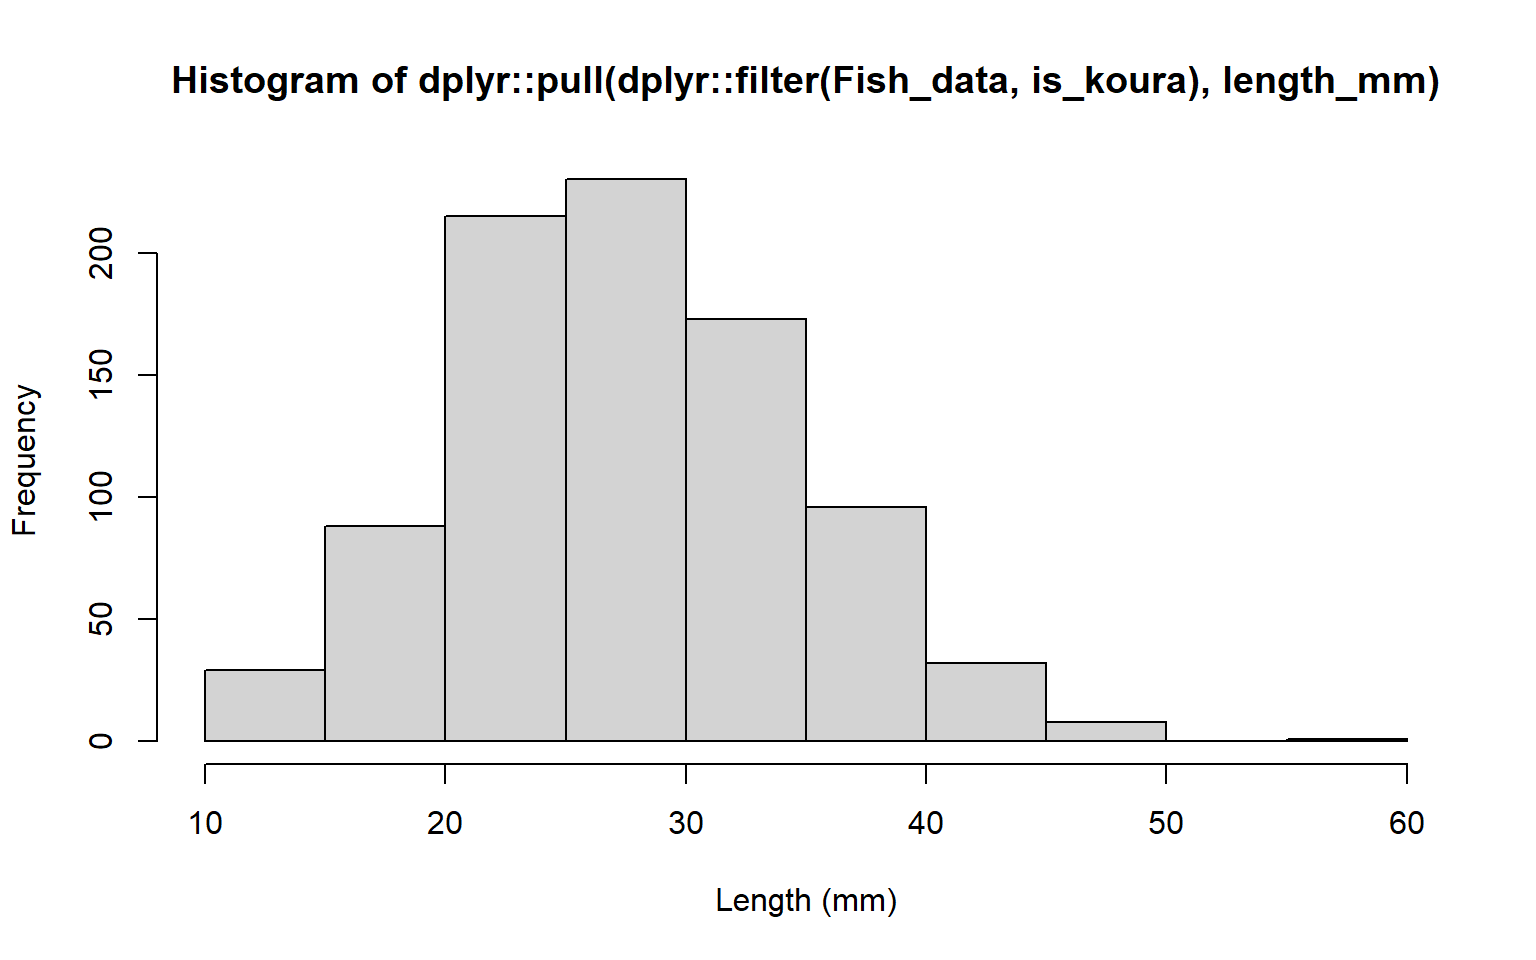

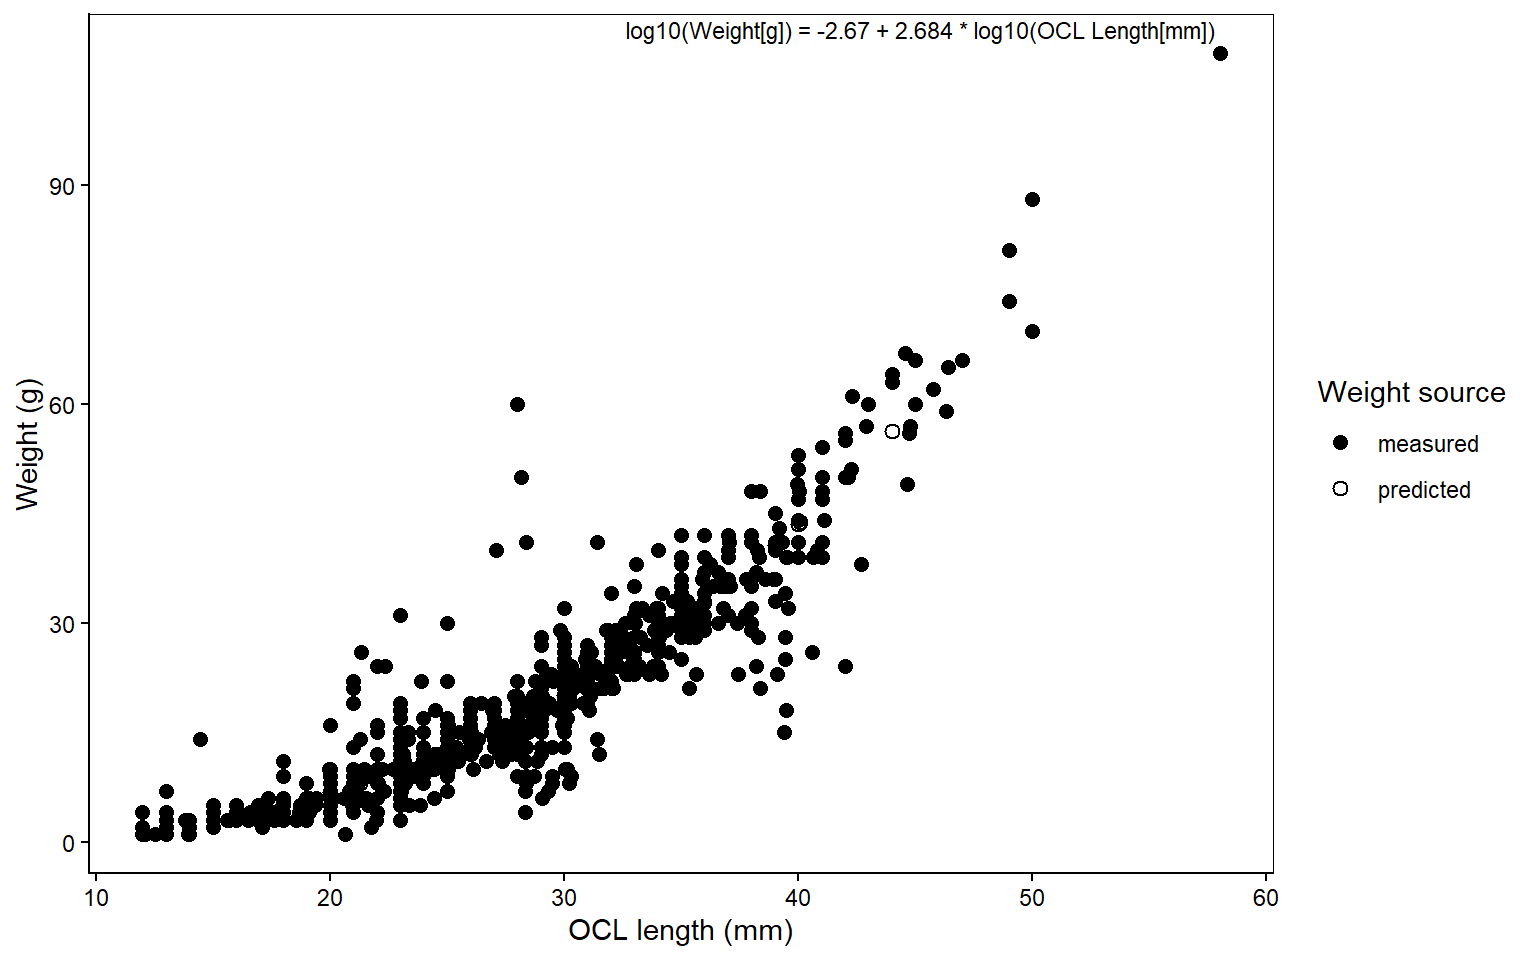

In [ ]:

# use size of koura to fill missing weights.
lw_model <- lm(log10(weight_g) ~ log10(length_mm), data = Fish_data, subset = species_name == "Freshwater_crayfish", na.action = na.exclude)

# extract the residual variance
sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
  mutate(is_koura = species_name == "Freshwater_crayfish",
    Predicted_weight = case_when( !is.na(weight_g) ~ weight_g,
      is_koura ~ {pred_log <- predict(lw_model, newdata = pick(everything()))
        10^(pred_log) * c}, TRUE ~ NA_real_ ),
    Weight_source = case_when(is_koura & !is.na(weight_g) ~ "measured",
      is_koura & is.na(weight_g) ~ "predicted",TRUE ~ NA_character_))

count_df <- Fish_data |>
  dplyr::filter(is_koura, !is.na(Weight_source)) |>
  dplyr::count(Weight_source, name = "n")

measured_n  <- count_df$n[count_df$Weight_source == "measured"]
predicted_n <- count_df$n[count_df$Weight_source == "predicted"]

total_koura <- Fish_data |>
  dplyr::filter(is_koura) |>
  nrow()

hist(Fish_data |> dplyr::filter(is_koura) |> dplyr::pull(length_mm), xlab = "Length (mm)")

# Extract model coefficients
a <- coef(lw_model)[1]
b <- coef(lw_model)[2]

# Create formula text for the plot
formula_text <- paste0( "log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3), " * log10(OCL Length[mm])")

# Plot with formula added
length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(file.path(out_dir, "fig-length-weight.png"),length_weight_plot,width = 8, height = 5, dpi = 300)


## Build CPUE and BPUE

In [ ]:

CPUE_BPUE_legacy <- Fish_data %>%
  filter(!is.na(species)) %>%
  group_by(monitoring_id, species, net_type) %>%
  dplyr::reframe(
    Total_Individuals = sum(amount, na.rm = TRUE),
    Total_Weight      = sum(weight_g, na.rm = TRUE),
    Total_Effort      = dplyr::first(amount_nets),
    CPUE              = Total_Individuals / Total_Effort,
    BPUE              = Total_Weight      / Total_Effort,
    Mean_Length       = mean(length_mm, na.rm = TRUE),
    Min_Length        = ifelse(all(is.na(length_mm)), NA, min(length_mm, na.rm = TRUE)),
    Max_Length        = ifelse(all(is.na(length_mm)), NA, max(length_mm, na.rm = TRUE)),
    Mean_Weight       = mean(weight_g, na.rm = TRUE),
    Min_Weight        = ifelse(all(is.na(weight_g)), NA, min(weight_g, na.rm = TRUE)),
    Max_Weight        = ifelse(all(is.na(weight_g)), NA, max(weight_g, na.rm = TRUE))
  )

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
  group_by(monitoring_id, species) %>%
  summarise(
    Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
    Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
    Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
    Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
    Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
    Mean_Length             = mean(Mean_Length, na.rm = TRUE),
    Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
    Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
    Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
    Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
    Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
    .groups = "drop") %>%
  ungroup() %>%
  mutate(Total_Effort_sum = ifelse(monitoring_id %in% c("16_0", "10_1", "3_2", "16_2"), 3, 4),
    Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
    Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum)

species_presence_absence <- Fish_data %>%
  filter(!is.na(species)) %>%
  distinct(monitoring_id, species) %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = species,
    values_from = presence,
    values_fill = list(presence = 0),
    names_prefix = "Presence_") %>%
  mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
  pivot_wider(
    names_from  = species,
    values_from = c(
      Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
      Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
      Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight),
    names_sep   = "_", values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)) %>%
  mutate(
    Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
    Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt")))))


## Combined dataset construction

In [ ]:

unit_metadata <- dplyr::bind_rows(Monitoring_data %>%
    dplyr::select(parameter, unit), Chemical_data %>%
    dplyr::select(parameter, unit)) %>%
  dplyr::distinct() %>%
  dplyr::rename(Variable = parameter, Unit = unit)

Monitoring_summary <- Monitoring_data %>%
  dplyr::select(-group, -notes, -unit, -monitoring_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Riparian_vegetation, Vegetation_nearby, Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter, Wood_cover ), ~ as.numeric(.)))

Chemical_summary <- Chemical_data %>%
  dplyr::select(-group, -notes, -unit, -site_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), ~ as.numeric(.)))

Weed_summary <- Weed_data %>%
  group_by(monitoring_id, weed_type, native_status) %>%
  summarise(Total_Cover = sum(percentage_cover, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from  = c(weed_type, native_status), values_from = Total_Cover, values_fill = 0) %>% 
  dplyr::select(monitoring_id, Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Turf_Native)

Stone_pile_summary <- Stone_pile_data %>%
  select(-unit, -notes, -site_id)%>%
  pivot_wider(names_from = c(parameter, stone_pile_id), values_from = value, names_sep = ".")

Macroinvertebrates_sum <- Macroinvertebrates %>%
  group_by(monitoring_id, species) %>%
  summarise(Total_amount = sum(amount, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = c(species), values_from = Total_amount, values_fill = 0) %>%
  mutate(Invertebrates_Richness  = rowSums(dplyr::select(., -monitoring_id) > 0),
    Invertebrates_Abundance = rowSums(dplyr::select(., -monitoring_id)))

Combined_data <- Site_info %>%
  left_join(Monitoring_summary, by = "site_id") %>%
  left_join(Chemical_summary, by = c("monitoring_id")) %>%
  left_join(Weed_summary, by = c("monitoring_id")) %>%
  left_join(Stone_pile_summary, by = c("monitoring_id")) %>%
  left_join(CPUE_BPUE_weighted_summary, by = "monitoring_id") %>%
  left_join(species_presence_absence, by = "monitoring_id") %>%
  left_join(Macroinvertebrates_sum, by = "monitoring_id")


## Derived variables

In [ ]:

Combined_data <- Combined_data %>%
  dplyr::mutate(date_time = as.POSIXct(date_time, tz = "Pacific/Auckland"),
    Presence_rocks = dplyr::if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Period = factor(dplyr::if_else(monitoring == 0, "Before", "After"),levels = c("Before", "After")),
    Date  = as.Date(date_time),
    Time  = format(date_time, "%H:%M:%S"),
    Year  = lubridate::year(date_time),
    Month = lubridate::month(date_time, label = TRUE),
    Day   = lubridate::day(date_time),
    Season = dplyr::case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_),
    Date_Time_Numeric = as.numeric(date_time),
    Monitoring_label = dplyr::case_when(
      monitoring == 0 ~ "0 Pre/Summer",
      monitoring == 1 ~ "1 Autumn",
      monitoring == 2 ~ "2 Winter",
      monitoring == 3 ~ "3 Spring",
      monitoring == 4 ~ "4 Summer",
      monitoring == 5 ~ "5 Autumn",
      monitoring == 6 ~ "6 Winter",
      TRUE ~ as.character(monitoring)
    ) %>% as.factor(), site_id = as.factor(site_id)) %>%
  dplyr::mutate(
  Depth_5m    = suppressWarnings(as.numeric(Distance_5m)),
  Depth_20m   = suppressWarnings(as.numeric(Distance_20m)),
  Slope_0_5m  = 5  / Depth_5m,    # 5m rise / horizontal distance in m
  Slope_0_20m = 20 / Depth_20m)   # 20m rise / horizontal distance in m
        

habitat_classification <- Combined_data %>%
  filter(monitoring == 0) %>%
  dplyr::select(site_id, DHT, lake,
                Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover) %>%
  pivot_longer(cols = c(Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                  Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover),
    names_to  = "Type", values_to = "Percentage") %>%
  group_by(site_id) %>%
  summarise(Rocky_Percentage  = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
    Sand_Percentage     = sum(Percentage[Type == "Sand"], na.rm = TRUE),
    Mud_Percentage      = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
    Emergent_Percentage = sum(Percentage[Type %in% c("Emergent_Native")], na.rm = TRUE),
    Substrate_index_before = sum(
      0.08 * Percentage[Type == "Bedrock"] +
      0.07 * Percentage[Type == "Boulders"] +
      0.06 * Percentage[Type == "Cobble"] +
      0.04 * Percentage[Type == "Gravel"] +
      0.03 * Percentage[Type == "Sand"] +
      0.02 * Percentage[Type == "Organic_matter"] +
      0.01 * Percentage[Type == "Mud"],
      na.rm = TRUE),.groups = "drop") %>%
  mutate(Habitat_Type = case_when(
      Rocky_Percentage    > 25 ~ "Rocky",
      Emergent_Percentage > 25 ~ "Emergent Macrophyte",
      Sand_Percentage   >= Mud_Percentage ~ "Sandy",
      TRUE ~ "Muddy")) %>%
  dplyr::select(site_id, Habitat_Type, Substrate_index_before)

Combined_data <- Combined_data %>%
  left_join(habitat_classification, by = c("site_id"))%>%
  dplyr::mutate(monitoring_int = as.integer(monitoring),
    pair_id = factor(ceiling(as.numeric(as.character(site_id)) / 2)),
    koura_present = as.integer(`Total_Individuals_Kōura` > 0),
    Site_type_detail = factor(dplyr::case_when(
      site == "Stone_pile" ~ "Stone_pile",
      site == "Control"    ~ "Control",
      site == "Reference" & as.numeric(as.character(site_id)) %% 2 == 1 ~ "Reference_1",
      site == "Reference" & as.numeric(as.character(site_id)) %% 2 == 0 ~ "Reference_2",
      TRUE ~ site),
      levels = c("Stone_pile", "Control", "Reference_1", "Reference_2")))

# Substrate_index_update
site_area_m2 <- 10 * 15

pile_footprint_pct <- Stone_pile_data %>%
  dplyr::filter(stringr::str_detect(monitoring_id, "_0"), parameter == "Area") %>%
  dplyr::mutate(value_num = suppressWarnings(as.numeric(value)),
                site_id   = as.character(site_id)) %>%
  dplyr::group_by(site_id) %>%
  dplyr::summarise(footprint_pct = sum(value_num, na.rm = TRUE) / site_area_m2 * 100, .groups = "drop")

substrate_updated <- Combined_data %>%
  dplyr::filter(monitoring_int == 0) %>%
  dplyr::distinct(site_id, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter) %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(pile_footprint_pct, by = "site_id") %>%
  tidyr::replace_na(list(footprint_pct = 0)) %>%
  dplyr::mutate(
    Boulders_new = Boulders + footprint_pct * 0.20,
    Cobble_new   = Cobble   + footprint_pct * 0.80,
    Sand_new     = Sand     - footprint_pct,
    Substrate_index_after = 0.08 * Bedrock + 0.07 * Boulders_new + 0.06 * Cobble_new +
      0.04 * Gravel + 0.03 * Sand_new + 0.02 * Organic_matter + 0.01 * Mud) %>%
  dplyr::select(site_id, Substrate_index_after)

Combined_data <- Combined_data %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(substrate_updated, by = "site_id") %>%
  dplyr::mutate(
    site_id = factor(site_id, levels = as.character(sort(as.numeric(unique(site_id))))),
    Substrate_index_after = dplyr::if_else(
      site == "Stone_pile" & monitoring_int >= 1,
      Substrate_index_after,
      Substrate_index_before))

Combined_data <- Combined_data %>%
  mutate(lunar_phase = lunar.phase(Date, name = FALSE),  # 0-2π radians
    lunar_illumination = (1 - cos(lunar.phase(Date))) / 2,  # 0=new, 1=full
    lunar_name = lunar.phase(Date, name = TRUE))     # "New", "Waxing", "Full", "Waning"

# use buoy data to find stratification and habitat compression at monitoring period.
CTD_buoy <- readRDS(file.path(raw_data_dir, "buoy_raw_data.rds"))

Buoy_data_Rotoiti <- CTD_buoy |>
    dplyr::select(Lake, DateTime, DptSns, TmpWtr, DOconc) |>
    dplyr::filter(Lake == "Rotoiti") |>
    dplyr::rename(Depth = DptSns, Temp = TmpWtr, DO = DOconc) |>
    dplyr::mutate(DateTime = as.POSIXct(DateTime, format = "%Y-%m-%d %H:%M:%S")) |>
    dplyr::distinct(Lake, DateTime, .keep_all = TRUE) |>
    tidyr::drop_na(DateTime, Depth) |>
    mutate(
      Date  = as.Date(DateTime),
      Time  = format(DateTime, "%H:%M:%S"),
      Year  = lubridate::year(DateTime),
      # Month label is locale-dependent (display only) — Season uses numeric month instead
      Month = lubridate::month(DateTime, label = TRUE),
      Day   = lubridate::day(DateTime),
      Season = case_when(
        lubridate::month(DateTime) %in% c(12, 1, 2) ~ "Summer",
        lubridate::month(DateTime) %in% c(3, 4, 5)  ~ "Autumn",
        lubridate::month(DateTime) %in% c(6, 7, 8)  ~ "Winter",
        lubridate::month(DateTime) %in% c(9, 10, 11) ~ "Spring",
        TRUE ~ NA_character_),
      Date_Time_Numeric = as.numeric(DateTime),
      Time_of_Day = case_when(
        lubridate::hour(DateTime) >= 6  & lubridate::hour(DateTime) < 12 ~ "Morning",
        lubridate::hour(DateTime) >= 12 & lubridate::hour(DateTime) < 18 ~ "Afternoon",
        lubridate::hour(DateTime) >= 18 & lubridate::hour(DateTime) < 24 ~ "Evening",
        TRUE ~ "Night"))

# Filter to study period
Buoy_study <- Buoy_data_Rotoiti |>
    dplyr::filter(Date >= as.Date("2025-02-01"),
                  Date <= as.Date("2026-07-31"))

# Daily oxycline depth: shallowest depth where DO < 5 mg/L
# Recalculate oxycline_daily with 5 mg/L threshold and habitable depth
oxycline_daily <- Buoy_study |>
    dplyr::group_by(Date) |>
    dplyr::arrange(Depth, .by_group = TRUE) |>
    dplyr::summarise(
        habitable_depth_m = {
            d <- Depth[DO >= 5 & is.finite(DO)]
            if (length(d) == 0) NA_real_ else max(d, na.rm = TRUE)},
        hypoxia_top_m = {
            d <- Depth[DO < 5 & is.finite(DO)]
            if (length(d) == 0) NA_real_ else min(d, na.rm = TRUE)},
        surface_temp = mean(Temp[Depth < 5], na.rm = TRUE),
        .groups = "drop" ) |>
    dplyr::mutate(full_column = is.na(hypoxia_top_m))

# Per-site visit date
visit_dates <- Combined_data |>
    dplyr::mutate(visit_date = as.Date(date_time)) |>
    dplyr::select(site_id, monitoring, monitoring_id, visit_date)

# For each visit, average habitable depth over ±14 day window
visit_buoy <- visit_dates |>
    dplyr::rowwise() |>
    dplyr::mutate(buoy_slice = list(oxycline_daily |>
     dplyr::filter(Date >= visit_date - 14, Date <= visit_date + 14)),
        habitable_depth_m = mean(buoy_slice$habitable_depth_m, na.rm = TRUE),
        hypoxia_top_m = mean(buoy_slice$hypoxia_top_m, na.rm = TRUE),
        surface_temp_C = mean(buoy_slice$surface_temp, na.rm = TRUE),
        full_column = all(buoy_slice$full_column, na.rm = TRUE)) |>
    dplyr::select(-buoy_slice) |>
    dplyr::ungroup()

# Join to Combined_data
Combined_data <- Combined_data |>
    dplyr::left_join(visit_buoy |>
    dplyr::select(monitoring_id, habitable_depth_m, hypoxia_top_m, surface_temp_C, full_column),
        by = "monitoring_id")

# Monitoring quality flag — based on known compromised events
compromised_ids <- c("6_1", "13_1", "14_1", "1_2", "2_2", "19_2", "20_2", "1_3", "2_3", "6_5", "5_6", "6_6")

Combined_data <- Combined_data %>%
  mutate(monitoring_quality = case_when(monitoring_id %in% compromised_ids ~ "compromised", is.na(`Total_Individuals_Kōura`) ~ "missing", TRUE  ~ "complete"))

writexl::write_xlsx(Combined_data, file.path(der_data_dir, "Combined_data.xlsx"))
write.csv(Combined_data, file.path(der_data_dir, "Combined_data.csv"), row.names = FALSE)
write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

all_data <- Combined_data


## Missing data summary

In [ ]:

# Missing data summary
missing_table <- all_data %>%
  filter(monitoring_quality != "complete") %>%
  select(site_id, site, Monitoring_label, monitoring_id, monitoring_quality) %>%
  arrange(site_id, Monitoring_label)

knitr::kable(missing_table,
             col.names = c("Site ID", "Site", "Monitoring label", "Monitoring ID", "Quality"))


  Site ID   Site         Monitoring label   Monitoring ID   Quality
  --------- ------------ ------------------ --------------- -------------
  1         Stone_pile   2 Winter           1_2             compromised
  1         Stone_pile   3 Spring           1_3             compromised
  2         Control      2 Winter           2_2             compromised
  2         Control      3 Spring           2_3             compromised
  5         Stone_pile   6 Winter           5_6             compromised
  6         Control      1 Autumn           6_1             compromised
  6         Control      5 Autumn           6_5             compromised
  6         Control      6 Winter           6_6             compromised
  13        Reference    1 Autumn           13_1            compromised
  14        Reference    1 Autumn           14_1            compromised
  19        Reference    2 Winter           19_2            compromised
  20        Reference    2 Winter           20_2            compromised


# Buoy data

# Site overview

## Site overview table

In [ ]:

# Site-level info from all_data — baseline monitoring only
site_info_summary <- all_data %>%
  filter(monitoring == 0) %>%
  distinct(site_id, site, lat, lon, DHT, 
           Habitat_Type, Substrate_index_before,
           Slope_0_20m) %>%
  mutate(site_id = as.factor(site_id))

# Stone pile summary — mean across 3 piles per modified site at baseline
stone_pile_site_summary <- Stone_pile_data %>%
  filter(str_detect(monitoring_id, "_0")) %>%
  filter(parameter %in% c("Weight", "Volume", "Height_above", 
                           "Distance_to_shore", "Depth_on_R", 
                           "Depth_on_L", "Depth_after", "Area")) %>%
  mutate(value_num = suppressWarnings(as.numeric(value))) %>%
  group_by(site_id, parameter) %>%
  summarise(
    value_num = mean(value_num, na.rm = TRUE),
    n_piles   = n_distinct(stone_pile_id),
    .groups   = "drop") %>%
  pivot_wider(names_from = parameter, values_from = value_num) %>%
  mutate(
    # Cast to character (not factor) so the join below inherits
    # site_info_summary's (already correctly numeric-ordered) factor
    # instead of re-sorting this subset alphabetically on its own —
    # left_join() coerces factor-vs-character but errors on factor-vs-integer.
    site_id          = as.character(site_id),
    Depth_m          = round((Depth_on_R + Depth_on_L) / 2 / 1000, 2),
    Depth_after_m    = round(Depth_after       / 1000, 2),
    Height_above_m   = round(Height_above       / 1000, 2),
    Distance_shore_m = round(Distance_to_shore / 1000, 2),
    Area_m2          = round(Area,   2),
    Weight_kg        = round(Weight, 0),
    Volume_m3        = round(Volume, 2)) %>%
  select(site_id, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Join and finalise
site_data <- site_info_summary %>%
  left_join(stone_pile_site_summary, by = "site_id") %>%
  arrange(as.numeric(as.character(site_id))) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2))) %>%
  select(site_id, site, DHT, Substrate_index_before, Slope_0_20m, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Display table drops the stone-pile build dimensions (Distance_shore_m,
# Depth_m, Height_above_m, Area_m2, Volume_m3) — they only exist for
# Stone_pile sites, so they don't fit a per-site comparison table. site_data
# itself keeps them, since stone_pile_data2/mean_dist_shore/mean_depth/
# mean_area below still depend on them.
site_overview_display <- site_data %>%
  dplyr::select(site_id, site, DHT, Substrate_index_before, Slope_0_20m)

write.csv(site_overview_display, file = file.path(out_dir, "tbl-site-overview.csv"), row.names = FALSE)

knitr::kable(site_overview_display, digits = 2)


  site_id   site         DHT       Substrate_index_before   Slope_0_20m
  --------- ------------ ------- ------------------------ -------------
  1         Stone_pile   Rocky                       5.20          0.12
  2         Control      Rocky                       4.40          0.11
  3         Stone_pile   Sandy                       3.00          0.01
  4         Control      Sandy                       3.00          0.01
  5         Stone_pile   Sandy                       2.40          0.01
  6         Control      Sandy                       3.00          0.01
  7         Stone_pile   Sandy                       3.00          0.06
  8         Control      Sandy                       3.00          0.05
  9         Stone_pile   Sandy                       3.35          0.08
  10        Control      Rocky                       5.00          0.09
  11        Reference    Rocky                       6.60          0.16
  12        Reference    Rocky                       6.20          0.12
  13        Reference    Sandy                       3.60          0.09
  14        Reference    Sandy                       3.50          0.11
  15        Reference    Rocky                       5.20          0.03
  16        Reference    Rocky                       5.20          0.04
  17        Reference    Rocky                       5.00          0.05
  18        Reference    Rocky                       6.20          0.05
  19        Reference    Rocky                       5.70          0.11
  20        Reference    Rocky                       5.70          0.13


# Descriptive results

## Descriptive context plots

Background/methods-supporting plots — combined into a single figure below rather than shown individually, since none are primary results.

### Habitat characteristics

In [ ]:

Habitat_data <- all_data %>%
  dplyr::select(site_id, site, monitoring_int, Habitat_Type,Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover) %>%
  tidyr::pivot_longer(cols = c(Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover), names_to  = "Variable", values_to = "Value") %>%
  dplyr::group_by(site_id, site, Variable) %>%
  dplyr::slice_max(monitoring_int, n = 1, with_ties = FALSE) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

Habitat_summary <- Habitat_data %>%
  dplyr::group_by(site, Variable) %>%
  dplyr::summarise(
    mean_v = mean(Value, na.rm = TRUE),
    se     = sd(Value, na.rm = TRUE) / sqrt(sum(!is.na(Value))),
    .groups = "drop")

habitat_var_labels <- c(
  Slope_0_5m             = "Slope (0-5m)",
  Slope_0_20m            = "Slope (0-20m)",
  Substrate_index_before = "Substrate index\n(before)",
  Substrate_index_after  = "Substrate index\n(after)",
  Riparian_vegetation    = "Riparian\nvegetation",
  Overhanging_trees      = "Overhanging\ntrees",
  Wood_cover             = "Wood cover")

Habitat_plot <- ggplot(Habitat_summary, aes(site, mean_v, fill = site)) +
  geom_col(colour = "black") +
  geom_errorbar(aes(ymin = mean_v - se, ymax = mean_v + se), width = 0.25) +
  facet_wrap(~ Variable, scales = "free_y", nrow = 2, labeller = as_labeller(habitat_var_labels)) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  labs(y = "Mean value (± SE)", x = NULL) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), legend.position = "none")

ggsave(file.path(out_dir, "fig-habitat-plot.png"), Habitat_plot, width = 10, height = 6, dpi = 300)


### Stone pile structure

In [ ]:

stone_pile_data2 <- site_data %>%
  dplyr::select(site_id, site, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3) %>%
  tidyr::pivot_longer(
    cols      = c(Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3),
    names_to  = "Parameter",
    values_to = "Value") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

parameter_labels <- c(
  Distance_shore_m = "Distance to shore (m)",
  Depth_m          = "Depth (m)",
  Height_above_m   = "Height above lakebed (m)",
  Area_m2          = "Area (m²)",
  Volume_m3        = "Volume (m³)")

# Only Stone_pile sites have real values here (Control/Reference are NA
# from the left_join in site_data) — filter the NAs out before plotting so
# the unused factor levels actually drop, instead of leaving 15 empty tick
# positions squeezed in next to the 5 real bars. No fill/legend needed
# either, since every remaining bar is the same site type.
stone_pile_structure_plot <- stone_pile_data2 %>%
  dplyr::filter(!is.na(Value)) %>%
  ggplot(aes(site_id, Value)) +
  geom_col(colour = "black", fill = site_fill[["Stone_pile"]]) +
  facet_wrap(~ Parameter, scales = "free_y", nrow = 2, labeller = as_labeller(parameter_labels)) +
  labs(y = "Value", x = "Stone pile site")

ggsave(file.path(out_dir, "fig-stone-pile-structure.png"), stone_pile_structure_plot, width = 8, height = 6, dpi = 300)



# Overall means across sites, used inline in the Methods text
mean_dist_shore <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Distance_shore_m"], na.rm = TRUE)
mean_depth      <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Depth_m"], na.rm = TRUE)
mean_area       <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Area_m2"], na.rm = TRUE)


### Chemical conditions over time

In [ ]:

Chemical_data2 <- all_data %>%
  dplyr::select(monitoring_id, monitoring_int, site_id, site, Monitoring_label, Habitat_Type, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH, Temperature) %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  tidyr::pivot_longer(cols = c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), names_to = "Variable", values_to = "Values")

chemical_var_labels <- c(
  Temperature           = "Temperature (°C)",
  DO_mgl                = "Dissolved oxygen\n(mg/L)",
  DO_percent            = "Dissolved oxygen\n(%)",
  Conductivity          = "Conductivity\n(µS/cm)",
  Specific_conductivity = "Specific conductivity\n(µS/cm)",
  pH                    = "pH")

# Coloured by site type (not individual site_id) for consistency with every
# other panel — a 20-line/colour legend was competing with the data itself.
# x-axis uses monitoring_int + monitor_labels, same as the species-trends
# panel, so both panels read the same round labels.
Chemical_plot <- ggplot(Chemical_data2, aes(monitoring_int, Values, colour = site)) +
  geom_point(alpha = 0.5, position = position_jitter(width = 0.1)) +
  geom_smooth(aes(group = site), se = FALSE) +
  facet_wrap(~ Variable, scales = "free", nrow = 2, labeller = as_labeller(chemical_var_labels)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels) +
  labs(y = "Value", x = "Monitoring", colour = "Site type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")

ggsave(file.path(out_dir, "fig-chemical-plot.png"), Chemical_plot, width = 8, height = 6,  dpi = 300)


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

### All species trends

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database
Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

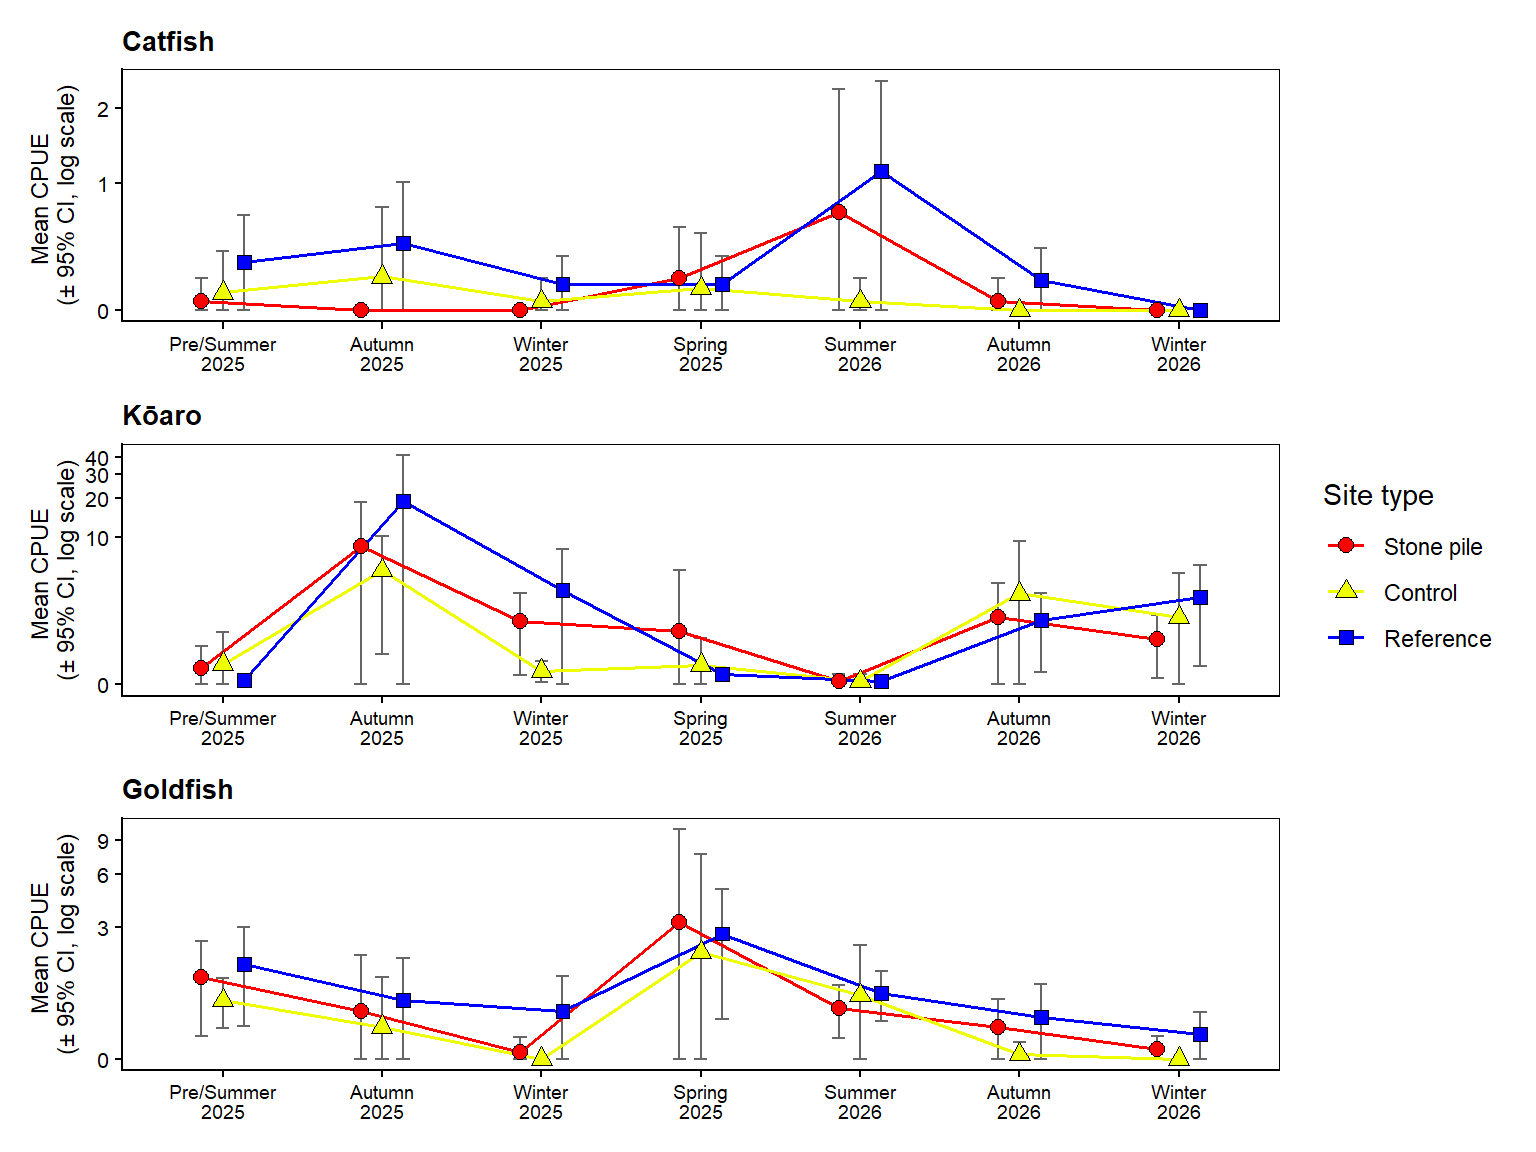

In [ ]:

# Species to plot and their display names
species_vec_trends <- c("Catfish", "Kōaro", "Goldfish")

species_labels <- c("Kōura" = "Kōura", "Catfish" = "Catfish", "Kōaro" = "Kōaro", "Goldfish" = "Goldfish")

# Function to build one trend plot per species
make_trend_plot <- function(sp) {

  col_name <- paste0("Weighted_CPUE_", sp)
  if (!col_name %in% names(all_data)) return(NULL)

  summary_df <- all_data %>%
    group_by(monitoring_int, site) %>%
    summarise(
      mean_n = mean(.data[[col_name]], na.rm = TRUE),
      se     = sd(.data[[col_name]], na.rm = TRUE) /
               sqrt(sum(!is.na(.data[[col_name]]))),
      n      = sum(!is.na(.data[[col_name]])),
      ci95   = qt(0.975, df = pmax(n - 1, 1)) * se,
      .groups = "drop") %>%
    mutate(
      site   = factor(site, levels = c("Stone_pile", "Control", "Reference")),
      ci_low  = pmax(mean_n - ci95, 0),
      ci_high = mean_n + ci95)

  ggplot(summary_df,
      aes(monitoring_int, mean_n, colour = site, shape = site, fill = site)) +
    geom_errorbar(aes(ymin = ci_low, ymax = ci_high), position = position_dodge(width = 0.4), width = 0.25, linewidth = 0.4, colour = "grey40") +
    geom_line(aes(group = site), position = position_dodge(width = 0.4), linewidth = 0.6) +
    geom_point(colour = "black", size = 2.5, stroke = 0.4, position = position_dodge(width = 0.4)) +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
    scale_y_continuous(trans = "log1p") +
    labs(title  = species_labels[[sp]], x = NULL, y = "Mean CPUE \n(± 95% CI, log scale)", colour = "Site type", shape = "Site type", fill = "Site type") +
    theme(axis.text.x     = element_text(size = 7,),
      axis.text.y     = element_text(size = 8),
      axis.title.y    = element_text(size = 9),
      plot.title      = element_text(size = 10, face = "bold"),
      legend.position = "none")   # collect legend from patchwork
}

# Generate all plots, drop NULLs
trend_plots <- purrr::map(species_vec_trends, make_trend_plot) %>%
  purrr::set_names(species_vec_trends) %>%
  purrr::compact()

combined_trends <- patchwork::wrap_plots(trend_plots, ncol = 1) +
  patchwork::plot_layout(guides = "collect") +
  patchwork::plot_annotation(theme= theme(legend.position = "right")) & theme(legend.position = "right")

# Save combined
ggsave(file.path(out_dir, "fig-all-species-trends.png"), combined_trends, width = 6, height = 6, dpi = 300)

combined_trends


### Combined figure

In [ ]:

# Left column stacks the 3 site-characteristic panels; right column is the
# species-trends panel (already a 3-row stack of its own), so both sides
# end up with matching internal proportions instead of a forced 2x2 grid
# that would otherwise squash the taller species-trends panel.
left_column <- Habitat_plot / stone_pile_structure_plot / Chemical_plot

descriptive_context_plot <- (left_column | combined_trends) +
  patchwork::plot_layout(widths = c(1.3, 1)) +
  patchwork::plot_annotation(tag_levels = "A")

ggsave(file.path(out_dir, "fig-descriptive-context.png"), descriptive_context_plot, width = 14, height = 12, dpi = 300)


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)): font family
not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBound

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

### Kōura trend plot

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

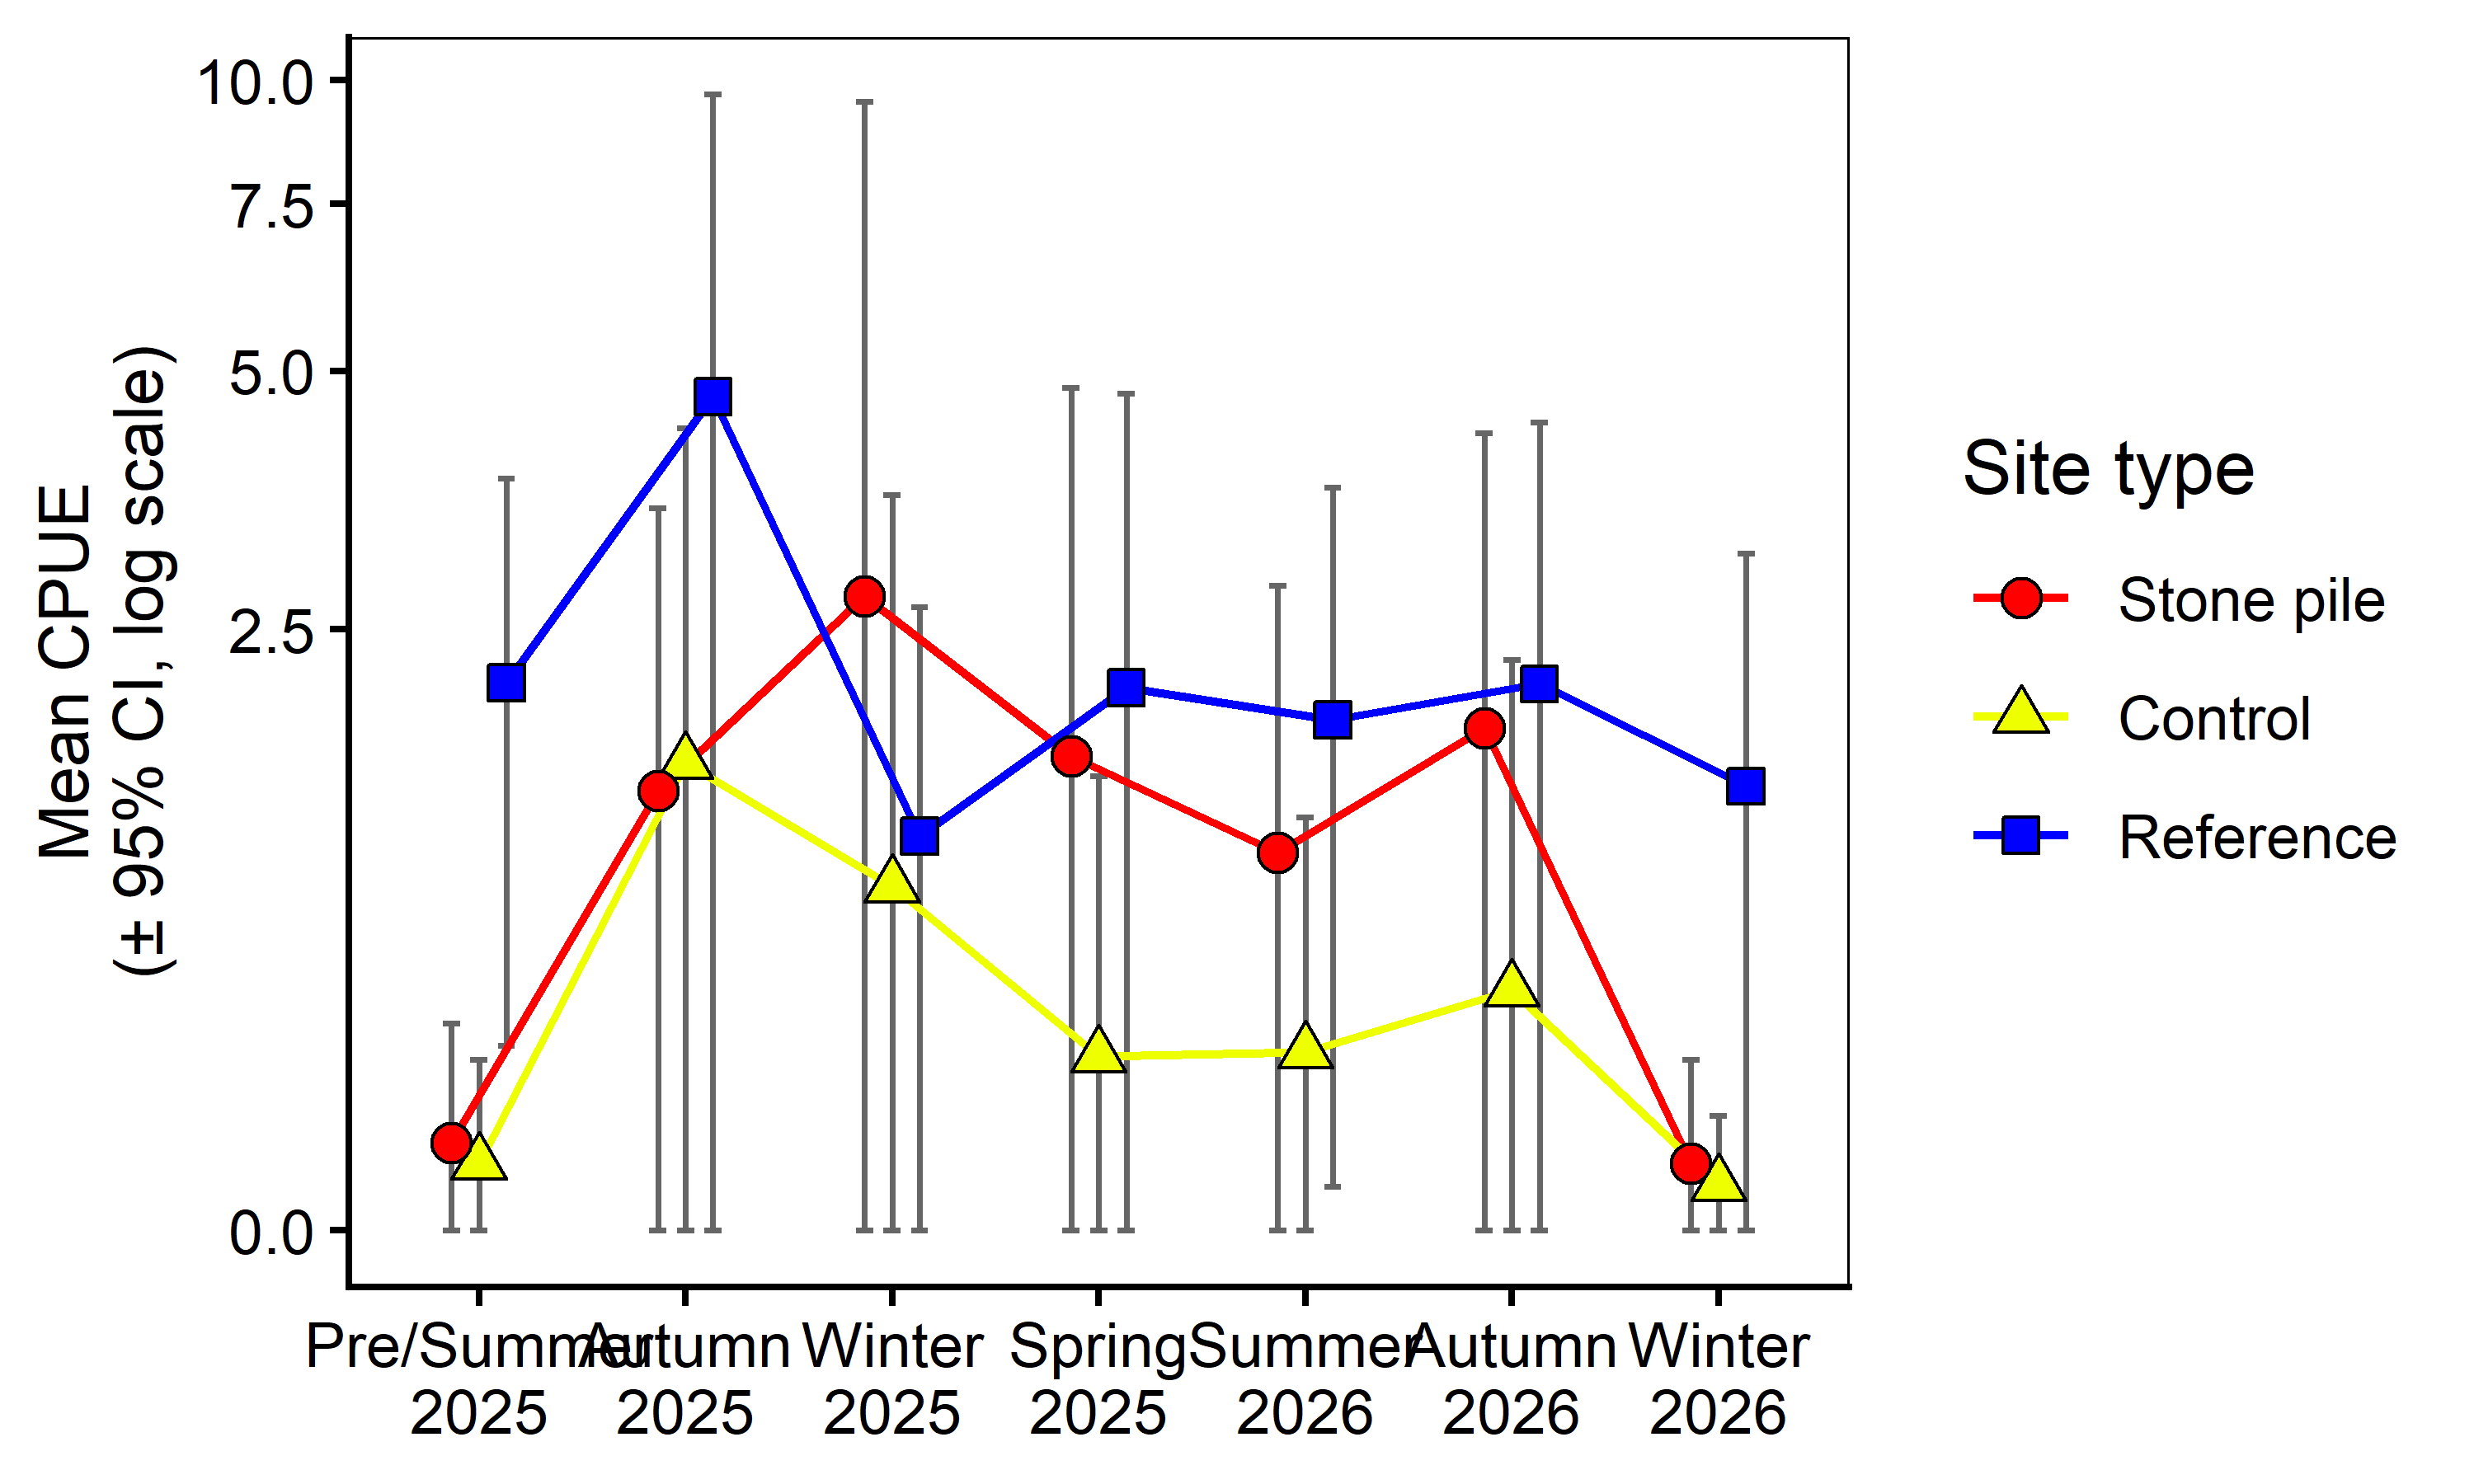

In [ ]:

# kōura trend plot — more detail than combined figure
koura_trend <- make_trend_plot("Kōura") +
  labs(title = NULL) +   # remove title since it's obvious
  theme(
    axis.text.x     = element_text(size = 9),
    axis.text.y     = element_text(size = 9),
    axis.title.y    = element_text(size = 10),
    legend.position = "right")

ggsave(file.path(out_dir, "fig-koura-trends.png"), koura_trend, width = 6, height = 3, dpi = 300)

koura_trend


### Kōura CPUE plot per site

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

(`geom_point()`).

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

(`stat_smooth()`).

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: There are other near singularities as well. 4

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: pseudoinverse used at 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: neighborhood radius 2

Warning in simpleLoess(y, x, w, span, degree = degree, parametric = parametric,
: reciprocal condition number 0

(`geom_point()`).

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning 

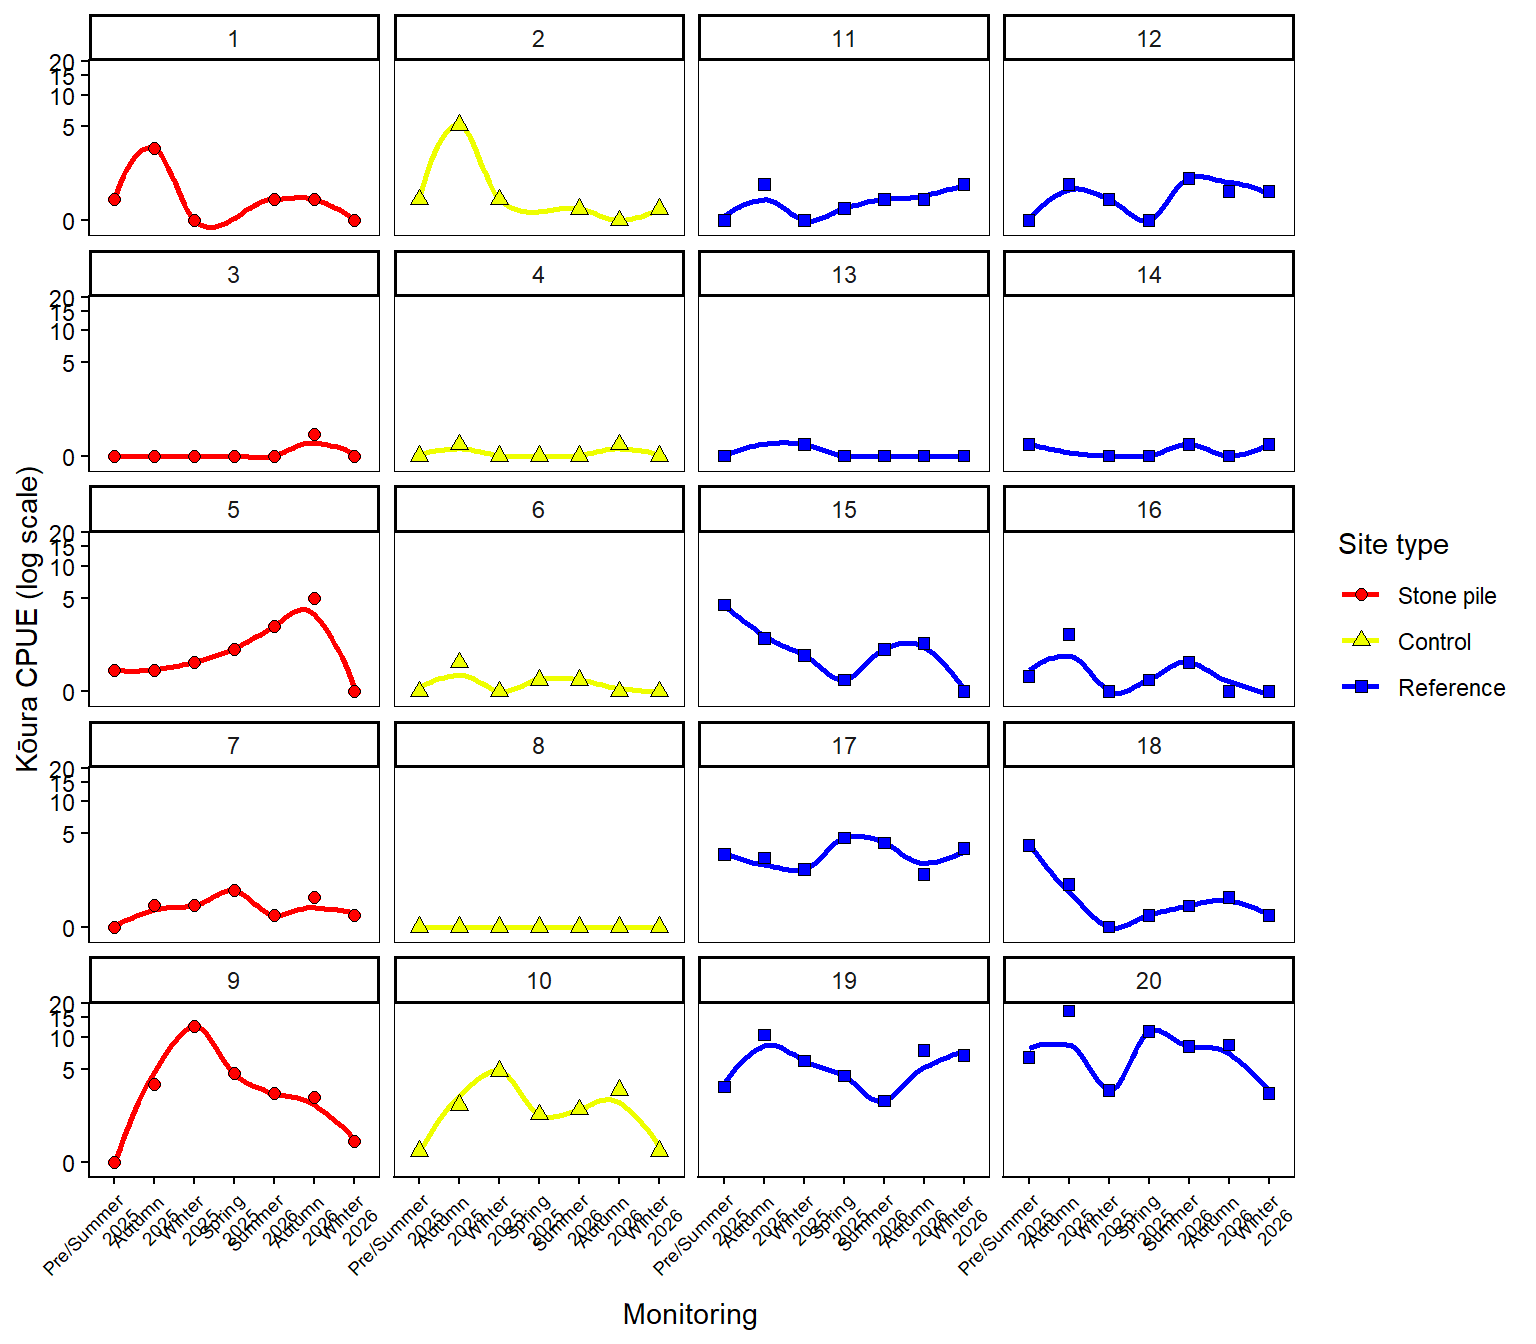

In [ ]:

site_id_order <- c(1, 2, 11, 12, 3, 4, 13, 14, 5, 6, 15, 16, 7, 8, 17, 18, 9, 10, 19, 20)

koura_cpue_plot <- all_data %>%
  dplyr::mutate(
    site    = factor(site, levels = c("Stone_pile", "Control", "Reference")),
    site_id = factor(as.numeric(as.character(site_id)), levels = site_id_order)) %>%
  ggplot(aes(monitoring_int, `Weighted_CPUE_Kōura`, shape = site, fill = site)) +
  geom_smooth(se = FALSE, aes(group = site, col = site)) +
  geom_point(size = 2, col = "black") +
  facet_wrap(~site_id, ncol = 4) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  scale_y_continuous(trans = "log1p") +
  labs(y = "Kōura CPUE (log scale)", x = "Monitoring",
       col = "Site type", shape = "Site type", fill = "Site type") +
  theme(axis.text.x     = element_text(angle = 45, hjust = 1, size = 7),
        legend.position = "right")

ggsave(file.path(out_dir, "fig-koura-cpue.png"), koura_cpue_plot, width = 10, height = 7, dpi = 300)


### Kōura:Catfish log-ratio over time

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

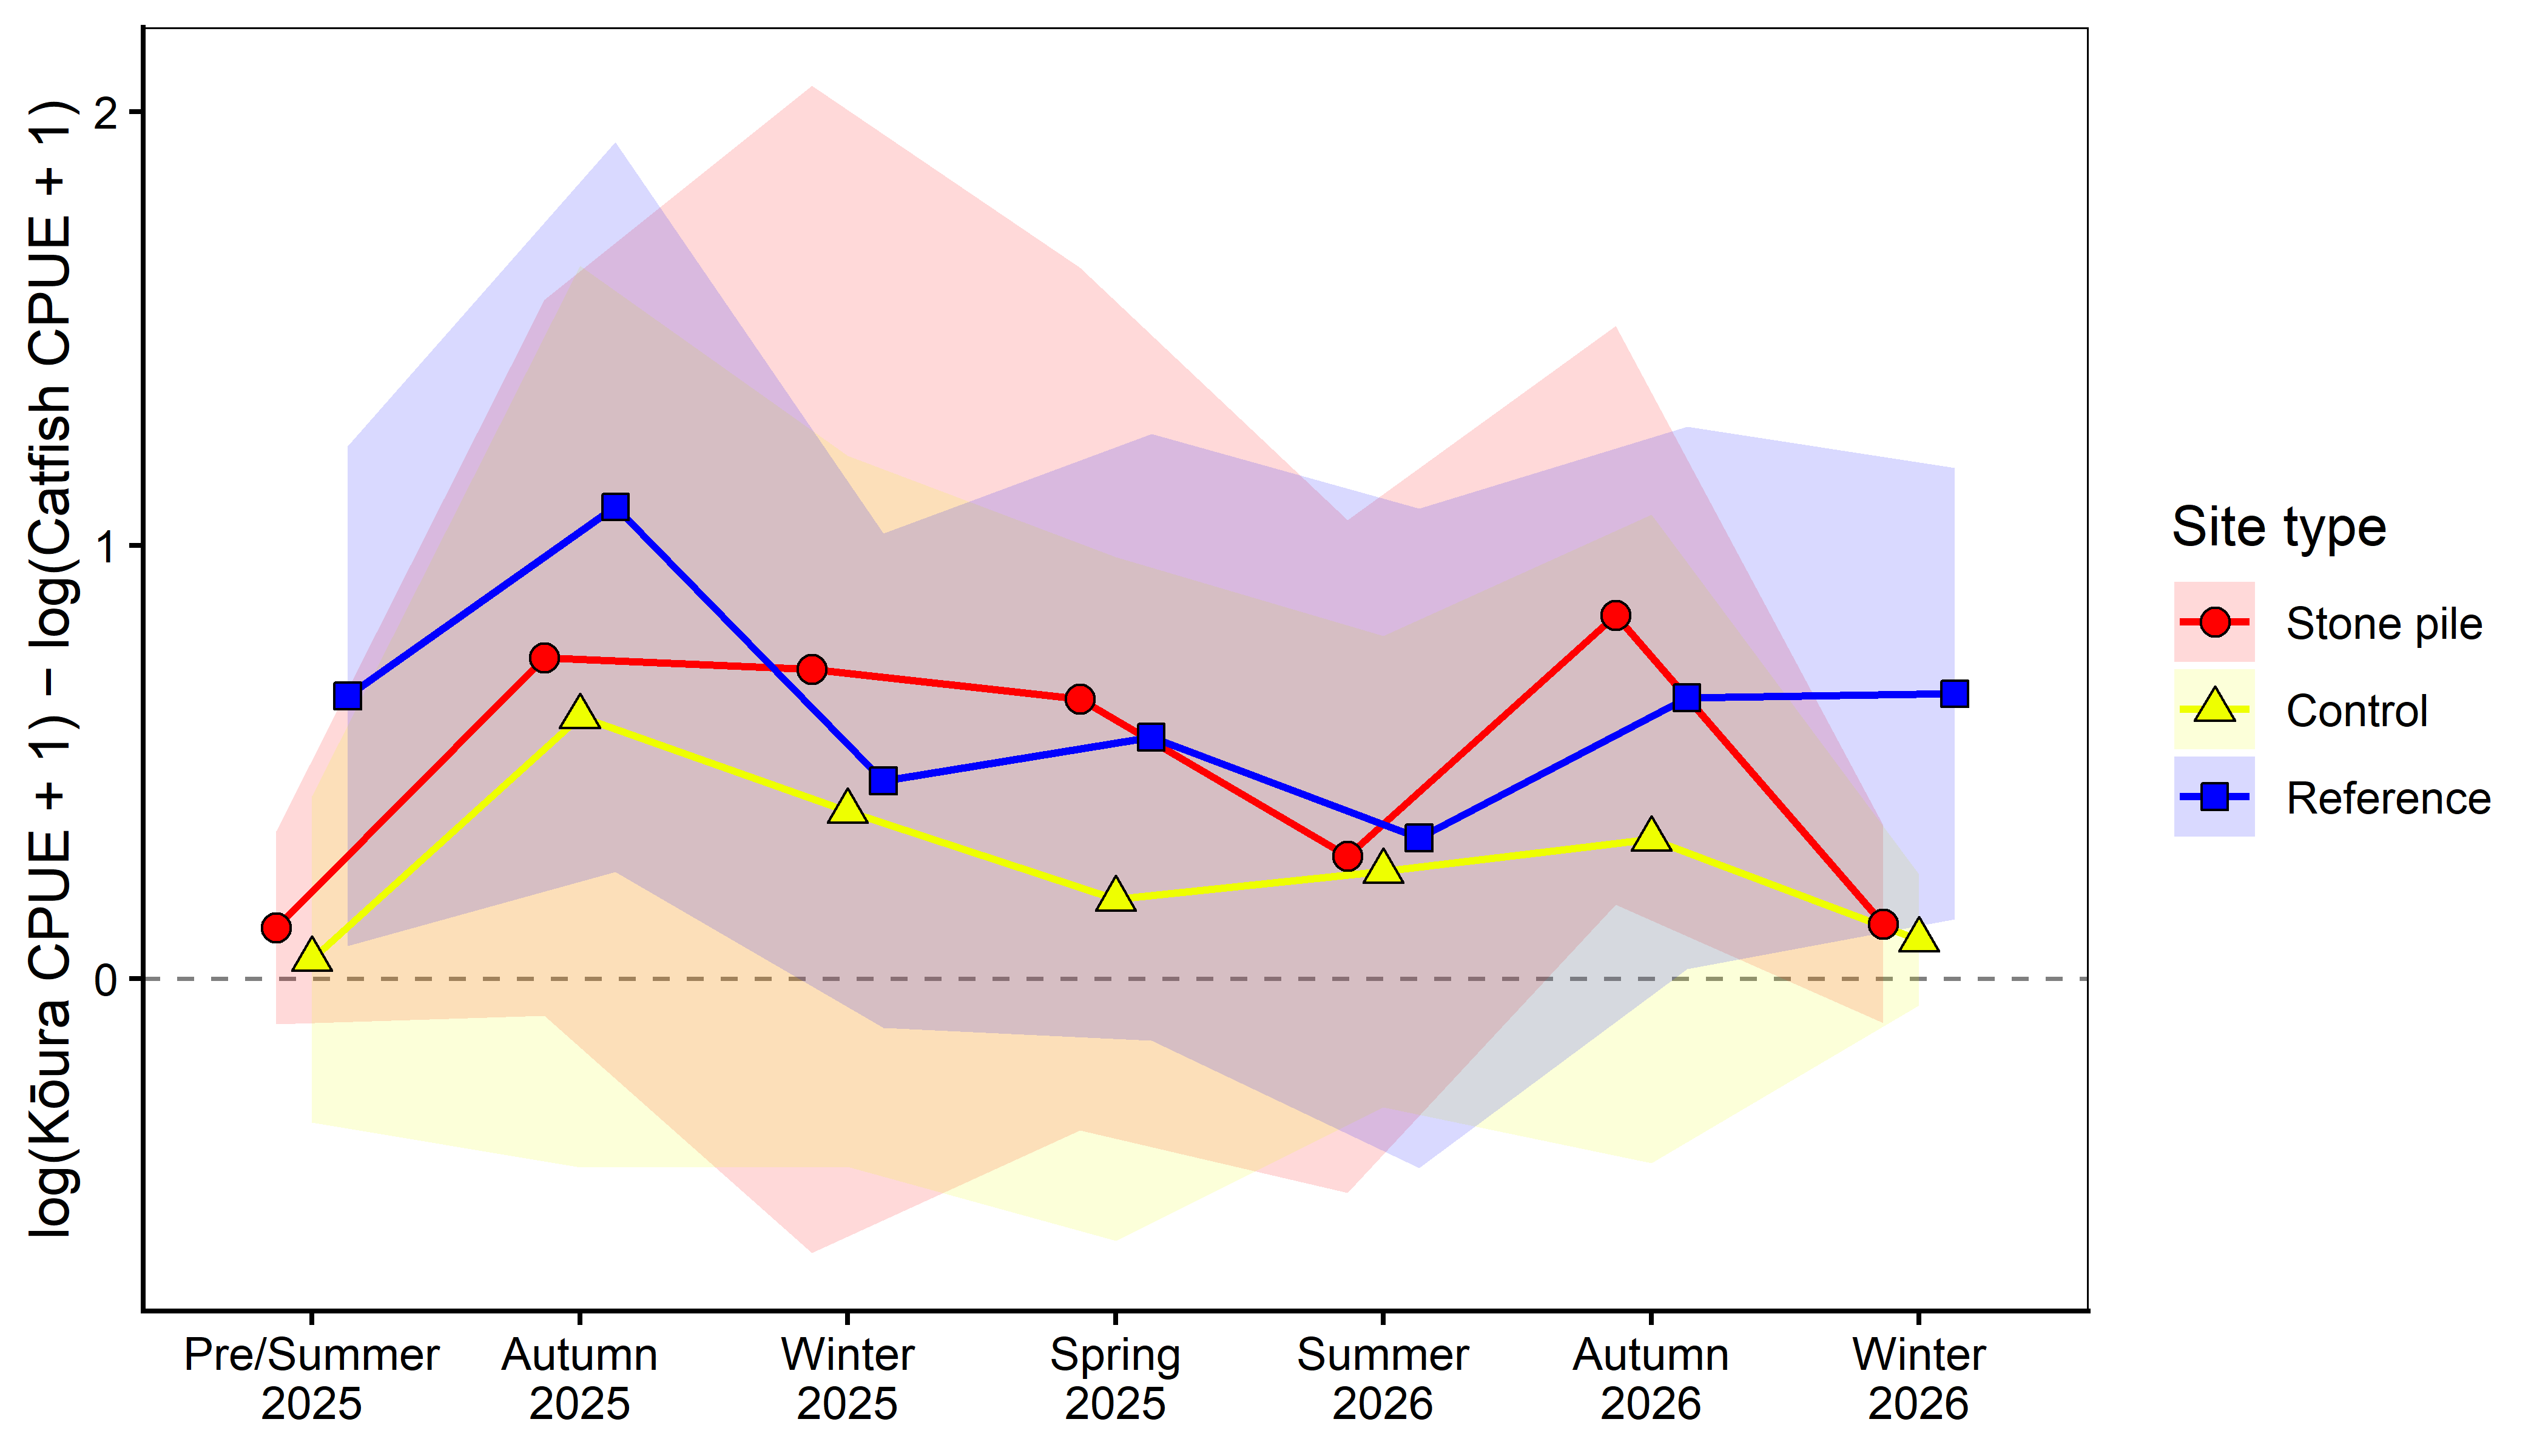

In [ ]:

ratio_data <- all_data %>%
  dplyr::mutate(
    log_ratio = log(`Weighted_CPUE_Kōura` + 1) - log(Weighted_CPUE_Catfish + 1),
    site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

ratio_summary <- ratio_data %>%
  dplyr::group_by(monitoring_int, site) %>%
  dplyr::summarise(
    mean_ratio = mean(log_ratio, na.rm = TRUE),
    se         = sd(log_ratio, na.rm = TRUE) / sqrt(sum(!is.na(log_ratio))),
    n          = sum(!is.na(log_ratio)),
    ci95       = qt(0.975, df = pmax(n - 1, 1)) * se,
    ci_low     = mean_ratio - ci95,
    ci_high    = mean_ratio + ci95,
    .groups    = "drop")

ratio_plot <- ggplot(ratio_summary,
    aes(monitoring_int, mean_ratio, colour = site, fill = site, shape = site)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.15, colour = NA,
              position = position_dodge(width = 0.4)) +
  geom_line(aes(group = site), position = position_dodge(width = 0.4), linewidth = 0.7) +
  geom_point(colour = "black", size = 2.5, stroke = 0.4,
             position = position_dodge(width = 0.4)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(x = NULL,
       y = "log(Kōura CPUE + 1) − log(Catfish CPUE + 1)",
       colour = "Site type", fill = "Site type", shape = "Site type") +
  theme(axis.text.x = element_text(size = 9), legend.position = "right")

ggsave(file.path(out_dir, "fig-koura-catfish-ratio.png"), ratio_plot,
       width = 7, height = 4, dpi = 300)

ratio_plot


## Combined environmental and fish summary table

In [ ]:

group_var <- "site_id" 
var_order_exact <- c("Substrate index","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation","Submerged vegetation", "Temperature","Dissolved oxygen","Specific conductivity","pH","Presence Kōura", "Presence Catfish","Presence Eel","Presence Goldfish","Presence Common smelt", "Presence Kōaro","Presence Trout")

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- stats::sd(x) / sqrt(n)
  tcrit <- stats::qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

site_lookup <- all_data %>%
  dplyr::select(site_id, site) %>%
  dplyr::distinct() %>%
  dplyr::mutate(site_id   = as.character(site_id), site = as.character(site))

unit_map <- dplyr::tibble(Variable = c("Substrate_index_before","Riparian_vegetation","Overhanging_trees","Wood_cover", "Temperature","DO_mgl","Specific_conductivity","pH"))

Env_data <- all_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Non_Native) %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Substrate_index_before, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Emergent_vegetation, Submerged_vegetation,
    Temperature, DO_mgl, Specific_conductivity, pH ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Value")

Env_summary_by_group <- Env_data %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_table <- dplyr::bind_rows(Env_summary_by_group, Env_summary_all)

# ---- Fish presence data (long) ----
Fish_data_long <- all_data %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Presence_Kōura, Presence_Catfish, Presence_Eel, Presence_Goldfish, Presence_Common_smelt, Presence_Kōaro, Presence_Trout ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Presence")

Fish_summary_by_group <- Fish_data_long %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_table <- dplyr::bind_rows(Fish_summary_by_group, Fish_summary_all)

# ---- Combine + attach units + pretty variable names + exact ordering ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::mutate(Group = as.character(Group)) %>%
  dplyr::left_join(
    site_lookup,
    by = c("Group" = "site_id")) %>%
  dplyr::left_join(unit_metadata, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index_before       = "Substrate index",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Kōura        = "Presence Kōura",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout" ),
    Unit = dplyr::coalesce(Unit, "")) %>%
  dplyr::mutate(
    Variable = factor(as.character(Variable), levels = var_order_exact),
    Group    = as.character(Group)) %>%
  dplyr::select(Group, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, dplyr::desc(Group == "All sites"), Group)

# Optional: if you want Group sorted numerically when Group is ID
if (group_var == "site_id") {
  EnvBio_summary_table <- EnvBio_summary_table %>%
    dplyr::mutate(
      Group_num = suppressWarnings(as.numeric(Group))
    ) %>%
    dplyr::arrange(
      Variable,
      dplyr::desc(Group == "All sites"),
      Group_num,
      Group
    ) %>%
    dplyr::select(-Group_num)
}

write.csv(EnvBio_summary_table, file = file.path(out_dir, "EnvBio_summary_table.csv"), row.names = FALSE)

DT::datatable(
  EnvBio_summary_table,
  filter = "top",
  options = list(
    pageLength = 20,
    dom = 'Bfrtip',
    buttons = c('csv', 'excel'),
    columnDefs = list(list(className = 'dt-center', targets = 3:9))
  ),
  extensions = 'Buttons',
  rownames = FALSE,
  colnames = c("Site", "Variable", "Unit", "n", "Mean", "Median", "Min", "Max", "CI low", "CI high")
) |>
  DT::formatRound(columns = c("Mean","Median","Min","Max","CI_low","CI_high"), digits = 2)


# Statistical analysis

*Baseline equivalence* RQ1 — Were stone pile sites equivalent to control sites, and reference sites equivalent to each other, before stone pile installation?

Descriptive: tbl-baseline-combined — Wilcoxon tests across all site-level variables (water quality, substrate, CPUE, BPUE); documents overall site comparability and the starting gap between stone pile and reference sites

Inferential: RQ1a — Treatment sites (Stone_pile vs Control): M1aak - Abundance, Kōura, Stone_pile vs Control, round 0, Tweedie M1aac - Abundance, Catfish, Stone_pile vs Control, round 0, Tweedie M1abk - Biomass, Kōura, Stone_pile vs Control, round 0, Tweedie M1abc - Biomass, Catfish, Stone_pile vs Control, round 0, Tweedie

RQ1b — Reference sites (Ref 1 vs Ref 2): M1bak - Abundance, Kōura, Ref 1 vs Ref 2, round 0, Tweedie M1bac - Abundance, Catfish, Ref 1 vs Ref 2, round 0, Tweedie M1bbk - Biomass, Kōura, Ref 1 vs Ref 2, round 0, Tweedie M1bbc - Biomass, Catfish, Ref 1 vs Ref 2, round 0, Tweedie

*Construction impact relative to control sites* RQ2 — Did kōura and catfish abundance and biomass change at stone pile sites relative to paired control sites after installation?

RQ2a — Step-change effect (BACI): M2aok - Occupancy, Kōura, Stone_pile vs Control, full timeline, Binomial M2aoc - Occupancy, Catfish, Stone_pile vs Control, full timeline, Binomial M2aak - Abundance, Kōura, Stone_pile vs Control, full timeline, Tweedie M2aac - Abundance, Catfish, Stone_pile vs Control, full timeline, Tweedie M2abk - Biomass, Kōura, Stone_pile vs Control, full timeline, Tweedie M2abc - Biomass, Catfish, Stone_pile vs Control, full timeline, Tweedie

RQ2b — After-construction trajectory: M2bok - Occupancy, Kōura, Stone_pile vs Control, round 1-6, Binomial M2boc - Occupancy, Catfish, Stone_pile vs Control, round 1-6, Binomial M2bak - Abundance, Kōura, Stone_pile vs Control, round 1-6, Tweedie M2bac - Abundance, Catfish, Stone_pile vs Control, round 1-6, Tweedie M2bbk - Biomass, Kōura, Stone_pile vs Control, round 1-6, Tweedie M2bbc - Biomass, Catfish, Stone_pile vs Control, round 1-6, Tweedie

*Recovery toward reference conditions* RQ3 — Did stone pile sites converge toward reference site densities over time, and did reference sites remain equivalent to each other?

RQ3a — Convergence (Stone_pile vs Reference): M3aak - Abundance, Kōura, Stone_pile vs Reference, round 1-6, Tweedie M3aac - Abundance, Catfish, Stone_pile vs Reference, round 1-6, Tweedie M3abk - Biomass, Kōura, Stone_pile vs Reference, round 1-6, Tweedie M3abc - Biomass, Catfish, Stone_pile vs Reference, round 1-6, Tweedie

RQ3b — Reference stability (Ref 1 vs Ref 2): M3bak - Abundance, Kōura, Ref 1 vs Ref 2, round 1-6, Tweedie M3bac - Abundance, Catfish, Ref 1 vs Ref 2, round 1-6, Tweedie M3bbk - Biomass, Kōura, Ref 1 vs Ref 2, round 1-6, Tweedie M3bbc - Biomass, Catfish, Ref 1 vs Ref 2, round 1-6, Tweedie

## Baseline equivalence — Were sites comparable before construction?

In [ ]:

# Baseline-only data (monitoring round 0), all three site types
baseline_data <- all_data %>%
  filter(monitoring_int == 0) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

# Display order and nicer names for the paper 
var_labels <- c(
  Weighted_CPUE_Kōura    = "Kōura CPUE",
  Weighted_CPUE_Catfish  = "Catfish CPUE",
  Weighted_BPUE_Kōura    = "Kōura BPUE",
  Weighted_BPUE_Catfish  = "Catfish BPUE",
  Substrate_index_before = "Substrate index (before)",
  Substrate_index_after  = "Substrate index (after)",
  Slope_0_20m            = "Slope (0–20 m)",
  Temperature            = "Temperature (°C)",
  DO_mgl                 = "Dissolved oxygen (mg/L)",
  Specific_conductivity  = "Specific conductivity (µS/cm)",
  pH                     = "pH")

baseline_vars <- setdiff(names(var_labels), "Substrate_index_after")

# Stone pile vs Control — paired by pair_id (BACI design check).
paired_test <- function(var, data = baseline_data) {
  wide <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Control")) %>%
    dplyr::select(pair_id, site, value = dplyr::all_of(var)) %>%
    tidyr::pivot_wider(names_from = site, values_from = value)

  test <- suppressWarnings(wilcox.test(wide$Stone_pile, wide$Control, paired = TRUE, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Control (paired)", Variable = var,
                 n_pairs = nrow(wide), statistic = unname(test$statistic), p.value = test$p.value)
}

# Stone pile vs Reference — unpaired (documents the baseline gap for RQ2)
unpaired_test <- function(var, data = baseline_data) {
  d <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Reference")) %>%
    dplyr::select(site, value = dplyr::all_of(var)) %>%
    dplyr::filter(!is.na(value)) %>%
    dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

  test <- suppressWarnings(wilcox.test(value ~ site, data = d, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Reference (unpaired)", Variable = var,
                 n_pairs = NA_integer_, statistic = unname(test$statistic), p.value = test$p.value)
}

baseline_tests <- dplyr::bind_rows(
  purrr::map_dfr(baseline_vars, paired_test),
  purrr::map_dfr(baseline_vars, unpaired_test)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

#write.csv(baseline_tests, file.path(out_dir, "tbl-baseline-tests.csv"), row.names = FALSE)

# Combined view
baseline_group_summary <- baseline_data %>%
  dplyr::select(site, dplyr::all_of(baseline_vars)) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

baseline_tests_wide <- baseline_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

baseline_combined <- baseline_group_summary %>%
  dplyr::left_join(baseline_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

after_data <- all_data %>%
  filter(monitoring_int >= 1) %>%
  distinct(site_id, pair_id, site, Substrate_index_after) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

after_tests <- dplyr::bind_rows(
  paired_test("Substrate_index_after", data = after_data),
  unpaired_test("Substrate_index_after", data = after_data)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

after_group_summary <- after_data %>%
  dplyr::select(site, Substrate_index_after) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

after_tests_wide <- after_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

after_combined <- after_group_summary %>%
  dplyr::left_join(after_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

baseline_combined <- dplyr::bind_rows(baseline_combined, after_combined) %>%
  dplyr::mutate(Variable = factor(Variable, levels = names(var_labels))) %>%
  dplyr::arrange(Variable) %>%
  dplyr::mutate(Variable = var_labels[as.character(Variable)])

write.csv(baseline_combined, file.path(out_dir, "tbl-baseline-combined.csv"), row.names = FALSE)

knitr::kable(baseline_combined, digits = 3)


  ---------------------------------------------------------------------------------------
  Variable             Stone_pile   Control   Reference     p_vs_Control   p_vs_Reference
  -------------------- ------------ --------- ----------- -------------- ----------------
  Kōura CPUE           0.2 ± 0.27   0.15 ±    2.13 ± 2.32          1.000            0.205
                                    0.22                                 

  Catfish CPUE         0.05 ± 0.11  0.1 ±     0.3 ± 0.52           1.000            0.420
                                    0.22                                 

  Kōura BPUE           7.95 ± 12.15 2.8 ±     36.69 ±              0.789            0.206
                                    3.84      36.82                      

  Catfish BPUE         0.15 ± 0.34  24.6 ±    97.28 ±              1.000            0.343
                                    55.01     232.15                     

  Substrate index      3.39 ± 1.07  3.68 ±    5.29 ± 1.05          0.789            0.012
  (before)                          0.95                                 

  Substrate index      3.65 ± 1.12  3.68 ±    5.29 ± 1.05          1.000            0.032
  (after)                           0.95                                 

  Slope (0--20 m)      0.06 ± 0.05  0.06 ±    0.09 ± 0.05          0.590            0.245
                                    0.04                                 

  Temperature (°C)     24.74 ± 1.92 24.78 ±   24.48 ±              1.000            0.623
                                    1.47      0.78                       

  Dissolved oxygen     9.85 ± 1.48  9.63 ±    10.03 ±              0.418            0.426
  (mg/L)                            1.29      0.86                       

  Specific             195.44 ±     199.8 ±   165.45 ±             0.281            0.951
  conductivity (µS/cm) 70.05        78.52     8.5                        

  pH                   7.5 ± 2.15   7.61 ±    8.53 ± 0.66          1.000            0.426
                                    2.2                                  
  ---------------------------------------------------------------------------------------


## Model constants

In [ ]:

all_species <- c("Catfish", "Kōura")

species_letter_map  <- c("Catfish" = "c", "Kōura" = "k")
response_letter_map <- c("abundance" = "a", "biomass" = "b", "occupancy" = "o")

# Fix model$call so DHARMa/emmeans can re-find the named dataset
repoint_call <- function(m, form, data_name, family_expr) {
  if (is.null(m)) return(NULL)
  m$call$formula <- as.formula(form)
  m$call$data    <- as.name(data_name)
  m$call$family  <- family_expr
  m
}


## RQ1 — Baseline

In [ ]:

rq1a_data <- all_data %>%
  dplyr::filter(site %in% c("Stone_pile", "Control"), monitoring == 0) %>%
  dplyr::mutate(
    Site_type_detail = factor(Site_type_detail, levels = c("Control", "Stone_pile")))

rq1b_data <- all_data %>%
  dplyr::filter(site == "Reference", monitoring == 0) %>%
  dplyr::mutate(
    Site_type_detail = factor(Site_type_detail, levels = c("Reference_1", "Reference_2")))

fit_rq1 <- function(data, species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(data)) return(NULL)
  form <- paste0("`", response_col, "` ~ Site_type_detail")
  tryCatch(
    glmmTMB::glmmTMB(as.formula(form), data = data, family = tweedie()),
    error = function(e) NULL)
}

fit_rq1b <- function(data, species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(data)) return(NULL)
  # Temperature supported for reference catfish: M1bac Base fails; M1bbc ΔAICc=5
  form <- if (species == "Catfish")
    paste0("`", response_col, "` ~ Site_type_detail + Temperature")
  else
    paste0("`", response_col, "` ~ Site_type_detail")
  tryCatch(
    glmmTMB::glmmTMB(as.formula(form), data = data, family = tweedie()),
    error = function(e) NULL)
}

# Helper to build a results tibble for one sub-question 
make_rq1_results <- function(data, fit_fn, comparison, time_frame, term_of_interest, model_prefix) {
  tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
    dplyr::mutate(
      RQ               = "RQ1",
      comparison       = comparison,
      time_frame       = time_frame,
      term_of_interest = term_of_interest,
      model_id         = paste0(model_prefix, response_letter_map[response_type], species_letter_map[species]),
      model            = purrr::map2(species, response_type, ~ fit_fn(data, .x, .y))) %>%
    dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
    dplyr::mutate(
      p_value  = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
        if (is.null(m)) return(NA_real_)
        broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
          dplyr::filter(term == trm) %>%
          dplyr::pull(p.value)
      }),
      p_adj_BH = p.adjust(p_value, method = "BH"))
}

rq1a_results <- make_rq1_results(
  rq1a_data, fit_rq1,
  comparison = "treatment", time_frame = "before",
  term_of_interest = "Site_type_detailStone_pile",
  model_prefix = "M1a")

rq1b_results <- make_rq1_results(
  rq1b_data, fit_rq1b,
  comparison = "reference", time_frame = "before",
  term_of_interest = "Site_type_detailReference_2",
  model_prefix = "M1b")


ℹ In argument: `model = purrr::map2(species, response_type, ~fit_fn(data, .x,
  .y))`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')

# A tibble: 18 × 13
   model_id comparison time_frame species response_type term  estimate std.error
   <chr>    <fct>      <fct>      <fct>   <fct>         <chr>    <dbl>     <dbl>
 1 M1aac    treatment  before     Catfish abundance     (Int…   -2.30      0.908
 2 M1aac    treatment  before     Catfish abundance     Site…   -0.693     1.54 
 3 M1abc    treatment  before     Catfish biomass       (Int…    3.20      1.28 
 4 M1abc    treatment  before     Catfish biomass       Site…   -5.1       3.11 
 5 M1aak    treatment  before     Kōura   abundance     (Int…   -1.90      0.785
 6 M1aak    treatment  before     Kōura   abundance     Site…    0.288     1.04 
 7 M1abk    treatment  before     Kōura   biomass       (Int…    1.03      0.83 
 8 M1abk    treatment  before     Kōura   biomass       Site…    1.04      0.977
 9 M1bac    reference  before     Catfish abundance     (Int… -102.       32.7  
10 M1bac    reference  before     Catfish abundance     Site…   -1.66      0.536
11 M1bac

## RQ2 — Construction impact

In [ ]:

# RQ2 a --------
rq2a_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Control")) %>%
  mutate(
    Period  = factor(Period, levels = c("Before", "After")),
    site    = factor(site,   levels = c("Control", "Stone_pile")),
    site_id = factor(site_id))

# fit function for RQ2 models
fit_rq2a <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(rq2a_data)) return(NULL)

  # Season collinear with Period in BACI; all models → Base
  form <- paste0("`", response_col, "` ~ Period * site + monitoring_int + (1 | pair_id / site_id)")
  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  zif     <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2a_data, REML = TRUE, family = fam_obj,
                  ziformula = zif),
                error = function(e) NULL)
  if (!is.null(m) && m$fit$convergence != 0)
    m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2a_data, REML = TRUE, family = fam_obj,
                    ziformula = zif,
                    control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
                  error = function(e) NULL)
  repoint_call(m, form, "rq2a_data",
               if (response_type == "occupancy") quote(binomial()) else quote(tweedie()))
}

rq2a_results <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ2a",
    comparison        = "vs_control",
    time_frame        = "full",
    term_of_interest  = "PeriodAfter:siteStone_pile",
    model_id          = paste0("M2a", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq2a)) %>%

  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))


# RQ2b ----------
rq2b_data <- rq2a_data %>%
  dplyr::filter(monitoring_int >= 1)

# fit function for RQ2b models
fit_rq2b <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(rq2b_data)) return(NULL)

  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  zif     <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  # Season collinear with Period in BACI context; all models → Base
  # (In RQ2b post-only data, Season appeared supported by AICc but model was degenerate)
  form <- paste0("`", response_col, "` ~ site * monitoring_int + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2b_data, REML = TRUE, family = fam_obj,
                  ziformula = zif),
                error = function(e) NULL)
  if (!is.null(m) && m$fit$convergence != 0)
    m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2b_data, REML = TRUE, family = fam_obj,
                    ziformula = zif,
                    control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
                  error = function(e) NULL)
  repoint_call(m, form, "rq2b_data",
               if (response_type == "occupancy") quote(binomial()) else quote(tweedie()))
}

rq2b_results <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ2b",
    comparison        = "vs_control",
    time_frame        = "after",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M2b", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq2b)) %>%

  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq2_results <- dplyr::bind_rows(rq2a_results, rq2b_results)

rq2_full_tidy <- rq2_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", component = "cond", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

print(rq2_full_tidy, n=70)


# A tibble: 54 × 11
   model_id species response_type term      estimate std.error statistic p.value
   <chr>    <chr>   <chr>         <chr>        <dbl>     <dbl>     <dbl>   <dbl>
 1 M2aac    Catfish abundance     (Interce…   -3.78      1.72     -2.20    0.028
 2 M2aac    Catfish abundance     PeriodAf…    0.664     1.50      0.442   0.659
 3 M2aac    Catfish abundance     siteSton…   -0.694     1.75     -0.396   0.692
 4 M2aac    Catfish abundance     monitori…   -0.291     0.336    -0.868   0.385
 5 M2aac    Catfish abundance     PeriodAf…    2.01      1.96      1.03    0.305
 6 M2abc    Catfish biomass       (Interce…    1.77      2.73      0.647   0.517
 7 M2abc    Catfish biomass       PeriodAf…   -0.33      2.26     -0.146   0.884
 8 M2abc    Catfish biomass       siteSton…   -5.28      5.67     -0.932   0.352
 9 M2abc    Catfish biomass       monitori…   -0.354     0.483    -0.731   0.465
10 M2abc    Catfish biomass       PeriodAf…    5.31      5.57      0.953   0.341
11 M2aoc

## RQ3 — Recovery toward reference conditions

In [ ]:

# RQ3a ----------
rq3a_data <- all_data %>%
  dplyr::filter(site %in% c("Stone_pile", "Reference"), monitoring_int >= 1) %>%
  dplyr::mutate(
    site    = factor(site,   levels = c("Reference", "Stone_pile")),
    site_id = factor(site_id))

fit_rq3a <- function(species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(rq3a_data)) return(NULL)

  zif  <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  # AICc selection: Temperature strongly supported for catfish abundance (ΔAICc=14.4); all others → Base
  form <- if (species == "Catfish" && response_type == "abundance")
    paste0("`", response_col, "` ~ site * monitoring_int + Temperature + (1 | site_id)")
  else
    paste0("`", response_col, "` ~ site * monitoring_int + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq3a_data, REML = TRUE, family = tweedie(),
                  ziformula = zif),
                error = function(e) NULL)
  if (!is.null(m) && m$fit$convergence != 0)
    m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq3a_data, REML = TRUE, family = tweedie(),
                    ziformula = zif,
                    control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
                  error = function(e) NULL)
  repoint_call(m, form, "rq3a_data", quote(tweedie()))
}

rq3a_results <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ3a",
    comparison        = "vs_reference",
    time_frame        = "after",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M3a", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq3a)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

# RQ3b ----------
rq3b_data <- all_data %>%
  dplyr::filter(site == "Reference", monitoring_int >= 1) %>%
  dplyr::mutate(
    Site_type_detail = factor(Site_type_detail, levels = c("Reference_1", "Reference_2")),
    pair_id = factor(pair_id), site_id = factor(site_id))

fit_rq3b_inner <- function(data, species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(data)) return(NULL)
  zif  <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  # AICc selection: Season for kōura abundance (ΔAICc=4.7); Temperature for catfish abundance; Base for biomass
  form <- if (species == "Kōura" && response_type == "abundance")
    paste0("`", response_col, "` ~ Site_type_detail * monitoring_int + Season + (1 | pair_id / site_id)")
  else if (response_type == "abundance")
    paste0("`", response_col, "` ~ Site_type_detail * monitoring_int + Temperature + (1 | pair_id / site_id)")
  else
    paste0("`", response_col, "` ~ Site_type_detail * monitoring_int + (1 | pair_id / site_id)")

  conv_failed <- FALSE
  m <- withCallingHandlers(
    tryCatch(
      glmmTMB::glmmTMB(as.formula(form), data = data, REML = TRUE, family = tweedie(),
        ziformula = zif),
      error = function(e) NULL),
    warning = function(w) {
      if (grepl("convergence|false conv", conditionMessage(w), ignore.case = TRUE))
        conv_failed <<- TRUE
      invokeRestart("muffleWarning")
    })

  if (conv_failed || is.null(m)) {
    m <- tryCatch(
      glmmTMB::glmmTMB(as.formula(form), data = data, REML = TRUE, family = tweedie(),
        ziformula = zif,
        control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
      error = function(e) NULL)
  }
  m
}

# Helper to build a results tibble for one sub-question
make_rq3b_results <- function(data, fit_fn, comparison, time_frame, term_of_interest, model_prefix) {
  tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
    dplyr::mutate(
      RQ               = "RQ3b",
      comparison       = comparison,
      time_frame       = time_frame,
      term_of_interest = term_of_interest,
      model_id         = paste0(model_prefix, response_letter_map[response_type], species_letter_map[species]),
      model            = purrr::map2(species, response_type, ~ fit_fn(data, .x, .y))) %>%
    dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
    dplyr::mutate(
      p_value  = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
        if (is.null(m)) return(NA_real_)
        broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
          dplyr::filter(term == trm) %>%
          dplyr::pull(p.value)
      }),
      p_adj_BH = p.adjust(p_value, method = "BH"))
}

rq3b_results <- make_rq3b_results(
  rq3b_data, fit_rq3b_inner,
  comparison = "reference", time_frame = "after",
  term_of_interest = "Site_type_detailReference_2:monitoring_int",
  model_prefix = "M3b")


ℹ In argument: `model = purrr::map2(species, response_type, ~fit_fn(data, .x,
  .y))`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')

The first warning was:
ℹ In argument: `tidy = purrr::map(...)`.
Caused by warning in `sqrt()`:
! NaNs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.

# A tibble: 37 × 11
   model_id species response_type term      estimate std.error statistic p.value
   <chr>    <chr>   <chr>         <chr>        <dbl>     <dbl>     <dbl>   <dbl>
 1 M3aac    Catfish abundance     (Interce…   -7.15      1.28     -5.58    0    
 2 M3aac    Catfish abundance     siteSton…   -2.47      1.94     -1.27    0.203
 3 M3aac    Catfish abundance     monitori…   -0.215     0.147    -1.46    0.144
 4 M3aac    Catfish abundance     Temperat…    0.315     0.058     5.41    0    
 5 M3aac    Catfish abundance     siteSton…    0.51      0.398     1.28    0.199
 6 M3abc    Catfish biomass       (Interce…    3.01      1.19      2.53    0.011
 7 M3abc    Catfish biomass       siteSton…   -4.37      3.06     -1.43    0.153
 8 M3abc    Catfish biomass       monitori…   -0.25      0.209    -1.20    0.232
 9 M3abc    Catfish biomass       siteSton…    0.689     0.638     1.08    0.28 
10 M3aak    Kōura   abundance     (Interce…    0.313     0.517     0.604   0.546
11 M3aak

### Predicted trajectories (kōura abundance convergence)

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

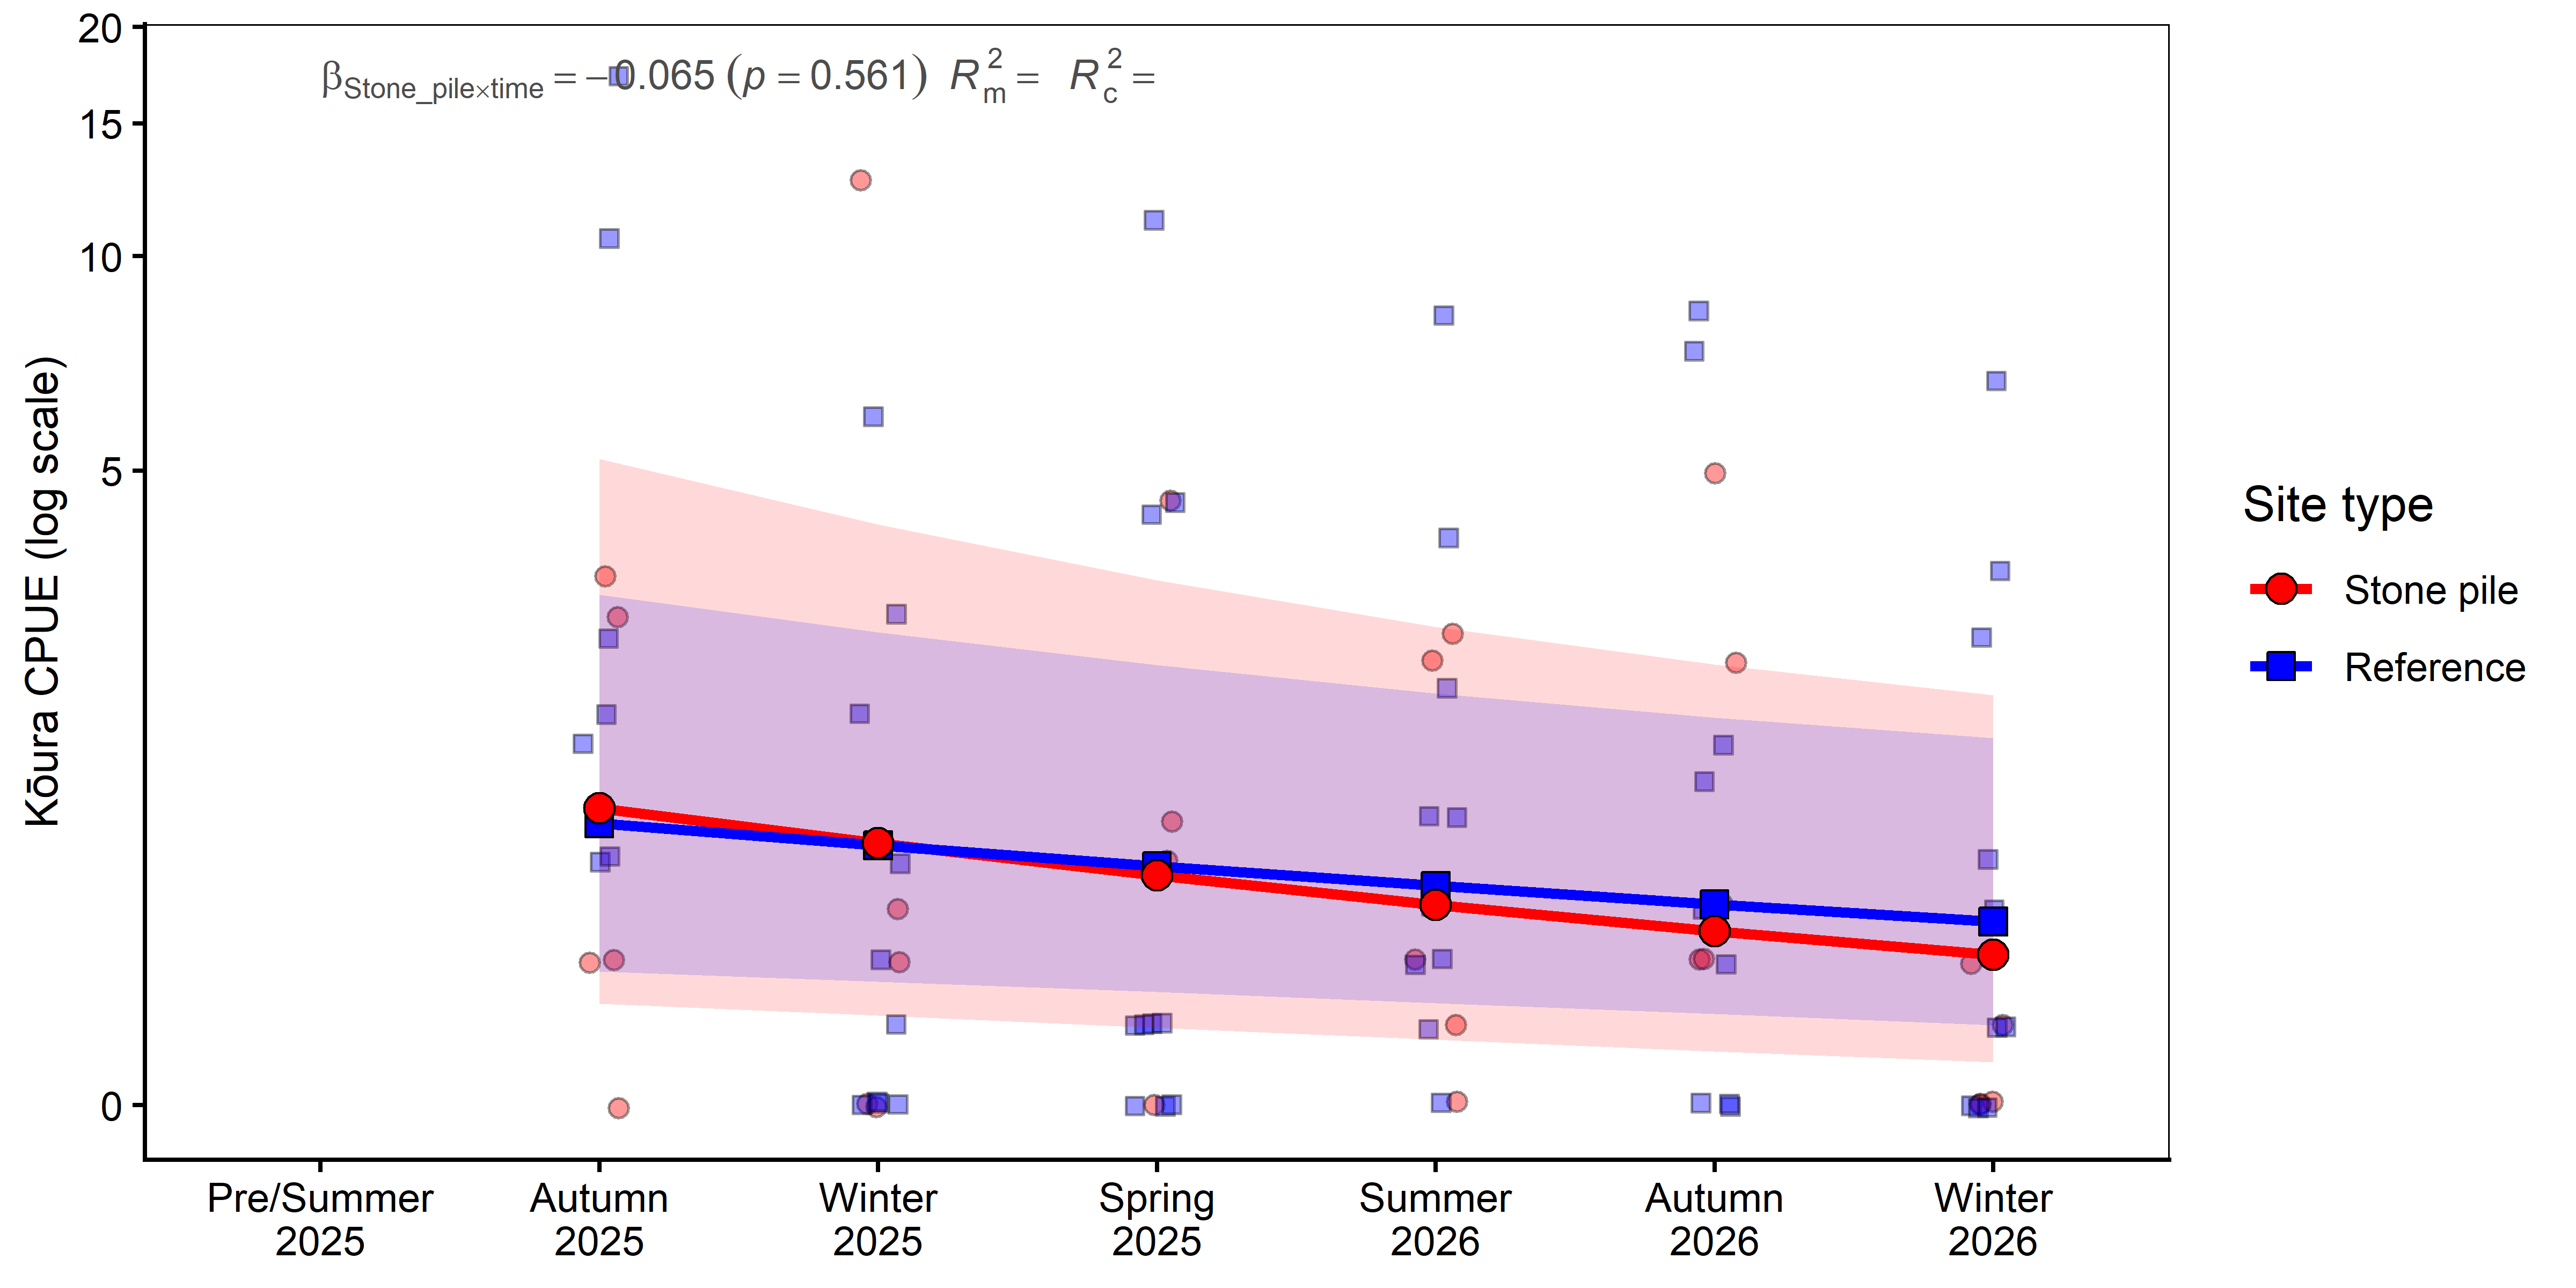

In [ ]:

M3aak <- rq3a_results %>%
  dplyr::filter(species == "Kōura", response_type == "abundance") %>%
  dplyr::pull(model) %>% .[[1]]

# Predicted trajectories at each monitoring round (M3aak: response ~ site * monitoring_int + (1|site_id))
emmeans::emm_options(msg.interaction = FALSE)

emm_m3aak <- purrr::map_dfr(1:6, function(i) {
  emmeans(M3aak, ~ site, at = list(monitoring_int = i), type = "response") %>%
    as.data.frame() %>%
    dplyr::mutate(monitoring_int = i)
}) %>%
  dplyr::rename(lower.CL = dplyr::any_of("asymp.LCL"),
                upper.CL = dplyr::any_of("asymp.UCL")) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

# Clean numeric values for annotation
beta_val <- round(glmmTMB::fixef(M3aak)$cond["siteStone_pile:monitoring_int"], 3)
p_val    <- round(summary(M3aak)$coefficients$cond["siteStone_pile:monitoring_int", "Pr(>|z|)"], 3)
r2_vals  <- tryCatch(
  MuMIn::r.squaredGLMM(M3aak),
  error = function(e) matrix(c(NA_real_, NA_real_), nrow = 1,
                              dimnames = list(NULL, c("R2m", "R2c")))
)
r2m_val  <- round(r2_vals[1, "R2m"], 2)
r2c_val  <- round(r2_vals[1, "R2c"], 2)

# Use plotmath-safe expression
model_label <- paste0("italic(beta)[Stone_pile%*%time]==", beta_val, "~(italic(p)==", p_val, ")", "~~italic(R)[m]^2==", r2m_val, "~~italic(R)[c]^2==", r2c_val)

convergence_data_plot <- rq3a_data %>%
  filter(!is.na(`Weighted_CPUE_Kōura`)) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

convergence_plot <- ggplot() +
  geom_point(data = convergence_data_plot, aes(monitoring_int, `Weighted_CPUE_Kōura`,  fill = site, shape = site),  colour = "black",  alpha = 0.4, size = 1.8, stroke = 0.5, position = position_jitter(width = 0.08, seed = 42),show.legend = FALSE) +
  geom_ribbon(data = emm_m3aak, aes(monitoring_int, response,  ymin = lower.CL, ymax = upper.CL, fill = site),  alpha = 0.15, colour = NA,  show.legend = FALSE) +
  geom_line(data = emm_m3aak,  aes(monitoring_int, response,  colour = site, group = site), linewidth = 1.1) +
  geom_point(data = emm_m3aak, aes(monitoring_int, response,  fill = site, shape = site), colour = "black", size = 3, stroke = 0.4) +
  annotate("text", x = 0, y = Inf, label = model_label, parse = TRUE,  hjust = 0, vjust = 1.4, size = 3.2, colour = "grey30") +
  scale_colour_manual(values = conv_colours, labels = conv_labels) +
  scale_fill_manual(  values = conv_fill,    labels = conv_labels) +
  scale_shape_manual( values = conv_shapes,  labels = conv_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  scale_y_continuous(trans = "log1p") +
  labs(x=NULL ,y= "Kōura CPUE (log scale)",colour = "Site type",fill= "Site type",shape  = "Site type") +
  theme(axis.text.x = element_text(size = 9), axis.text.y = element_text(size = 9), axis.title.y = element_text(size = 10), legend.position = "right")

ggsave(file.path(out_dir, "fig-convergence-plot.png"), convergence_plot, width = 6, height = 3, dpi = 300)

convergence_plot


### before after Model figure

(`stat_boxplot()`).

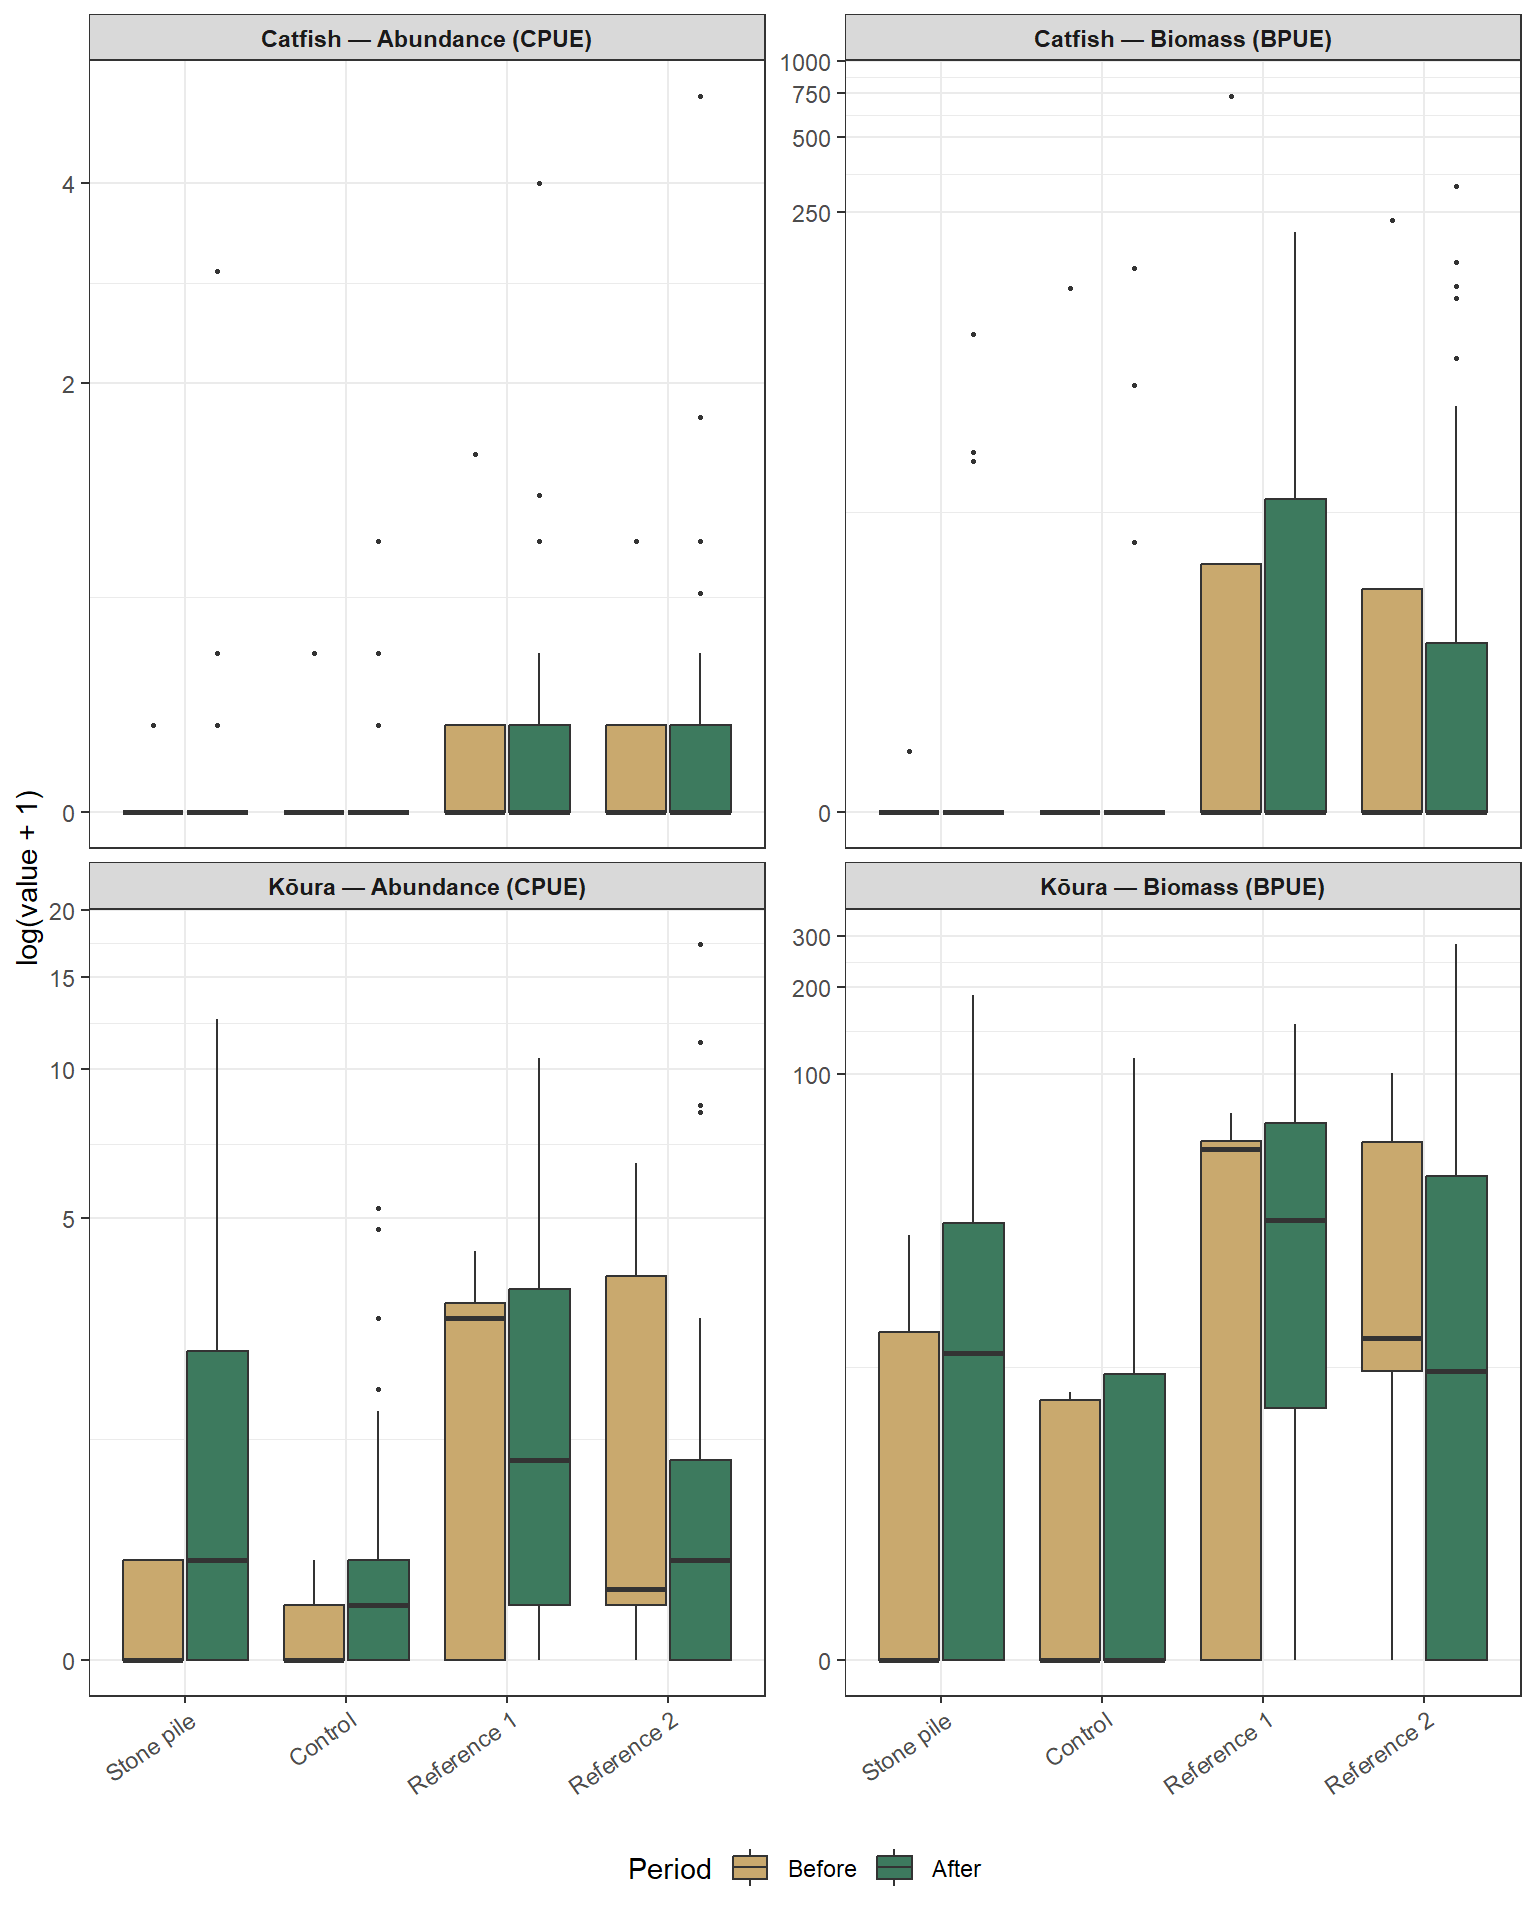

In [ ]:

before_after_combined <- dplyr::bind_rows(
  dplyr::mutate(rq1a_data,  period = "Before"),
  dplyr::mutate(rq2b_data,  period = "After"),
  dplyr::mutate(rq1b_data,  period = "Before"),
  dplyr::mutate(rq3b_data,  period = "After")) |>
  dplyr::mutate(
    period          = factor(period, levels = c("Before", "After")),
    Site_type_detail = factor(Site_type_detail,
      levels = c("Stone_pile", "Control", "Reference_1", "Reference_2")))

response_cols <- intersect(
  c(paste0("Weighted_CPUE_", all_species), paste0("Weighted_BPUE_", all_species)),
  names(before_after_combined))

before_after_long <- before_after_combined |>
  tidyr::pivot_longer(cols = dplyr::all_of(response_cols),
                      names_to = "response_var", values_to = "value") |>
  dplyr::mutate(
    species  = stringr::str_extract(response_var,
                 paste(all_species, collapse = "|")),
    response = dplyr::if_else(stringr::str_detect(response_var, "CPUE"),
                              "Abundance (CPUE)", "Biomass (BPUE)"),
    panel    = factor(paste0(species, " — ", response),
                levels = c(paste0(all_species[1], " — Abundance (CPUE)"),
                           paste0(all_species[1], " — Biomass (BPUE)"),
                           paste0(all_species[2], " — Abundance (CPUE)"),
                           paste0(all_species[2], " — Biomass (BPUE)"))))

ggplot2::ggplot(before_after_long,
    ggplot2::aes(x = Site_type_detail, y = value, fill = period)) +
  ggplot2::geom_boxplot(outlier.size = 0.6,
                        position = ggplot2::position_dodge(0.8)) +
  ggplot2::facet_wrap(~ panel, scales = "free_y", ncol = 2) +
  ggplot2::scale_fill_manual(values = c("Before" = "#c9a96e", "After" = "#3d7a5e")) +
  ggplot2::scale_x_discrete(labels = c(
    "Stone_pile"  = "Stone pile",
    "Control"     = "Control",
    "Reference_1" = "Reference 1",
    "Reference_2" = "Reference 2")) +
  ggplot2::scale_y_continuous(trans = "log1p") +
  ggplot2::labs(x = NULL, y = "log(value + 1)", fill = "Period") +
  ggplot2::theme_bw() +
  ggplot2::theme(
    strip.text      = ggplot2::element_text(face = "bold"),
    axis.text.x     = ggplot2::element_text(angle = 35, hjust = 1),
    legend.position = "bottom")


## Model diagnostics

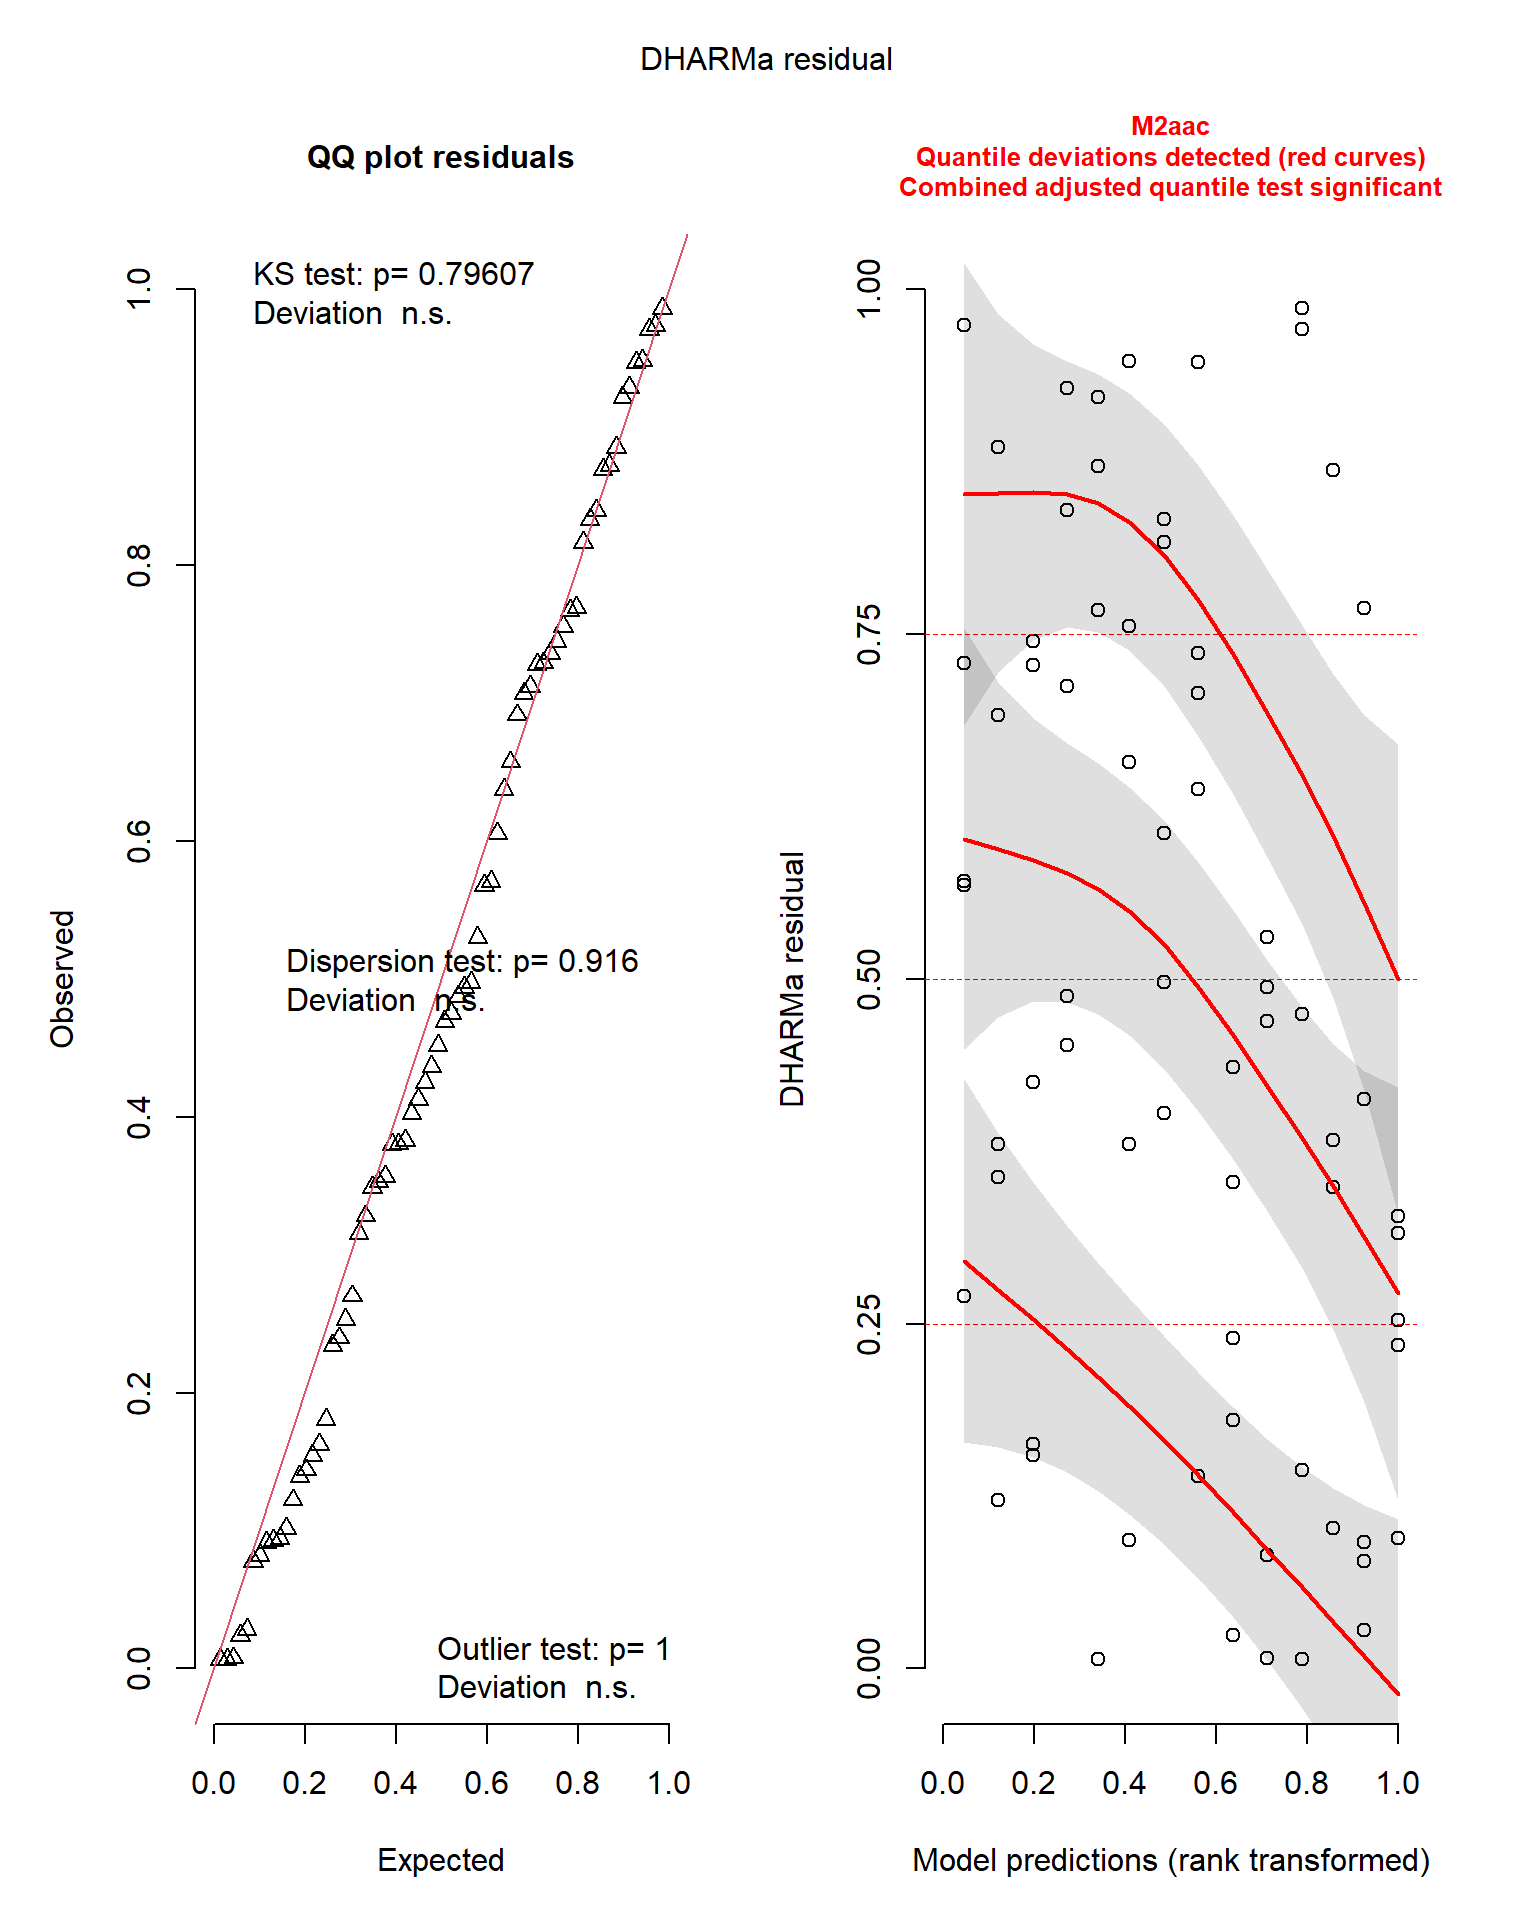

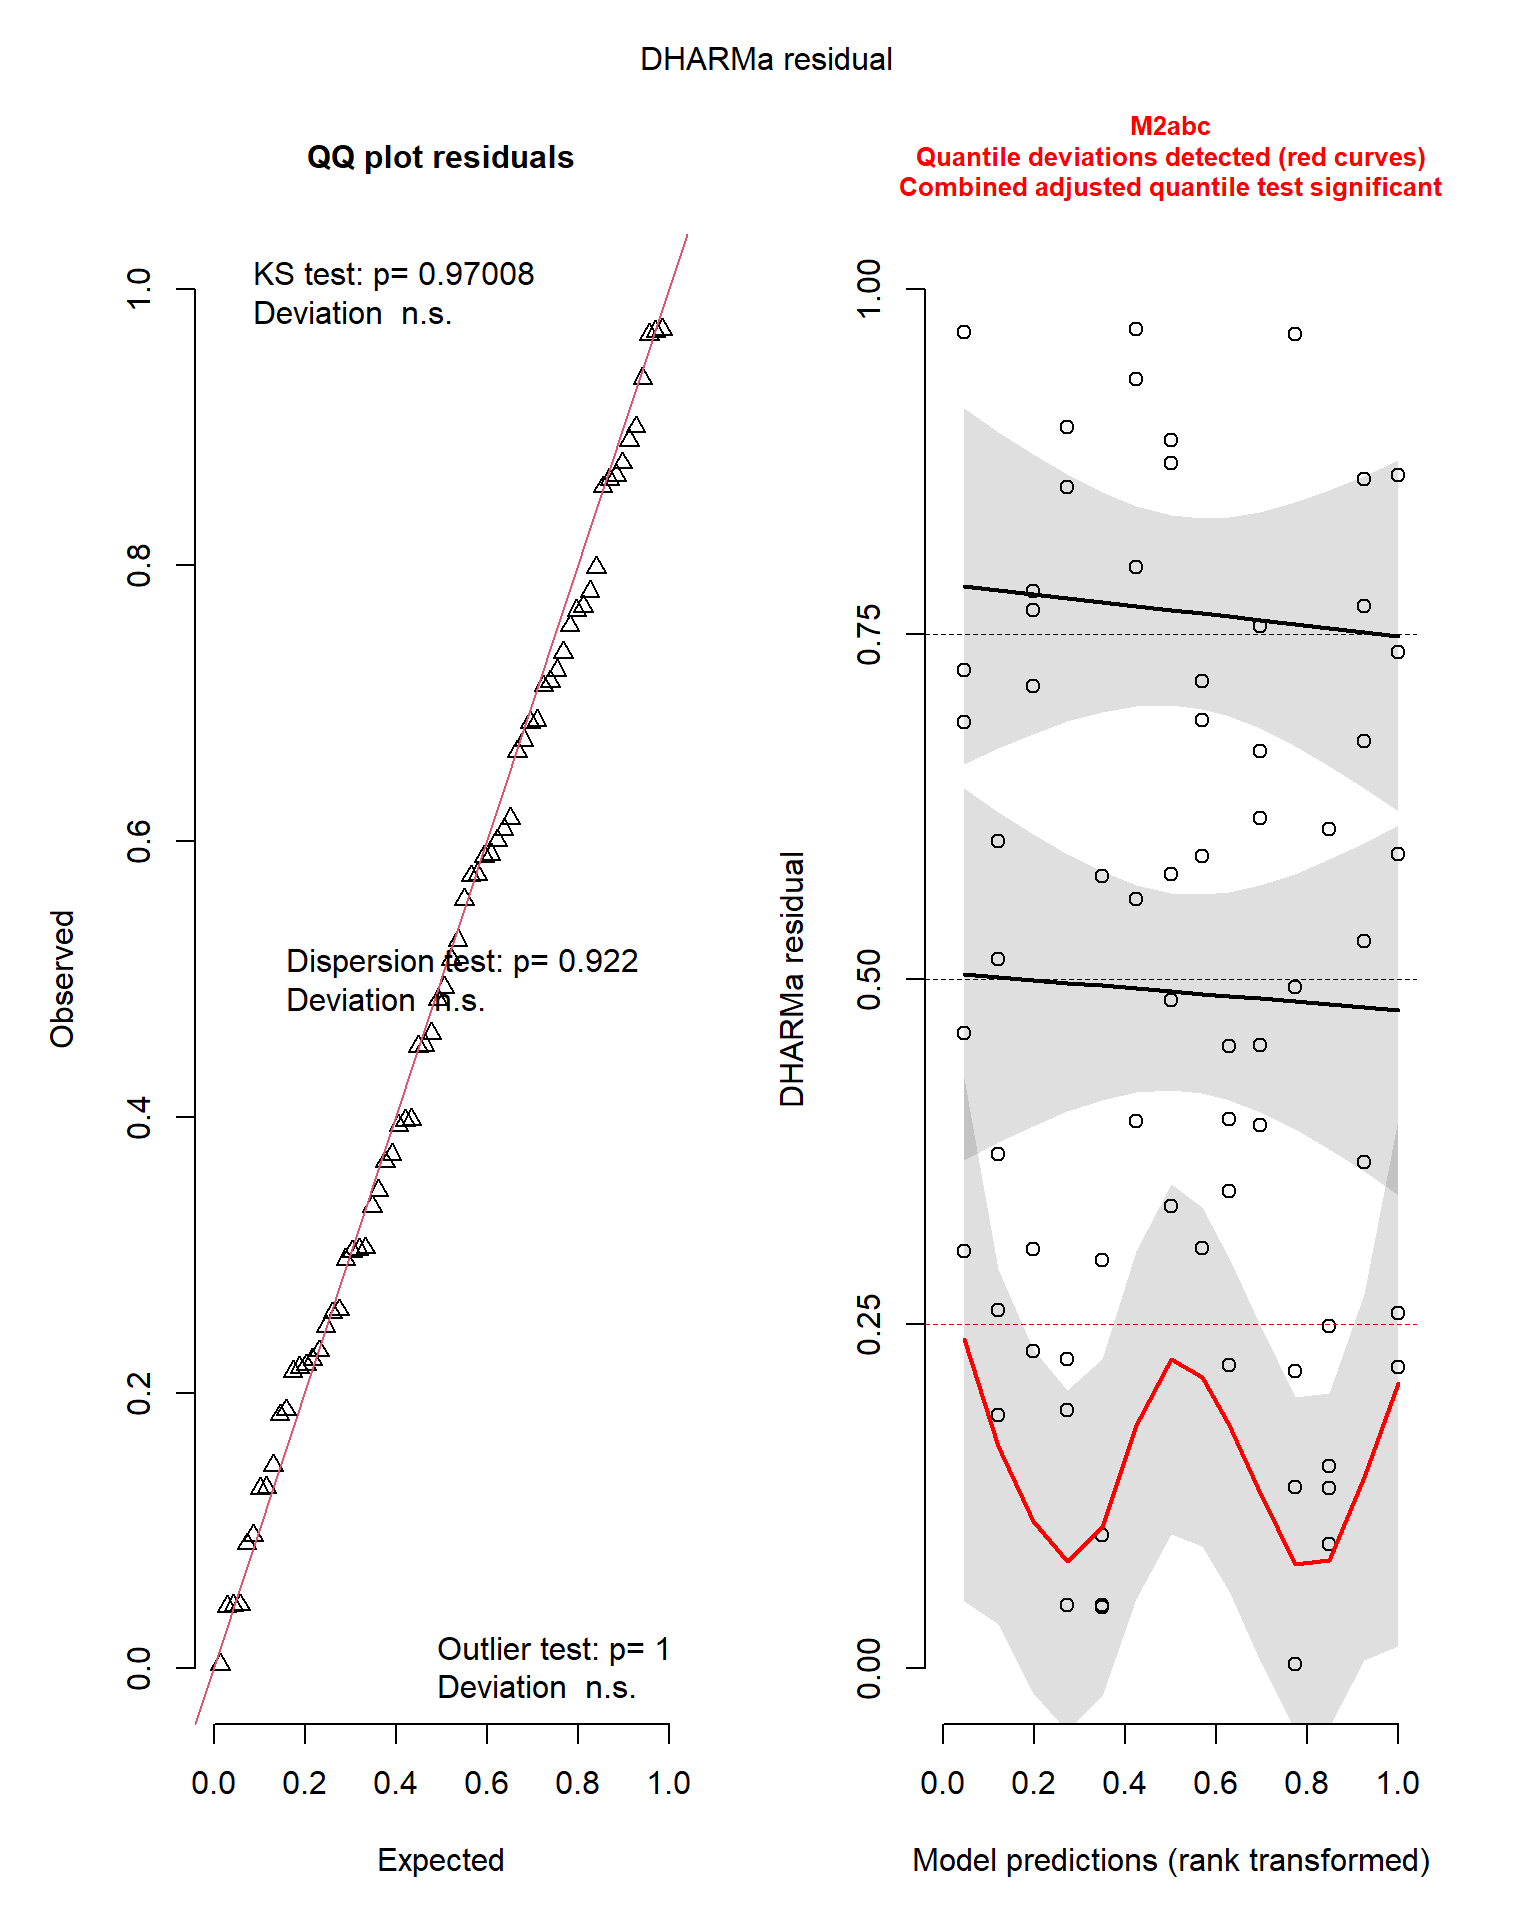

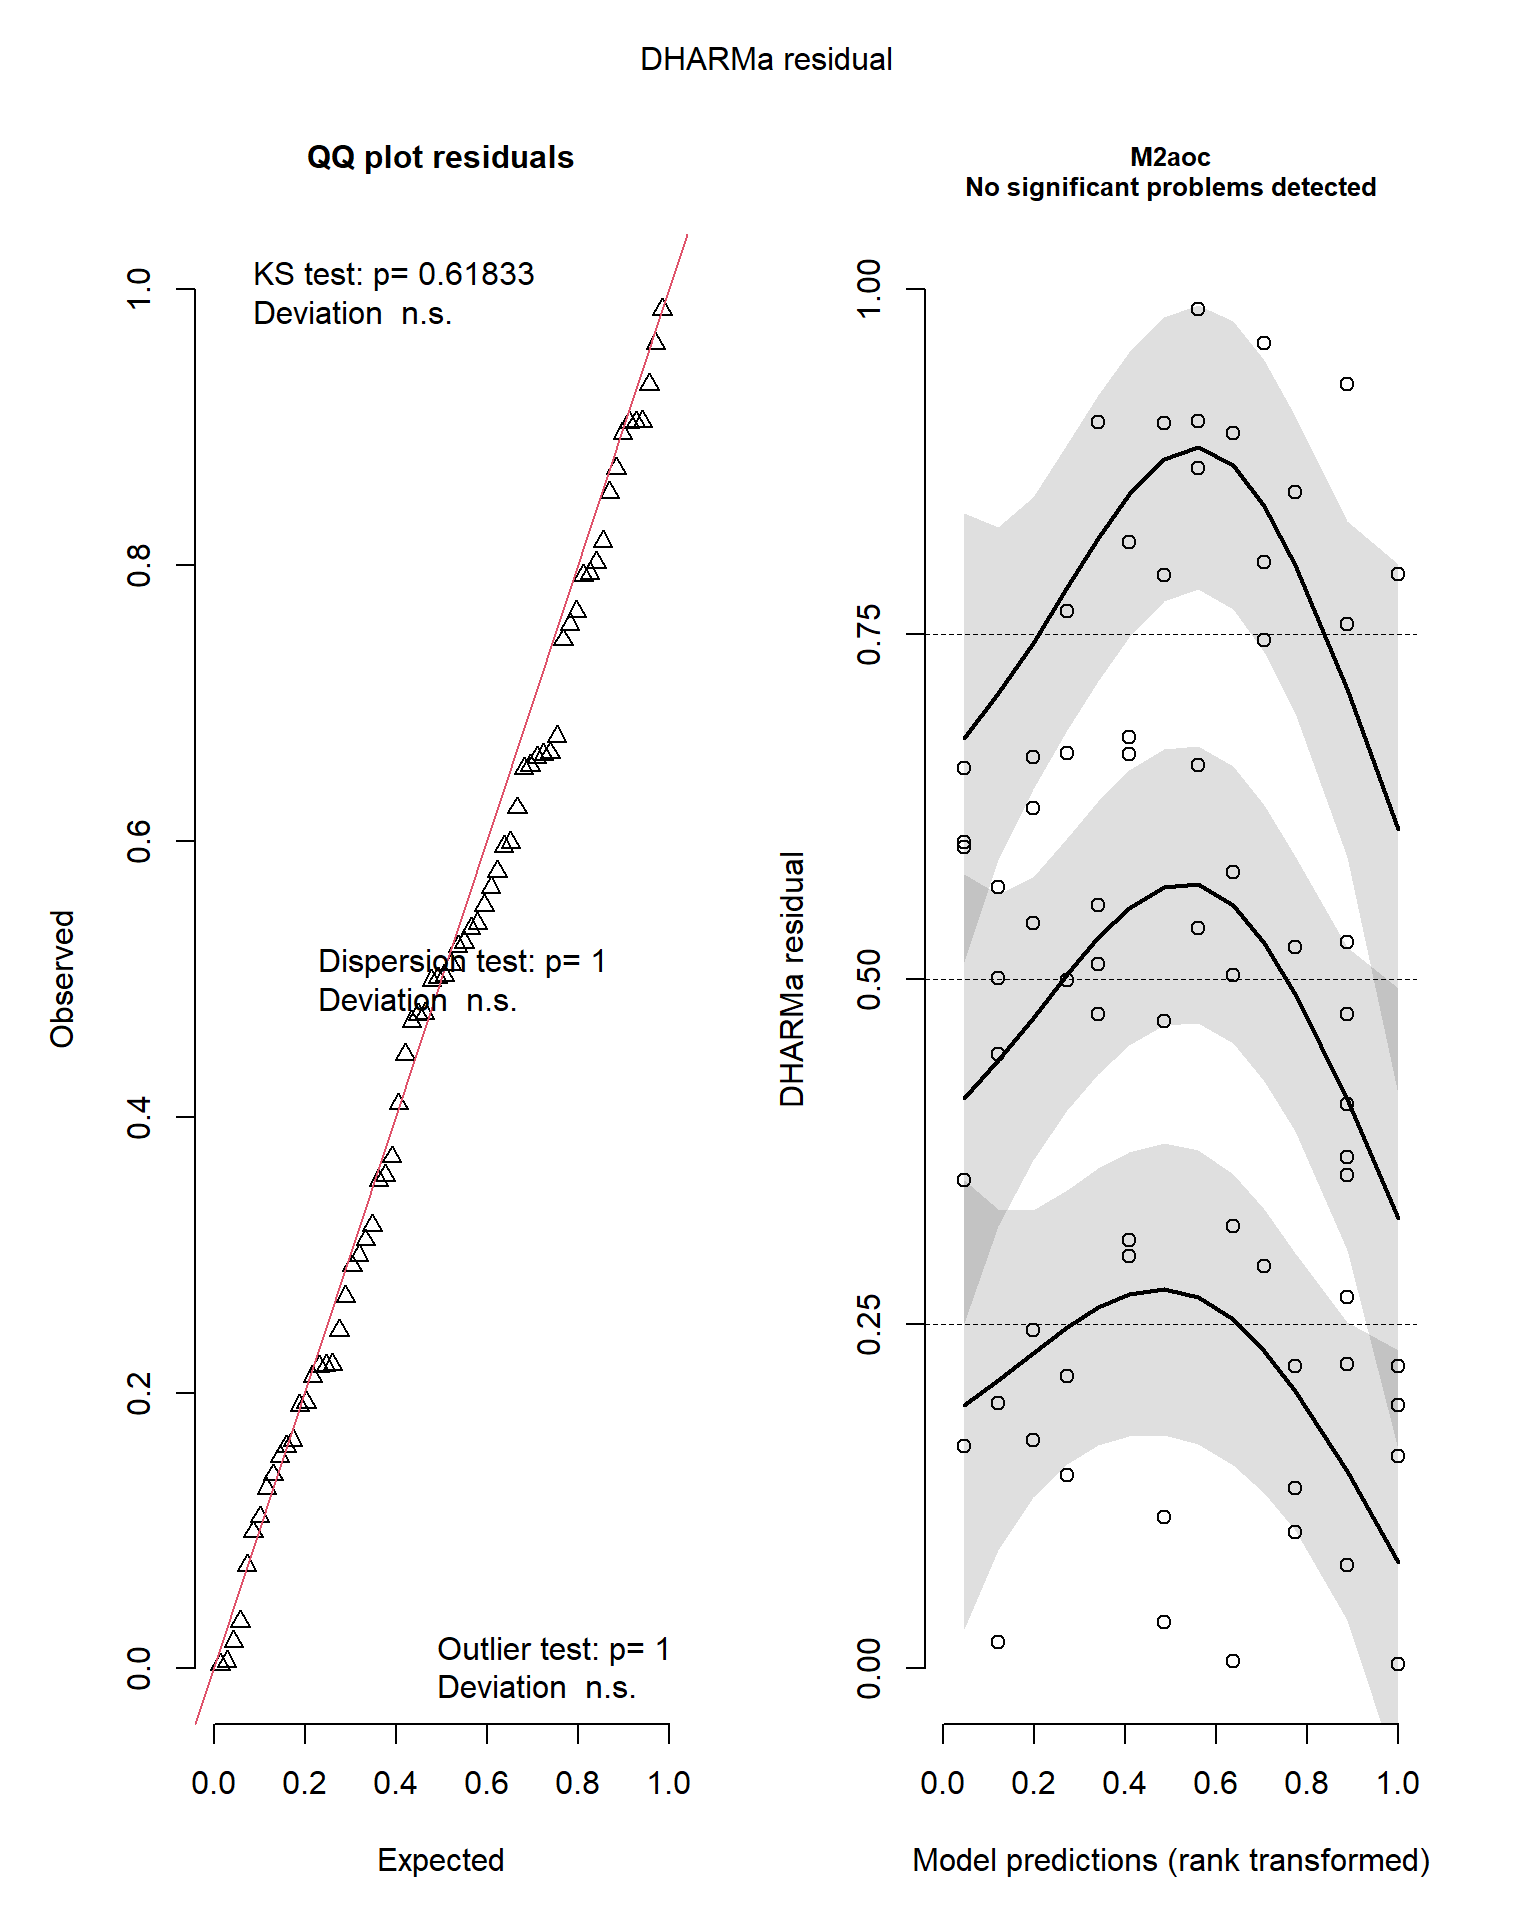

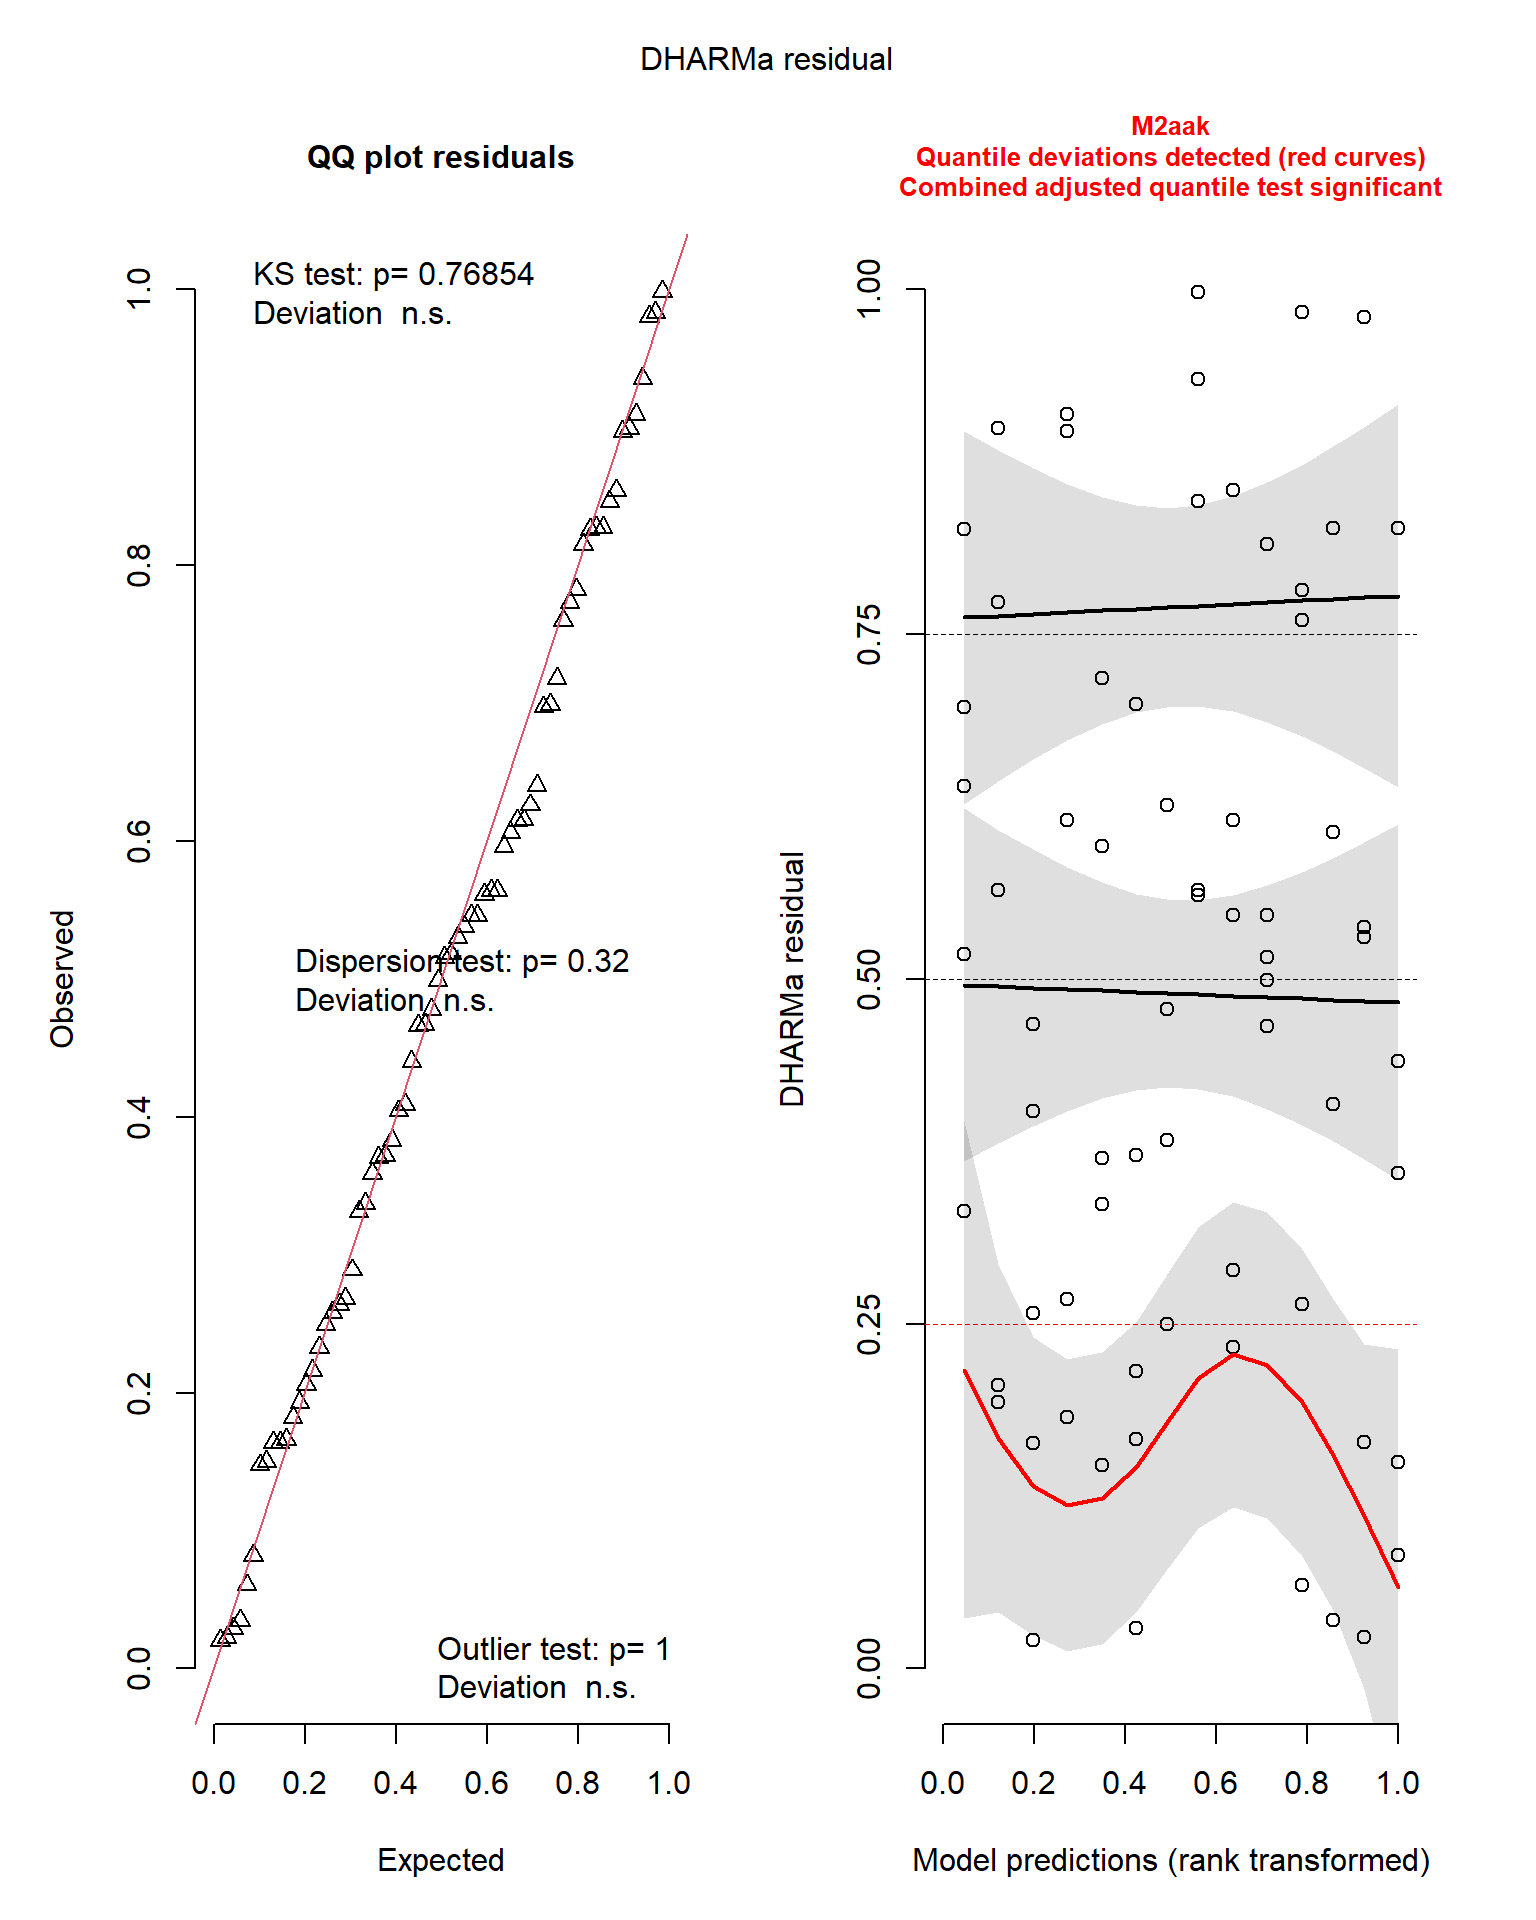

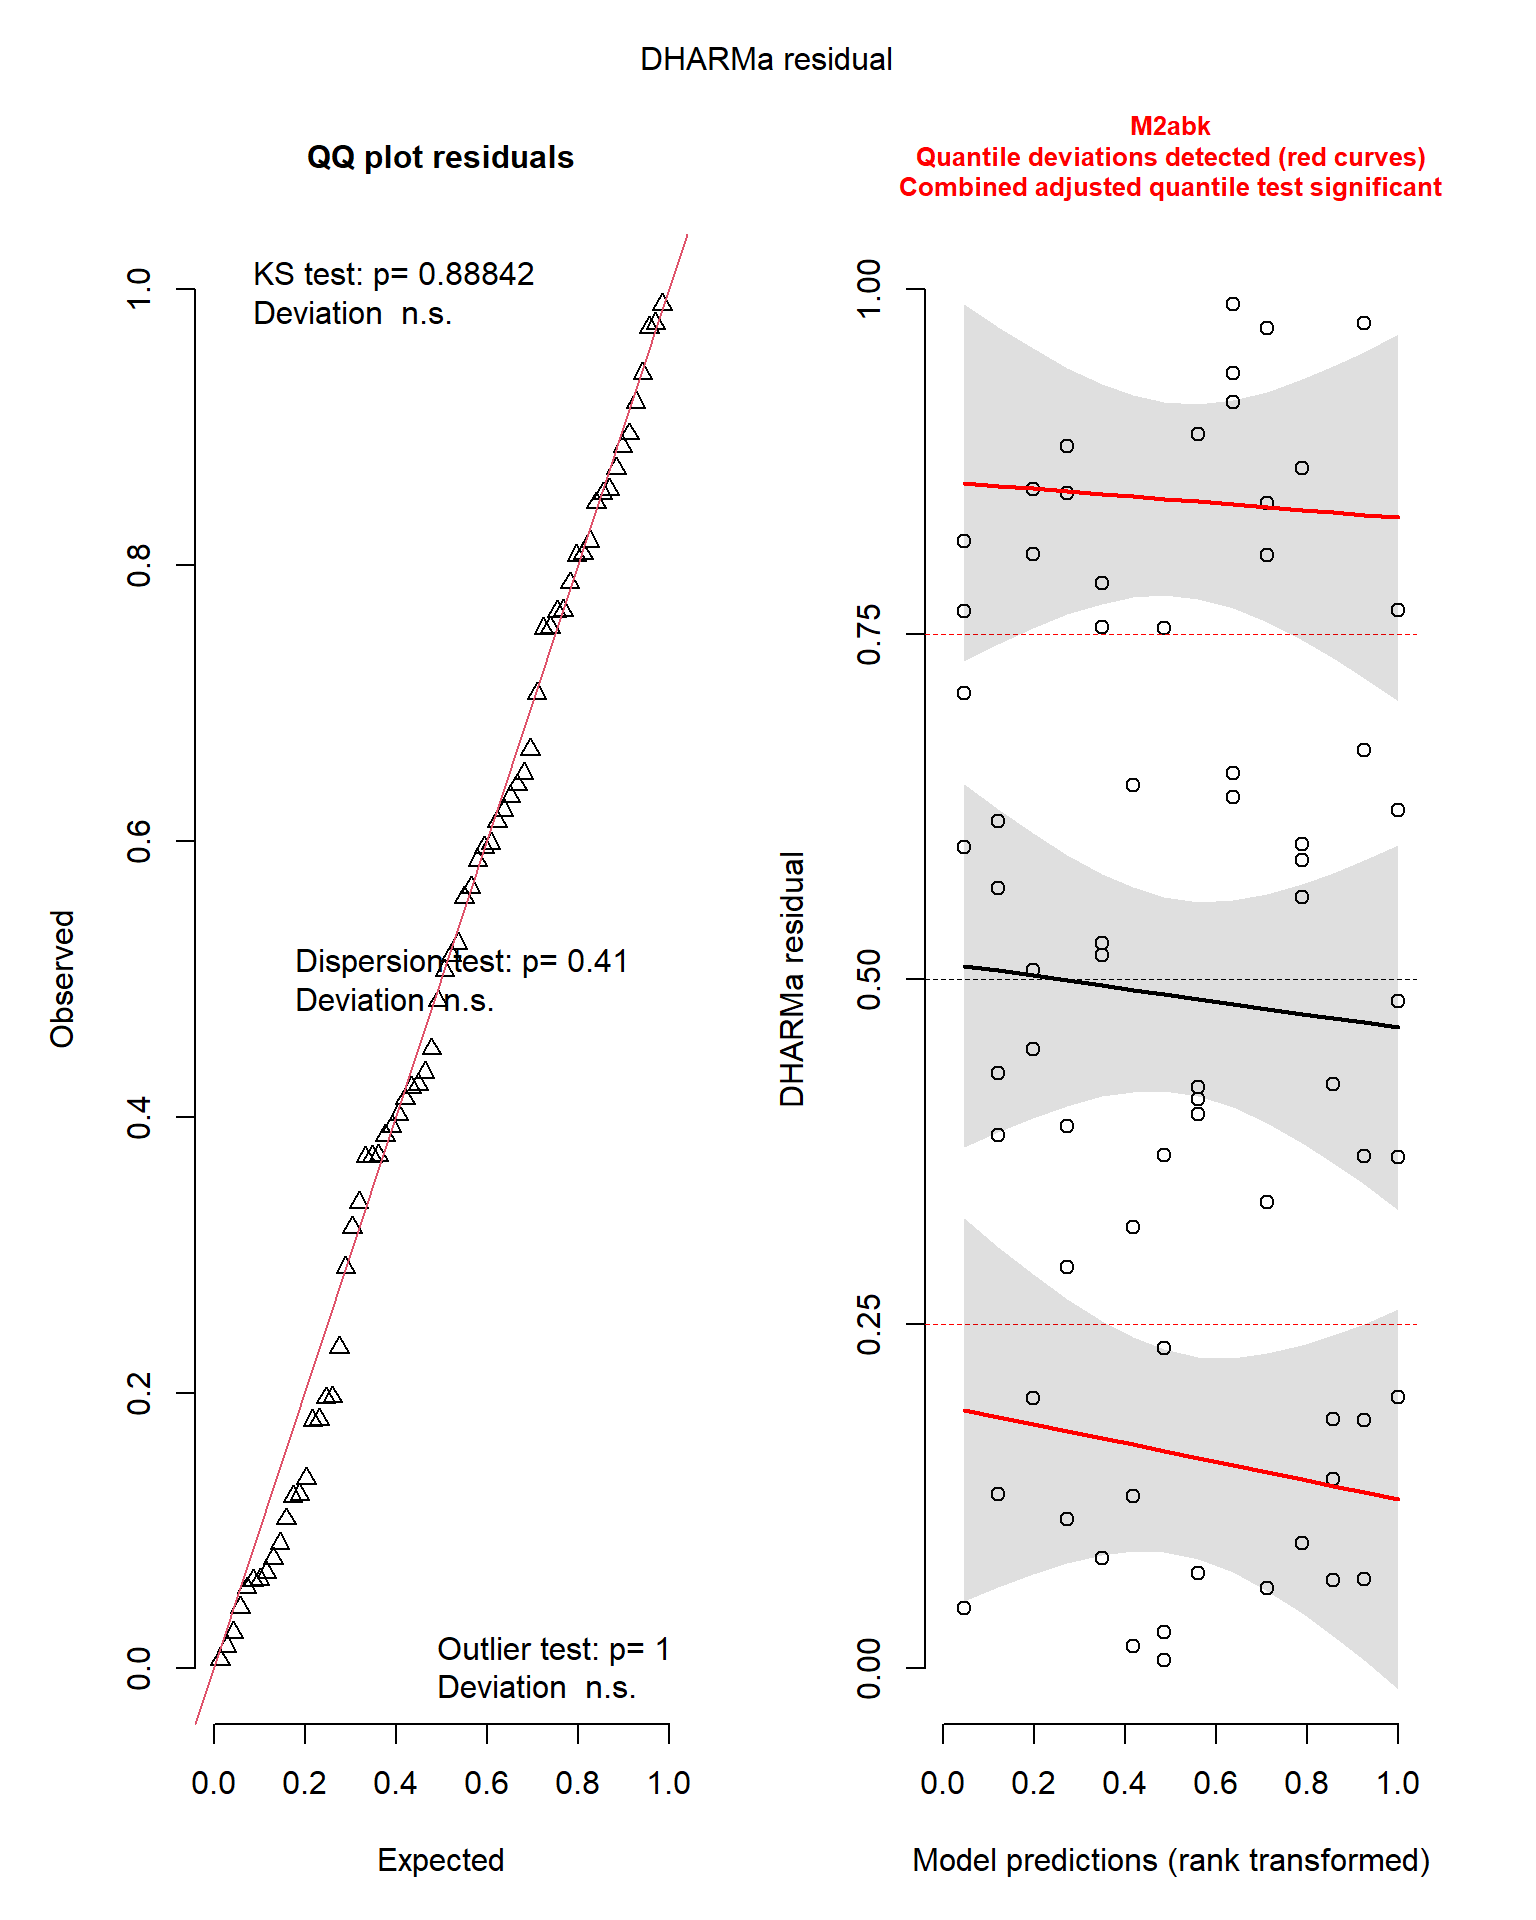

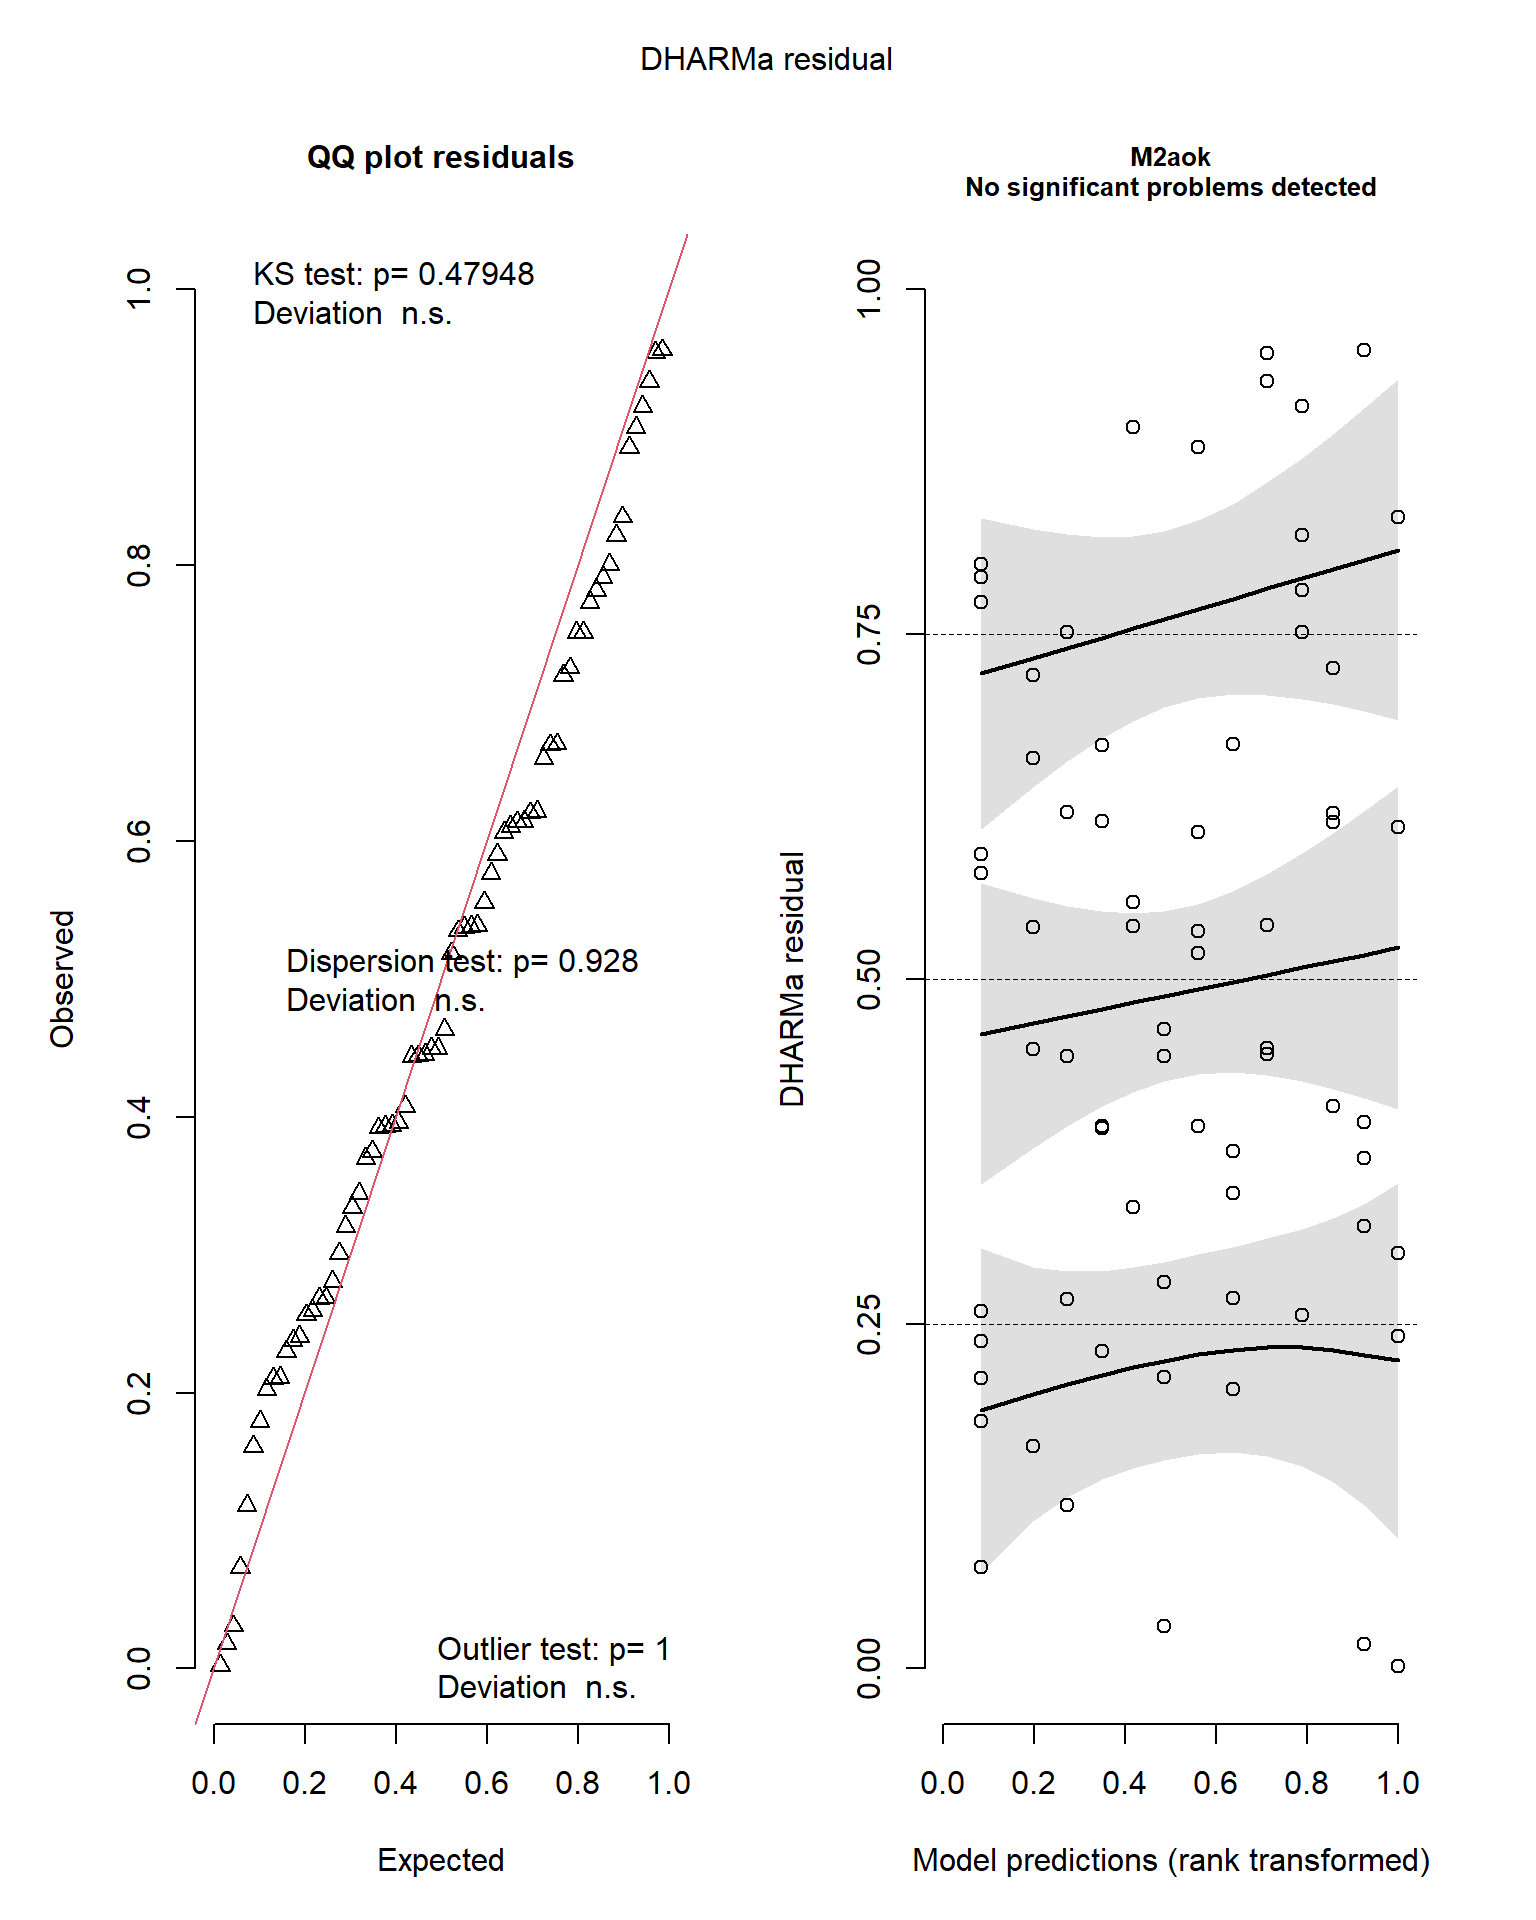

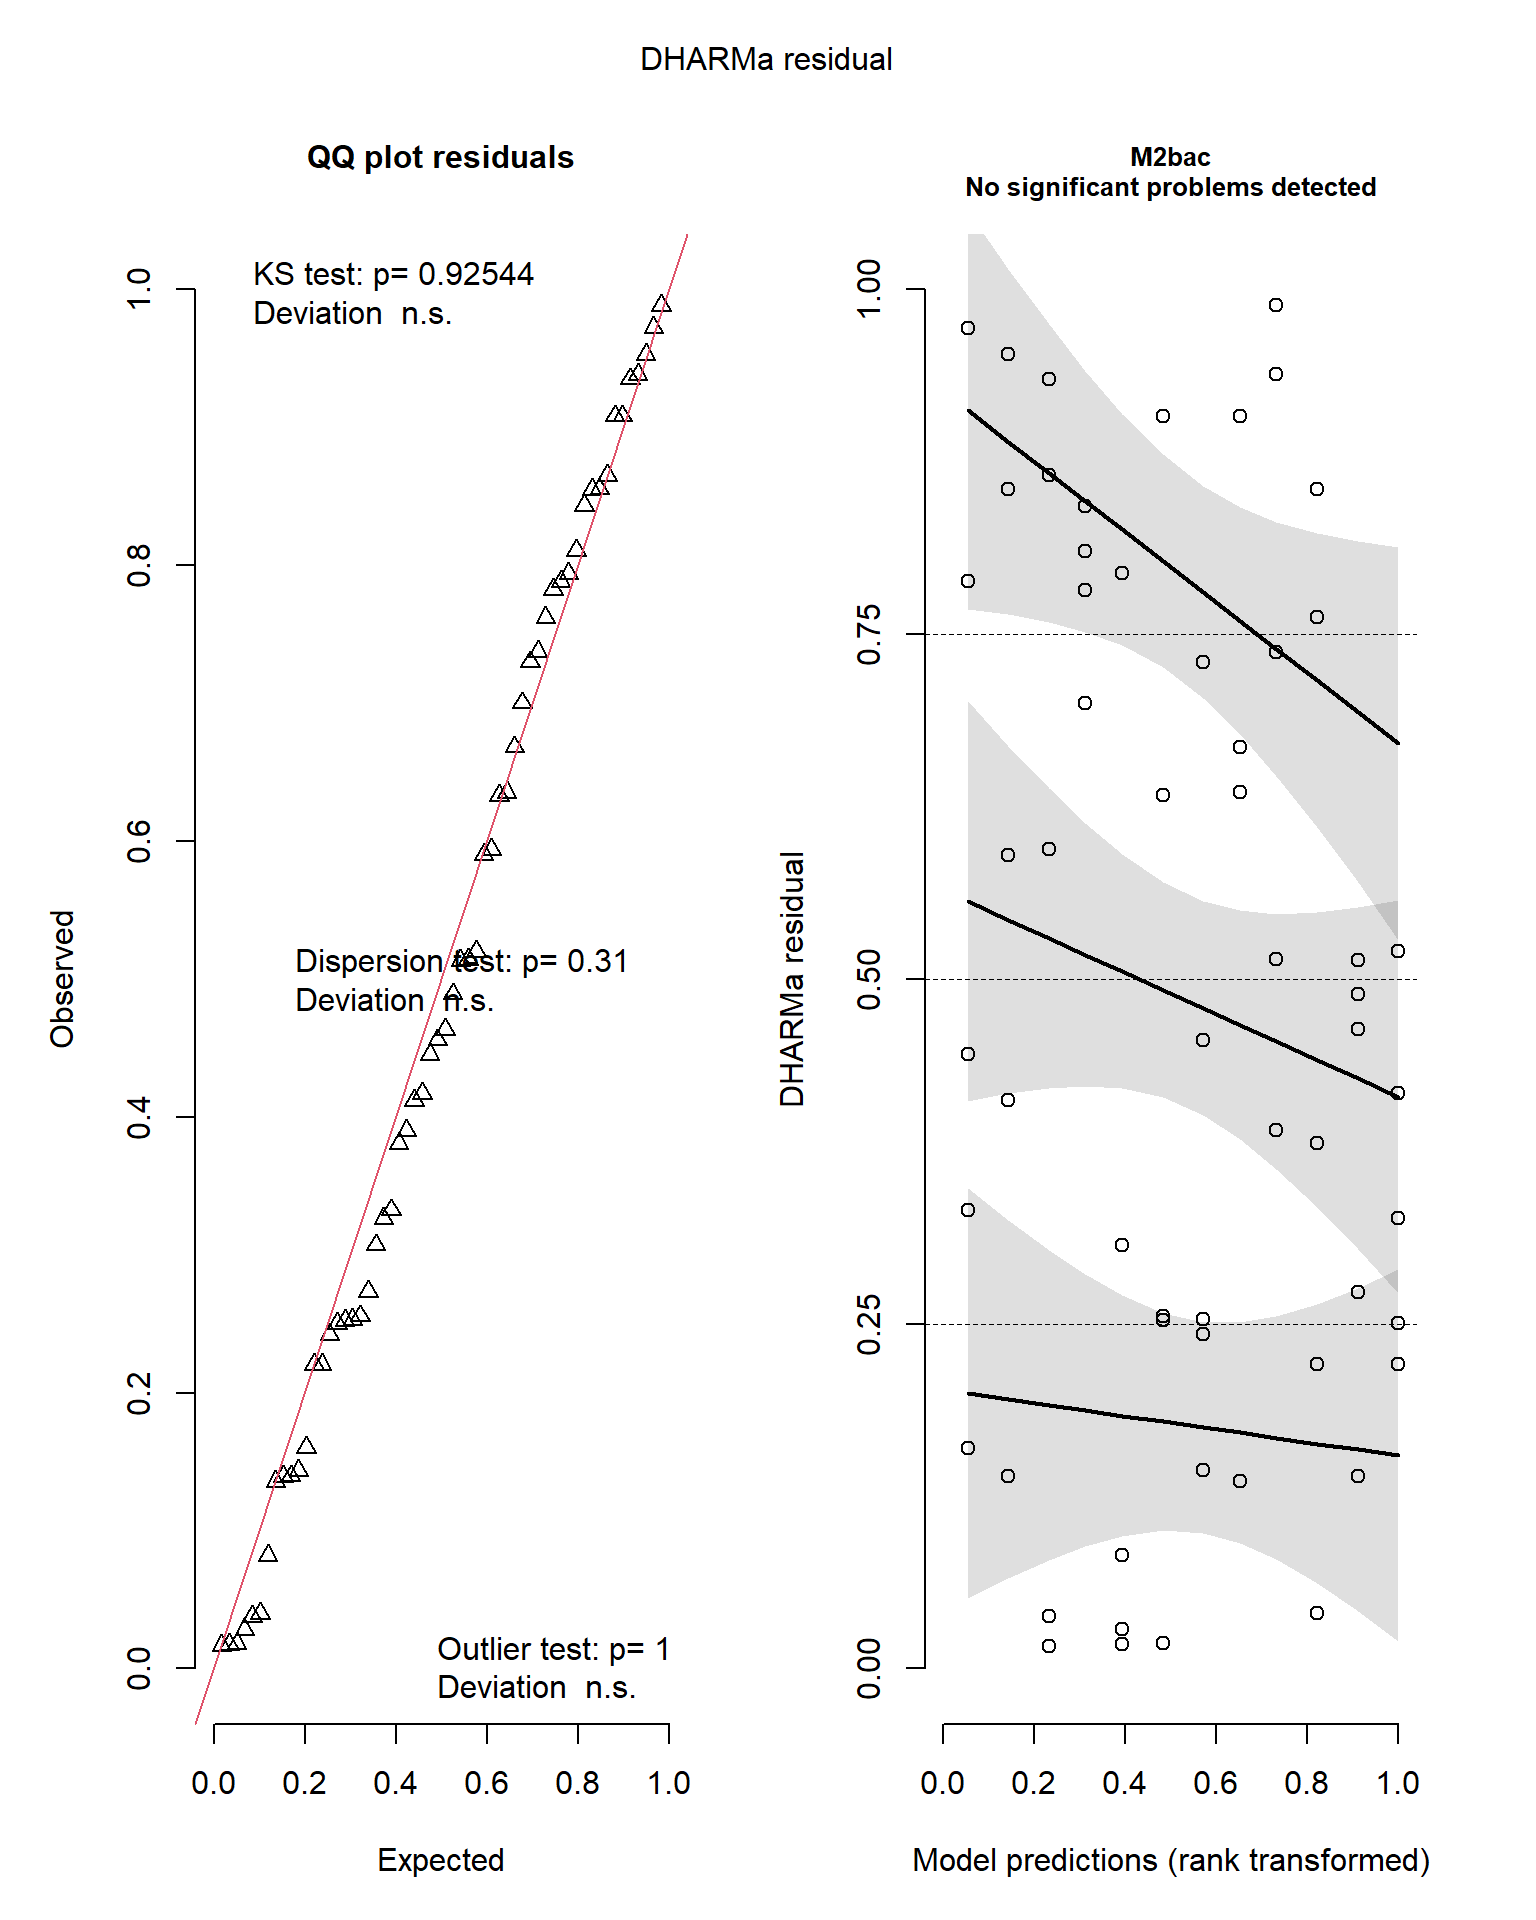

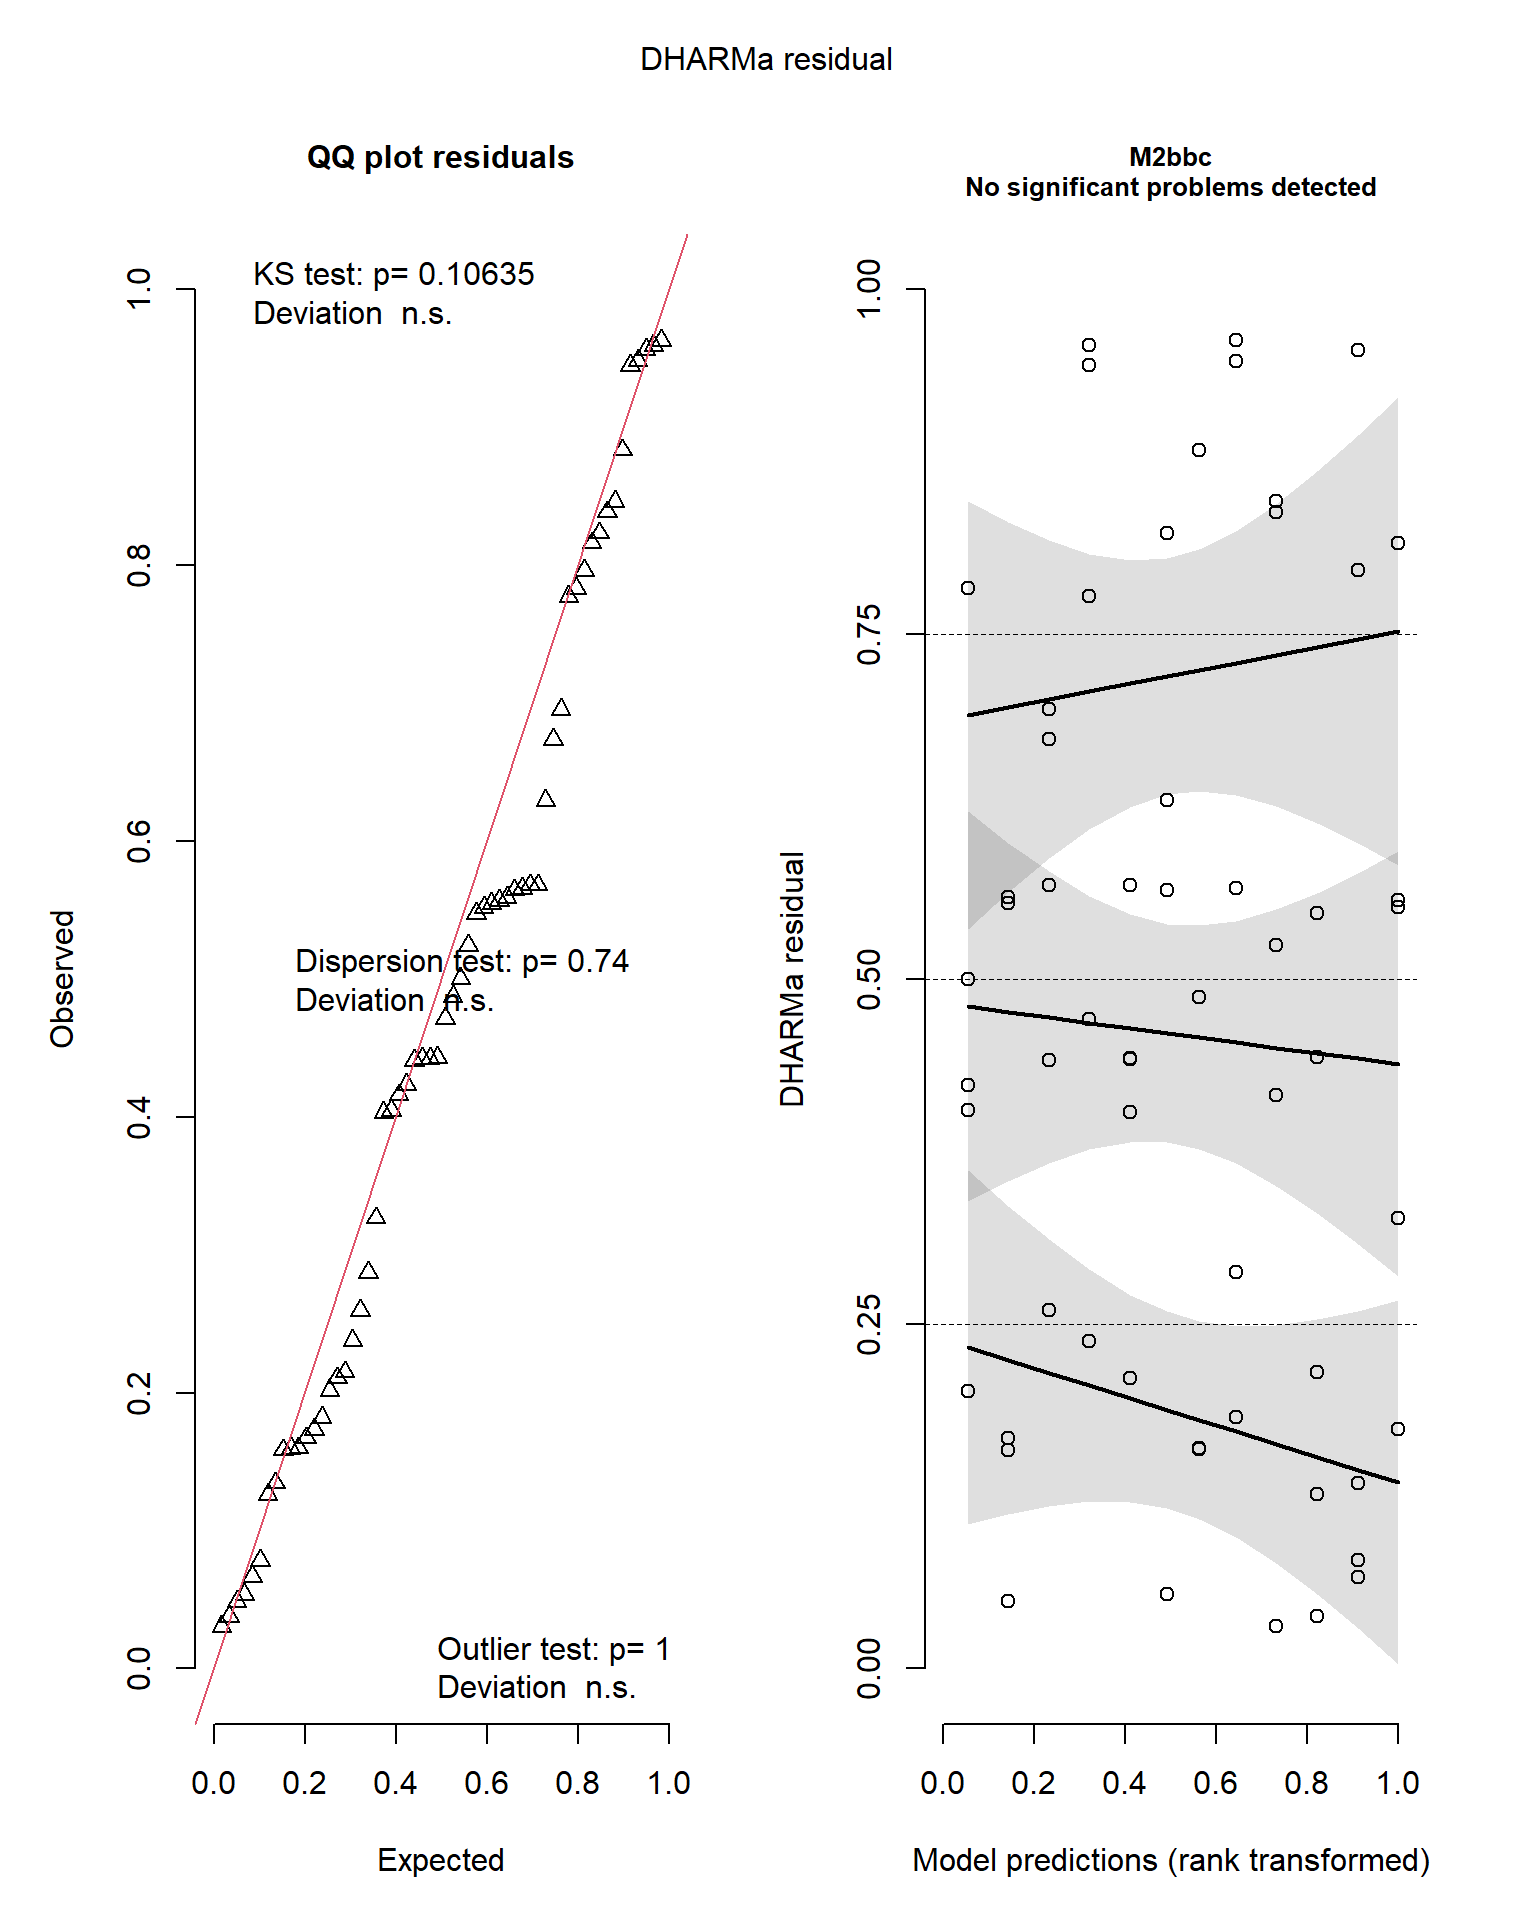

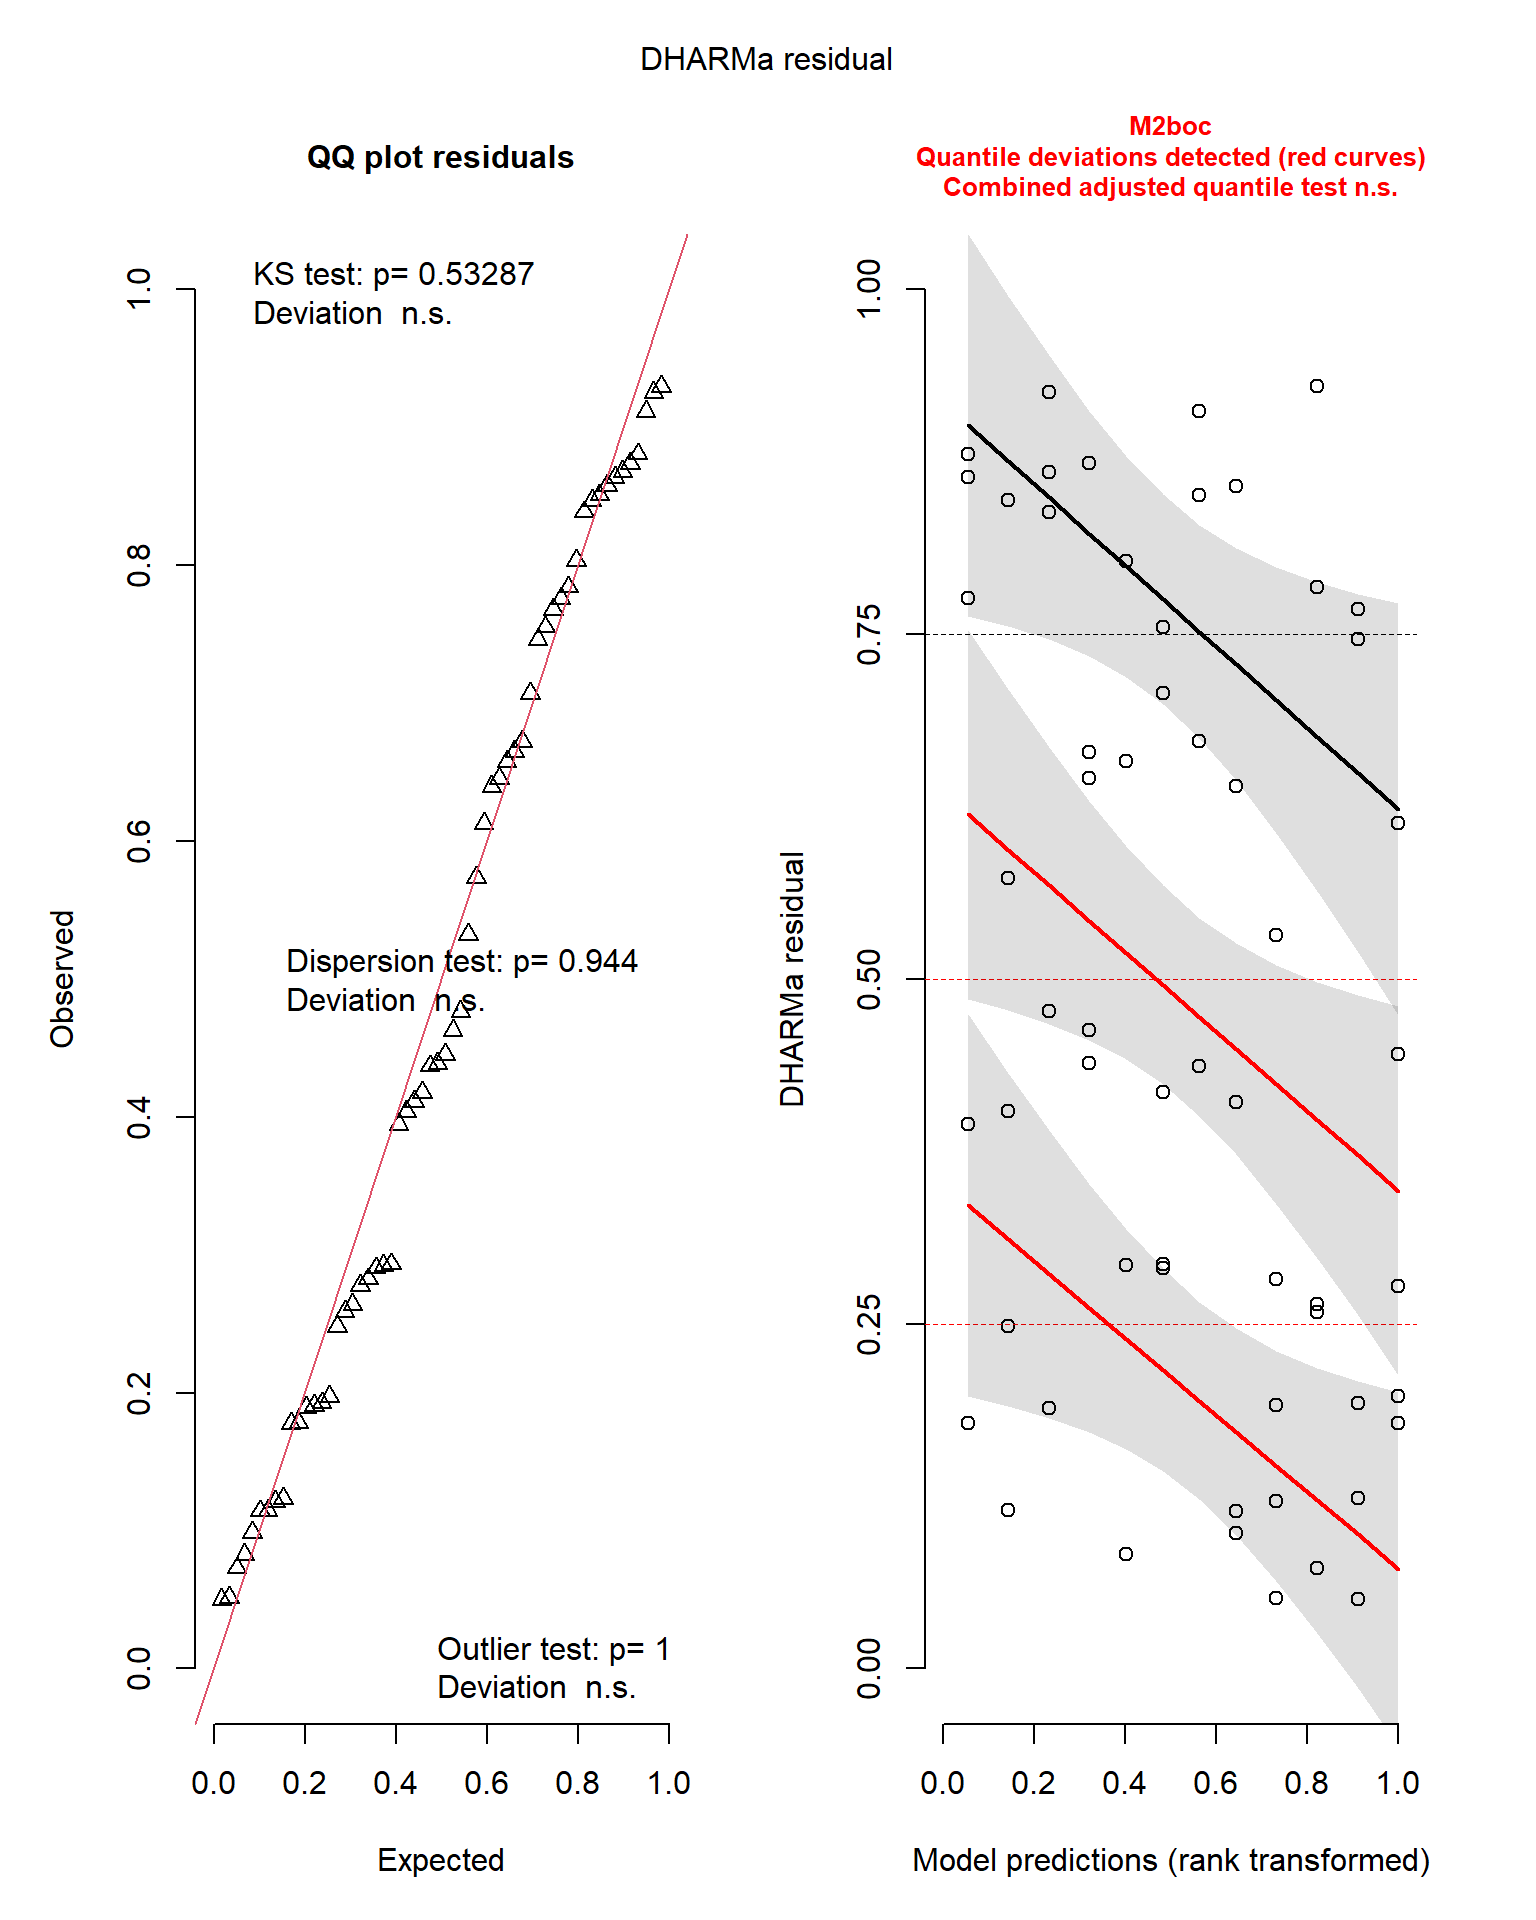

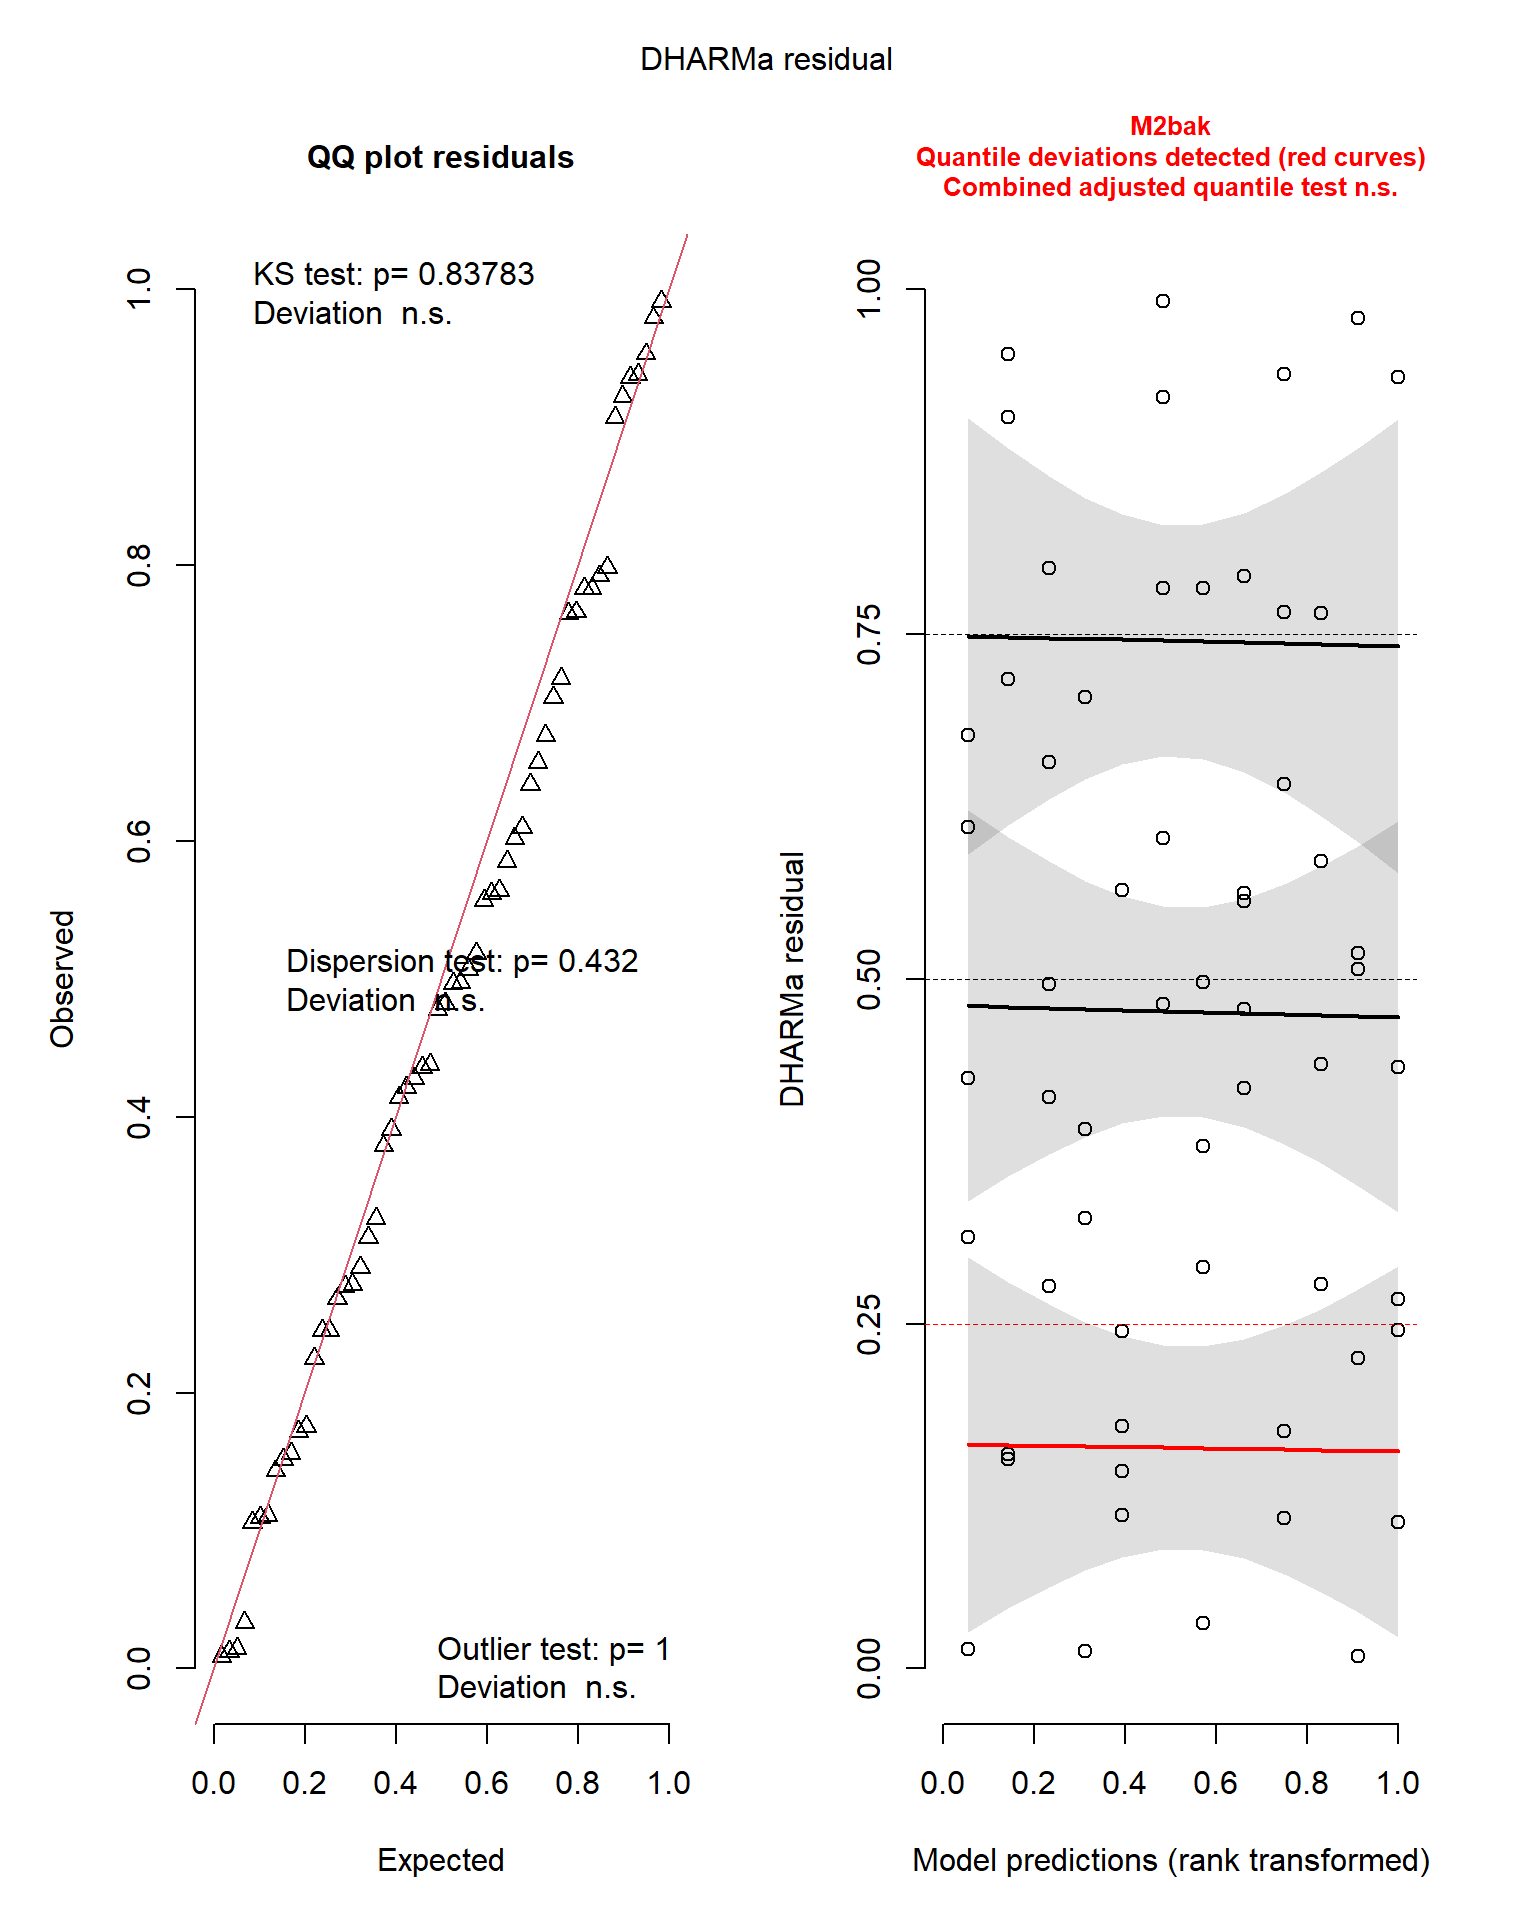

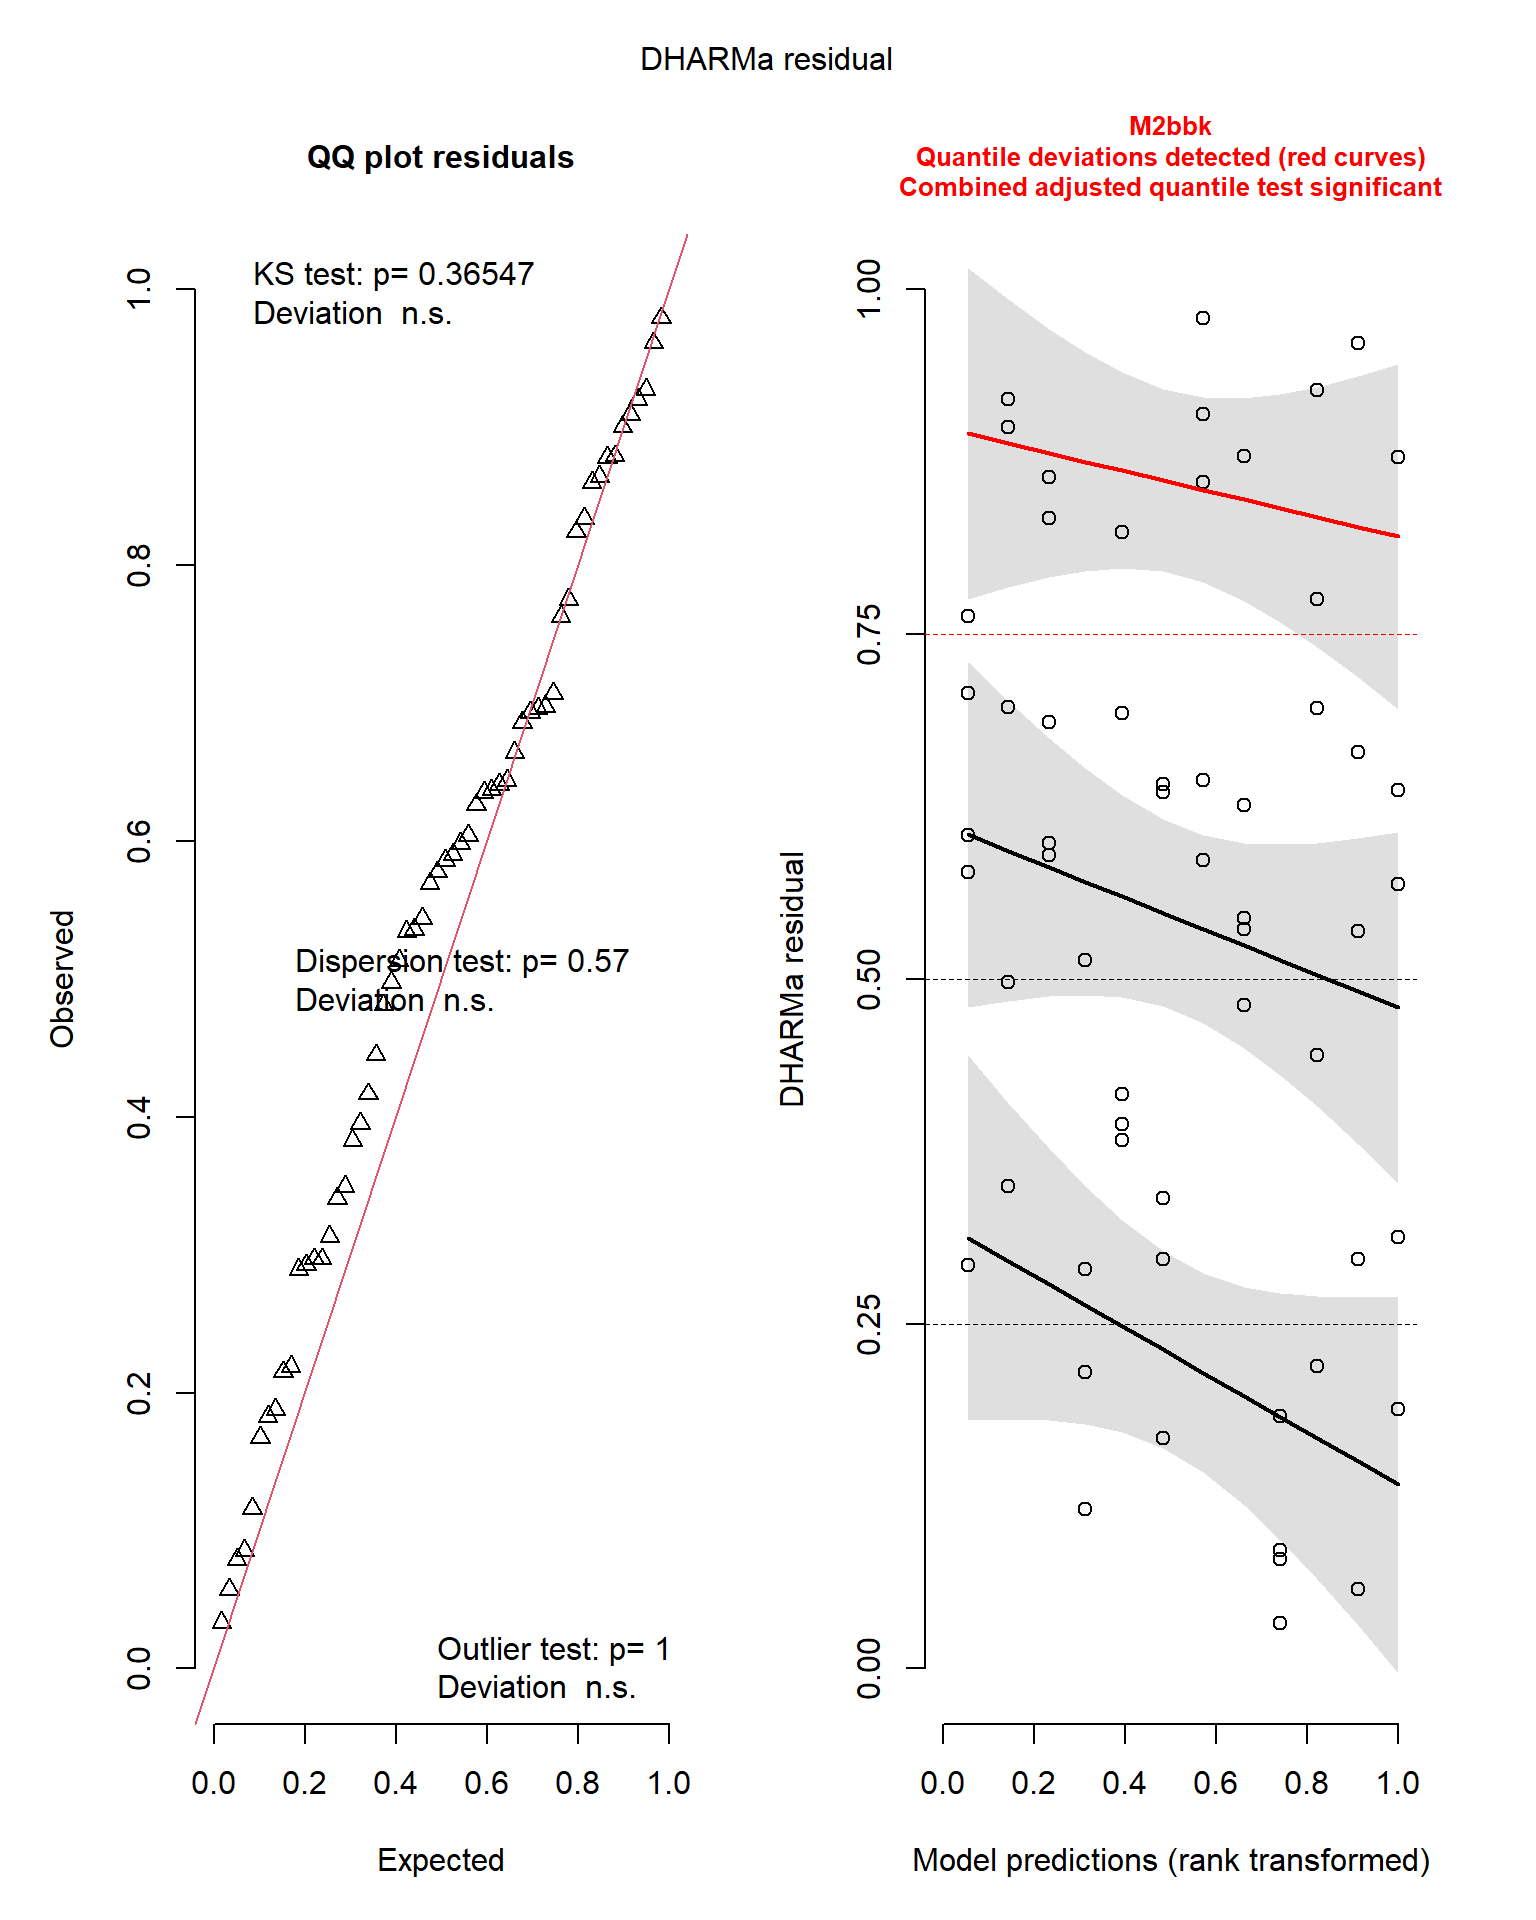

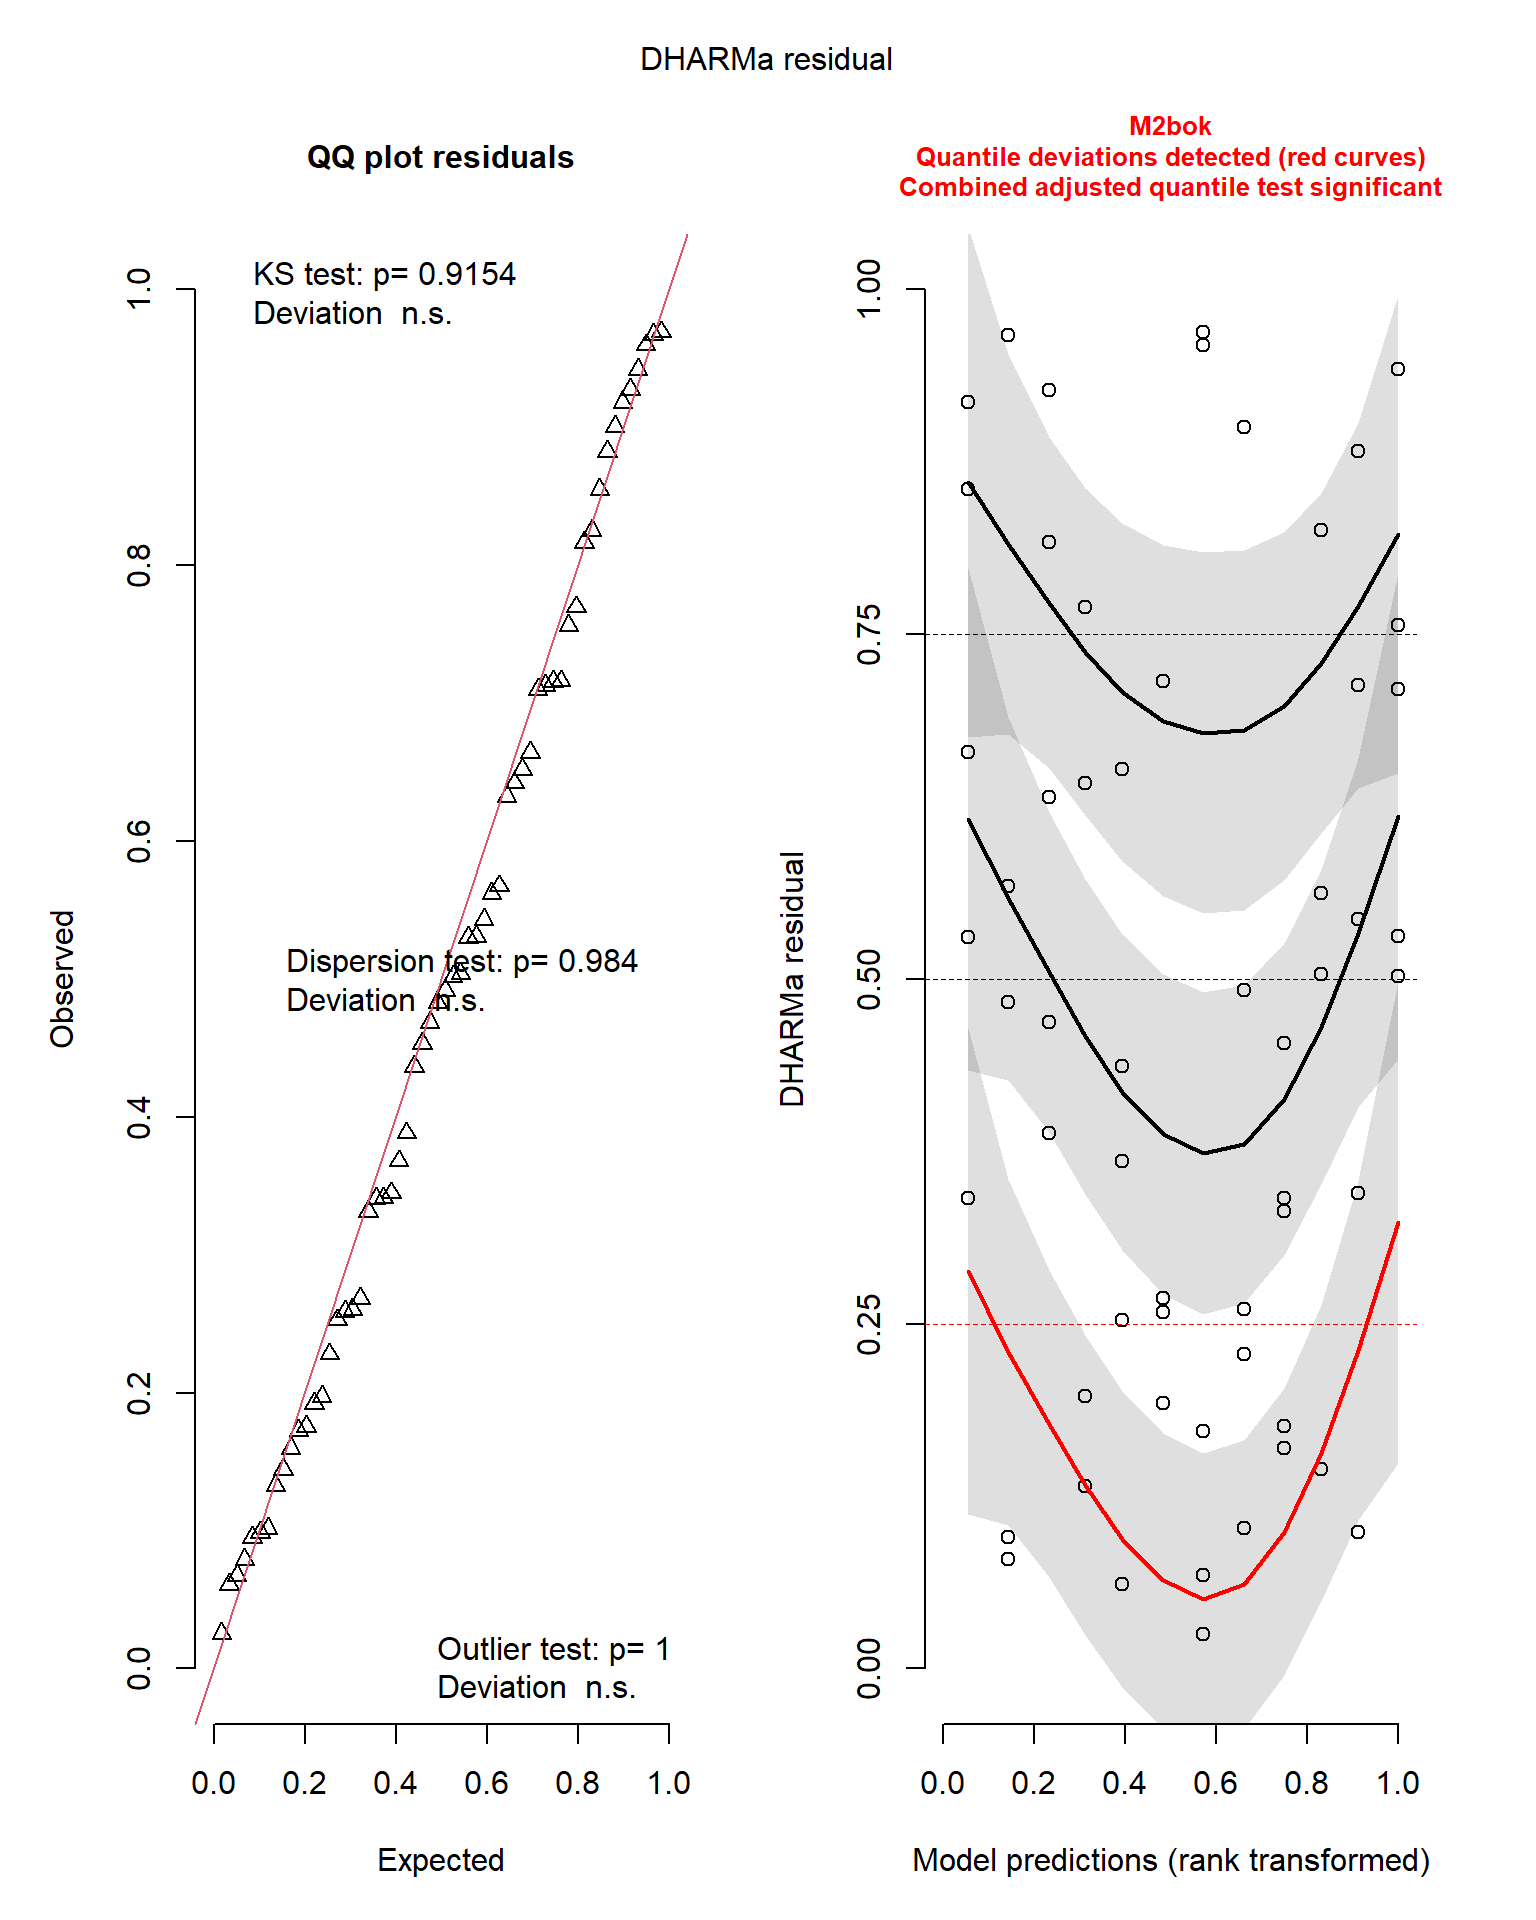

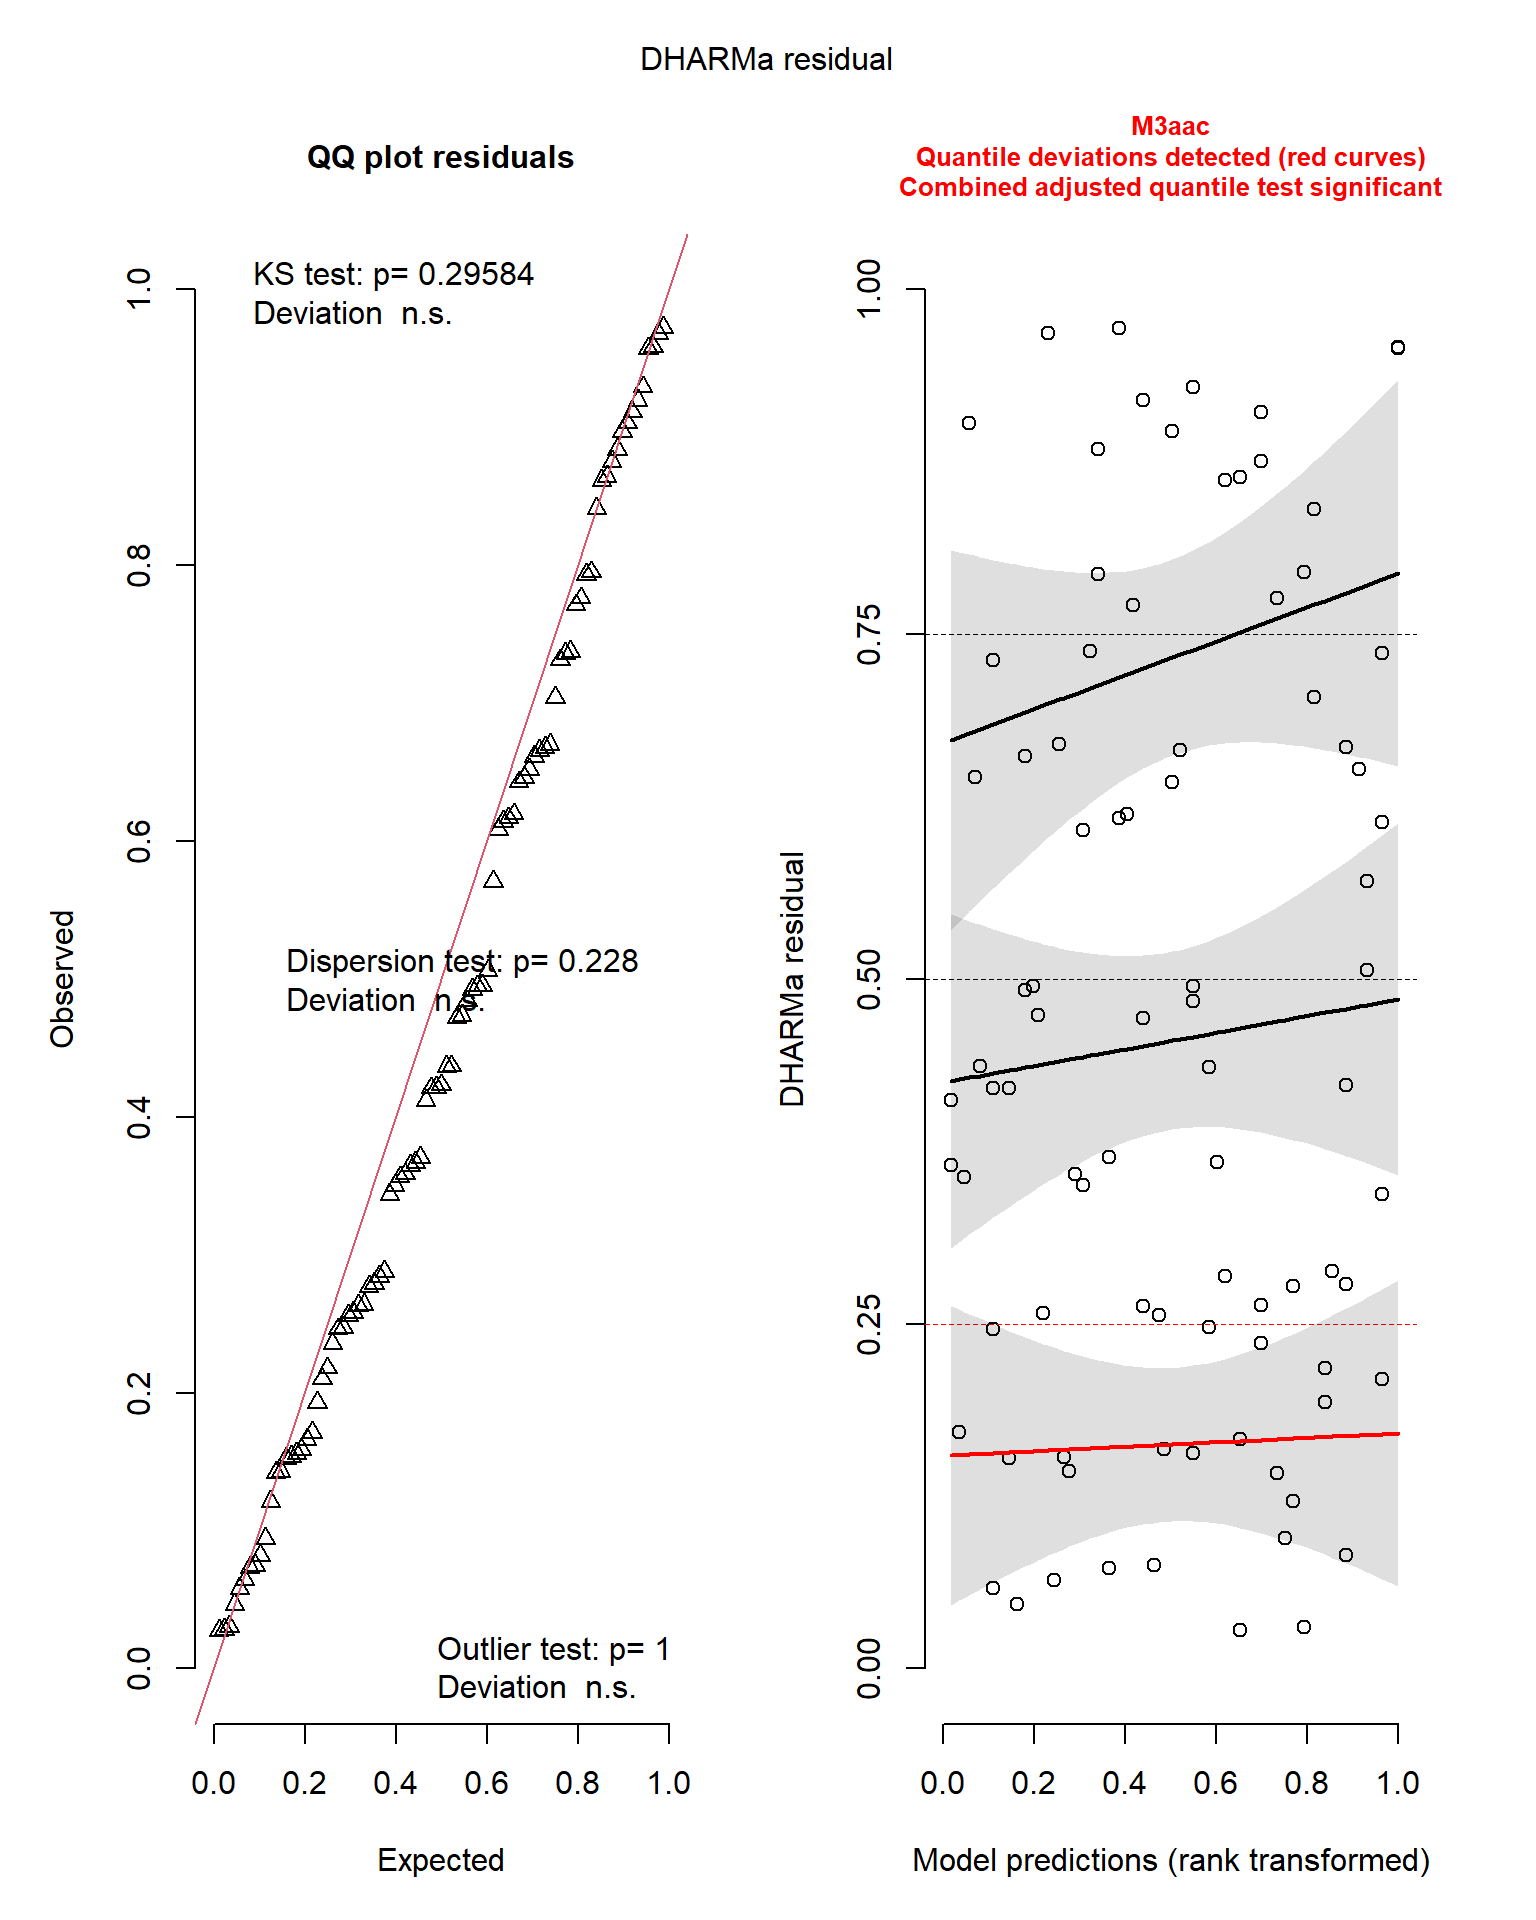

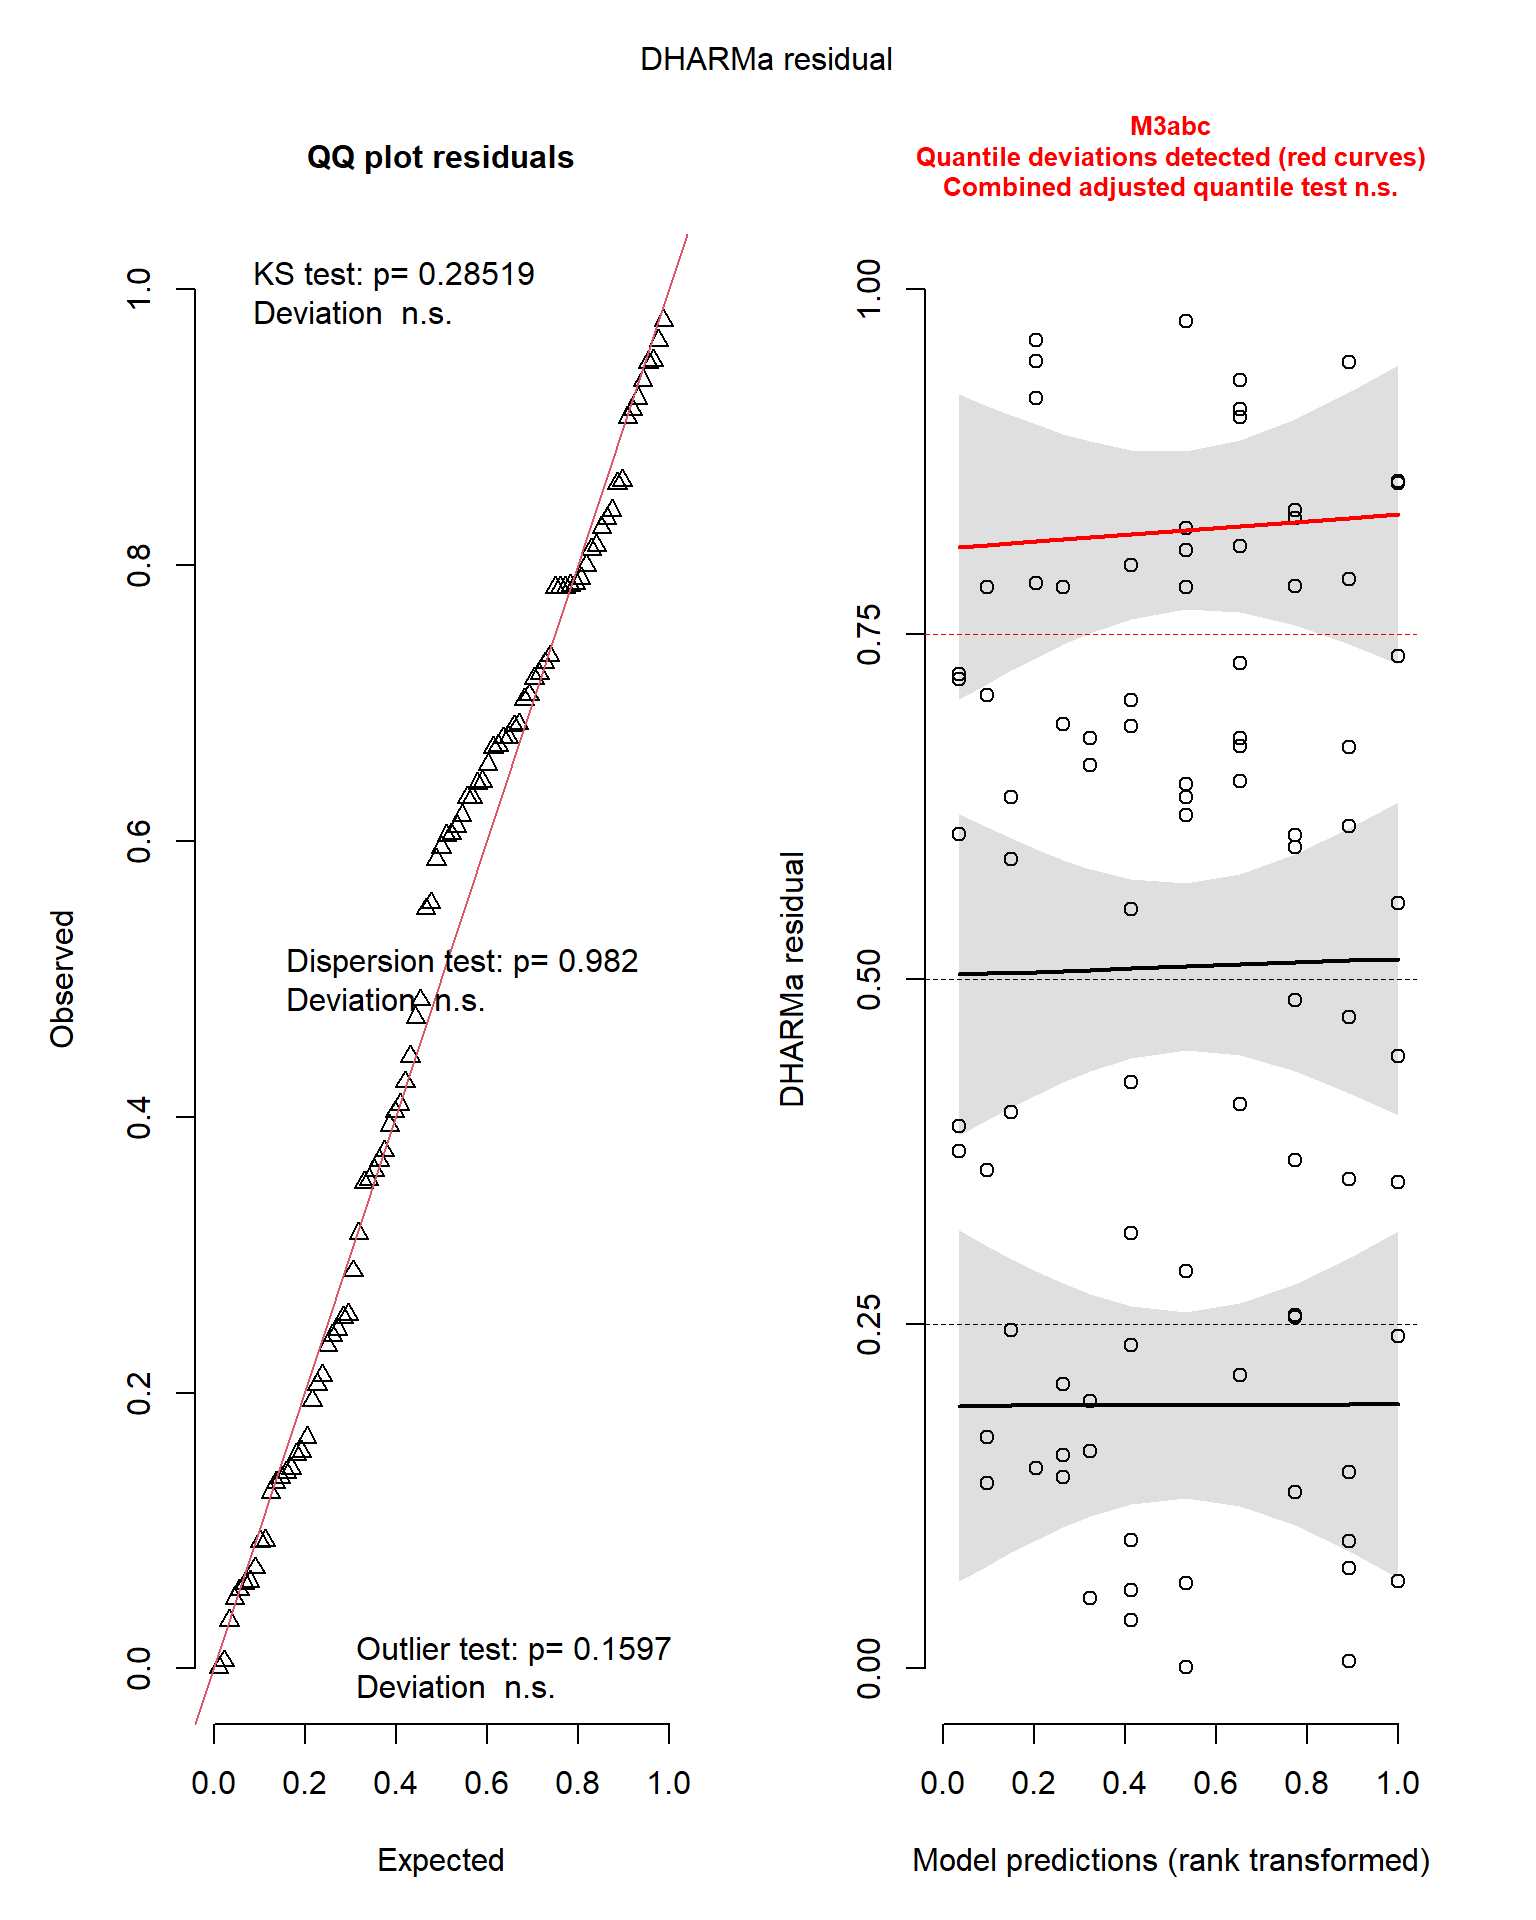

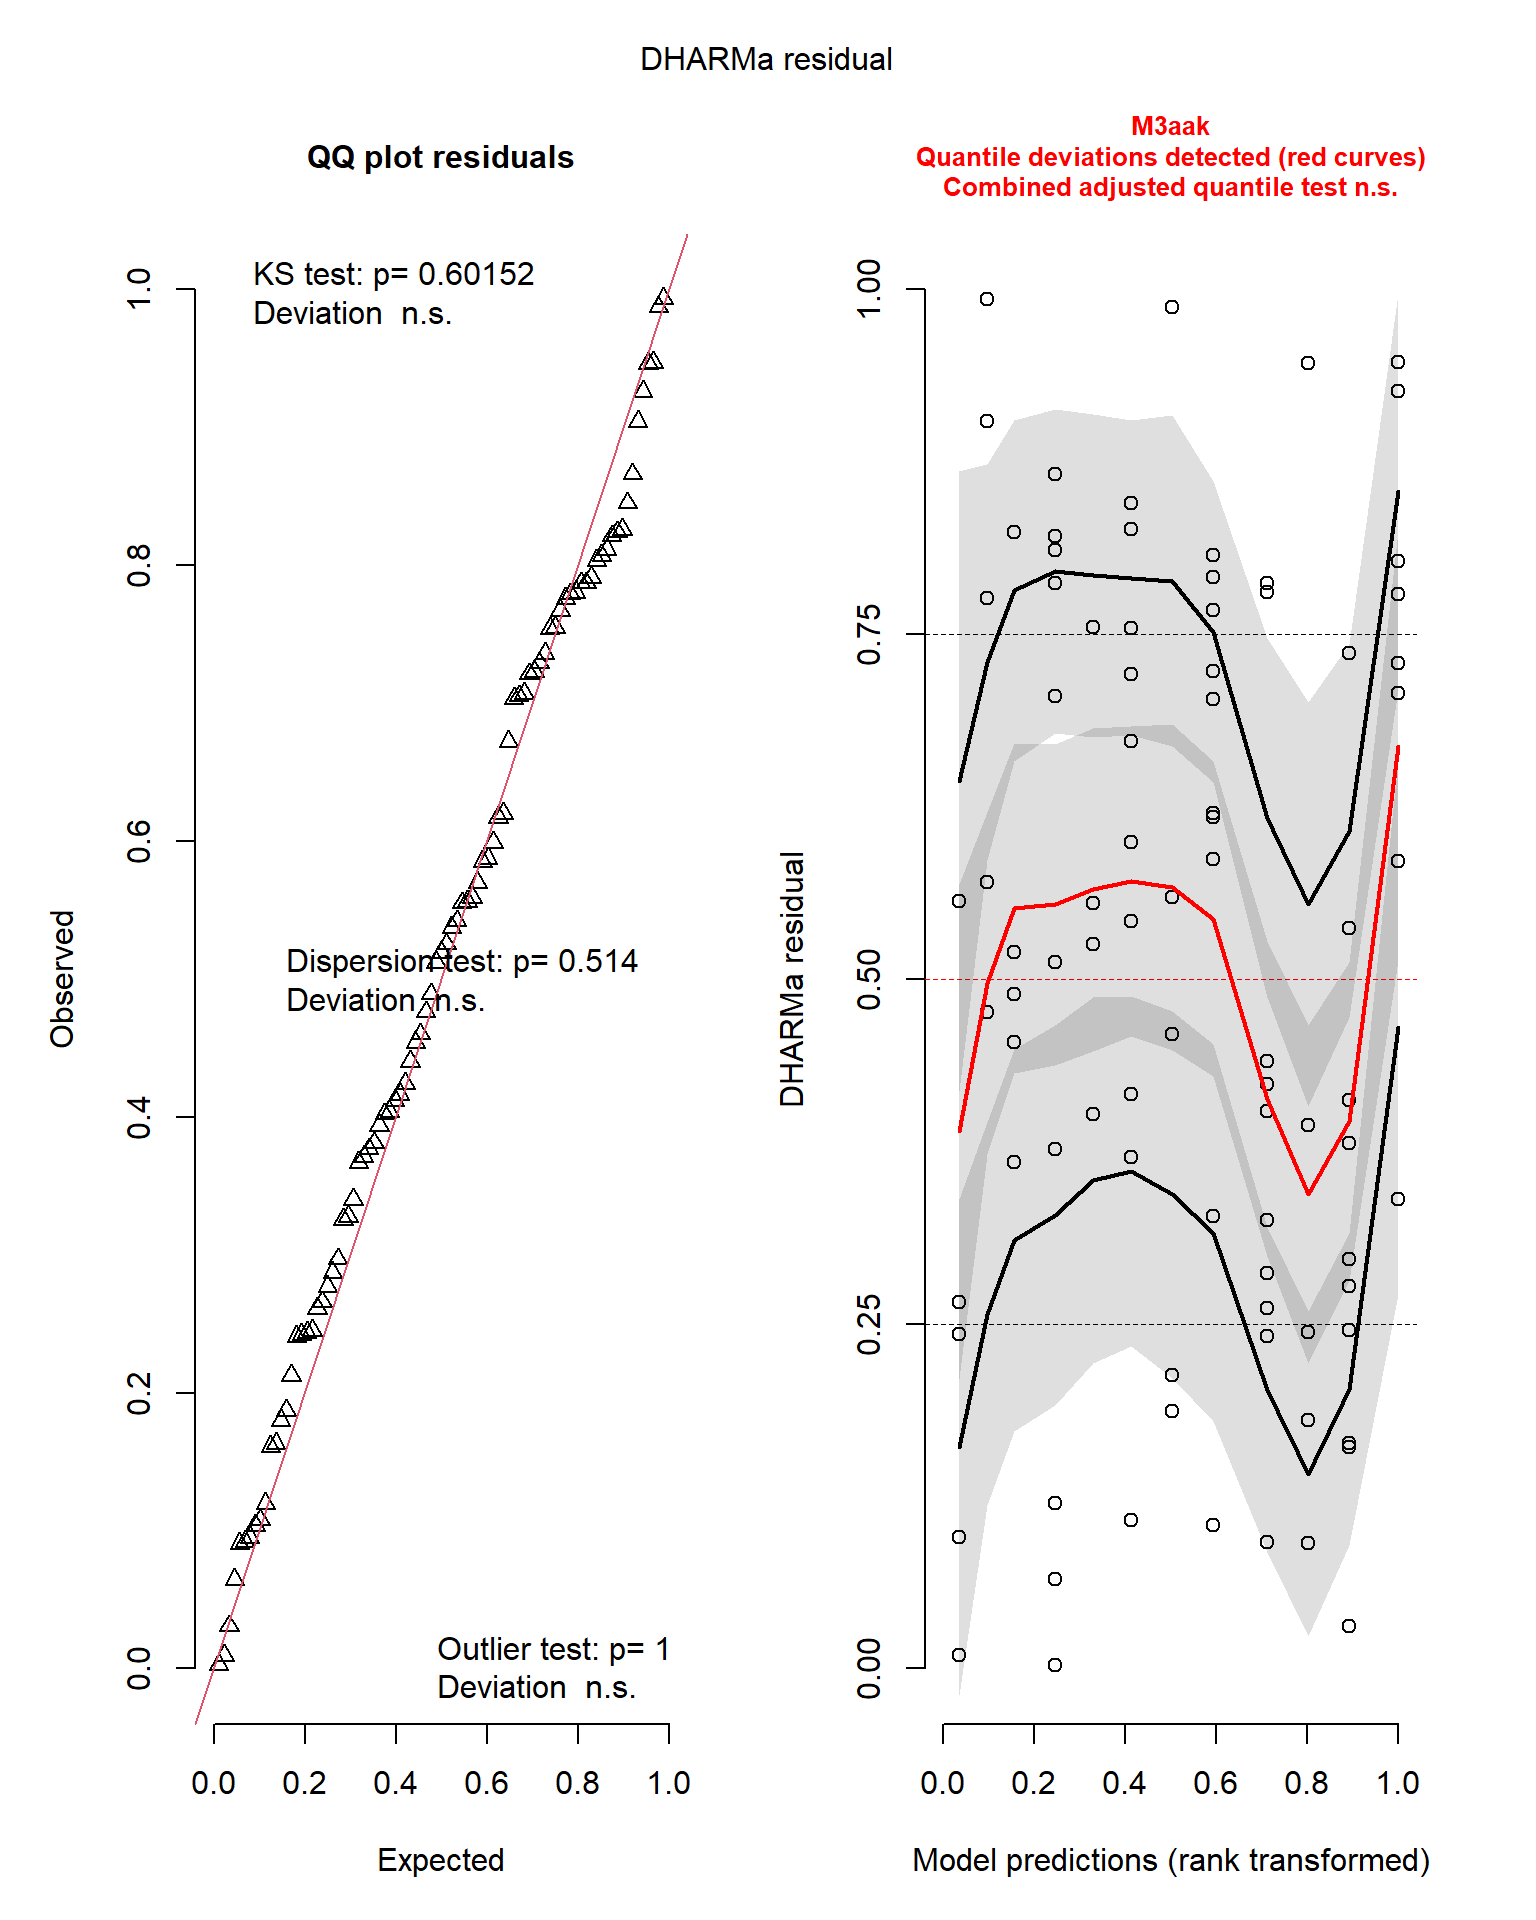

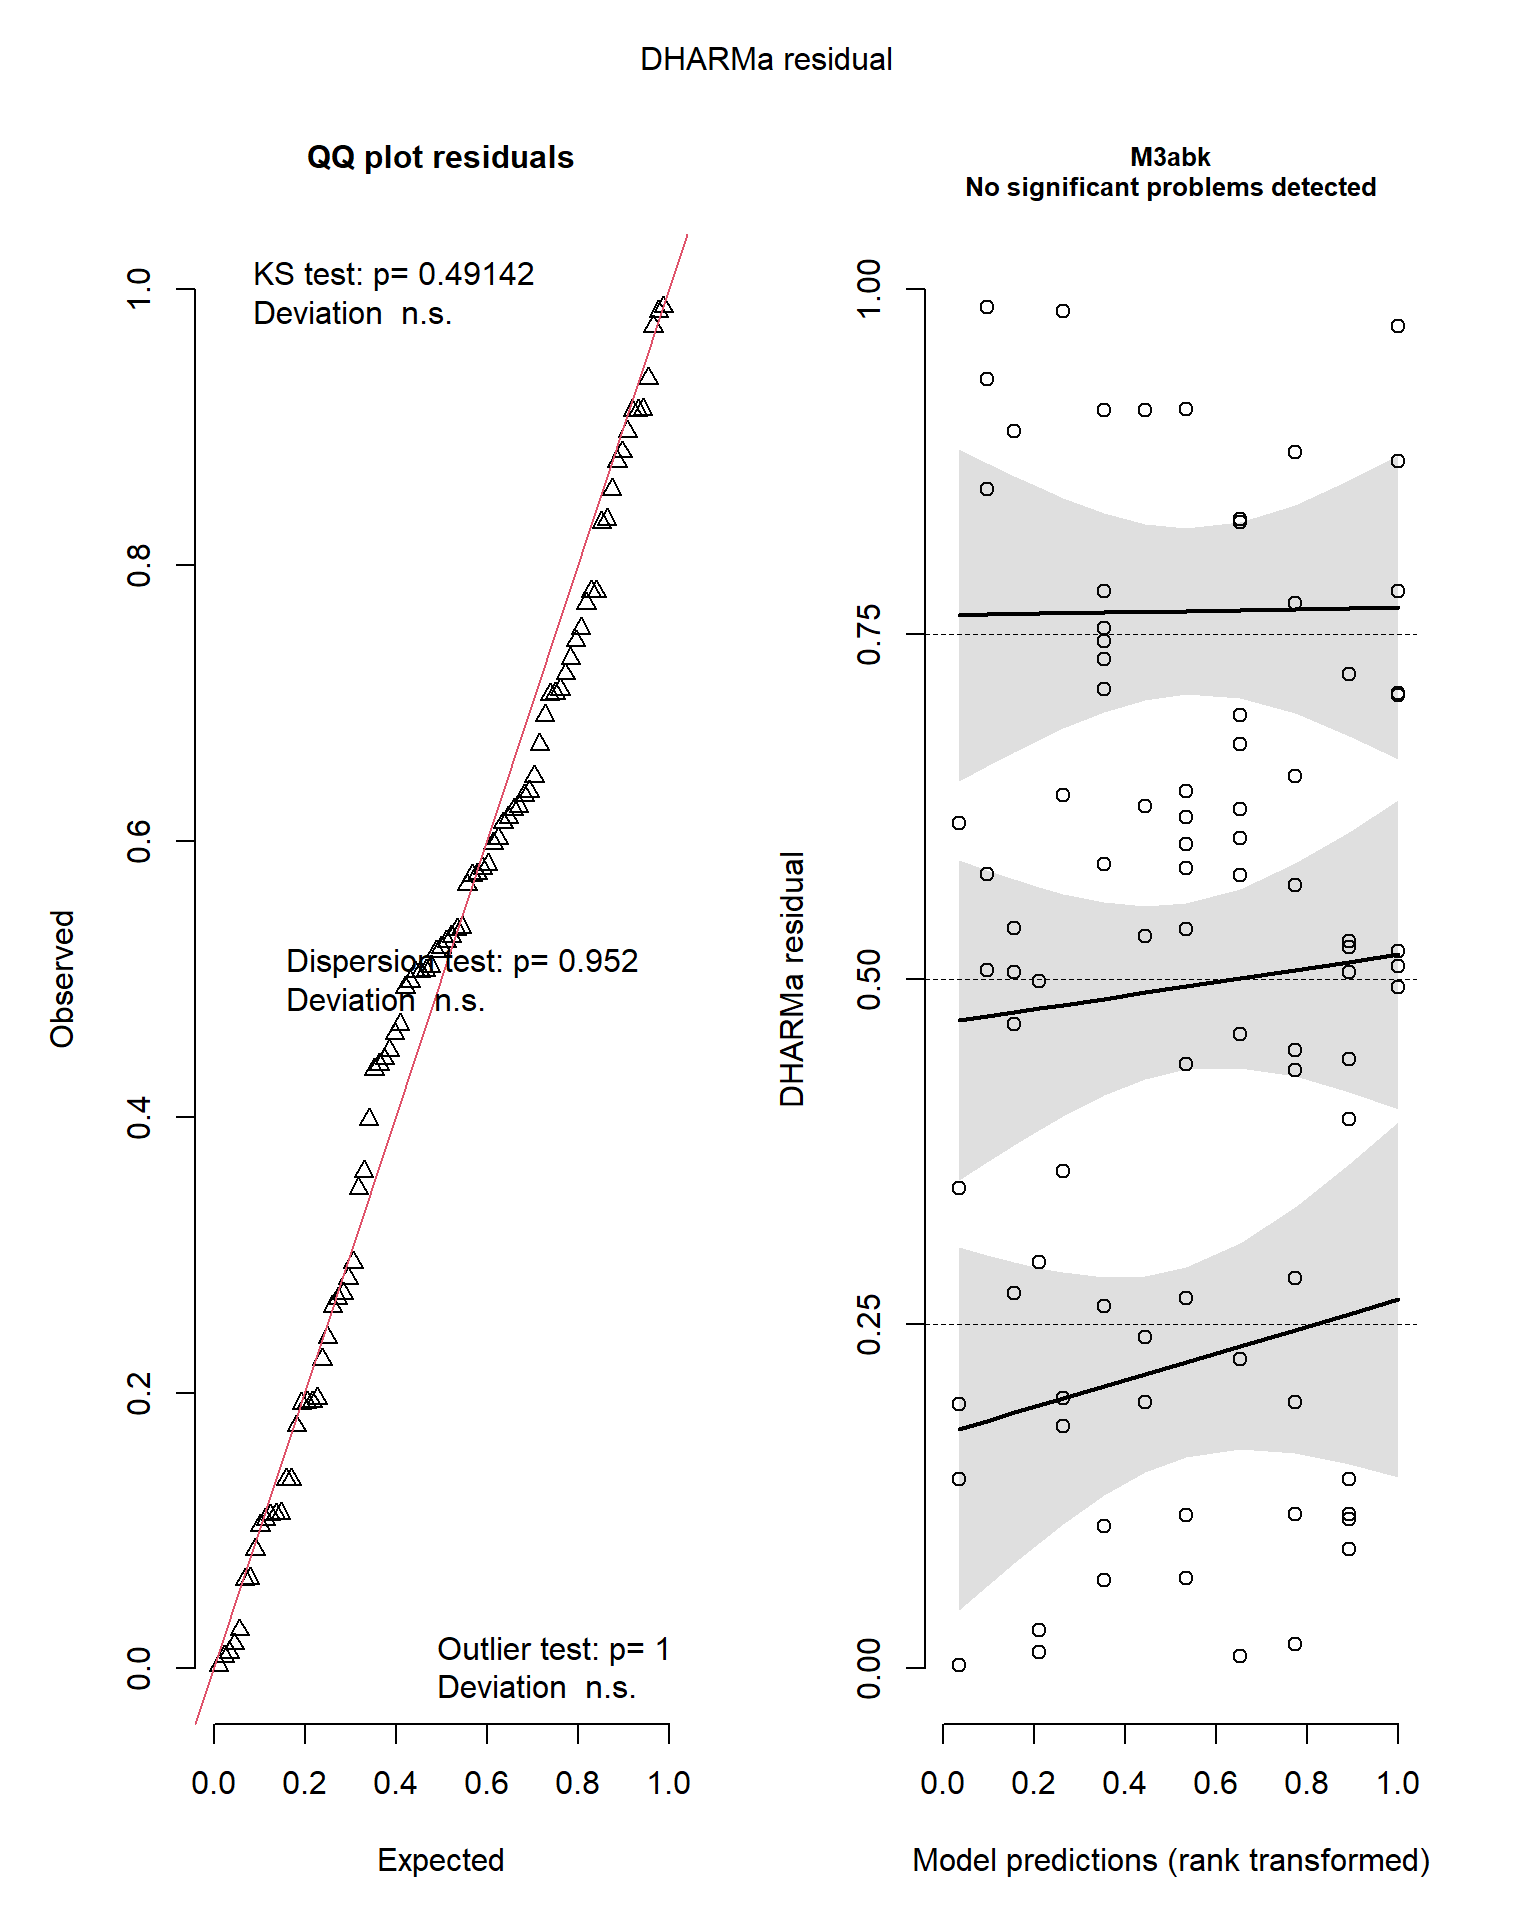

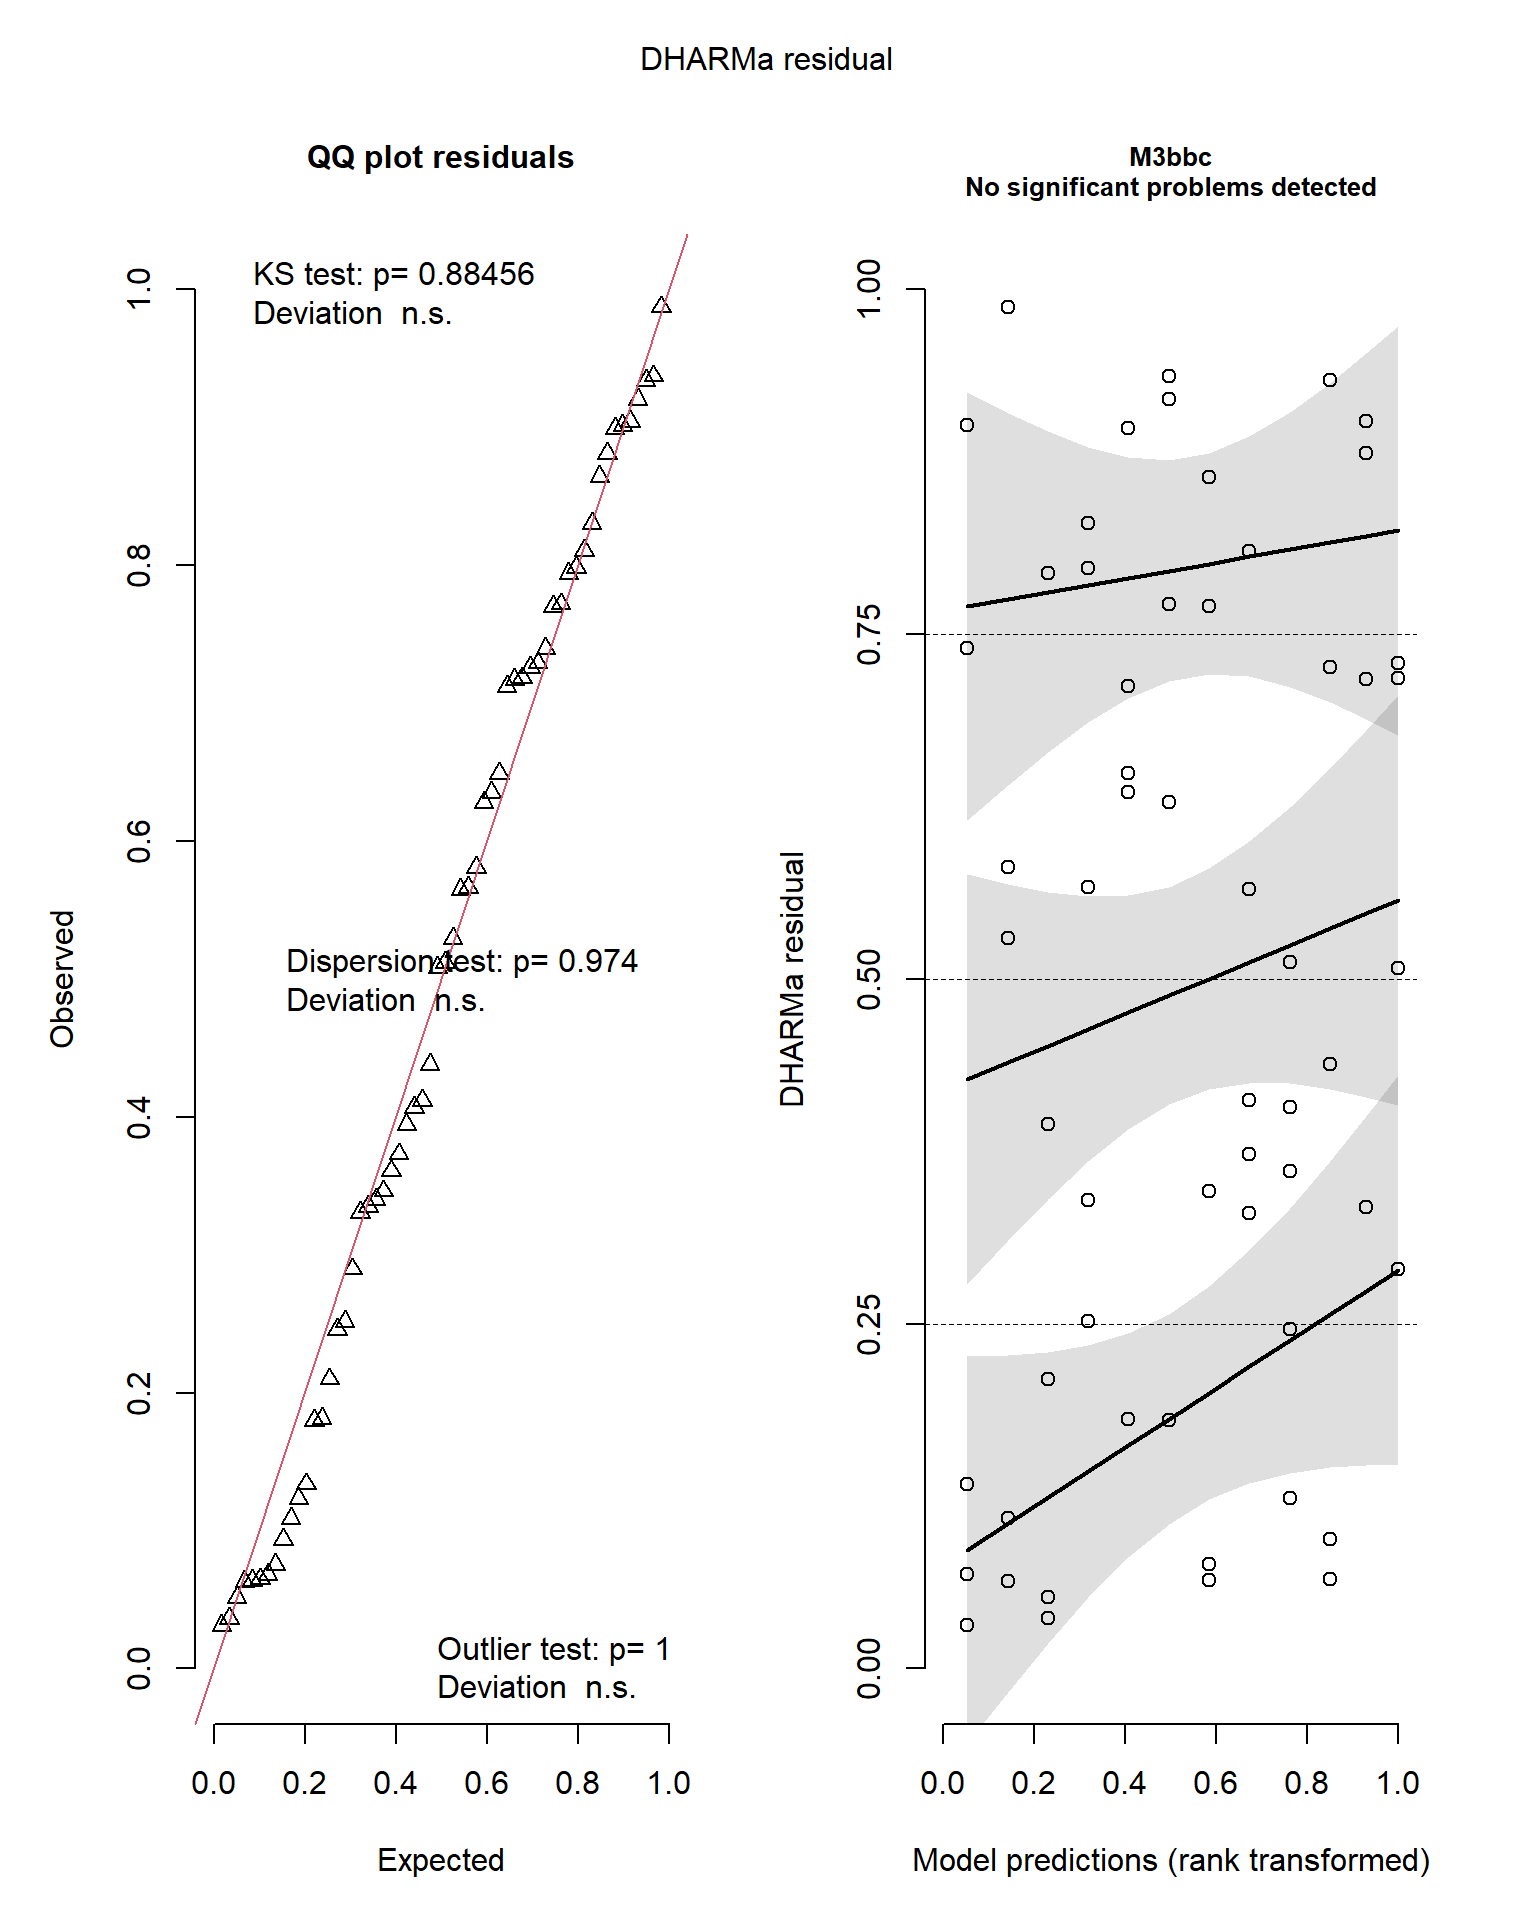

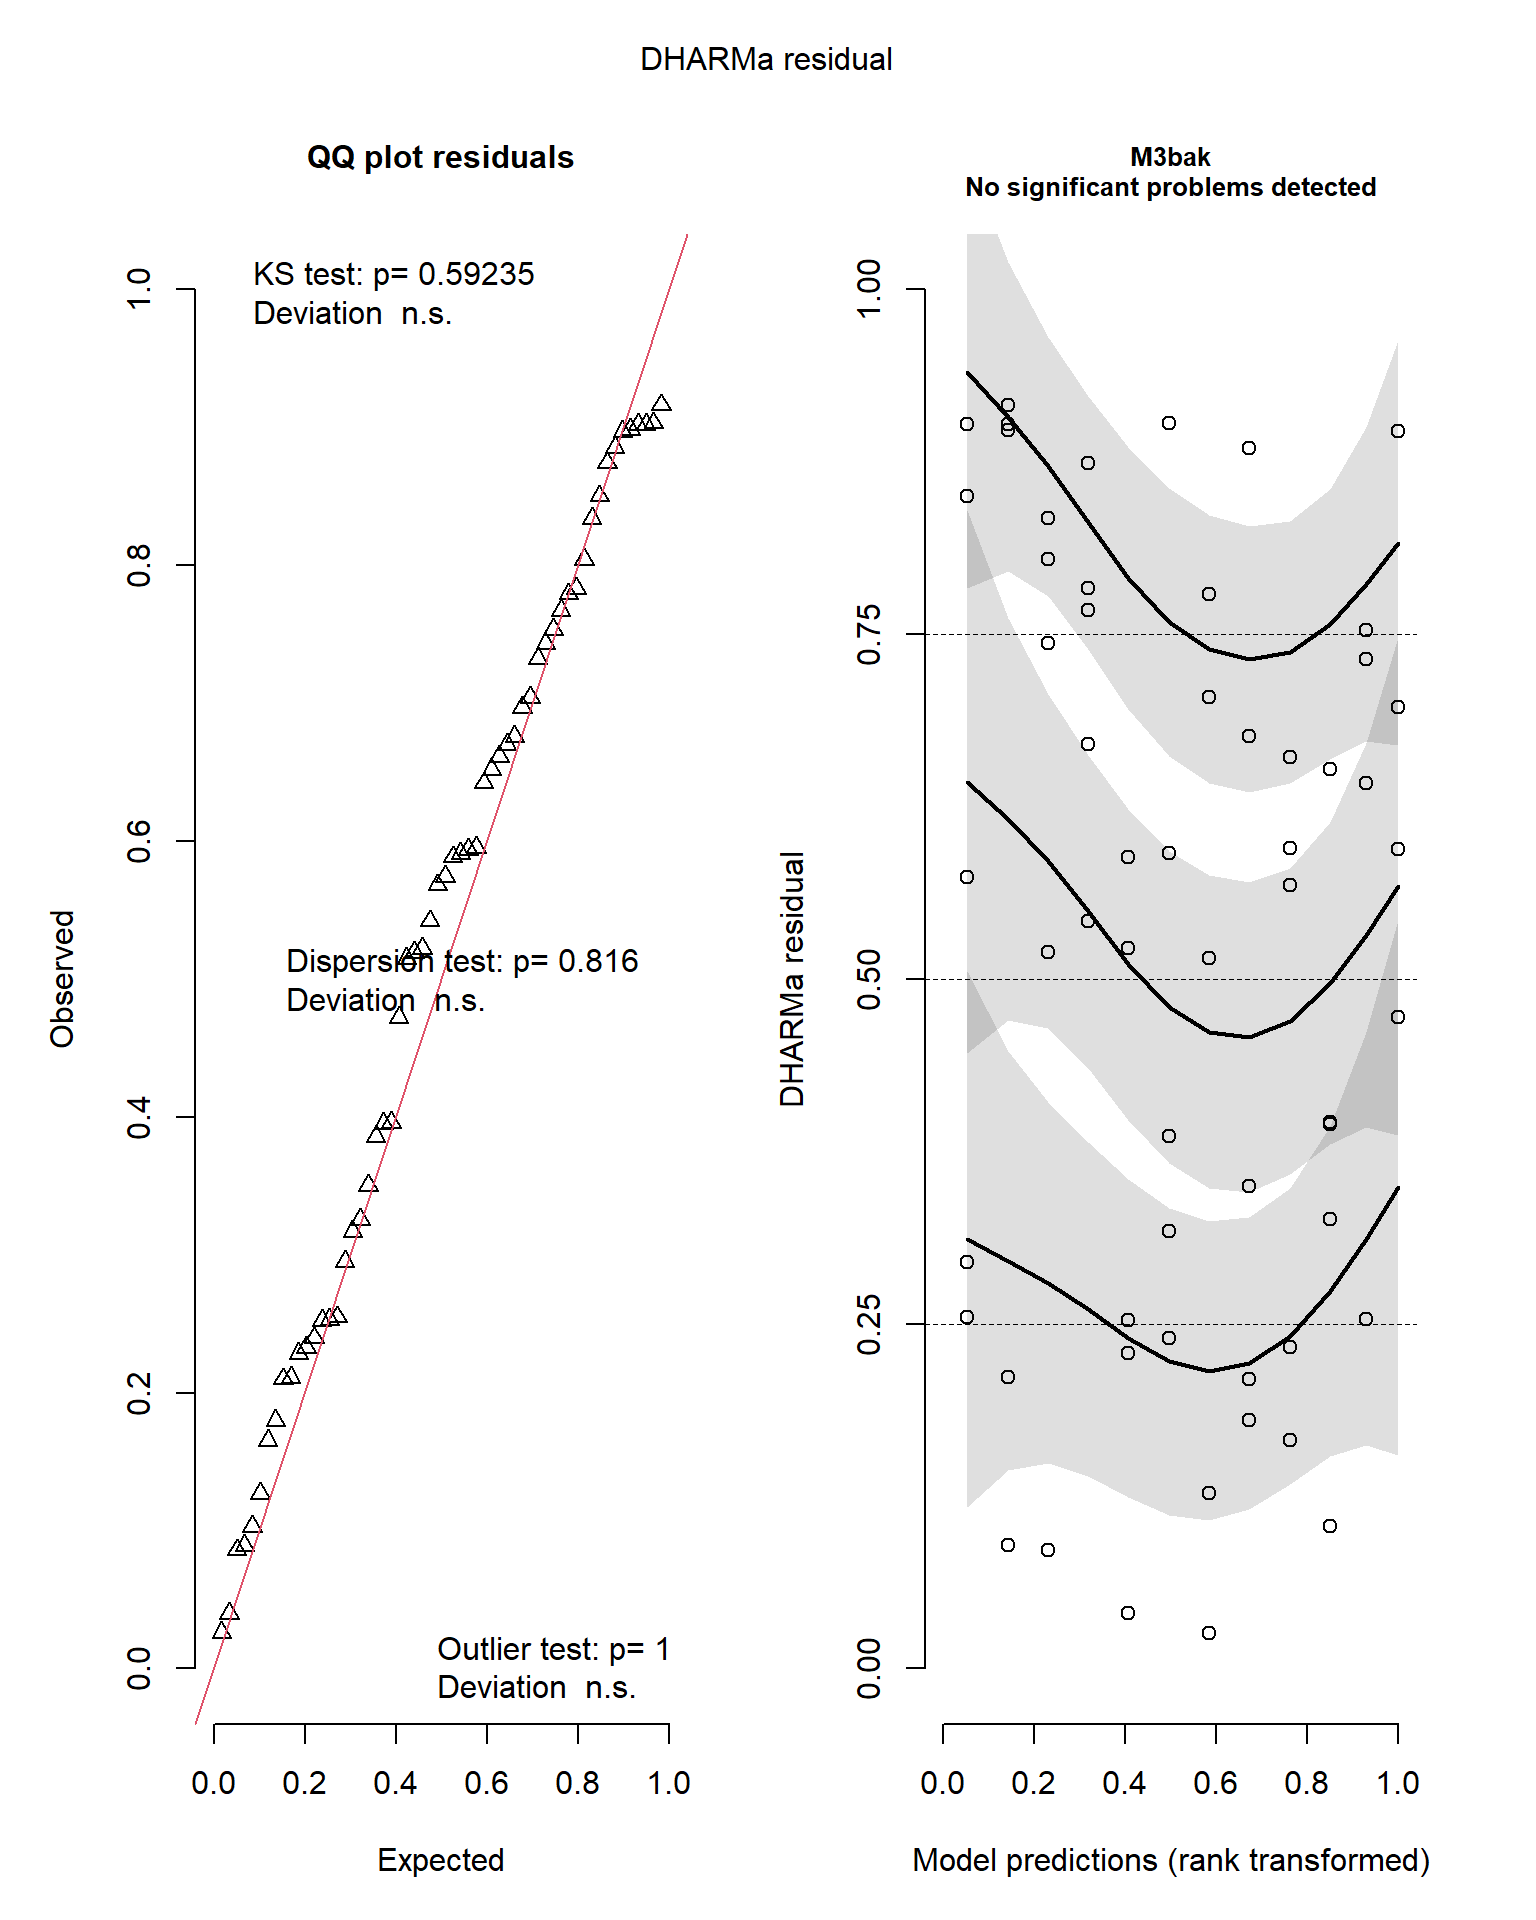

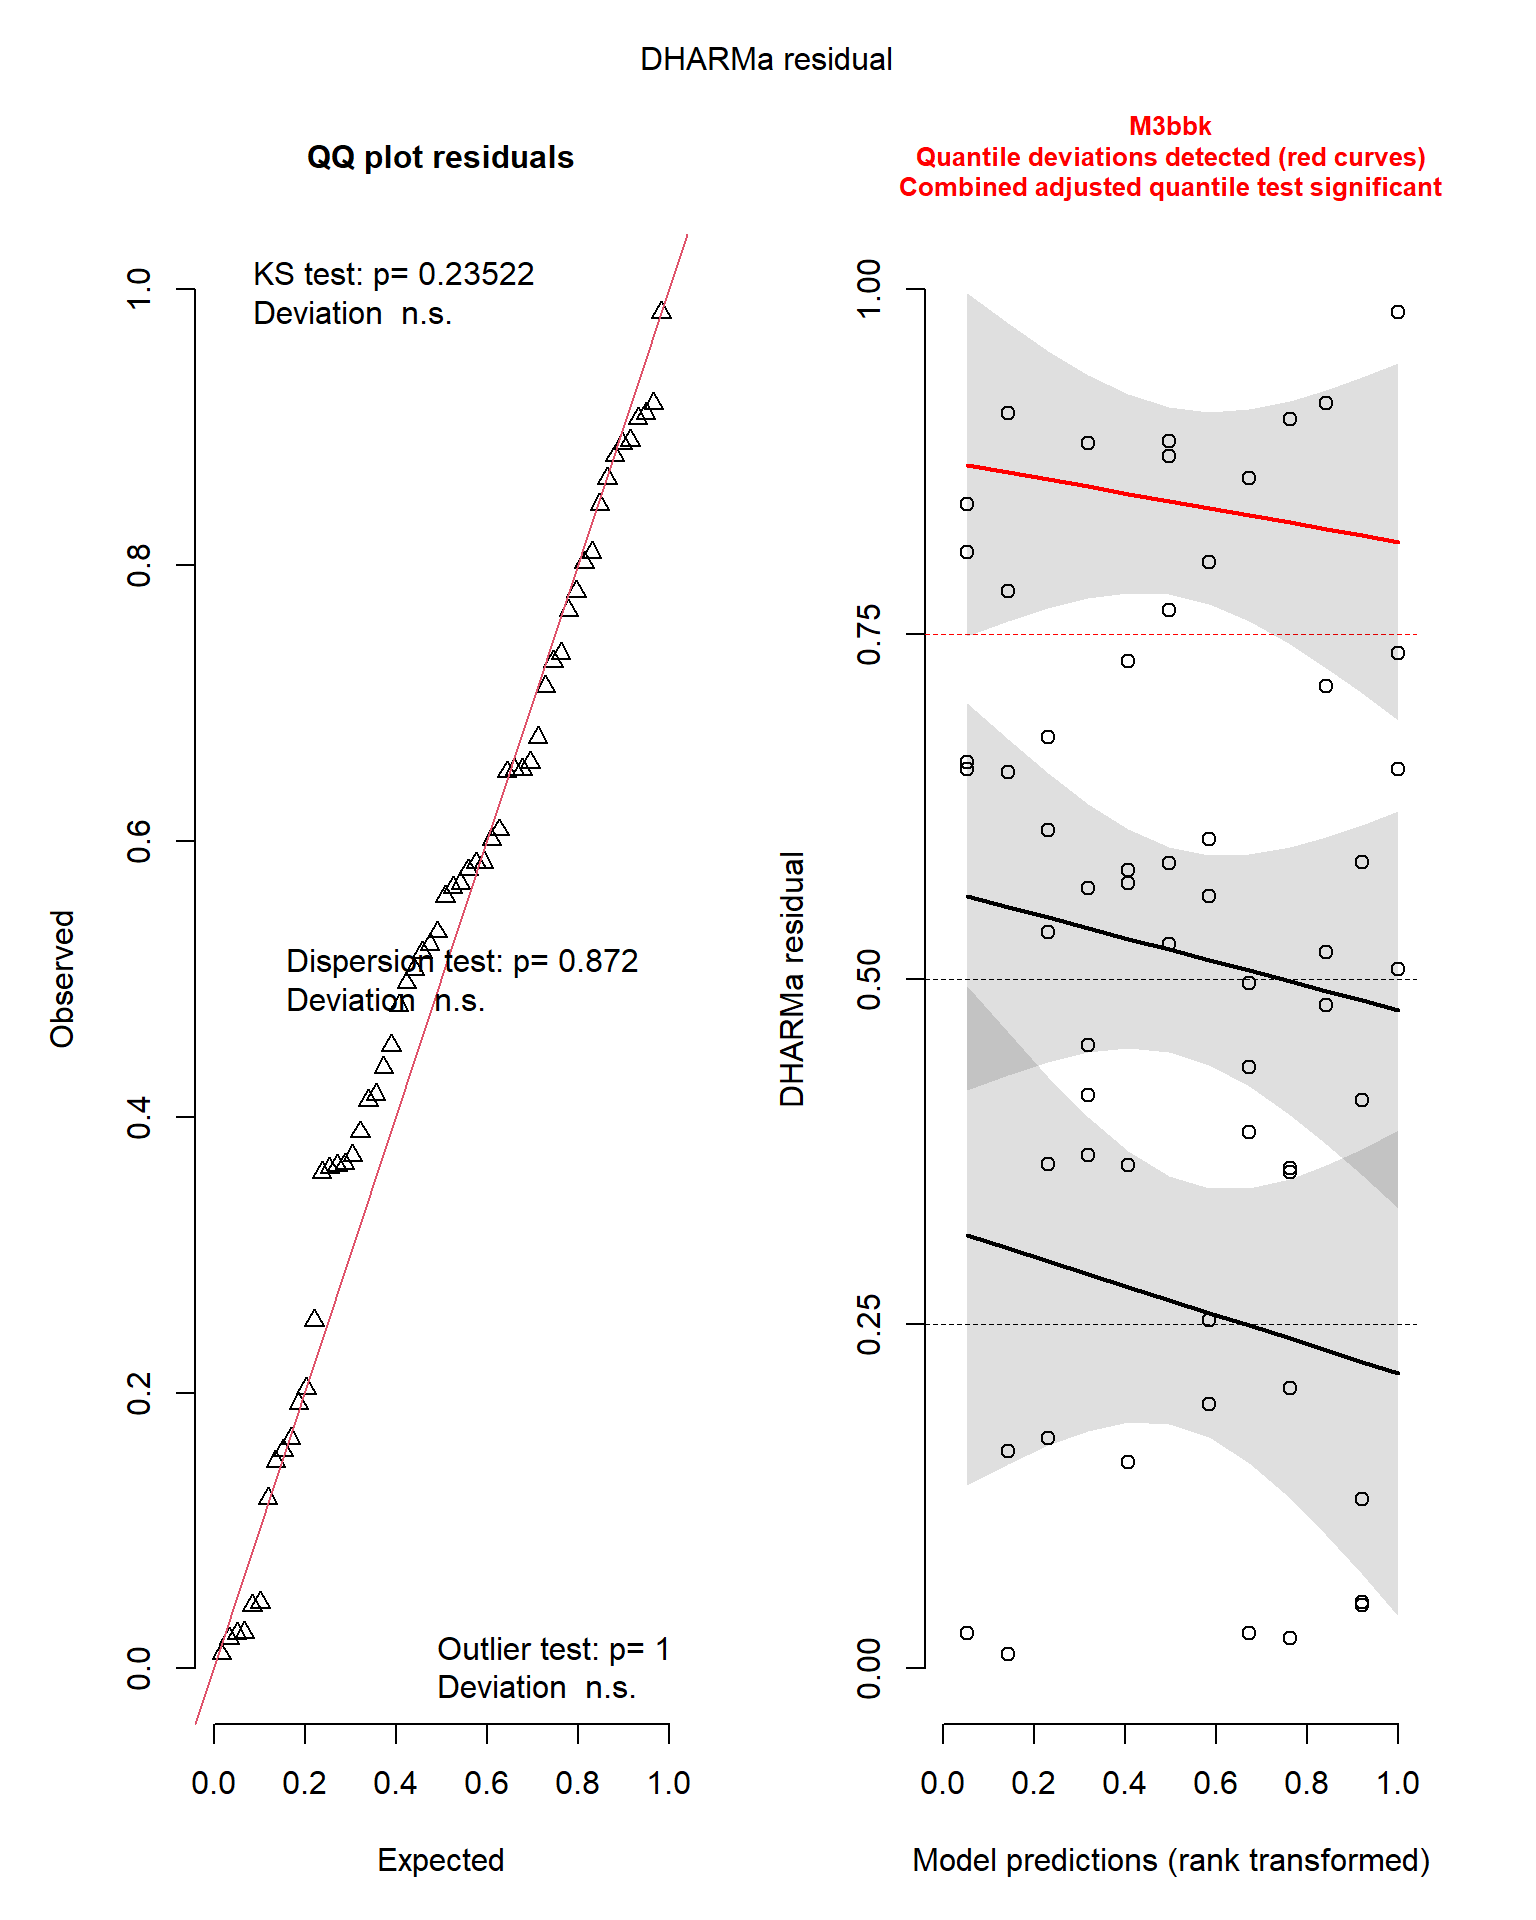

In [ ]:

model_registry <- dplyr::bind_rows(rq1_results, rq2_results, rq3_results) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame, term_of_interest, p_adj_BH, model)


is_dharma_safe <- function(m) {
  if (is.null(m) || m$fit$convergence != 0) return(FALSE)
  tryCatch({
    v <- diag(as.matrix(vcov(m, full = TRUE)))
    all(is.finite(v) & v > 0)
  }, error = function(e) FALSE, warning = function(w) FALSE)
}

diagnostic_models <- model_registry %>%
  dplyr::filter(time_frame != "before") %>%
  dplyr::filter(purrr::map_lgl(model, is_dharma_safe)) %>%
  { purrr::set_names(.$model, .$model_id) } %>%
  purrr::compact()

simulate_check <- function(model, name, seed = 42) {
  sim <- DHARMa::simulateResiduals(model, n = 1000, seed = seed)
  plot(sim, main = name)
  sim
}

dharma_sims <- purrr::imap(diagnostic_models, simulate_check)


### Residual diagnostics summary table

In [ ]:

dharma_tests <- purrr::imap_dfr(dharma_sims, function(sim, name) {
  tibble(
    Model           = name,
    Uniformity_p    = DHARMa::testUniformity(sim, plot = FALSE)$p.value,
    Dispersion_p    = DHARMa::testDispersion(sim, plot = FALSE)$p.value,
    Outlier_p       = DHARMa::testOutliers(sim, plot = FALSE)$p.value)
}) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(dharma_tests)

write.csv(dharma_tests, file.path(out_dir, "tbl-residual-diagnostics.csv"), row.names = FALSE)


  Model     Uniformity_p   Dispersion_p   Outlier_p
  ------- -------------- -------------- -----------
  M2aac            0.796          0.916        1.00
  M2abc            0.970          0.922        1.00
  M2aoc            0.618          1.000        1.00
  M2aak            0.769          0.320        1.00
  M2abk            0.888          0.410        1.00
  M2aok            0.479          0.928        1.00
  M2bac            0.925          0.310        1.00
  M2bbc            0.106          0.740        1.00
  M2boc            0.533          0.944        1.00
  M2bak            0.838          0.432        1.00
  M2bbk            0.365          0.570        1.00
  M2bok            0.915          0.984        1.00
  M3aac            0.296          0.228        1.00
  M3abc            0.285          0.982        0.16
  M3aak            0.602          0.514        1.00
  M3abk            0.491          0.952        1.00
  M3bbc            0.885          0.974        1.00
  M3bak            0.592          0.816        1.00
  M3bbk            0.235          0.872        1.00


# Model results

## Question structure reference table

In [ ]:

question_structure <- model_registry %>%
  dplyr::mutate(
    family = dplyr::if_else(response_type == "occupancy", "binomial", "tweedie"),
    data = dplyr::case_when(
      comparison == "vs_control"  & time_frame == "full"   ~ "rq2a_data",
      comparison == "vs_control"  & time_frame == "after"  ~ "rq2b_data",
      comparison == "vs_reference"                         ~ "rq3a_data",
      comparison == "treatment"   & time_frame == "before" ~ "rq1a_data",
      comparison == "reference"   & time_frame == "before" ~ "rq1b_data",
      comparison == "reference"   & time_frame == "after"  ~ "rq3b_data"),
    formula = purrr::map_chr(model, function(m) {
      if (is.null(m)) return(NA_character_)
      f <- tryCatch(deparse(formula(m)), error = function(e) NA_character_)
      stringr::str_replace(paste(f, collapse = " "), "^`[^`]+`", "<response>")
    })) %>%
  dplyr::mutate(
    time_frame = factor(time_frame, levels = c("full", "before", "after")),
    comparison = factor(comparison, levels = c("vs_control", "vs_reference", "treatment", "reference"))) %>%
  dplyr::arrange(RQ, time_frame, comparison, species, response_type) %>%
  dplyr::select(RQ, species, response_type, comparison, time_frame, family, data, formula, term_of_interest)

write.csv(question_structure, file.path(out_dir, "tbl-question-structure.csv"), row.names = FALSE)

knitr::kable(question_structure)


  -------------------------------------------------------------------------------------------------------------------------------------------------------------------
  RQ     species   response_type   comparison     time_frame   family     data        formula                            term_of_interest
  ------ --------- --------------- -------------- ------------ ---------- ----------- ---------------------------------- --------------------------------------------
  RQ1    Catfish   abundance       treatment      before       tweedie    rq1a_data   Weighted_CPUE_Catfish \~           Site_type_detailStone_pile
                                                                                      Site_type_detail                   

  RQ1    Catfish   biomass         treatment      before       tweedie    rq1a_data   Weighted_BPUE_Catfish \~           Site_type_detailStone_pile
                                                                                      Site_type_detail                   

  RQ1    Kōura     abundance       treatment      before       tweedie    rq1a_data   Weighted_CPUE_Kōura \~             Site_type_detailStone_pile
                                                                                      Site_type_detail                   

  RQ1    Kōura     biomass         treatment      before       tweedie    rq1a_data   Weighted_BPUE_Kōura \~             Site_type_detailStone_pile
                                                                                      Site_type_detail                   

  RQ1    Catfish   abundance       reference      before       tweedie    rq1b_data   Weighted_CPUE_Catfish \~           Site_type_detailReference_2
                                                                                      Site_type_detail + Temperature     

  RQ1    Catfish   biomass         reference      before       tweedie    rq1b_data   Weighted_BPUE_Catfish \~           Site_type_detailReference_2
                                                                                      Site_type_detail + Temperature     

  RQ1    Kōura     abundance       reference      before       tweedie    rq1b_data   Weighted_CPUE_Kōura \~             Site_type_detailReference_2
                                                                                      Site_type_detail                   

  RQ1    Kōura     biomass         reference      before       tweedie    rq1b_data   Weighted_BPUE_Kōura \~             Site_type_detailReference_2
                                                                                      Site_type_detail                   

  RQ2a   Catfish   abundance       vs_control     full         tweedie    rq2a_data   Weighted_CPUE_Catfish \~ Period \* PeriodAfter:siteStone_pile
                                                                                      site + monitoring_int + (1 \|      
                                                                                      pair_id/site_id)                   

  RQ2a   Catfish   biomass         vs_control     full         tweedie    rq2a_data   Weighted_BPUE_Catfish \~ Period \* PeriodAfter:siteStone_pile
                                                                                      site + monitoring_int + (1 \|      
                                                                                      pair_id/site_id)                   

  RQ2a   Catfish   occupancy       vs_control     full         binomial   rq2a_data   Presence_Catfish \~ Period \*      PeriodAfter:siteStone_pile
                                                                                      site + monitoring_int + (1 \|      
                                                                                      pair_id/site_id)                   

  RQ2a   Kōura     abundance       vs_control     full         tweedie    rq2a_data   Weighted_CPUE_Kōura \~ Period \*   PeriodAfter:siteStone_pile
                                                                                      site + monitoring_int + (1 \|      
                                                                                      pair_id/site_id)                   

  RQ2a   Kōura     biomass         vs_control     full         tweedie    rq2a_data   Weighted_BPUE_Kōura \~ Period \*   PeriodAfter:siteStone_pile
                                                                                      site + monitoring_int + (1 \|      
                                                                                      pair_id/site_id)                   

  RQ2a   Kōura     occupancy       vs_control     full         binomial   rq2a_data   Presence_Kōura \~ Period \* site + PeriodAfter:siteStone_pile
                                                                                      monitoring_int + (1 \|             
                                                                                      pair_id/site_id)                   

  RQ2b   Catfish   abundance       vs_control     after        tweedie    rq2b_data   Weighted_CPUE_Catfish \~ site \*   siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ2b   Catfish   biomass         vs_control     after        tweedie    rq2b_data   Weighted_BPUE_Catfish \~ site \*   siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ2b   Catfish   occupancy       vs_control     after        binomial   rq2b_data   Presence_Catfish \~ site \*        siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ2b   Kōura     abundance       vs_control     after        tweedie    rq2b_data   Weighted_CPUE_Kōura \~ site \*     siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ2b   Kōura     biomass         vs_control     after        tweedie    rq2b_data   Weighted_BPUE_Kōura \~ site \*     siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ2b   Kōura     occupancy       vs_control     after        binomial   rq2b_data   Presence_Kōura \~ site \*          siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ3a   Catfish   abundance       vs_reference   after        tweedie    rq3a_data   Weighted_CPUE_Catfish \~ site \*   siteStone_pile:monitoring_int
                                                                                      monitoring_int + Temperature + (1  
                                                                                      \| site_id)                        

  RQ3a   Catfish   biomass         vs_reference   after        tweedie    rq3a_data   Weighted_BPUE_Catfish \~ site \*   siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ3a   Kōura     abundance       vs_reference   after        tweedie    rq3a_data   Weighted_CPUE_Kōura \~ site \*     siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ3a   Kōura     biomass         vs_reference   after        tweedie    rq3a_data   Weighted_BPUE_Kōura \~ site \*     siteStone_pile:monitoring_int
                                                                                      monitoring_int + (1 \| site_id)    

  RQ3b   Catfish   abundance       reference      after        tweedie    rq3b_data   Weighted_CPUE_Catfish \~           Site_type_detailReference_2:monitoring_int
                                                                                      Site_type_detail \*                
                                                                                      monitoring_int + Temperature + (1  
                                                                                      \| pair_id/site_id)                

  RQ3b   Catfish   biomass         reference      after        tweedie    rq3b_data   Weighted_BPUE_Catfish \~           Site_type_detailReference_2:monitoring_int
                                                                                      Site_type_detail \*                
                                                                                      monitoring_int + (1 \|             
                                                                                      pair_id/site_id)                   

  RQ3b   Kōura     abundance       reference      after        tweedie    rq3b_data   Weighted_CPUE_Kōura \~             Site_type_detailReference_2:monitoring_int
                                                                                      Site_type_detail \*                
                                                                                      monitoring_int + Season + (1 \|    
                                                                                      pair_id/site_id)                   

  RQ3b   Kōura     biomass         reference      after        tweedie    rq3b_data   Weighted_BPUE_Kōura \~             Site_type_detailReference_2:monitoring_int
                                                                                      Site_type_detail \*                
                                                                                      monitoring_int + (1 \|             
                                                                                      pair_id/site_id)                   
  -------------------------------------------------------------------------------------------------------------------------------------------------------------------


## Models summary table

In [ ]:

tidy_all <- model_registry %>%
  dplyr::mutate(tidy = purrr::map2(model, term_of_interest, function(m, trm) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", component = "cond", conf.int = TRUE) %>%
      dplyr::filter(term == trm)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))


The first warning was:
ℹ In argument: `tidy = purrr::map2(...)`.
Caused by warning in `sqrt()`:
! NaNs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.

# A tibble: 28 × 14
   model_id RQ    species response_type comparison   time_frame term    estimate
   <chr>    <chr> <chr>   <chr>         <chr>        <chr>      <chr>      <dbl>
 1 M1aac    RQ1   Catfish abundance     treatment    before     Site_t…   -0.693
 2 M1abc    RQ1   Catfish biomass       treatment    before     Site_t…   -5.1  
 3 M1aak    RQ1   Kōura   abundance     treatment    before     Site_t…    0.288
 4 M1abk    RQ1   Kōura   biomass       treatment    before     Site_t…    1.04 
 5 M1bac    RQ1   Catfish abundance     reference    before     Site_t…   -1.66 
 6 M1bbc    RQ1   Catfish biomass       reference    before     Site_t…   -2.57 
 7 M1bak    RQ1   Kōura   abundance     reference    before     Site_t…    0.031
 8 M1bbk    RQ1   Kōura   biomass       reference    before     Site_t…   -0.041
 9 M2aac    RQ2a  Catfish abundance     vs_control   full       Period…    2.01 
10 M2abc    RQ2a  Catfish biomass       vs_control   full       Period…    5.31 
11 M2aoc

## Full fixed-effects table

In [ ]:

tidy_all_full <- model_registry %>%
  dplyr::mutate(tidy = purrr::map(model, function(m) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", component = "cond", conf.int = TRUE)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  # p_adj_BH only applies to each model's own term of interest — NA elsewhere.
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))


The first warning was:
ℹ In argument: `tidy = purrr::map(...)`.
Caused by warning in `sqrt()`:
! NaNs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.

# A tibble: 109 × 14
    model_id RQ    species response_type comparison   time_frame term   estimate
    <chr>    <chr> <chr>   <chr>         <chr>        <chr>      <chr>     <dbl>
  1 M1aac    RQ1   Catfish abundance     treatment    before     (Inte…   -2.30 
  2 M1aac    RQ1   Catfish abundance     treatment    before     Site_…   -0.693
  3 M1abc    RQ1   Catfish biomass       treatment    before     (Inte…    3.20 
  4 M1abc    RQ1   Catfish biomass       treatment    before     Site_…   -5.1  
  5 M1aak    RQ1   Kōura   abundance     treatment    before     (Inte…   -1.90 
  6 M1aak    RQ1   Kōura   abundance     treatment    before     Site_…    0.288
  7 M1abk    RQ1   Kōura   biomass       treatment    before     (Inte…    1.03 
  8 M1abk    RQ1   Kōura   biomass       treatment    before     Site_…    1.04 
  9 M1bac    RQ1   Catfish abundance     reference    before     (Inte… -102.   
 10 M1bac    RQ1   Catfish abundance     reference    before     Site_…   -1.66 
 11 M1b

## All models forest plot

ℹ Please use the `orientation` argument of `geom_errorbar()` instead.

`height` was translated to `width`.

`height` was translated to `width`.

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database
Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, : font
family not found in Windows font database

Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database
Warning in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
font family not found in Windows font database

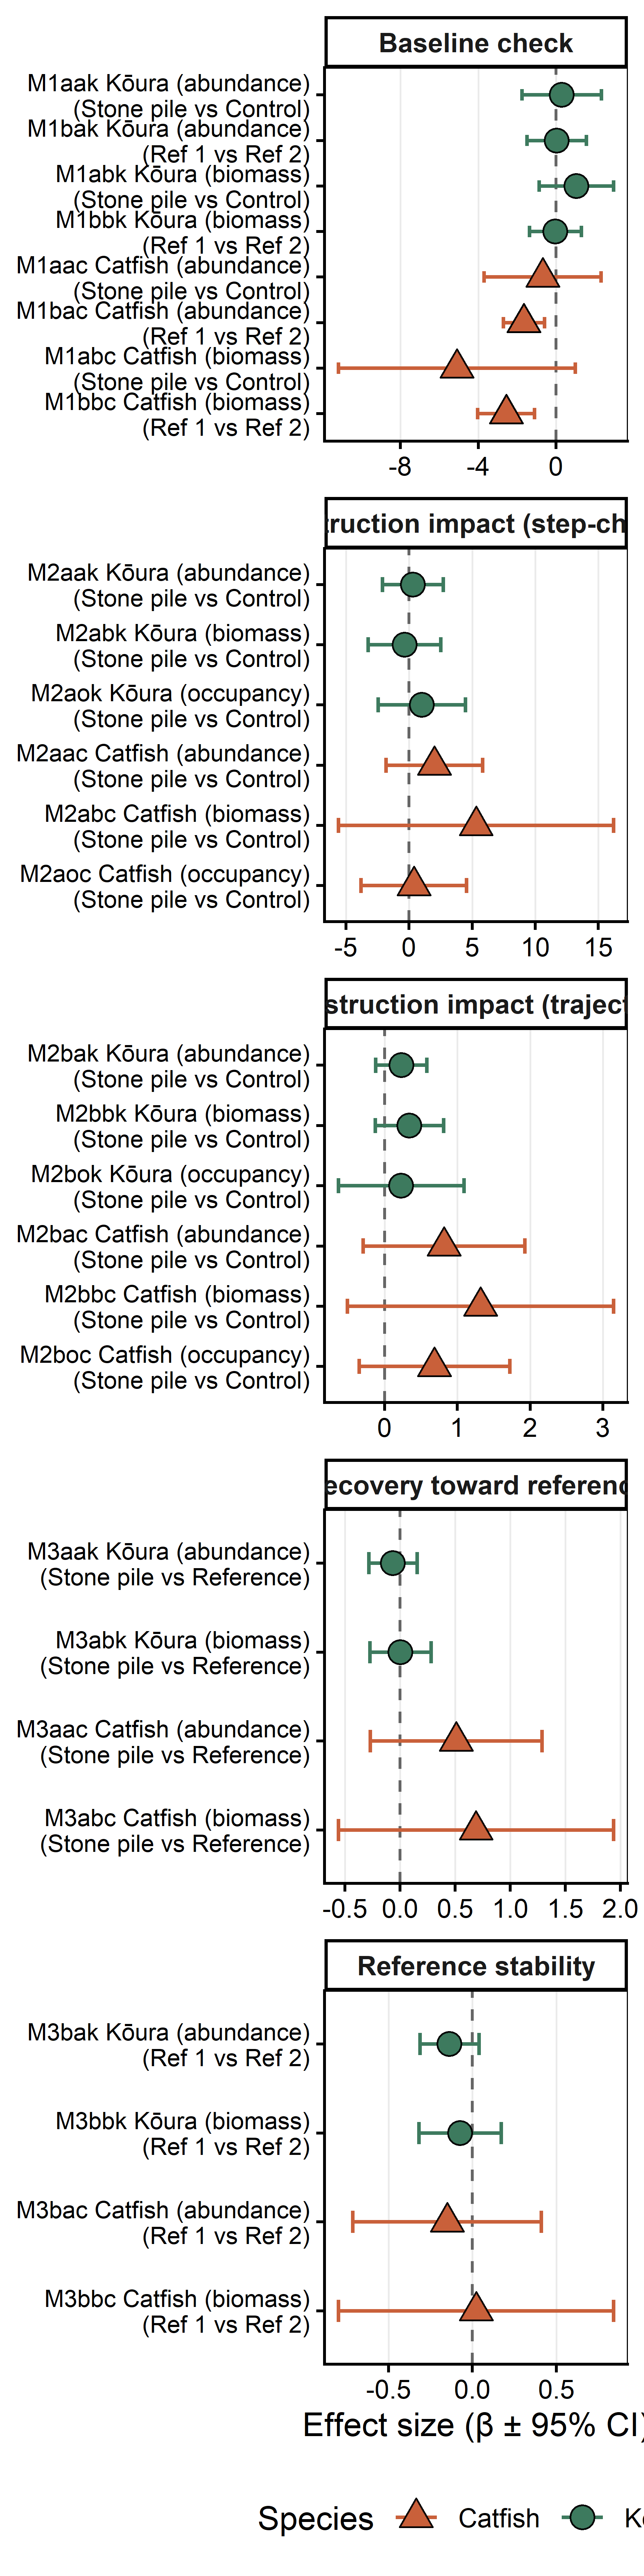

In [ ]:

# Built directly from tidy_all — drop models with degenerate CIs (non-PD Hessian)
forest_data <- tidy_all %>%
  dplyr::filter(is.finite(conf.low) & is.finite(conf.high)) %>%
  dplyr::mutate(
    comparison_label = dplyr::case_when(
      comparison == "vs_control"   ~ "Stone pile vs Control",
      comparison == "vs_reference" ~ "Stone pile vs Reference",
      comparison == "treatment"    ~ "Stone pile vs Control",
      comparison == "reference"    ~ "Ref 1 vs Ref 2",
      TRUE ~ comparison),
    model_name = paste0(model_id, " ", species, " (", response_type, ")\n(", comparison_label, ")"),
    group = dplyr::case_when(
      RQ == "RQ1"  ~ "Baseline check",
      RQ == "RQ2a" ~ "Construction impact (step-change)",
      RQ == "RQ2b" ~ "Construction impact (trajectory)",
      RQ == "RQ3a" ~ "Recovery toward reference",
      RQ == "RQ3b" ~ "Reference stability",
      TRUE         ~ RQ),
    significant = p.value < 0.05) %>%
  dplyr::arrange(
    factor(group, levels = c(
      "Baseline check",
      "Construction impact (step-change)",
      "Construction impact (trajectory)",
      "Recovery toward reference",
      "Reference stability")),
    factor(species, levels = c("Kōura", "Catfish")),
    response_type) %>%
  dplyr::mutate(
    model_name  = factor(model_name, levels = rev(unique(model_name))),
    group       = factor(group, levels = c(
      "Baseline check",
      "Construction impact (step-change)",
      "Construction impact (trajectory)",
      "Recovery toward reference",
      "Reference stability")))

species_colours <- c("Kōura" = "#3d7a5e", "Catfish" = "#c9603a")
species_shapes  <- c("Kōura" = 21,       "Catfish" = 24)

forest_plot <- ggplot(forest_data,
    aes(estimate, model_name)) +
  geom_vline(xintercept = 0, linetype = "dashed",
             colour = "grey40", linewidth = 0.5) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high,
                     colour = species),
                 height = 0.25, linewidth = 0.6) +
  geom_point(aes(fill = species, shape = species),
             colour = "black", size = 3.5, stroke = 0.5) +
  geom_point(data = forest_data %>% filter(!significant),
             aes(fill = species, shape = species),
             colour = "black", size = 3.5, stroke = 0.5, alpha = 0.2) +
  scale_fill_manual(  values = species_colours) +
  scale_colour_manual(values = species_colours) +
  scale_shape_manual( values = species_shapes) +
  facet_wrap(~ group, ncol = 1, scales = "free") +
  labs(
    x      = "Effect size (β ± 95% CI)",
    y      = NULL,
    fill   = "Species",
    colour = "Species",
    shape  = "Species") +
  theme(
    strip.text         = element_text(size = 9, face = "bold"),
    axis.text.y        = element_text(size = 8),
    legend.position    = "bottom",
    panel.grid.major.x = element_line(colour = "grey92", linewidth = 0.3))


# Additional and sensitivity models

## Check various additional models

In [ ]:

# test the effect of koura length.
m_size <- lmerTest::lmer(
  Mean_Length_Kōura ~  site * monitoring_int + (1 | site_id),
  data = all_data %>% filter(!is.na(Mean_Length_Kōura)))

# Data-quality sensitivity check
quality_sensitivity_check <- function(results, data_obj) {
  purrr::pmap_dfr(results, function(model_id, term_of_interest, model, ...) {
    if (is.null(model)) return(NULL)
    dat_sens <- data_obj %>% dplyr::filter(monitoring_quality == "complete")
    m_sens <- tryCatch(update(model, data = dat_sens), error = function(e) NULL)
    orig <- broom.mixed::tidy(model, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest) %>%
      dplyr::mutate(model_id = model_id, version = "All data")
    if (is.null(m_sens)) return(orig)
    sens <- broom.mixed::tidy(m_sens, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest)
    if (nrow(sens) == 0 || is.na(sens$std.error) || sens$std.error <= 0) return(orig)
    sens <- sens %>% dplyr::mutate(model_id = model_id, version = "Complete quality only")
    dplyr::bind_rows(orig, sens)
  })
}

quality_sensitivity_all <- dplyr::bind_rows(
  quality_sensitivity_check(rq2a_results, rq2a_data),
  quality_sensitivity_check(rq2b_results, rq2b_data),
  quality_sensitivity_check(rq3a_results, rq3a_data),
  quality_sensitivity_check(rq3b_results, rq3b_data)) %>%
  dplyr::select(model_id, version, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))


Warning in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old): Model convergence
problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')

  -------------------------------------------------------------------------------------------------------------------
  model_id   version        term                                           estimate   std.error   statistic   p.value
  ---------- -------------- -------------------------------------------- ---------- ----------- ----------- ---------
  M2aac      All data       PeriodAfter:siteStone_pile                        2.007       1.956       1.026     0.305

  M2abc      All data       PeriodAfter:siteStone_pile                        5.309       5.572       0.953     0.341

  M2abc      Complete       PeriodAfter:siteStone_pile                        5.377       5.877       0.915     0.360
             quality only                                                                                   

  M2aoc      All data       PeriodAfter:siteStone_pile                        0.374       2.132       0.175     0.861

  M2aoc      Complete       PeriodAfter:siteStone_pile                        0.343       2.354       0.146     0.884
             quality only                                                                                   

  M2aak      All data       PeriodAfter:siteStone_pile                        0.295       1.229       0.240     0.810

  M2aak      Complete       PeriodAfter:siteStone_pile                        0.318       1.202       0.265     0.791
             quality only                                                                                   

  M2abk      All data       PeriodAfter:siteStone_pile                       -0.363       1.467      -0.247     0.805

  M2abk      Complete       PeriodAfter:siteStone_pile                       -0.323       1.456      -0.222     0.825
             quality only                                                                                   

  M2aok      All data       PeriodAfter:siteStone_pile                        1.013       1.762       0.575     0.565

  M2aok      Complete       PeriodAfter:siteStone_pile                        1.884       1.960       0.961     0.336
             quality only                                                                                   

  M2bac      All data       siteStone_pile:monitoring_int                     0.816       0.567       1.438     0.150

  M2bac      Complete       siteStone_pile:monitoring_int                     0.635       0.707       0.899     0.369
             quality only                                                                                   

  M2bbc      All data       siteStone_pile:monitoring_int                     1.319       0.934       1.411     0.158

  M2bbc      Complete       siteStone_pile:monitoring_int                     1.357       1.234       1.100     0.271
             quality only                                                                                   

  M2boc      All data       siteStone_pile:monitoring_int                     0.686       0.529       1.298     0.194

  M2boc      Complete       siteStone_pile:monitoring_int                     0.517       0.614       0.843     0.399
             quality only                                                                                   

  M2bak      All data       siteStone_pile:monitoring_int                     0.230       0.179       1.284     0.199

  M2bak      Complete       siteStone_pile:monitoring_int                     0.225       0.177       1.270     0.204
             quality only                                                                                   

  M2bbk      All data       siteStone_pile:monitoring_int                     0.342       0.240       1.424     0.154

  M2bbk      Complete       siteStone_pile:monitoring_int                     0.333       0.245       1.362     0.173
             quality only                                                                                   

  M2bok      All data       siteStone_pile:monitoring_int                     0.229       0.441       0.520     0.603

  M2bok      Complete       siteStone_pile:monitoring_int                     0.023       0.537       0.042     0.966
             quality only                                                                                   

  M3aac      All data       siteStone_pile:monitoring_int                     0.510       0.398       1.283     0.199

  M3aac      Complete       siteStone_pile:monitoring_int                     0.551       0.413       1.334     0.182
             quality only                                                                                   

  M3abc      All data       siteStone_pile:monitoring_int                     0.689       0.638       1.081     0.280

  M3abc      Complete       siteStone_pile:monitoring_int                     0.901       0.711       1.266     0.205
             quality only                                                                                   

  M3aak      All data       siteStone_pile:monitoring_int                    -0.065       0.112      -0.581     0.561

  M3aak      Complete       siteStone_pile:monitoring_int                    -0.021       0.106      -0.194     0.846
             quality only                                                                                   

  M3abk      All data       siteStone_pile:monitoring_int                     0.004       0.143       0.027     0.978

  M3abk      Complete       siteStone_pile:monitoring_int                     0.054       0.140       0.387     0.699
             quality only                                                                                   

  M3bac      All data       Site_type_detailReference_2:monitoring_int       -0.151       0.287      -0.527     0.598

  M3bac      Complete       Site_type_detailReference_2:monitoring_int       -0.151       0.287      -0.526     0.599
             quality only                                                                                   

  M3bbc      All data       Site_type_detailReference_2:monitoring_int        0.022       0.419       0.052     0.959

  M3bbc      Complete       Site_type_detailReference_2:monitoring_int        0.018       0.420       0.043     0.966
             quality only                                                                                   

  M3bak      All data       Site_type_detailReference_2:monitoring_int       -0.137       0.090      -1.521     0.128

  M3bak      Complete       Site_type_detailReference_2:monitoring_int       -0.175       0.082      -2.134     0.033
             quality only                                                                                   

  M3bbk      All data       Site_type_detailReference_2:monitoring_int       -0.074       0.125      -0.591     0.554

  M3bbk      Complete       Site_type_detailReference_2:monitoring_int       -0.110       0.122      -0.900     0.368
             quality only                                                                                   
  -------------------------------------------------------------------------------------------------------------------


  ---------------------------------------------------------------------------------------------------
  species   response_type   term                           estimate   std.error   statistic   p.value
  --------- --------------- ---------------------------- ---------- ----------- ----------- ---------
  Catfish   abundance       PeriodAfter:siteStone_pile        3.332       2.451       1.360     0.174

  Catfish   biomass         PeriodAfter:siteStone_pile        7.370       3.548       2.077     0.038

  Catfish   occupancy       PeriodAfter:siteStone_pile        0.981       2.141       0.458     0.647

  Kōura     abundance       PeriodAfter:siteStone_pile        0.693       1.259       0.551     0.582

  Kōura     biomass         PeriodAfter:siteStone_pile       -0.187       1.360      -0.137     0.891

  Kōura     occupancy       PeriodAfter:siteStone_pile        0.981       1.936       0.506     0.613
  ---------------------------------------------------------------------------------------------------


  -----------------------------------------------------------------------------------------------------------------------------
  model_id   version                  term                                           estimate   std.error   statistic   p.value
  ---------- ------------------------ -------------------------------------------- ---------- ----------- ----------- ---------
  M2aac      With                     PeriodAfter:siteStone_pile                        2.007       1.956       1.026     0.305
             Substrate_index_before                                                                                   

  M2aac      Without                  PeriodAfter:siteStone_pile                        2.007       1.956       1.026     0.305
             Substrate_index_before                                                                                   

  M2abc      With                     PeriodAfter:siteStone_pile                        5.309       5.572       0.953     0.341
             Substrate_index_before                                                                                   

  M2abc      Without                  PeriodAfter:siteStone_pile                        5.309       5.572       0.953     0.341
             Substrate_index_before                                                                                   

  M2aoc      With                     PeriodAfter:siteStone_pile                        0.374       2.132       0.175     0.861
             Substrate_index_before                                                                                   

  M2aoc      Without                  PeriodAfter:siteStone_pile                        0.374       2.132       0.175     0.861
             Substrate_index_before                                                                                   

  M2aak      With                     PeriodAfter:siteStone_pile                        0.295       1.229       0.240     0.810
             Substrate_index_before                                                                                   

  M2aak      Without                  PeriodAfter:siteStone_pile                        0.295       1.229       0.240     0.810
             Substrate_index_before                                                                                   

  M2abk      With                     PeriodAfter:siteStone_pile                       -0.363       1.467      -0.247     0.805
             Substrate_index_before                                                                                   

  M2abk      Without                  PeriodAfter:siteStone_pile                       -0.363       1.467      -0.247     0.805
             Substrate_index_before                                                                                   

  M2aok      With                     PeriodAfter:siteStone_pile                        1.013       1.762       0.575     0.565
             Substrate_index_before                                                                                   

  M2aok      Without                  PeriodAfter:siteStone_pile                        1.013       1.762       0.575     0.565
             Substrate_index_before                                                                                   

  M2bac      With                     siteStone_pile:monitoring_int                     0.816       0.567       1.438     0.150
             Substrate_index_before                                                                                   

  M2bac      Without                  siteStone_pile:monitoring_int                     0.816       0.567       1.438     0.150
             Substrate_index_before                                                                                   

  M2bbc      With                     siteStone_pile:monitoring_int                     1.319       0.934       1.411     0.158
             Substrate_index_before                                                                                   

  M2bbc      Without                  siteStone_pile:monitoring_int                     1.319       0.934       1.411     0.158
             Substrate_index_before                                                                                   

  M2boc      With                     siteStone_pile:monitoring_int                     0.686       0.529       1.298     0.194
             Substrate_index_before                                                                                   

  M2boc      Without                  siteStone_pile:monitoring_int                     0.686       0.529       1.298     0.194
             Substrate_index_before                                                                                   

  M2bak      With                     siteStone_pile:monitoring_int                     0.230       0.179       1.284     0.199
             Substrate_index_before                                                                                   

  M2bak      Without                  siteStone_pile:monitoring_int                     0.230       0.179       1.284     0.199
             Substrate_index_before                                                                                   

  M2bbk      With                     siteStone_pile:monitoring_int                     0.342       0.240       1.424     0.154
             Substrate_index_before                                                                                   

  M2bbk      Without                  siteStone_pile:monitoring_int                     0.342       0.240       1.424     0.154
             Substrate_index_before                                                                                   

  M2bok      With                     siteStone_pile:monitoring_int                     0.229       0.441       0.520     0.603
             Substrate_index_before                                                                                   

  M2bok      Without                  siteStone_pile:monitoring_int                     0.229       0.441       0.520     0.603
             Substrate_index_before                                                                                   

  M3aac      With                     siteStone_pile:monitoring_int                     0.510       0.398       1.283     0.199
             Substrate_index_after                                                                                    

  M3aac      Without                  siteStone_pile:monitoring_int                     0.510       0.398       1.283     0.199
             Substrate_index_after                                                                                    

  M3abc      With                     siteStone_pile:monitoring_int                     0.689       0.638       1.081     0.280
             Substrate_index_after                                                                                    

  M3abc      Without                  siteStone_pile:monitoring_int                     0.689       0.638       1.081     0.280
             Substrate_index_after                                                                                    

  M3aak      With                     siteStone_pile:monitoring_int                    -0.065       0.112      -0.581     0.561
             Substrate_index_after                                                                                    

  M3aak      Without                  siteStone_pile:monitoring_int                    -0.065       0.112      -0.581     0.561
             Substrate_index_after                                                                                    

  M3abk      With                     siteStone_pile:monitoring_int                     0.004       0.143       0.027     0.978
             Substrate_index_after                                                                                    

  M3abk      Without                  siteStone_pile:monitoring_int                     0.004       0.143       0.027     0.978
             Substrate_index_after                                                                                    

  M3bac      With                     Site_type_detailReference_2:monitoring_int       -0.151       0.287      -0.527     0.598
             Substrate_index_after                                                                                    

  M3bbc      With                     Site_type_detailReference_2:monitoring_int        0.022       0.419       0.052     0.959
             Substrate_index_after                                                                                    

  M3bak      With                     Site_type_detailReference_2:monitoring_int       -0.137       0.090      -1.521     0.128
             Substrate_index_after                                                                                    

  M3bbk      With                     Site_type_detailReference_2:monitoring_int       -0.074       0.125      -0.591     0.554
             Substrate_index_after                                                                                    
  -----------------------------------------------------------------------------------------------------------------------------


  model_id     Season_AICc   Temperature_AICc   delta_AICc
  ---------- ------------- ------------------ ------------
  M3aac              135.6              135.6          0.0
  M3abc              335.4              335.4          0.0
  M3aak              304.3              311.4          7.1
  M3abk              697.1              704.0          6.9
  M3bac                 NA                 NA           NA
  M3bbc              287.3                 NA           NA
  M3bak              205.0                 NA           NA
  M3bbk              480.2                 NA           NA


## RQ1 alternative models check

In [ ]:

# Shared helper — fits base + each named candidate with REML=FALSE and returns AICc table.
# model_id is NOT included in the output — the caller's parent tibble already has it.
covariate_select <- function(base_form, candidates, data, family, zif = ~0, focal_term = NULL) {
  fit_one <- function(form) {
    m <- tryCatch(
      glmmTMB::glmmTMB(as.formula(form), data = data, REML = FALSE,
                       family = family, ziformula = zif),
      error = function(e) NULL)
    if (!is.null(m) && m$fit$convergence != 0)
      m <- tryCatch(
        glmmTMB::glmmTMB(as.formula(form), data = data, REML = FALSE,
                         family = family, ziformula = zif,
                         control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
        error = function(e) NULL)
    m
  }
  all_forms <- c(list(Base = base_form), candidates)
  models    <- purrr::map(all_forms, fit_one)
  purrr::imap_dfr(models, function(m, name) {
    hess_ok <- if (is.null(m) || m$fit$convergence != 0) FALSE else
      tryCatch({ v <- diag(as.matrix(vcov(m, full = TRUE))); all(is.finite(v) & v > 0) },
               error = function(e) FALSE, warning = function(w) FALSE)
    se_focal <- if (!is.null(m) && !is.null(focal_term))
      tryCatch(
        broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
          dplyr::filter(term == focal_term) %>%
          dplyr::pull(std.error) %>%
          { if (length(.) == 0) NA_real_ else .[[1]] },
        error = function(e) NA_real_)
      else NA_real_
    r2m <- if (!is.null(m))
      tryCatch(MuMIn::r.squaredGLMM(m)[1, "R2m"], error = function(e) NA_real_)
      else NA_real_
    tibble::tibble(
      candidate  = name,
      K          = if (!is.null(m)) attr(logLik(m), "df") else NA_integer_,
      AICc       = if (!is.null(m)) MuMIn::AICc(m)       else NA_real_,
      SE_focal   = se_focal,
      R2m        = r2m,
      hessian_ok = hess_ok)
  }) %>%
    dplyr::mutate(delta_AICc = AICc - min(AICc, na.rm = TRUE),
                  supported  = delta_AICc < 2) %>%
    dplyr::arrange(delta_AICc)
}

# RQ1a — Stone_pile vs Control, round 0
rq1a_cov <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M1a", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc  <- if (rt == "abundance") paste0("Weighted_CPUE_", sp) else paste0("Weighted_BPUE_", sp)
      if (!rc %in% names(rq1a_data)) return(NULL)
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ Site_type_detail")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Substrate   = paste0(base, " + Substrate_index_before")),
        rq1a_data, tweedie(), zif,
        focal_term = "Site_type_detailStone_pile")
    }))


The first warning was:
ℹ In argument: `table = purrr::pmap(...)`.
Caused by warning:
! NA/NaN function evaluation
ℹ Run `dplyr::last_dplyr_warnings()` to see the 19 remaining warnings.

The first warning was:
ℹ In argument: `table = purrr::pmap(...)`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')
ℹ Run `dplyr::last_dplyr_warnings()` to see the 21 remaining warnings.

# A tibble: 24 × 11
   model_id species response_type candidate       K   AICc delta_AICc SE_focal
   <chr>    <chr>   <chr>         <chr>       <dbl>  <dbl>      <dbl>    <dbl>
 1 M1aac    Catfish abundance     Base            5 -25.2        0        1.42
 2 M1aac    Catfish abundance     Substrate       6  -1.63      23.5    NaN   
 3 M1aac    Catfish abundance     Temperature     6  47.0       72.2      1.54
 4 M1abc    Catfish biomass       Base            4  42.4        0        3.11
 5 M1abc    Catfish biomass       Substrate       5  48.0        5.61 38036.  
 6 M1abc    Catfish biomass       Temperature     5  51.0        8.52     3.01
 7 M1aak    Kōura   abundance     Base            4  25.5        0        1.04
 8 M1aak    Kōura   abundance     Substrate       5  33.0        7.46     1.05
 9 M1aak    Kōura   abundance     Temperature     5  34.5        8.95     1.04
10 M1abk    Kōura   biomass       Base            4  53.9        0        0.98
11 M1abk    Kōura   biomass     

## RQ2 alternative models check

In [ ]:

# RQ2a — BACI step-change (full timeline, paired random effects)
rq2a_cov <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M2a", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc <- dplyr::case_when(
        rt == "occupancy" ~ paste0("Presence_", sp),
        rt == "abundance" ~ paste0("Weighted_CPUE_", sp),
        rt == "biomass"   ~ paste0("Weighted_BPUE_", sp))
      if (!rc %in% names(rq2a_data)) return(NULL)
      fam  <- if (rt == "occupancy") binomial() else tweedie()
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ Period * site + monitoring_int + (1 | pair_id / site_id)")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Season      = paste0(base, " + Season"),
             Substrate   = paste0(base, " + Substrate_index_before")),
        rq2a_data, fam, zif,
        focal_term = "PeriodAfter:siteStone_pile")
    }))


The first warning was:
ℹ In argument: `table = purrr::pmap(...)`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')
ℹ Run `dplyr::last_dplyr_warnings()` to see the 25 remaining warnings.

The first warning was:
ℹ In argument: `table = purrr::pmap(...)`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')
ℹ Run `dplyr::last_dplyr_warnings()` to see the 23 remaining warnings.

# A tibble: 48 × 11
   model_id species response_type candidate       K  AICc delta_AICc SE_focal
   <chr>    <chr>   <chr>         <chr>       <dbl> <dbl>      <dbl>    <dbl>
 1 M2aac    Catfish abundance     Base           10  78.5       0        1.73
 2 M2aac    Catfish abundance     Substrate      11  80.9       2.46     1.75
 3 M2aac    Catfish abundance     Temperature    11  NA        NA      NaN   
 4 M2aac    Catfish abundance     Season         13  NA        NA      NaN   
 5 M2abc    Catfish biomass       Base            9 148.        0        4.85
 6 M2abc    Catfish biomass       Temperature    10 151.        2.54     4.85
 7 M2abc    Catfish biomass       Substrate      10 151.        2.75     4.86
 8 M2abc    Catfish biomass       Season         12 152.        3.8      4.69
 9 M2aoc    Catfish occupancy     Temperature     8  63.1       0        2.25
10 M2aoc    Catfish occupancy     Season         10  64.0       0.93     2.34
11 M2aoc    Catfish occupancy     Base      

## RQ3 alternative models check

In [ ]:

# RQ3a — convergence (Stone_pile vs Reference, rounds 1-6)
rq3a_cov <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M3a", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc  <- if (rt == "abundance") paste0("Weighted_CPUE_", sp) else paste0("Weighted_BPUE_", sp)
      if (!rc %in% names(rq3a_data)) return(NULL)
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ site * monitoring_int + (1 | site_id)")
      covariate_select(base,
        list(Temperature     = paste0(base, " + Temperature"),
             Season          = paste0(base, " + Season"),
             Substrate_after = paste0(base, " + Substrate_index_after")),
        rq3a_data, tweedie(), zif,
        focal_term = "siteStone_pile:monitoring_int")
    }))


The first warning was:
ℹ In argument: `table = purrr::pmap(...)`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.

The first warning was:
ℹ In argument: `table = purrr::pmap(...)`.
Caused by warning in `finalizeTMB()`:
! Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings.

# A tibble: 28 × 11
   model_id species response_type candidate          K  AICc delta_AICc SE_focal
   <chr>    <chr>   <chr>         <chr>          <dbl> <dbl>      <dbl>    <dbl>
 1 M3aac    Catfish abundance     Temperature        9  132.       0        0.38
 2 M3aac    Catfish abundance     Base               8  159.      27.5      0.37
 3 M3aac    Catfish abundance     Substrate_aft…     9  161.      29.2      0.36
 4 M3aac    Catfish abundance     Season            11   NA       NA      NaN   
 5 M3abc    Catfish biomass       Temperature        8  336.       0        0.7 
 6 M3abc    Catfish biomass       Base               7  338.       2.51     0.58
 7 M3abc    Catfish biomass       Substrate_aft…     8  340.       4.12     0.56
 8 M3abc    Catfish biomass       Season            10  340.       4.64     0.68
 9 M3aak    Kōura   abundance     Base               7  299.       0        0.11
10 M3aak    Kōura   abundance     Season            10  299.       0.18     0.1 
11 M3aak

# Session info

In [ ]:
sessionInfo()


R version 4.6.1 (2026-06-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices datasets  utils     methods   base     

other attached packages:
 [1] readxl_1.5.0        writexl_1.5.4       lubridate_1.9.5    
 [4] forcats_1.0.1       stringr_1.6.0       dplyr_1.2.1        
 [7] purrr_1.2.2         readr_2.2.0         tidyr_1.3.2        
[10] tibble_3.3.1        ggplot2_4.0.3       tidyverse_2.0.0    
[13] patchwork_1.3.2     lmerTest_3.2-1      lme4_2.0-6         
[16] Matrix_1.7-5        emmeans_2.0.4       broom.mixed_0.2.9.7
[19] DHARMa_0.5.0        glmmTMB_1.1.14      lunar_0.2-1        


```` markdown
---
title: "Analysis Notebook"
toc: true
toc-depth: 3
number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false

packages <- c("DT","MuMIn","lunar","glmmTMB","DHARMa","broom.mixed","emmeans","lmerTest","lme4","patchwork","tidyverse","writexl","readxl")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

options(repos = c(CRAN = "https://cloud.r-project.org"))
invisible(lapply(packages, quiet_load))

exc_file_dir  <- "data/raw/Data_Stone_piles_Rotoiti.xlsx"
raw_data_dir  <- "data/raw"
der_data_dir  <- "data/derived"
out_dir       <- "outputs"

# Read data
Site_info          <- readxl::read_excel(exc_file_dir, sheet = "Site_info")
Monitoring_data    <- readxl::read_excel(exc_file_dir, sheet = "Monitoring_data")
Chemical_data      <- readxl::read_excel(exc_file_dir, sheet = "Chemical_data")
Stone_pile_data    <- readxl::read_excel(exc_file_dir, sheet = "Stone_pile_data")  %>% select(-starts_with("..."))
Weed_data          <- readxl::read_excel(exc_file_dir, sheet = "Weed_data")  %>% select(-starts_with("..."))
Fish_data          <- readxl::read_excel(exc_file_dir, sheet = "Fish_data")  %>% select(-starts_with("..."))
Macroinvertebrates <- readxl::read_excel(exc_file_dir, sheet = "Macroinvertebrates")

# Save as csv to derived
write.csv(Site_info,          file.path(der_data_dir, "Site_info.csv"),          row.names = FALSE)
write.csv(Monitoring_data,    file.path(der_data_dir, "Monitoring_data.csv"),    row.names = FALSE)
write.csv(Chemical_data,      file.path(der_data_dir, "Chemical_data.csv"),      row.names = FALSE)
write.csv(Stone_pile_data,    file.path(der_data_dir, "Stone_pile_data.csv"),    row.names = FALSE)
write.csv(Weed_data,          file.path(der_data_dir, "Weed_data.csv"),          row.names = FALSE)
write.csv(Fish_data,          file.path(der_data_dir, "Fish_data.csv"),          row.names = FALSE)
write.csv(Macroinvertebrates, file.path(der_data_dir, "Macroinvertebrates.csv"), row.names = FALSE)



### Reproducibility note 
# The sections above require data/raw/Natural_habitat.xlsx (if not tracked).
# To reproduce analyses and figures without the raw Excel file, run from here using the derived CSVs in data/derived/:

Site_info          <- read.csv(file.path(der_data_dir, "Site_info.csv"))
Monitoring_data    <- read.csv(file.path(der_data_dir, "Monitoring_data.csv"))
Chemical_data      <- read.csv(file.path(der_data_dir, "Chemical_data.csv"))
Stone_pile_data    <- read.csv(file.path(der_data_dir, "Stone_pile_data.csv"))
Weed_data          <- read.csv(file.path(der_data_dir, "Weed_data.csv"))
Fish_data          <- read.csv(file.path(der_data_dir, "Fish_data.csv"))
Macroinvertebrates <- read.csv(file.path(der_data_dir, "Macroinvertebrates.csv"))

# set plotting aesthetics
site_colours <- c("Stone_pile" = "#ff0000", "Control" = "#eeff00", "Reference" = "#0000ff")
site_fill <- c("Stone_pile" = "#ff0000", "Control" = "#eeff00", "Reference" = "#0000ff")
site_shapes  <- c("Stone_pile" = 21,  "Control" = 24, "Reference" = 22)

conv_colours <- c("Stone_pile"= "#ff0000","Reference" = "#0000ff")
conv_fill    <- conv_colours
conv_shapes  <- c("Stone_pile" = 21,"Reference" = 22)

site_labels <- c("Stone_pile" = "Stone pile", "Control" = "Control", "Reference" = "Reference")
conv_labels <- c("Stone_pile" = "Stone pile", "Reference" = "Reference")

monitor_labels <- c("Pre/Summer\n2025", "Autumn\n2025", "Winter\n2025", "Spring\n2025", "Summer\n2026", "Autumn\n2026", "Winter\n2026")

base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

# Format of p values in text, including the correct comparison operator and
# the italic "p" label. Set label = FALSE for values chained after a leading
# "*p*" (e.g. "*p* < 0.001, 0.011, 0.004, respectively").
format_pval <- function(p, label = TRUE) {
  out <- if (p < 0.001) "< 0.001" else paste0("= ", format(round(p, 3), nsmall = 3))
  if (label) paste0("*p* ", out) else out
}

```

# Data ingestion and preparation
## Length–weight
quarto-executable-code-5450563D

```r
#| label: fig-length-weight
#| include: true
#| fig-width: 8
#| fig-height: 5
#| fig-cap: "Length–weight relationship for kōura, fitted on log₁₀–log₁₀ scale. Open points are weights predicted from the length–weight regression (used to fill missing scale measurements); filled points are directly measured weights."

# use size of koura to fill missing weights.
lw_model <- lm(log10(weight_g) ~ log10(length_mm), data = Fish_data, subset = species_name == "Freshwater_crayfish", na.action = na.exclude)

# extract the residual variance
sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
  mutate(is_koura = species_name == "Freshwater_crayfish",
    Predicted_weight = case_when( !is.na(weight_g) ~ weight_g,
      is_koura ~ {pred_log <- predict(lw_model, newdata = pick(everything()))
        10^(pred_log) * c}, TRUE ~ NA_real_ ),
    Weight_source = case_when(is_koura & !is.na(weight_g) ~ "measured",
      is_koura & is.na(weight_g) ~ "predicted",TRUE ~ NA_character_))

count_df <- Fish_data |>
  dplyr::filter(is_koura, !is.na(Weight_source)) |>
  dplyr::count(Weight_source, name = "n")

measured_n  <- count_df$n[count_df$Weight_source == "measured"]
predicted_n <- count_df$n[count_df$Weight_source == "predicted"]

total_koura <- Fish_data |>
  dplyr::filter(is_koura) |>
  nrow()

hist(Fish_data |> dplyr::filter(is_koura) |> dplyr::pull(length_mm), xlab = "Length (mm)")

# Extract model coefficients
a <- coef(lw_model)[1]
b <- coef(lw_model)[2]

# Create formula text for the plot
formula_text <- paste0( "log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3), " * log10(OCL Length[mm])")

# Plot with formula added
length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(file.path(out_dir, "fig-length-weight.png"),length_weight_plot,width = 8, height = 5, dpi = 300)

length_weight_plot

```

## Build CPUE and BPUE
quarto-executable-code-5450563D

```r
#| label: cpue-bpue
#| include: false

CPUE_BPUE_legacy <- Fish_data %>%
  filter(!is.na(species)) %>%
  group_by(monitoring_id, species, net_type) %>%
  dplyr::reframe(
    Total_Individuals = sum(amount, na.rm = TRUE),
    Total_Weight      = sum(weight_g, na.rm = TRUE),
    Total_Effort      = dplyr::first(amount_nets),
    CPUE              = Total_Individuals / Total_Effort,
    BPUE              = Total_Weight      / Total_Effort,
    Mean_Length       = mean(length_mm, na.rm = TRUE),
    Min_Length        = ifelse(all(is.na(length_mm)), NA, min(length_mm, na.rm = TRUE)),
    Max_Length        = ifelse(all(is.na(length_mm)), NA, max(length_mm, na.rm = TRUE)),
    Mean_Weight       = mean(weight_g, na.rm = TRUE),
    Min_Weight        = ifelse(all(is.na(weight_g)), NA, min(weight_g, na.rm = TRUE)),
    Max_Weight        = ifelse(all(is.na(weight_g)), NA, max(weight_g, na.rm = TRUE))
  )

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
  group_by(monitoring_id, species) %>%
  summarise(
    Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
    Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
    Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
    Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
    Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
    Mean_Length             = mean(Mean_Length, na.rm = TRUE),
    Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
    Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
    Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
    Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
    Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
    .groups = "drop") %>%
  ungroup() %>%
  mutate(Total_Effort_sum = ifelse(monitoring_id %in% c("16_0", "10_1", "3_2", "16_2"), 3, 4),
    Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
    Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum)

species_presence_absence <- Fish_data %>%
  filter(!is.na(species)) %>%
  distinct(monitoring_id, species) %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = species,
    values_from = presence,
    values_fill = list(presence = 0),
    names_prefix = "Presence_") %>%
  mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
  pivot_wider(
    names_from  = species,
    values_from = c(
      Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
      Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
      Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight),
    names_sep   = "_", values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)) %>%
  mutate(
    Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
    Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt")))))
```


## Combined dataset construction
quarto-executable-code-5450563D

```r
#| label: combine-data
#| include: true

unit_metadata <- dplyr::bind_rows(Monitoring_data %>%
    dplyr::select(parameter, unit), Chemical_data %>%
    dplyr::select(parameter, unit)) %>%
  dplyr::distinct() %>%
  dplyr::rename(Variable = parameter, Unit = unit)

Monitoring_summary <- Monitoring_data %>%
  dplyr::select(-group, -notes, -unit, -monitoring_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Riparian_vegetation, Vegetation_nearby, Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter, Wood_cover ), ~ as.numeric(.)))

Chemical_summary <- Chemical_data %>%
  dplyr::select(-group, -notes, -unit, -site_id) %>%
  tidyr::pivot_wider(names_from  = parameter,
    values_from = value,
    values_fill = list(value = NA)) %>%
  dplyr::mutate(
    dplyr::across(c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), ~ as.numeric(.)))

Weed_summary <- Weed_data %>%
  group_by(monitoring_id, weed_type, native_status) %>%
  summarise(Total_Cover = sum(percentage_cover, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from  = c(weed_type, native_status), values_from = Total_Cover, values_fill = 0) %>% 
  dplyr::select(monitoring_id, Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Turf_Native)

Stone_pile_summary <- Stone_pile_data %>%
  select(-unit, -notes, -site_id)%>%
  pivot_wider(names_from = c(parameter, stone_pile_id), values_from = value, names_sep = ".")

Macroinvertebrates_sum <- Macroinvertebrates %>%
  group_by(monitoring_id, species) %>%
  summarise(Total_amount = sum(amount, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = c(species), values_from = Total_amount, values_fill = 0) %>%
  mutate(Invertebrates_Richness  = rowSums(dplyr::select(., -monitoring_id) > 0),
    Invertebrates_Abundance = rowSums(dplyr::select(., -monitoring_id)))

Combined_data <- Site_info %>%
  left_join(Monitoring_summary, by = "site_id") %>%
  left_join(Chemical_summary, by = c("monitoring_id")) %>%
  left_join(Weed_summary, by = c("monitoring_id")) %>%
  left_join(Stone_pile_summary, by = c("monitoring_id")) %>%
  left_join(CPUE_BPUE_weighted_summary, by = "monitoring_id") %>%
  left_join(species_presence_absence, by = "monitoring_id") %>%
  left_join(Macroinvertebrates_sum, by = "monitoring_id")

```

## Derived variables
quarto-executable-code-5450563D

```r
#| label: derived-variables
#| include: true

Combined_data <- Combined_data %>%
  dplyr::mutate(date_time = as.POSIXct(date_time, tz = "Pacific/Auckland"),
    Presence_rocks = dplyr::if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Period = factor(dplyr::if_else(monitoring == 0, "Before", "After"),levels = c("Before", "After")),
    Date  = as.Date(date_time),
    Time  = format(date_time, "%H:%M:%S"),
    Year  = lubridate::year(date_time),
    Month = lubridate::month(date_time, label = TRUE),
    Day   = lubridate::day(date_time),
    Season = dplyr::case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_),
    Date_Time_Numeric = as.numeric(date_time),
    Monitoring_label = dplyr::case_when(
      monitoring == 0 ~ "0 Pre/Summer",
      monitoring == 1 ~ "1 Autumn",
      monitoring == 2 ~ "2 Winter",
      monitoring == 3 ~ "3 Spring",
      monitoring == 4 ~ "4 Summer",
      monitoring == 5 ~ "5 Autumn",
      monitoring == 6 ~ "6 Winter",
      TRUE ~ as.character(monitoring)
    ) %>% as.factor(), site_id = as.factor(site_id)) %>%
  dplyr::mutate(
  Depth_5m    = suppressWarnings(as.numeric(Distance_5m)),
  Depth_20m   = suppressWarnings(as.numeric(Distance_20m)),
  Slope_0_5m  = 5  / Depth_5m,    # 5m rise / horizontal distance in m
  Slope_0_20m = 20 / Depth_20m)   # 20m rise / horizontal distance in m
        

habitat_classification <- Combined_data %>%
  filter(monitoring == 0) %>%
  dplyr::select(site_id, DHT, lake,
                Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover) %>%
  pivot_longer(cols = c(Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
                  Emergent_Native, Emergent_Non_Native, Submerged_Non_Native, Wood_cover),
    names_to  = "Type", values_to = "Percentage") %>%
  group_by(site_id) %>%
  summarise(Rocky_Percentage  = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
    Sand_Percentage     = sum(Percentage[Type == "Sand"], na.rm = TRUE),
    Mud_Percentage      = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
    Emergent_Percentage = sum(Percentage[Type %in% c("Emergent_Native")], na.rm = TRUE),
    Substrate_index_before = sum(
      0.08 * Percentage[Type == "Bedrock"] +
      0.07 * Percentage[Type == "Boulders"] +
      0.06 * Percentage[Type == "Cobble"] +
      0.04 * Percentage[Type == "Gravel"] +
      0.03 * Percentage[Type == "Sand"] +
      0.02 * Percentage[Type == "Organic_matter"] +
      0.01 * Percentage[Type == "Mud"],
      na.rm = TRUE),.groups = "drop") %>%
  mutate(Habitat_Type = case_when(
      Rocky_Percentage    > 25 ~ "Rocky",
      Emergent_Percentage > 25 ~ "Emergent Macrophyte",
      Sand_Percentage   >= Mud_Percentage ~ "Sandy",
      TRUE ~ "Muddy")) %>%
  dplyr::select(site_id, Habitat_Type, Substrate_index_before)

Combined_data <- Combined_data %>%
  left_join(habitat_classification, by = c("site_id"))%>%
  dplyr::mutate(monitoring_int = as.integer(monitoring),
    pair_id = factor(ceiling(as.numeric(as.character(site_id)) / 2)),
    koura_present = as.integer(`Total_Individuals_Kōura` > 0),
    Site_type_detail = factor(dplyr::case_when(
      site == "Stone_pile" ~ "Stone_pile",
      site == "Control"    ~ "Control",
      site == "Reference" & as.numeric(as.character(site_id)) %% 2 == 1 ~ "Reference_1",
      site == "Reference" & as.numeric(as.character(site_id)) %% 2 == 0 ~ "Reference_2",
      TRUE ~ site),
      levels = c("Stone_pile", "Control", "Reference_1", "Reference_2")))

# Substrate_index_update
site_area_m2 <- 10 * 15

pile_footprint_pct <- Stone_pile_data %>%
  dplyr::filter(stringr::str_detect(monitoring_id, "_0"), parameter == "Area") %>%
  dplyr::mutate(value_num = suppressWarnings(as.numeric(value)),
                site_id   = as.character(site_id)) %>%
  dplyr::group_by(site_id) %>%
  dplyr::summarise(footprint_pct = sum(value_num, na.rm = TRUE) / site_area_m2 * 100, .groups = "drop")

substrate_updated <- Combined_data %>%
  dplyr::filter(monitoring_int == 0) %>%
  dplyr::distinct(site_id, Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter) %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(pile_footprint_pct, by = "site_id") %>%
  tidyr::replace_na(list(footprint_pct = 0)) %>%
  dplyr::mutate(
    Boulders_new = Boulders + footprint_pct * 0.20,
    Cobble_new   = Cobble   + footprint_pct * 0.80,
    Sand_new     = Sand     - footprint_pct,
    Substrate_index_after = 0.08 * Bedrock + 0.07 * Boulders_new + 0.06 * Cobble_new +
      0.04 * Gravel + 0.03 * Sand_new + 0.02 * Organic_matter + 0.01 * Mud) %>%
  dplyr::select(site_id, Substrate_index_after)

Combined_data <- Combined_data %>%
  dplyr::mutate(site_id = as.character(site_id)) %>%
  dplyr::left_join(substrate_updated, by = "site_id") %>%
  dplyr::mutate(
    site_id = factor(site_id, levels = as.character(sort(as.numeric(unique(site_id))))),
    Substrate_index_after = dplyr::if_else(
      site == "Stone_pile" & monitoring_int >= 1,
      Substrate_index_after,
      Substrate_index_before))

Combined_data <- Combined_data %>%
  mutate(lunar_phase = lunar.phase(Date, name = FALSE),  # 0-2π radians
    lunar_illumination = (1 - cos(lunar.phase(Date))) / 2,  # 0=new, 1=full
    lunar_name = lunar.phase(Date, name = TRUE))     # "New", "Waxing", "Full", "Waning"

# use buoy data to find stratification and habitat compression at monitoring period.
CTD_buoy <- readRDS(file.path(raw_data_dir, "buoy_raw_data.rds"))

Buoy_data_Rotoiti <- CTD_buoy |>
    dplyr::select(Lake, DateTime, DptSns, TmpWtr, DOconc) |>
    dplyr::filter(Lake == "Rotoiti") |>
    dplyr::rename(Depth = DptSns, Temp = TmpWtr, DO = DOconc) |>
    dplyr::mutate(DateTime = as.POSIXct(DateTime, format = "%Y-%m-%d %H:%M:%S")) |>
    dplyr::distinct(Lake, DateTime, .keep_all = TRUE) |>
    tidyr::drop_na(DateTime, Depth) |>
    mutate(
      Date  = as.Date(DateTime),
      Time  = format(DateTime, "%H:%M:%S"),
      Year  = lubridate::year(DateTime),
      # Month label is locale-dependent (display only) — Season uses numeric month instead
      Month = lubridate::month(DateTime, label = TRUE),
      Day   = lubridate::day(DateTime),
      Season = case_when(
        lubridate::month(DateTime) %in% c(12, 1, 2) ~ "Summer",
        lubridate::month(DateTime) %in% c(3, 4, 5)  ~ "Autumn",
        lubridate::month(DateTime) %in% c(6, 7, 8)  ~ "Winter",
        lubridate::month(DateTime) %in% c(9, 10, 11) ~ "Spring",
        TRUE ~ NA_character_),
      Date_Time_Numeric = as.numeric(DateTime),
      Time_of_Day = case_when(
        lubridate::hour(DateTime) >= 6  & lubridate::hour(DateTime) < 12 ~ "Morning",
        lubridate::hour(DateTime) >= 12 & lubridate::hour(DateTime) < 18 ~ "Afternoon",
        lubridate::hour(DateTime) >= 18 & lubridate::hour(DateTime) < 24 ~ "Evening",
        TRUE ~ "Night"))

# Filter to study period
Buoy_study <- Buoy_data_Rotoiti |>
    dplyr::filter(Date >= as.Date("2025-02-01"),
                  Date <= as.Date("2026-07-31"))

# Daily oxycline depth: shallowest depth where DO < 5 mg/L
# Recalculate oxycline_daily with 5 mg/L threshold and habitable depth
oxycline_daily <- Buoy_study |>
    dplyr::group_by(Date) |>
    dplyr::arrange(Depth, .by_group = TRUE) |>
    dplyr::summarise(
        habitable_depth_m = {
            d <- Depth[DO >= 5 & is.finite(DO)]
            if (length(d) == 0) NA_real_ else max(d, na.rm = TRUE)},
        hypoxia_top_m = {
            d <- Depth[DO < 5 & is.finite(DO)]
            if (length(d) == 0) NA_real_ else min(d, na.rm = TRUE)},
        surface_temp = mean(Temp[Depth < 5], na.rm = TRUE),
        .groups = "drop" ) |>
    dplyr::mutate(full_column = is.na(hypoxia_top_m))

# Per-site visit date
visit_dates <- Combined_data |>
    dplyr::mutate(visit_date = as.Date(date_time)) |>
    dplyr::select(site_id, monitoring, monitoring_id, visit_date)

# For each visit, average habitable depth over ±14 day window
visit_buoy <- visit_dates |>
    dplyr::rowwise() |>
    dplyr::mutate(buoy_slice = list(oxycline_daily |>
     dplyr::filter(Date >= visit_date - 14, Date <= visit_date + 14)),
        habitable_depth_m = mean(buoy_slice$habitable_depth_m, na.rm = TRUE),
        hypoxia_top_m = mean(buoy_slice$hypoxia_top_m, na.rm = TRUE),
        surface_temp_C = mean(buoy_slice$surface_temp, na.rm = TRUE),
        full_column = all(buoy_slice$full_column, na.rm = TRUE)) |>
    dplyr::select(-buoy_slice) |>
    dplyr::ungroup()

# Join to Combined_data
Combined_data <- Combined_data |>
    dplyr::left_join(visit_buoy |>
    dplyr::select(monitoring_id, habitable_depth_m, hypoxia_top_m, surface_temp_C, full_column),
        by = "monitoring_id")

# Monitoring quality flag — based on known compromised events
compromised_ids <- c("6_1", "13_1", "14_1", "1_2", "2_2", "19_2", "20_2", "1_3", "2_3", "6_5", "5_6", "6_6")

Combined_data <- Combined_data %>%
  mutate(monitoring_quality = case_when(monitoring_id %in% compromised_ids ~ "compromised", is.na(`Total_Individuals_Kōura`) ~ "missing", TRUE  ~ "complete"))

writexl::write_xlsx(Combined_data, file.path(der_data_dir, "Combined_data.xlsx"))
write.csv(Combined_data, file.path(der_data_dir, "Combined_data.csv"), row.names = FALSE)
write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

all_data <- Combined_data

```

## Missing data summary
quarto-executable-code-5450563D

```r
#| label: tbl-missing-data-summary
#| include: true
#| tbl-cap: "Monitoring events excluded due to environmental disturbance."

# Missing data summary
missing_table <- all_data %>%
  filter(monitoring_quality != "complete") %>%
  select(site_id, site, Monitoring_label, monitoring_id, monitoring_quality) %>%
  arrange(site_id, Monitoring_label)

knitr::kable(missing_table,
             col.names = c("Site ID", "Site", "Monitoring label", "Monitoring ID", "Quality"))

```

# Buoy data
quarto-executable-code-5450563D

```r
#| label: buoy-data-summary
#| include: true









```

# Site overview
## Site overview table
quarto-executable-code-5450563D

```r
#| label: tbl-site-overview
#| include: true
#| tbl-cap: "Site overview: baseline physical characteristics by site. Stone pile structural dimensions are reported in Methods and the Stone pile structure figure instead, since they have no Control/Reference equivalent to display alongside."

# Site-level info from all_data — baseline monitoring only
site_info_summary <- all_data %>%
  filter(monitoring == 0) %>%
  distinct(site_id, site, lat, lon, DHT, 
           Habitat_Type, Substrate_index_before,
           Slope_0_20m) %>%
  mutate(site_id = as.factor(site_id))

# Stone pile summary — mean across 3 piles per modified site at baseline
stone_pile_site_summary <- Stone_pile_data %>%
  filter(str_detect(monitoring_id, "_0")) %>%
  filter(parameter %in% c("Weight", "Volume", "Height_above", 
                           "Distance_to_shore", "Depth_on_R", 
                           "Depth_on_L", "Depth_after", "Area")) %>%
  mutate(value_num = suppressWarnings(as.numeric(value))) %>%
  group_by(site_id, parameter) %>%
  summarise(
    value_num = mean(value_num, na.rm = TRUE),
    n_piles   = n_distinct(stone_pile_id),
    .groups   = "drop") %>%
  pivot_wider(names_from = parameter, values_from = value_num) %>%
  mutate(
    # Cast to character (not factor) so the join below inherits
    # site_info_summary's (already correctly numeric-ordered) factor
    # instead of re-sorting this subset alphabetically on its own —
    # left_join() coerces factor-vs-character but errors on factor-vs-integer.
    site_id          = as.character(site_id),
    Depth_m          = round((Depth_on_R + Depth_on_L) / 2 / 1000, 2),
    Depth_after_m    = round(Depth_after       / 1000, 2),
    Height_above_m   = round(Height_above       / 1000, 2),
    Distance_shore_m = round(Distance_to_shore / 1000, 2),
    Area_m2          = round(Area,   2),
    Weight_kg        = round(Weight, 0),
    Volume_m3        = round(Volume, 2)) %>%
  select(site_id, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Join and finalise
site_data <- site_info_summary %>%
  left_join(stone_pile_site_summary, by = "site_id") %>%
  arrange(as.numeric(as.character(site_id))) %>%
  mutate(across(where(is.numeric), ~ round(.x, 2))) %>%
  select(site_id, site, DHT, Substrate_index_before, Slope_0_20m, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3)

# Display table drops the stone-pile build dimensions (Distance_shore_m,
# Depth_m, Height_above_m, Area_m2, Volume_m3) — they only exist for
# Stone_pile sites, so they don't fit a per-site comparison table. site_data
# itself keeps them, since stone_pile_data2/mean_dist_shore/mean_depth/
# mean_area below still depend on them.
site_overview_display <- site_data %>%
  dplyr::select(site_id, site, DHT, Substrate_index_before, Slope_0_20m)

write.csv(site_overview_display, file = file.path(out_dir, "tbl-site-overview.csv"), row.names = FALSE)

knitr::kable(site_overview_display, digits = 2)

```

# Descriptive results
## Descriptive context plots
Background/methods-supporting plots — combined into a single figure below
rather than shown individually, since none are primary results.

### Habitat characteristics
quarto-executable-code-5450563D

```r
#| label: fig-habitat-plot
#| include: false
#| fig-cap: "Baseline habitat characteristics (slope, substrate index, riparian vegetation, overhanging tree cover, wood cover), mean ± SE by site type."

Habitat_data <- all_data %>%
  dplyr::select(site_id, site, monitoring_int, Habitat_Type,Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover) %>%
  tidyr::pivot_longer(cols = c(Slope_0_5m, Slope_0_20m, Substrate_index_before, Substrate_index_after, Riparian_vegetation, Overhanging_trees, Wood_cover), names_to  = "Variable", values_to = "Value") %>%
  dplyr::group_by(site_id, site, Variable) %>%
  dplyr::slice_max(monitoring_int, n = 1, with_ties = FALSE) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

Habitat_summary <- Habitat_data %>%
  dplyr::group_by(site, Variable) %>%
  dplyr::summarise(
    mean_v = mean(Value, na.rm = TRUE),
    se     = sd(Value, na.rm = TRUE) / sqrt(sum(!is.na(Value))),
    .groups = "drop")

habitat_var_labels <- c(
  Slope_0_5m             = "Slope (0-5m)",
  Slope_0_20m            = "Slope (0-20m)",
  Substrate_index_before = "Substrate index\n(before)",
  Substrate_index_after  = "Substrate index\n(after)",
  Riparian_vegetation    = "Riparian\nvegetation",
  Overhanging_trees      = "Overhanging\ntrees",
  Wood_cover             = "Wood cover")

Habitat_plot <- ggplot(Habitat_summary, aes(site, mean_v, fill = site)) +
  geom_col(colour = "black") +
  geom_errorbar(aes(ymin = mean_v - se, ymax = mean_v + se), width = 0.25) +
  facet_wrap(~ Variable, scales = "free_y", nrow = 2, labeller = as_labeller(habitat_var_labels)) +
  scale_fill_manual(values = site_fill, labels = site_labels) +
  labs(y = "Mean value (± SE)", x = NULL) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), legend.position = "none")

ggsave(file.path(out_dir, "fig-habitat-plot.png"), Habitat_plot, width = 10, height = 6, dpi = 300)
```

### Stone pile structure
quarto-executable-code-5450563D

```r
#| label: fig-stone-pile-structure
#| include: false
#| fig-cap: "Stone pile structure parameters at each site."

stone_pile_data2 <- site_data %>%
  dplyr::select(site_id, site, Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3) %>%
  tidyr::pivot_longer(
    cols      = c(Distance_shore_m, Depth_m, Height_above_m, Area_m2, Volume_m3),
    names_to  = "Parameter",
    values_to = "Value") %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

parameter_labels <- c(
  Distance_shore_m = "Distance to shore (m)",
  Depth_m          = "Depth (m)",
  Height_above_m   = "Height above lakebed (m)",
  Area_m2          = "Area (m²)",
  Volume_m3        = "Volume (m³)")

# Only Stone_pile sites have real values here (Control/Reference are NA
# from the left_join in site_data) — filter the NAs out before plotting so
# the unused factor levels actually drop, instead of leaving 15 empty tick
# positions squeezed in next to the 5 real bars. No fill/legend needed
# either, since every remaining bar is the same site type.
stone_pile_structure_plot <- stone_pile_data2 %>%
  dplyr::filter(!is.na(Value)) %>%
  ggplot(aes(site_id, Value)) +
  geom_col(colour = "black", fill = site_fill[["Stone_pile"]]) +
  facet_wrap(~ Parameter, scales = "free_y", nrow = 2, labeller = as_labeller(parameter_labels)) +
  labs(y = "Value", x = "Stone pile site")

ggsave(file.path(out_dir, "fig-stone-pile-structure.png"), stone_pile_structure_plot, width = 8, height = 6, dpi = 300)



# Overall means across sites, used inline in the Methods text
mean_dist_shore <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Distance_shore_m"], na.rm = TRUE)
mean_depth      <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Depth_m"], na.rm = TRUE)
mean_area       <- mean(stone_pile_data2$Value[stone_pile_data2$Parameter == "Area_m2"], na.rm = TRUE)
```

### Chemical conditions over time
quarto-executable-code-5450563D

```r
#| label: fig-chemical-plot
#| include: false
#| fig-cap: "Chemical conditions (temperature, dissolved oxygen, conductivity, pH) over the monitoring period, coloured by site type."

Chemical_data2 <- all_data %>%
  dplyr::select(monitoring_id, monitoring_int, site_id, site, Monitoring_label, Habitat_Type, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH, Temperature) %>%
  dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference"))) %>%
  tidyr::pivot_longer(cols = c(Temperature, DO_mgl, DO_percent, Conductivity, Specific_conductivity, pH), names_to = "Variable", values_to = "Values")

chemical_var_labels <- c(
  Temperature           = "Temperature (°C)",
  DO_mgl                = "Dissolved oxygen\n(mg/L)",
  DO_percent            = "Dissolved oxygen\n(%)",
  Conductivity          = "Conductivity\n(µS/cm)",
  Specific_conductivity = "Specific conductivity\n(µS/cm)",
  pH                    = "pH")

# Coloured by site type (not individual site_id) for consistency with every
# other panel — a 20-line/colour legend was competing with the data itself.
# x-axis uses monitoring_int + monitor_labels, same as the species-trends
# panel, so both panels read the same round labels.
Chemical_plot <- ggplot(Chemical_data2, aes(monitoring_int, Values, colour = site)) +
  geom_point(alpha = 0.5, position = position_jitter(width = 0.1)) +
  geom_smooth(aes(group = site), se = FALSE) +
  facet_wrap(~ Variable, scales = "free", nrow = 2, labeller = as_labeller(chemical_var_labels)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels) +
  labs(y = "Value", x = "Monitoring", colour = "Site type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")

ggsave(file.path(out_dir, "fig-chemical-plot.png"), Chemical_plot, width = 8, height = 6,  dpi = 300)
```

### All species trends
quarto-executable-code-5450563D

```r
#| label: fig-species-trends
#| include: false
#| fig-cap: "Mean catch per monitoring round (± 95% CI) by site type for all monitored species."

# Species to plot and their display names
species_vec_trends <- c("Catfish", "Kōaro", "Goldfish")

species_labels <- c("Kōura" = "Kōura", "Catfish" = "Catfish", "Kōaro" = "Kōaro", "Goldfish" = "Goldfish")

# Function to build one trend plot per species
make_trend_plot <- function(sp) {

  col_name <- paste0("Weighted_CPUE_", sp)
  if (!col_name %in% names(all_data)) return(NULL)

  summary_df <- all_data %>%
    group_by(monitoring_int, site) %>%
    summarise(
      mean_n = mean(.data[[col_name]], na.rm = TRUE),
      se     = sd(.data[[col_name]], na.rm = TRUE) /
               sqrt(sum(!is.na(.data[[col_name]]))),
      n      = sum(!is.na(.data[[col_name]])),
      ci95   = qt(0.975, df = pmax(n - 1, 1)) * se,
      .groups = "drop") %>%
    mutate(
      site   = factor(site, levels = c("Stone_pile", "Control", "Reference")),
      ci_low  = pmax(mean_n - ci95, 0),
      ci_high = mean_n + ci95)

  ggplot(summary_df,
      aes(monitoring_int, mean_n, colour = site, shape = site, fill = site)) +
    geom_errorbar(aes(ymin = ci_low, ymax = ci_high), position = position_dodge(width = 0.4), width = 0.25, linewidth = 0.4, colour = "grey40") +
    geom_line(aes(group = site), position = position_dodge(width = 0.4), linewidth = 0.6) +
    geom_point(colour = "black", size = 2.5, stroke = 0.4, position = position_dodge(width = 0.4)) +
    scale_colour_manual(values = site_colours, labels = site_labels) +
    scale_fill_manual(values = site_fill, labels = site_labels) +
    scale_shape_manual(values = site_shapes, labels = site_labels) +
    scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
    scale_y_continuous(trans = "log1p") +
    labs(title  = species_labels[[sp]], x = NULL, y = "Mean CPUE \n(± 95% CI, log scale)", colour = "Site type", shape = "Site type", fill = "Site type") +
    theme(axis.text.x     = element_text(size = 7,),
      axis.text.y     = element_text(size = 8),
      axis.title.y    = element_text(size = 9),
      plot.title      = element_text(size = 10, face = "bold"),
      legend.position = "none")   # collect legend from patchwork
}

# Generate all plots, drop NULLs
trend_plots <- purrr::map(species_vec_trends, make_trend_plot) %>%
  purrr::set_names(species_vec_trends) %>%
  purrr::compact()

combined_trends <- patchwork::wrap_plots(trend_plots, ncol = 1) +
  patchwork::plot_layout(guides = "collect") +
  patchwork::plot_annotation(theme= theme(legend.position = "right")) & theme(legend.position = "right")

# Save combined
ggsave(file.path(out_dir, "fig-all-species-trends.png"), combined_trends, width = 6, height = 6, dpi = 300)

combined_trends

# Also save individual plots if needed
#purrr::iwalk(trend_plots, ~ ggsave(filename = file.path(out_dir, paste0("fig-trend-", .y, ".png")), plot= .x, width= 8, height = 4, units = "in", dpi = 300))

```

### Combined figure
quarto-executable-code-5450563D

```r
#| label: fig-descriptive-context
#| fig-width: 14
#| fig-height: 12
#| dpi: 300
#| fig-cap: "Descriptive context plots, combined. Left column (top to bottom): baseline habitat characteristics (mean ± SE by site type), stone pile structure dimensions (5 stone pile sites), chemical conditions over time (mean ± smoothed trend by site type). Right column: mean catch per monitoring round by site type, for catfish, kōaro, and goldfish. Site-type colours are shared across all panels — see the legend on the right. Background/methods-supporting figures, not primary results — see Results for the BACI, trend, and convergence models."

# Left column stacks the 3 site-characteristic panels; right column is the
# species-trends panel (already a 3-row stack of its own), so both sides
# end up with matching internal proportions instead of a forced 2x2 grid
# that would otherwise squash the taller species-trends panel.
left_column <- Habitat_plot / stone_pile_structure_plot / Chemical_plot

descriptive_context_plot <- (left_column | combined_trends) +
  patchwork::plot_layout(widths = c(1.3, 1)) +
  patchwork::plot_annotation(tag_levels = "A")

ggsave(file.path(out_dir, "fig-descriptive-context.png"), descriptive_context_plot, width = 14, height = 12, dpi = 300)

descriptive_context_plot
```

### Kōura trend plot
quarto-executable-code-5450563D

```r
#| label: fig-koura-trends
#| fig-width: 5
#| fig-height: 3
#| dpi: 300
#| fig-cap: "Mean catch per monitoring round (± 95% CI) by site type for kōura."

# kōura trend plot — more detail than combined figure
koura_trend <- make_trend_plot("Kōura") +
  labs(title = NULL) +   # remove title since it's obvious
  theme(
    axis.text.x     = element_text(size = 9),
    axis.text.y     = element_text(size = 9),
    axis.title.y    = element_text(size = 10),
    legend.position = "right")

ggsave(file.path(out_dir, "fig-koura-trends.png"), koura_trend, width = 6, height = 3, dpi = 300)

koura_trend
```

### Kōura CPUE plot per site
quarto-executable-code-5450563D

```r
#| label: fig-koura-cpue
#| include: true
#| fig-width: 8
#| fig-height: 7
#| fig-cap: "Kōura CPUE (log scale) over time at each individual site, faceted by site ID. Point shape and smoother colour indicate site type."

site_id_order <- c(1, 2, 11, 12, 3, 4, 13, 14, 5, 6, 15, 16, 7, 8, 17, 18, 9, 10, 19, 20)

koura_cpue_plot <- all_data %>%
  dplyr::mutate(
    site    = factor(site, levels = c("Stone_pile", "Control", "Reference")),
    site_id = factor(as.numeric(as.character(site_id)), levels = site_id_order)) %>%
  ggplot(aes(monitoring_int, `Weighted_CPUE_Kōura`, shape = site, fill = site)) +
  geom_smooth(se = FALSE, aes(group = site, col = site)) +
  geom_point(size = 2, col = "black") +
  facet_wrap(~site_id, ncol = 4) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  scale_y_continuous(trans = "log1p") +
  labs(y = "Kōura CPUE (log scale)", x = "Monitoring",
       col = "Site type", shape = "Site type", fill = "Site type") +
  theme(axis.text.x     = element_text(angle = 45, hjust = 1, size = 7),
        legend.position = "right")

ggsave(file.path(out_dir, "fig-koura-cpue.png"), koura_cpue_plot, width = 10, height = 7, dpi = 300)

koura_cpue_plot
```

### Kōura:Catfish log-ratio over time
quarto-executable-code-5450563D

```r
#| label: fig-koura-catfish-ratio
#| fig-width: 7
#| fig-height: 4
#| dpi: 300
#| fig-cap: "Kōura:Catfish log-ratio [log(Kōura CPUE + 1) − log(Catfish CPUE + 1)] over monitoring rounds by site type (mean ± 95% CI). Values above zero indicate kōura-dominated catches; values below zero indicate catfish-dominated catches. The +1 offset handles zero catches."

ratio_data <- all_data %>%
  dplyr::mutate(
    log_ratio = log(`Weighted_CPUE_Kōura` + 1) - log(Weighted_CPUE_Catfish + 1),
    site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

ratio_summary <- ratio_data %>%
  dplyr::group_by(monitoring_int, site) %>%
  dplyr::summarise(
    mean_ratio = mean(log_ratio, na.rm = TRUE),
    se         = sd(log_ratio, na.rm = TRUE) / sqrt(sum(!is.na(log_ratio))),
    n          = sum(!is.na(log_ratio)),
    ci95       = qt(0.975, df = pmax(n - 1, 1)) * se,
    ci_low     = mean_ratio - ci95,
    ci_high    = mean_ratio + ci95,
    .groups    = "drop")

ratio_plot <- ggplot(ratio_summary,
    aes(monitoring_int, mean_ratio, colour = site, fill = site, shape = site)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.15, colour = NA,
              position = position_dodge(width = 0.4)) +
  geom_line(aes(group = site), position = position_dodge(width = 0.4), linewidth = 0.7) +
  geom_point(colour = "black", size = 2.5, stroke = 0.4,
             position = position_dodge(width = 0.4)) +
  scale_colour_manual(values = site_colours, labels = site_labels) +
  scale_fill_manual(  values = site_fill,    labels = site_labels) +
  scale_shape_manual( values = site_shapes,  labels = site_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  labs(x = NULL,
       y = "log(Kōura CPUE + 1) − log(Catfish CPUE + 1)",
       colour = "Site type", fill = "Site type", shape = "Site type") +
  theme(axis.text.x = element_text(size = 9), legend.position = "right")

ggsave(file.path(out_dir, "fig-koura-catfish-ratio.png"), ratio_plot,
       width = 7, height = 4, dpi = 300)

ratio_plot
```

## Combined environmental and fish summary table
quarto-executable-code-5450563D

```r
#| label: tbl-env-fish-summary
#| tbl-cap: Distribution of environmental and biotic variables measured at sampling sites. Summaries are grouped by site (ID) across repeated sampling events; an overall ‘All sites’ summary is also provided

group_var <- "site_id" 
var_order_exact <- c("Substrate index","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation","Submerged vegetation", "Temperature","Dissolved oxygen","Specific conductivity","pH","Presence Kōura", "Presence Catfish","Presence Eel","Presence Goldfish","Presence Common smelt", "Presence Kōaro","Presence Trout")

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- stats::sd(x) / sqrt(n)
  tcrit <- stats::qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

site_lookup <- all_data %>%
  dplyr::select(site_id, site) %>%
  dplyr::distinct() %>%
  dplyr::mutate(site_id   = as.character(site_id), site = as.character(site))

unit_map <- dplyr::tibble(Variable = c("Substrate_index_before","Riparian_vegetation","Overhanging_trees","Wood_cover", "Temperature","DO_mgl","Specific_conductivity","pH"))

Env_data <- all_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Non_Native) %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Substrate_index_before, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Emergent_vegetation, Submerged_vegetation,
    Temperature, DO_mgl, Specific_conductivity, pH ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Value")

Env_summary_by_group <- Env_data %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Env_summary_table <- dplyr::bind_rows(Env_summary_by_group, Env_summary_all)

# ---- Fish presence data (long) ----
Fish_data_long <- all_data %>%
  dplyr::select(
    dplyr::all_of(group_var),
    Presence_Kōura, Presence_Catfish, Presence_Eel, Presence_Goldfish, Presence_Common_smelt, Presence_Kōaro, Presence_Trout ) %>%
  tidyr::pivot_longer(
    cols = -dplyr::all_of(group_var),
    names_to = "Variable",
    values_to = "Presence")

Fish_summary_by_group <- Fish_data_long %>%
  dplyr::group_by(dplyr::across(dplyr::all_of(group_var)), Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::rename(Group = !!group_var) %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Group   = "All sites",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop") %>%
  dplyr::mutate(Group = as.character(Group))

Fish_summary_table <- dplyr::bind_rows(Fish_summary_by_group, Fish_summary_all)

# ---- Combine + attach units + pretty variable names + exact ordering ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::mutate(Group = as.character(Group)) %>%
  dplyr::left_join(
    site_lookup,
    by = c("Group" = "site_id")) %>%
  dplyr::left_join(unit_metadata, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index_before       = "Substrate index",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Kōura        = "Presence Kōura",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout" ),
    Unit = dplyr::coalesce(Unit, "")) %>%
  dplyr::mutate(
    Variable = factor(as.character(Variable), levels = var_order_exact),
    Group    = as.character(Group)) %>%
  dplyr::select(Group, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, dplyr::desc(Group == "All sites"), Group)

# Optional: if you want Group sorted numerically when Group is ID
if (group_var == "site_id") {
  EnvBio_summary_table <- EnvBio_summary_table %>%
    dplyr::mutate(
      Group_num = suppressWarnings(as.numeric(Group))
    ) %>%
    dplyr::arrange(
      Variable,
      dplyr::desc(Group == "All sites"),
      Group_num,
      Group
    ) %>%
    dplyr::select(-Group_num)
}

write.csv(EnvBio_summary_table, file = file.path(out_dir, "EnvBio_summary_table.csv"), row.names = FALSE)

DT::datatable(
  EnvBio_summary_table,
  filter = "top",
  options = list(
    pageLength = 20,
    dom = 'Bfrtip',
    buttons = c('csv', 'excel'),
    columnDefs = list(list(className = 'dt-center', targets = 3:9))
  ),
  extensions = 'Buttons',
  rownames = FALSE,
  colnames = c("Site", "Variable", "Unit", "n", "Mean", "Median", "Min", "Max", "CI low", "CI high")
) |>
  DT::formatRound(columns = c("Mean","Median","Min","Max","CI_low","CI_high"), digits = 2)

```


# Statistical analysis
*Baseline equivalence*
RQ1 — Were stone pile sites equivalent to control sites, and reference sites equivalent to each other, before stone pile installation?

  Descriptive:
    tbl-baseline-combined — Wilcoxon tests across all site-level variables (water quality,
    substrate, CPUE, BPUE); documents overall site comparability and the starting gap
    between stone pile and reference sites

  Inferential:
  RQ1a — Treatment sites (Stone_pile vs Control):
    M1aak - Abundance, Kōura,   Stone_pile vs Control, round 0, Tweedie
    M1aac - Abundance, Catfish, Stone_pile vs Control, round 0, Tweedie
    M1abk - Biomass,   Kōura,   Stone_pile vs Control, round 0, Tweedie
    M1abc - Biomass,   Catfish, Stone_pile vs Control, round 0, Tweedie

  RQ1b — Reference sites (Ref 1 vs Ref 2):
    M1bak - Abundance, Kōura,   Ref 1 vs Ref 2, round 0, Tweedie
    M1bac - Abundance, Catfish, Ref 1 vs Ref 2, round 0, Tweedie
    M1bbk - Biomass,   Kōura,   Ref 1 vs Ref 2, round 0, Tweedie
    M1bbc - Biomass,   Catfish, Ref 1 vs Ref 2, round 0, Tweedie

*Construction impact relative to control sites*
RQ2 — Did kōura and catfish abundance and biomass change at stone pile sites relative to paired control sites after installation?

  RQ2a — Step-change effect (BACI):
    M2aok - Occupancy, Kōura,   Stone_pile vs Control, full timeline, Binomial
    M2aoc - Occupancy, Catfish, Stone_pile vs Control, full timeline, Binomial
    M2aak - Abundance, Kōura,   Stone_pile vs Control, full timeline, Tweedie
    M2aac - Abundance, Catfish, Stone_pile vs Control, full timeline, Tweedie
    M2abk - Biomass,   Kōura,   Stone_pile vs Control, full timeline, Tweedie
    M2abc - Biomass,   Catfish, Stone_pile vs Control, full timeline, Tweedie

  RQ2b — After-construction trajectory:
    M2bok - Occupancy, Kōura,   Stone_pile vs Control, round 1-6, Binomial
    M2boc - Occupancy, Catfish, Stone_pile vs Control, round 1-6, Binomial
    M2bak - Abundance, Kōura,   Stone_pile vs Control, round 1-6, Tweedie
    M2bac - Abundance, Catfish, Stone_pile vs Control, round 1-6, Tweedie
    M2bbk - Biomass,   Kōura,   Stone_pile vs Control, round 1-6, Tweedie
    M2bbc - Biomass,   Catfish, Stone_pile vs Control, round 1-6, Tweedie

*Recovery toward reference conditions*
RQ3 — Did stone pile sites converge toward reference site densities over time, and did reference sites remain equivalent to each other?

  RQ3a — Convergence (Stone_pile vs Reference):
    M3aak - Abundance, Kōura,   Stone_pile vs Reference, round 1-6, Tweedie
    M3aac - Abundance, Catfish, Stone_pile vs Reference, round 1-6, Tweedie
    M3abk - Biomass,   Kōura,   Stone_pile vs Reference, round 1-6, Tweedie
    M3abc - Biomass,   Catfish, Stone_pile vs Reference, round 1-6, Tweedie

  RQ3b — Reference stability (Ref 1 vs Ref 2):
    M3bak - Abundance, Kōura,   Ref 1 vs Ref 2, round 1-6, Tweedie
    M3bac - Abundance, Catfish, Ref 1 vs Ref 2, round 1-6, Tweedie
    M3bbk - Biomass,   Kōura,   Ref 1 vs Ref 2, round 1-6, Tweedie
    M3bbc - Biomass,   Catfish, Ref 1 vs Ref 2, round 1-6, Tweedie

## Baseline equivalence — Were sites comparable before construction?
quarto-executable-code-5450563D

```r
#| label: tbl-baseline-combined
#| tbl-cap: "Baseline (pre-construction) comparability of stone pile, control, and reference sites. Values are mean ± SD; p-values test Stone pile vs Control (paired Wilcoxon signed-rank test, pairs matched by pair_id, supporting the BACI design) and Stone pile vs Reference (unpaired Wilcoxon rank-sum test, documenting the starting gap relative to natural conditions, motivating the convergence analysis). With only 5 paired sites, these are low-power checks — a non-significant result indicates no obvious gross imbalance, not formal proof of equivalence."

# Baseline-only data (monitoring round 0), all three site types
baseline_data <- all_data %>%
  filter(monitoring_int == 0) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

# Display order and nicer names for the paper 
var_labels <- c(
  Weighted_CPUE_Kōura    = "Kōura CPUE",
  Weighted_CPUE_Catfish  = "Catfish CPUE",
  Weighted_BPUE_Kōura    = "Kōura BPUE",
  Weighted_BPUE_Catfish  = "Catfish BPUE",
  Substrate_index_before = "Substrate index (before)",
  Substrate_index_after  = "Substrate index (after)",
  Slope_0_20m            = "Slope (0–20 m)",
  Temperature            = "Temperature (°C)",
  DO_mgl                 = "Dissolved oxygen (mg/L)",
  Specific_conductivity  = "Specific conductivity (µS/cm)",
  pH                     = "pH")

baseline_vars <- setdiff(names(var_labels), "Substrate_index_after")

# Stone pile vs Control — paired by pair_id (BACI design check).
paired_test <- function(var, data = baseline_data) {
  wide <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Control")) %>%
    dplyr::select(pair_id, site, value = dplyr::all_of(var)) %>%
    tidyr::pivot_wider(names_from = site, values_from = value)

  test <- suppressWarnings(wilcox.test(wide$Stone_pile, wide$Control, paired = TRUE, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Control (paired)", Variable = var,
                 n_pairs = nrow(wide), statistic = unname(test$statistic), p.value = test$p.value)
}

# Stone pile vs Reference — unpaired (documents the baseline gap for RQ2)
unpaired_test <- function(var, data = baseline_data) {
  d <- data %>%
    dplyr::filter(site %in% c("Stone_pile", "Reference")) %>%
    dplyr::select(site, value = dplyr::all_of(var)) %>%
    dplyr::filter(!is.na(value)) %>%
    dplyr::mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

  test <- suppressWarnings(wilcox.test(value ~ site, data = d, exact = FALSE))
  tibble::tibble(Comparison = "Stone pile vs Reference (unpaired)", Variable = var,
                 n_pairs = NA_integer_, statistic = unname(test$statistic), p.value = test$p.value)
}

baseline_tests <- dplyr::bind_rows(
  purrr::map_dfr(baseline_vars, paired_test),
  purrr::map_dfr(baseline_vars, unpaired_test)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

#write.csv(baseline_tests, file.path(out_dir, "tbl-baseline-tests.csv"), row.names = FALSE)

# Combined view
baseline_group_summary <- baseline_data %>%
  dplyr::select(site, dplyr::all_of(baseline_vars)) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

baseline_tests_wide <- baseline_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

baseline_combined <- baseline_group_summary %>%
  dplyr::left_join(baseline_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

after_data <- all_data %>%
  filter(monitoring_int >= 1) %>%
  distinct(site_id, pair_id, site, Substrate_index_after) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Control", "Reference")))

after_tests <- dplyr::bind_rows(
  paired_test("Substrate_index_after", data = after_data),
  unpaired_test("Substrate_index_after", data = after_data)) %>%
  dplyr::mutate(across(c(statistic, p.value), ~ round(.x, 3)))

after_group_summary <- after_data %>%
  dplyr::select(site, Substrate_index_after) %>%
  tidyr::pivot_longer(-site, names_to = "Variable", values_to = "Value") %>%
  dplyr::group_by(Variable, site) %>%
  dplyr::summarise(
    mean_sd = paste0(round(mean(Value, na.rm = TRUE), 2), " ± ", round(sd(Value, na.rm = TRUE), 2)),
    .groups = "drop") %>%
  tidyr::pivot_wider(names_from = site, values_from = mean_sd)

after_tests_wide <- after_tests %>%
  dplyr::mutate(Comparison = dplyr::if_else(
    stringr::str_detect(Comparison, "Control"), "p_vs_Control", "p_vs_Reference")) %>%
  dplyr::select(Variable, Comparison, p.value) %>%
  tidyr::pivot_wider(names_from = Comparison, values_from = p.value)

after_combined <- after_group_summary %>%
  dplyr::left_join(after_tests_wide, by = "Variable") %>%
  dplyr::select(Variable, Stone_pile, Control, Reference, p_vs_Control, p_vs_Reference)

baseline_combined <- dplyr::bind_rows(baseline_combined, after_combined) %>%
  dplyr::mutate(Variable = factor(Variable, levels = names(var_labels))) %>%
  dplyr::arrange(Variable) %>%
  dplyr::mutate(Variable = var_labels[as.character(Variable)])

write.csv(baseline_combined, file.path(out_dir, "tbl-baseline-combined.csv"), row.names = FALSE)

knitr::kable(baseline_combined, digits = 3)
```


## Model constants
quarto-executable-code-5450563D

```r
#| label: model-constants
#| include: false

all_species <- c("Catfish", "Kōura")

species_letter_map  <- c("Catfish" = "c", "Kōura" = "k")
response_letter_map <- c("abundance" = "a", "biomass" = "b", "occupancy" = "o")

# Fix model$call so DHARMa/emmeans can re-find the named dataset
repoint_call <- function(m, form, data_name, family_expr) {
  if (is.null(m)) return(NULL)
  m$call$formula <- as.formula(form)
  m$call$data    <- as.name(data_name)
  m$call$family  <- family_expr
  m
}
```

## RQ1 — Baseline
quarto-executable-code-5450563D

```r
#| label: tbl-rq1-full
#| tbl-cap: "RQ1"

rq1a_data <- all_data %>%
  dplyr::filter(site %in% c("Stone_pile", "Control"), monitoring == 0) %>%
  dplyr::mutate(
    Site_type_detail = factor(Site_type_detail, levels = c("Control", "Stone_pile")))

rq1b_data <- all_data %>%
  dplyr::filter(site == "Reference", monitoring == 0) %>%
  dplyr::mutate(
    Site_type_detail = factor(Site_type_detail, levels = c("Reference_1", "Reference_2")))

fit_rq1 <- function(data, species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(data)) return(NULL)
  form <- paste0("`", response_col, "` ~ Site_type_detail")
  tryCatch(
    glmmTMB::glmmTMB(as.formula(form), data = data, family = tweedie()),
    error = function(e) NULL)
}

fit_rq1b <- function(data, species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(data)) return(NULL)
  # Temperature supported for reference catfish: M1bac Base fails; M1bbc ΔAICc=5
  form <- if (species == "Catfish")
    paste0("`", response_col, "` ~ Site_type_detail + Temperature")
  else
    paste0("`", response_col, "` ~ Site_type_detail")
  tryCatch(
    glmmTMB::glmmTMB(as.formula(form), data = data, family = tweedie()),
    error = function(e) NULL)
}

# Helper to build a results tibble for one sub-question 
make_rq1_results <- function(data, fit_fn, comparison, time_frame, term_of_interest, model_prefix) {
  tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
    dplyr::mutate(
      RQ               = "RQ1",
      comparison       = comparison,
      time_frame       = time_frame,
      term_of_interest = term_of_interest,
      model_id         = paste0(model_prefix, response_letter_map[response_type], species_letter_map[species]),
      model            = purrr::map2(species, response_type, ~ fit_fn(data, .x, .y))) %>%
    dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
    dplyr::mutate(
      p_value  = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
        if (is.null(m)) return(NA_real_)
        broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
          dplyr::filter(term == trm) %>%
          dplyr::pull(p.value)
      }),
      p_adj_BH = p.adjust(p_value, method = "BH"))
}

rq1a_results <- make_rq1_results(
  rq1a_data, fit_rq1,
  comparison = "treatment", time_frame = "before",
  term_of_interest = "Site_type_detailStone_pile",
  model_prefix = "M1a")

rq1b_results <- make_rq1_results(
  rq1b_data, fit_rq1b,
  comparison = "reference", time_frame = "before",
  term_of_interest = "Site_type_detailReference_2",
  model_prefix = "M1b")

rq1_results <- dplyr::bind_rows(rq1a_results, rq1b_results)

rq1_full_tidy <- rq1_results %>%
  dplyr::mutate(
    time_frame  = factor(time_frame,  levels = c("before", "after")),
    comparison  = factor(comparison,  levels = c("treatment", "reference")),
    species     = factor(species,     levels = names(species_letter_map)),
    response_type = factor(response_type, levels = names(response_letter_map))) %>%
  dplyr::arrange(time_frame, comparison, species, response_type) %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else
    broom.mixed::tidy(.x, effects = "fixed", component = "cond", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, comparison, time_frame, species, response_type,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

print(rq1_full_tidy, n=16)

DT::datatable(
  rq1_full_tidy,
  filter = "top",
  options = list(pageLength = 16, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons',
  rownames = FALSE
) |>
  DT::formatRound(columns = c("estimate","std.error","statistic","p.value","p_adj_BH","conf.low","conf.high"), digits = 3)


```

## RQ2 — Construction impact
quarto-executable-code-5450563D

```r
#| label: tbl-rq2-full
#| tbl-cap: "RQ2"

# RQ2 a --------
rq2a_data <- all_data %>%
  filter(site %in% c("Stone_pile", "Control")) %>%
  mutate(
    Period  = factor(Period, levels = c("Before", "After")),
    site    = factor(site,   levels = c("Control", "Stone_pile")),
    site_id = factor(site_id))

# fit function for RQ2 models
fit_rq2a <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(rq2a_data)) return(NULL)

  # Season collinear with Period in BACI; all models → Base
  form <- paste0("`", response_col, "` ~ Period * site + monitoring_int + (1 | pair_id / site_id)")
  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  zif     <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2a_data, REML = TRUE, family = fam_obj,
                  ziformula = zif),
                error = function(e) NULL)
  if (!is.null(m) && m$fit$convergence != 0)
    m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2a_data, REML = TRUE, family = fam_obj,
                    ziformula = zif,
                    control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
                  error = function(e) NULL)
  repoint_call(m, form, "rq2a_data",
               if (response_type == "occupancy") quote(binomial()) else quote(tweedie()))
}

rq2a_results <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ2a",
    comparison        = "vs_control",
    time_frame        = "full",
    term_of_interest  = "PeriodAfter:siteStone_pile",
    model_id          = paste0("M2a", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq2a)) %>%

  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))


# RQ2b ----------
rq2b_data <- rq2a_data %>%
  dplyr::filter(monitoring_int >= 1)

# fit function for RQ2b models
fit_rq2b <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(rq2b_data)) return(NULL)

  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  zif     <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  # Season collinear with Period in BACI context; all models → Base
  # (In RQ2b post-only data, Season appeared supported by AICc but model was degenerate)
  form <- paste0("`", response_col, "` ~ site * monitoring_int + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2b_data, REML = TRUE, family = fam_obj,
                  ziformula = zif),
                error = function(e) NULL)
  if (!is.null(m) && m$fit$convergence != 0)
    m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq2b_data, REML = TRUE, family = fam_obj,
                    ziformula = zif,
                    control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
                  error = function(e) NULL)
  repoint_call(m, form, "rq2b_data",
               if (response_type == "occupancy") quote(binomial()) else quote(tweedie()))
}

rq2b_results <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ2b",
    comparison        = "vs_control",
    time_frame        = "after",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M2b", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq2b)) %>%

  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

rq2_results <- dplyr::bind_rows(rq2a_results, rq2b_results)

rq2_full_tidy <- rq2_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", component = "cond", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

print(rq2_full_tidy, n=70)

DT::datatable(
  rq2_full_tidy,
  filter = "top",
  options = list(pageLength = 70, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons',
  rownames = FALSE
) |>
  DT::formatRound(columns = c("estimate","std.error","statistic","p.value","p_adj_BH","conf.low","conf.high"), digits = 3)



```


## RQ3 — Recovery toward reference conditions
quarto-executable-code-5450563D

```r
#| label: tbl-rq3-full
#| tbl-cap: "RQ3"

# RQ3a ----------
rq3a_data <- all_data %>%
  dplyr::filter(site %in% c("Stone_pile", "Reference"), monitoring_int >= 1) %>%
  dplyr::mutate(
    site    = factor(site,   levels = c("Reference", "Stone_pile")),
    site_id = factor(site_id))

fit_rq3a <- function(species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(rq3a_data)) return(NULL)

  zif  <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  # AICc selection: Temperature strongly supported for catfish abundance (ΔAICc=14.4); all others → Base
  form <- if (species == "Catfish" && response_type == "abundance")
    paste0("`", response_col, "` ~ site * monitoring_int + Temperature + (1 | site_id)")
  else
    paste0("`", response_col, "` ~ site * monitoring_int + (1 | site_id)")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq3a_data, REML = TRUE, family = tweedie(),
                  ziformula = zif),
                error = function(e) NULL)
  if (!is.null(m) && m$fit$convergence != 0)
    m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = rq3a_data, REML = TRUE, family = tweedie(),
                    ziformula = zif,
                    control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
                  error = function(e) NULL)
  repoint_call(m, form, "rq3a_data", quote(tweedie()))
}

rq3a_results <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    RQ                = "RQ3a",
    comparison        = "vs_reference",
    time_frame        = "after",
    term_of_interest  = "siteStone_pile:monitoring_int",
    model_id          = paste0("M3a", response_letter_map[response_type], species_letter_map[species]),
    model             = purrr::map2(species, response_type, fit_rq3a)) %>%
  dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
  dplyr::mutate(
    p_value = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
      if (is.null(m)) return(NA_real_)
      broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
        dplyr::filter(term == trm) %>%
        dplyr::pull(p.value)
    }),
    p_adj_BH = p.adjust(p_value, method = "BH"))

# RQ3b ----------
rq3b_data <- all_data %>%
  dplyr::filter(site == "Reference", monitoring_int >= 1) %>%
  dplyr::mutate(
    Site_type_detail = factor(Site_type_detail, levels = c("Reference_1", "Reference_2")),
    pair_id = factor(pair_id), site_id = factor(site_id))

fit_rq3b_inner <- function(data, species, response_type) {
  response_col <- if (response_type == "abundance") paste0("Weighted_CPUE_", species) else paste0("Weighted_BPUE_", species)
  if (!response_col %in% names(data)) return(NULL)
  zif  <- if (species == "Catfish" && response_type == "abundance") ~1 else ~0
  # AICc selection: Season for kōura abundance (ΔAICc=4.7); Temperature for catfish abundance; Base for biomass
  form <- if (species == "Kōura" && response_type == "abundance")
    paste0("`", response_col, "` ~ Site_type_detail * monitoring_int + Season + (1 | pair_id / site_id)")
  else if (response_type == "abundance")
    paste0("`", response_col, "` ~ Site_type_detail * monitoring_int + Temperature + (1 | pair_id / site_id)")
  else
    paste0("`", response_col, "` ~ Site_type_detail * monitoring_int + (1 | pair_id / site_id)")

  conv_failed <- FALSE
  m <- withCallingHandlers(
    tryCatch(
      glmmTMB::glmmTMB(as.formula(form), data = data, REML = TRUE, family = tweedie(),
        ziformula = zif),
      error = function(e) NULL),
    warning = function(w) {
      if (grepl("convergence|false conv", conditionMessage(w), ignore.case = TRUE))
        conv_failed <<- TRUE
      invokeRestart("muffleWarning")
    })

  if (conv_failed || is.null(m)) {
    m <- tryCatch(
      glmmTMB::glmmTMB(as.formula(form), data = data, REML = TRUE, family = tweedie(),
        ziformula = zif,
        control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
      error = function(e) NULL)
  }
  m
}

# Helper to build a results tibble for one sub-question
make_rq3b_results <- function(data, fit_fn, comparison, time_frame, term_of_interest, model_prefix) {
  tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
    dplyr::mutate(
      RQ               = "RQ3b",
      comparison       = comparison,
      time_frame       = time_frame,
      term_of_interest = term_of_interest,
      model_id         = paste0(model_prefix, response_letter_map[response_type], species_letter_map[species]),
      model            = purrr::map2(species, response_type, ~ fit_fn(data, .x, .y))) %>%
    dplyr::arrange(match(species, names(species_letter_map)), match(response_type, names(response_letter_map))) %>%
    dplyr::mutate(
      p_value  = purrr::map2_dbl(model, term_of_interest, function(m, trm) {
        if (is.null(m)) return(NA_real_)
        broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
          dplyr::filter(term == trm) %>%
          dplyr::pull(p.value)
      }),
      p_adj_BH = p.adjust(p_value, method = "BH"))
}

rq3b_results <- make_rq3b_results(
  rq3b_data, fit_rq3b_inner,
  comparison = "reference", time_frame = "after",
  term_of_interest = "Site_type_detailReference_2:monitoring_int",
  model_prefix = "M3b")

rq3_results <- dplyr::bind_rows(rq3a_results, rq3b_results)

rq3_full_tidy <- rq3_results %>%
  dplyr::mutate(tidy = purrr::map(model, ~ if (is.null(.x)) NULL else broom.mixed::tidy(.x, effects = "fixed", component = "cond", conf.int = TRUE))) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, species, response_type, term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

print(rq3_full_tidy, n=66)

DT::datatable(
  rq3_full_tidy,
  filter = "top",
  options = list(pageLength = 34, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons',
  rownames = FALSE
) |>
  DT::formatRound(columns = c("estimate","std.error","statistic","p.value","p_adj_BH","conf.low","conf.high"), digits = 3)



```

### Predicted trajectories (kōura abundance convergence)
quarto-executable-code-5450563D

```r
#| label: fig-convergence-plot
#| fig-width: 8
#| fig-height: 4
#| dpi: 300
#| fig-cap: "Predicted kōura CPUE trajectories over monitoring rounds at stone pile and reference sites from the RQ3 abundance convergence model. Shaded ribbons represent 95% confidence intervals. The annotation shows the key interaction term (β ± p-value) and model R² values for fixed effects (R²m) and conditional (R²c)."


M3aak <- rq3a_results %>%
  dplyr::filter(species == "Kōura", response_type == "abundance") %>%
  dplyr::pull(model) %>% .[[1]]

# Predicted trajectories at each monitoring round (M3aak: response ~ site * monitoring_int + (1|site_id))
emmeans::emm_options(msg.interaction = FALSE)

emm_m3aak <- purrr::map_dfr(1:6, function(i) {
  emmeans(M3aak, ~ site, at = list(monitoring_int = i), type = "response") %>%
    as.data.frame() %>%
    dplyr::mutate(monitoring_int = i)
}) %>%
  dplyr::rename(lower.CL = dplyr::any_of("asymp.LCL"),
                upper.CL = dplyr::any_of("asymp.UCL")) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

# Clean numeric values for annotation
beta_val <- round(glmmTMB::fixef(M3aak)$cond["siteStone_pile:monitoring_int"], 3)
p_val    <- round(summary(M3aak)$coefficients$cond["siteStone_pile:monitoring_int", "Pr(>|z|)"], 3)
r2_vals  <- tryCatch(
  MuMIn::r.squaredGLMM(M3aak),
  error = function(e) matrix(c(NA_real_, NA_real_), nrow = 1,
                              dimnames = list(NULL, c("R2m", "R2c")))
)
r2m_val  <- round(r2_vals[1, "R2m"], 2)
r2c_val  <- round(r2_vals[1, "R2c"], 2)

# Use plotmath-safe expression
model_label <- paste0("italic(beta)[Stone_pile%*%time]==", beta_val, "~(italic(p)==", p_val, ")", "~~italic(R)[m]^2==", r2m_val, "~~italic(R)[c]^2==", r2c_val)

convergence_data_plot <- rq3a_data %>%
  filter(!is.na(`Weighted_CPUE_Kōura`)) %>%
  mutate(site = factor(site, levels = c("Stone_pile", "Reference")))

convergence_plot <- ggplot() +
  geom_point(data = convergence_data_plot, aes(monitoring_int, `Weighted_CPUE_Kōura`,  fill = site, shape = site),  colour = "black",  alpha = 0.4, size = 1.8, stroke = 0.5, position = position_jitter(width = 0.08, seed = 42),show.legend = FALSE) +
  geom_ribbon(data = emm_m3aak, aes(monitoring_int, response,  ymin = lower.CL, ymax = upper.CL, fill = site),  alpha = 0.15, colour = NA,  show.legend = FALSE) +
  geom_line(data = emm_m3aak,  aes(monitoring_int, response,  colour = site, group = site), linewidth = 1.1) +
  geom_point(data = emm_m3aak, aes(monitoring_int, response,  fill = site, shape = site), colour = "black", size = 3, stroke = 0.4) +
  annotate("text", x = 0, y = Inf, label = model_label, parse = TRUE,  hjust = 0, vjust = 1.4, size = 3.2, colour = "grey30") +
  scale_colour_manual(values = conv_colours, labels = conv_labels) +
  scale_fill_manual(  values = conv_fill,    labels = conv_labels) +
  scale_shape_manual( values = conv_shapes,  labels = conv_labels) +
  scale_x_continuous(breaks = 0:6, labels = monitor_labels, limits = c(-0.3, 6.3)) +
  scale_y_continuous(trans = "log1p") +
  labs(x=NULL ,y= "Kōura CPUE (log scale)",colour = "Site type",fill= "Site type",shape  = "Site type") +
  theme(axis.text.x = element_text(size = 9), axis.text.y = element_text(size = 9), axis.title.y = element_text(size = 10), legend.position = "right")

ggsave(file.path(out_dir, "fig-convergence-plot.png"), convergence_plot, width = 6, height = 3, dpi = 300)

convergence_plot
```


### before after Model figure
quarto-executable-code-5450563D

```r
#| label: fig-before-after-models
#| fig-width: 8
#| fig-height: 10
#| fig-cap: "Observed distributions of kōura and catfish CPUE and BPUE by site type and monitoring period (before/after stone pile installation). Boxes show interquartile range, line = median, whiskers extend to 1.5×IQR."

before_after_combined <- dplyr::bind_rows(
  dplyr::mutate(rq1a_data,  period = "Before"),
  dplyr::mutate(rq2b_data,  period = "After"),
  dplyr::mutate(rq1b_data,  period = "Before"),
  dplyr::mutate(rq3b_data,  period = "After")) |>
  dplyr::mutate(
    period          = factor(period, levels = c("Before", "After")),
    Site_type_detail = factor(Site_type_detail,
      levels = c("Stone_pile", "Control", "Reference_1", "Reference_2")))

response_cols <- intersect(
  c(paste0("Weighted_CPUE_", all_species), paste0("Weighted_BPUE_", all_species)),
  names(before_after_combined))

before_after_long <- before_after_combined |>
  tidyr::pivot_longer(cols = dplyr::all_of(response_cols),
                      names_to = "response_var", values_to = "value") |>
  dplyr::mutate(
    species  = stringr::str_extract(response_var,
                 paste(all_species, collapse = "|")),
    response = dplyr::if_else(stringr::str_detect(response_var, "CPUE"),
                              "Abundance (CPUE)", "Biomass (BPUE)"),
    panel    = factor(paste0(species, " — ", response),
                levels = c(paste0(all_species[1], " — Abundance (CPUE)"),
                           paste0(all_species[1], " — Biomass (BPUE)"),
                           paste0(all_species[2], " — Abundance (CPUE)"),
                           paste0(all_species[2], " — Biomass (BPUE)"))))

ggplot2::ggplot(before_after_long,
    ggplot2::aes(x = Site_type_detail, y = value, fill = period)) +
  ggplot2::geom_boxplot(outlier.size = 0.6,
                        position = ggplot2::position_dodge(0.8)) +
  ggplot2::facet_wrap(~ panel, scales = "free_y", ncol = 2) +
  ggplot2::scale_fill_manual(values = c("Before" = "#c9a96e", "After" = "#3d7a5e")) +
  ggplot2::scale_x_discrete(labels = c(
    "Stone_pile"  = "Stone pile",
    "Control"     = "Control",
    "Reference_1" = "Reference 1",
    "Reference_2" = "Reference 2")) +
  ggplot2::scale_y_continuous(trans = "log1p") +
  ggplot2::labs(x = NULL, y = "log(value + 1)", fill = "Period") +
  ggplot2::theme_bw() +
  ggplot2::theme(
    strip.text      = ggplot2::element_text(face = "bold"),
    axis.text.x     = ggplot2::element_text(angle = 35, hjust = 1),
    legend.position = "bottom")
```



## Model diagnostics 
quarto-executable-code-5450563D

```r
#| label: fig-residual-diagnostics
#| fig-width: 8
#| fig-height: 10
#| fig-cap: "DHARMa scaled-residual diagnostics for each model: QQ plot (left) and residual vs. predicted (right). Red flags indicate a significant departure from the expected uniform distribution, dispersion, or outlier rate."

model_registry <- dplyr::bind_rows(rq1_results, rq2_results, rq3_results) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame, term_of_interest, p_adj_BH, model)


is_dharma_safe <- function(m) {
  if (is.null(m) || m$fit$convergence != 0) return(FALSE)
  tryCatch({
    v <- diag(as.matrix(vcov(m, full = TRUE)))
    all(is.finite(v) & v > 0)
  }, error = function(e) FALSE, warning = function(w) FALSE)
}

diagnostic_models <- model_registry %>%
  dplyr::filter(time_frame != "before") %>%
  dplyr::filter(purrr::map_lgl(model, is_dharma_safe)) %>%
  { purrr::set_names(.$model, .$model_id) } %>%
  purrr::compact()

simulate_check <- function(model, name, seed = 42) {
  sim <- DHARMa::simulateResiduals(model, n = 1000, seed = seed)
  plot(sim, main = name)
  sim
}

dharma_sims <- purrr::imap(diagnostic_models, simulate_check)
```

### Residual diagnostics summary table
quarto-executable-code-5450563D

```r
#| label: tbl-residual-diagnostics
#| tbl-cap: "DHARMa goodness-of-fit tests per model. p < 0.05 indicates a significant departure from model assumptions (uniformity of residuals, over/under-dispersion, or excess outliers) and warrants closer inspection of the corresponding diagnostic plot above."

dharma_tests <- purrr::imap_dfr(dharma_sims, function(sim, name) {
  tibble(
    Model           = name,
    Uniformity_p    = DHARMa::testUniformity(sim, plot = FALSE)$p.value,
    Dispersion_p    = DHARMa::testDispersion(sim, plot = FALSE)$p.value,
    Outlier_p       = DHARMa::testOutliers(sim, plot = FALSE)$p.value)
}) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(dharma_tests)

write.csv(dharma_tests, file.path(out_dir, "tbl-residual-diagnostics.csv"), row.names = FALSE)
```

# Model results
## Question structure reference table
quarto-executable-code-5450563D

```r
#| label: tbl-question-structure
#| tbl-cap: "Model structure for each research question, species, and response type. RQ4 after-period formulas vary by species because Temperature was retained or dropped based on AICc model selection and Hessian validity per model. All models fit via glmmTMB (Tweedie for abundance/biomass, binomial for occupancy)."

question_structure <- model_registry %>%
  dplyr::mutate(
    family = dplyr::if_else(response_type == "occupancy", "binomial", "tweedie"),
    data = dplyr::case_when(
      comparison == "vs_control"  & time_frame == "full"   ~ "rq2a_data",
      comparison == "vs_control"  & time_frame == "after"  ~ "rq2b_data",
      comparison == "vs_reference"                         ~ "rq3a_data",
      comparison == "treatment"   & time_frame == "before" ~ "rq1a_data",
      comparison == "reference"   & time_frame == "before" ~ "rq1b_data",
      comparison == "reference"   & time_frame == "after"  ~ "rq3b_data"),
    formula = purrr::map_chr(model, function(m) {
      if (is.null(m)) return(NA_character_)
      f <- tryCatch(deparse(formula(m)), error = function(e) NA_character_)
      stringr::str_replace(paste(f, collapse = " "), "^`[^`]+`", "<response>")
    })) %>%
  dplyr::mutate(
    time_frame = factor(time_frame, levels = c("full", "before", "after")),
    comparison = factor(comparison, levels = c("vs_control", "vs_reference", "treatment", "reference"))) %>%
  dplyr::arrange(RQ, time_frame, comparison, species, response_type) %>%
  dplyr::select(RQ, species, response_type, comparison, time_frame, family, data, formula, term_of_interest)

write.csv(question_structure, file.path(out_dir, "tbl-question-structure.csv"), row.names = FALSE)

knitr::kable(question_structure)

```


## Models summary table
quarto-executable-code-5450563D

```r
#| label: tbl-models-summary
#| include: true
#| tbl-cap: "Key interaction-term estimate (β, SE, 95% CI, BH-adjusted p-value) for every model in model_registry (RQ1–RQ4; occupancy/abundance/biomass; kōura and catfish). Models with non-positive-definite Hessian are included but will have NA confidence intervals."

tidy_all <- model_registry %>%
  dplyr::mutate(tidy = purrr::map2(model, term_of_interest, function(m, trm) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", component = "cond", conf.int = TRUE) %>%
      dplyr::filter(term == trm)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

print(tidy_all, n=30)

DT::datatable(
  tidy_all,
  filter = "top",
  options = list(pageLength = 30, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons',
  rownames = FALSE
) |>
  DT::formatRound(columns = c("estimate","std.error","statistic","p.value","p_adj_BH","conf.low","conf.high"), digits = 3)

```

## Full fixed-effects table
quarto-executable-code-5450563D

```r
#| label: tbl-models-summary-full
#| include: true
#| tbl-cap: "Full fixed-effect estimates (β, SE, 95% CI, p-value) for every term in every model currently in model_registry. Unlike the interaction-only summary above, this surfaces covariate effects (e.g. Substrate_index_after, Season) directly rather than requiring a one-off check per model."

tidy_all_full <- model_registry %>%
  dplyr::mutate(tidy = purrr::map(model, function(m) {
    if (is.null(m)) return(NULL)
    broom.mixed::tidy(m, effects = "fixed", component = "cond", conf.int = TRUE)
  })) %>%
  dplyr::filter(!purrr::map_lgl(tidy, is.null)) %>%
  tidyr::unnest(tidy) %>%
  # p_adj_BH only applies to each model's own term of interest — NA elsewhere.
  dplyr::mutate(p_adj_BH = dplyr::if_else(term == term_of_interest, p_adj_BH, NA_real_)) %>%
  dplyr::select(model_id, RQ, species, response_type, comparison, time_frame,
                term, estimate, std.error, statistic, p.value, p_adj_BH, conf.low, conf.high) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

write.csv(tidy_all_full, file.path(out_dir, "tbl-models-summary-full.csv"), row.names = FALSE)

print(tidy_all_full, n=226)

DT::datatable(
  tidy_all_full,
  filter = "top",
  options = list(pageLength = 51, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons',
  rownames = FALSE
) |>
  DT::formatRound(columns = c("estimate","std.error","statistic","p.value","p_adj_BH","conf.low","conf.high"), digits = 3)
```

## All models forest plot
quarto-executable-code-5450563D

```r
#| label: fig-forest-plot
#| fig-width: 3
#| fig-height: 12
#| dpi: 300
#| fig-cap: "Effect sizes (β ± 95% CI) for the key term of interest of every model in model_registry (kōura and catfish, RQ1–RQ4). Filled points indicate significant effects (p < 0.05). Each panel has its own x-axis scale — β magnitudes are not directly comparable across panels because each RQ tests a different contrast (step-change, per-round slope, or simple group difference) and RQ1 occupancy is on the log-odds scale while all others use the Tweedie log link. Models with degenerate confidence intervals (non-positive-definite Hessian) are excluded."

# Built directly from tidy_all — drop models with degenerate CIs (non-PD Hessian)
forest_data <- tidy_all %>%
  dplyr::filter(is.finite(conf.low) & is.finite(conf.high)) %>%
  dplyr::mutate(
    comparison_label = dplyr::case_when(
      comparison == "vs_control"   ~ "Stone pile vs Control",
      comparison == "vs_reference" ~ "Stone pile vs Reference",
      comparison == "treatment"    ~ "Stone pile vs Control",
      comparison == "reference"    ~ "Ref 1 vs Ref 2",
      TRUE ~ comparison),
    model_name = paste0(model_id, " ", species, " (", response_type, ")\n(", comparison_label, ")"),
    group = dplyr::case_when(
      RQ == "RQ1"  ~ "Baseline check",
      RQ == "RQ2a" ~ "Construction impact (step-change)",
      RQ == "RQ2b" ~ "Construction impact (trajectory)",
      RQ == "RQ3a" ~ "Recovery toward reference",
      RQ == "RQ3b" ~ "Reference stability",
      TRUE         ~ RQ),
    significant = p.value < 0.05) %>%
  dplyr::arrange(
    factor(group, levels = c(
      "Baseline check",
      "Construction impact (step-change)",
      "Construction impact (trajectory)",
      "Recovery toward reference",
      "Reference stability")),
    factor(species, levels = c("Kōura", "Catfish")),
    response_type) %>%
  dplyr::mutate(
    model_name  = factor(model_name, levels = rev(unique(model_name))),
    group       = factor(group, levels = c(
      "Baseline check",
      "Construction impact (step-change)",
      "Construction impact (trajectory)",
      "Recovery toward reference",
      "Reference stability")))

species_colours <- c("Kōura" = "#3d7a5e", "Catfish" = "#c9603a")
species_shapes  <- c("Kōura" = 21,       "Catfish" = 24)

forest_plot <- ggplot(forest_data,
    aes(estimate, model_name)) +
  geom_vline(xintercept = 0, linetype = "dashed",
             colour = "grey40", linewidth = 0.5) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high,
                     colour = species),
                 height = 0.25, linewidth = 0.6) +
  geom_point(aes(fill = species, shape = species),
             colour = "black", size = 3.5, stroke = 0.5) +
  geom_point(data = forest_data %>% filter(!significant),
             aes(fill = species, shape = species),
             colour = "black", size = 3.5, stroke = 0.5, alpha = 0.2) +
  scale_fill_manual(  values = species_colours) +
  scale_colour_manual(values = species_colours) +
  scale_shape_manual( values = species_shapes) +
  facet_wrap(~ group, ncol = 1, scales = "free") +
  labs(
    x      = "Effect size (β ± 95% CI)",
    y      = NULL,
    fill   = "Species",
    colour = "Species",
    shape  = "Species") +
  theme(
    strip.text         = element_text(size = 9, face = "bold"),
    axis.text.y        = element_text(size = 8),
    legend.position    = "bottom",
    panel.grid.major.x = element_line(colour = "grey92", linewidth = 0.3))

ggsave(file.path(out_dir, "fig-forest-plot.png"), forest_plot, width = 4, height = 12, dpi = 300)

forest_plot
```

# Additional and sensitivity models
## Check various additional models
quarto-executable-code-5450563D

```r
#| label: additional-models

# test the effect of koura length.
m_size <- lmerTest::lmer(
  Mean_Length_Kōura ~  site * monitoring_int + (1 | site_id),
  data = all_data %>% filter(!is.na(Mean_Length_Kōura)))

# Data-quality sensitivity check
quality_sensitivity_check <- function(results, data_obj) {
  purrr::pmap_dfr(results, function(model_id, term_of_interest, model, ...) {
    if (is.null(model)) return(NULL)
    dat_sens <- data_obj %>% dplyr::filter(monitoring_quality == "complete")
    m_sens <- tryCatch(update(model, data = dat_sens), error = function(e) NULL)
    orig <- broom.mixed::tidy(model, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest) %>%
      dplyr::mutate(model_id = model_id, version = "All data")
    if (is.null(m_sens)) return(orig)
    sens <- broom.mixed::tidy(m_sens, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest)
    if (nrow(sens) == 0 || is.na(sens$std.error) || sens$std.error <= 0) return(orig)
    sens <- sens %>% dplyr::mutate(model_id = model_id, version = "Complete quality only")
    dplyr::bind_rows(orig, sens)
  })
}

quality_sensitivity_all <- dplyr::bind_rows(
  quality_sensitivity_check(rq2a_results, rq2a_data),
  quality_sensitivity_check(rq2b_results, rq2b_data),
  quality_sensitivity_check(rq3a_results, rq3a_data),
  quality_sensitivity_check(rq3b_results, rq3b_data)) %>%
  dplyr::select(model_id, version, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(quality_sensitivity_all)

# Matched-season check, generalized to all 6 RQ2a models: baseline (monitoring 0, Pre/Summer 2025) vs. only the following Summer 2026 round (monitoring 4), instead of pooling all 5 post-construction rounds into "After". Simplified fixed-effects-only formula: with only 2 time points (n = 20), the full RQ2a formula (random effects + Temperature) fails to converge (non-positive-definite Hessian / singular fit).
baci_data_summer <- rq2a_data %>%
  dplyr::filter(monitoring_int %in% c(0, 4)) %>%
  dplyr::mutate(Period = factor(Period, levels = c("Before", "After")))

matched_season_check <- function(species, response_type) {
  response_col <- dplyr::case_when(
    response_type == "occupancy" ~ paste0("Presence_", species),
    response_type == "abundance" ~ paste0("Weighted_CPUE_", species),
    response_type == "biomass"   ~ paste0("Weighted_BPUE_", species))
  if (!response_col %in% names(baci_data_summer)) return(NULL)
  fam_obj <- if (response_type == "occupancy") binomial() else tweedie()
  form <- paste0("`", response_col, "` ~ Period * site")
  m <- tryCatch(glmmTMB::glmmTMB(as.formula(form), data = baci_data_summer, family = fam_obj),
                error = function(e) NULL)
  if (is.null(m)) return(NULL)
  broom.mixed::tidy(m, effects = "fixed") %>%
    dplyr::filter(term == "PeriodAfter:siteStone_pile") %>%
    dplyr::mutate(species = species, response_type = response_type)
}

matched_season_all <- purrr::map2_dfr(rq2a_results$species, rq2a_results$response_type, matched_season_check) %>%
  dplyr::select(species, response_type, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(matched_season_all)

# Substrate necessity check, generalized to every RQ2/RQ3 model: what
# happens to the term of interest if the substrate covariate is dropped
# entirely? RQ1 has no substrate term, so it's excluded here.
substrate_drop_check <- function(results, drop_term) {
  purrr::pmap_dfr(results, function(model_id, term_of_interest, model, ...) {
    if (is.null(model)) return(NULL)
    m_drop <- tryCatch(update(model, as.formula(paste(". ~ . -", drop_term))), error = function(e) NULL)
    orig <- broom.mixed::tidy(model, effects = "fixed") %>%
      dplyr::filter(term %in% c(term_of_interest, drop_term)) %>%
      dplyr::mutate(model_id = model_id, version = paste("With", drop_term))
    if (is.null(m_drop)) return(orig)
    dropped <- broom.mixed::tidy(m_drop, effects = "fixed") %>%
      dplyr::filter(term == term_of_interest) %>%
      dplyr::mutate(model_id = model_id, version = paste("Without", drop_term))
    dplyr::bind_rows(orig, dropped)
  })
}

substrate_necessity_all <- dplyr::bind_rows(
  substrate_drop_check(rq2_results, "Substrate_index_before"),
  substrate_drop_check(rq3_results, "Substrate_index_after")) %>%
  dplyr::select(model_id, version, term, estimate, std.error, statistic, p.value) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 3)))

knitr::kable(substrate_necessity_all)

# Validate Season vs Temperature, generalized to all 4 RQ3 models:
# Temperature (a single linear predictor) previously failed DHARMa's
# residual-quantile test because kōura/catfish abundance cycles
# non-monotonically over the year — Season (categorical) can capture
# that, Temperature can't. Direct AICc comparison, swapping one for the
# other in the same base model. Only relevant to RQ3 — RQ1/RQ2 already
# use Temperature, not Season.
season_vs_temperature <- purrr::pmap_dfr(rq3_results, function(model_id, model, ...) {
  if (is.null(model)) return(NULL)
  m_temp <- tryCatch(update(model, . ~ . - Season + Temperature), error = function(e) NULL)
  tibble::tibble(
    model_id         = model_id,
    Season_AICc      = MuMIn::AICc(model),
    Temperature_AICc = if (is.null(m_temp)) NA_real_ else MuMIn::AICc(m_temp))
}) %>%
  dplyr::mutate(delta_AICc = Temperature_AICc - Season_AICc)

knitr::kable(season_vs_temperature, digits = 1)

```

## RQ1 alternative models check
quarto-executable-code-5450563D

```r
#| label: tbl-rq1-covariate-selection
#| tbl-cap: "AICc covariate selection for RQ1 baseline models (round 0, no random effects). Base: response ~ Site_type_detail. Season cannot vary within a single round. ΔAICc relative to best per model; supported = ΔAICc < 2."

# Shared helper — fits base + each named candidate with REML=FALSE and returns AICc table.
# model_id is NOT included in the output — the caller's parent tibble already has it.
covariate_select <- function(base_form, candidates, data, family, zif = ~0, focal_term = NULL) {
  fit_one <- function(form) {
    m <- tryCatch(
      glmmTMB::glmmTMB(as.formula(form), data = data, REML = FALSE,
                       family = family, ziformula = zif),
      error = function(e) NULL)
    if (!is.null(m) && m$fit$convergence != 0)
      m <- tryCatch(
        glmmTMB::glmmTMB(as.formula(form), data = data, REML = FALSE,
                         family = family, ziformula = zif,
                         control = glmmTMBControl(optCtrl = list(iter.max = 1000, eval.max = 2000))),
        error = function(e) NULL)
    m
  }
  all_forms <- c(list(Base = base_form), candidates)
  models    <- purrr::map(all_forms, fit_one)
  purrr::imap_dfr(models, function(m, name) {
    hess_ok <- if (is.null(m) || m$fit$convergence != 0) FALSE else
      tryCatch({ v <- diag(as.matrix(vcov(m, full = TRUE))); all(is.finite(v) & v > 0) },
               error = function(e) FALSE, warning = function(w) FALSE)
    se_focal <- if (!is.null(m) && !is.null(focal_term))
      tryCatch(
        broom.mixed::tidy(m, effects = "fixed", component = "cond") %>%
          dplyr::filter(term == focal_term) %>%
          dplyr::pull(std.error) %>%
          { if (length(.) == 0) NA_real_ else .[[1]] },
        error = function(e) NA_real_)
      else NA_real_
    r2m <- if (!is.null(m))
      tryCatch(MuMIn::r.squaredGLMM(m)[1, "R2m"], error = function(e) NA_real_)
      else NA_real_
    tibble::tibble(
      candidate  = name,
      K          = if (!is.null(m)) attr(logLik(m), "df") else NA_integer_,
      AICc       = if (!is.null(m)) MuMIn::AICc(m)       else NA_real_,
      SE_focal   = se_focal,
      R2m        = r2m,
      hessian_ok = hess_ok)
  }) %>%
    dplyr::mutate(delta_AICc = AICc - min(AICc, na.rm = TRUE),
                  supported  = delta_AICc < 2) %>%
    dplyr::arrange(delta_AICc)
}

# RQ1a — Stone_pile vs Control, round 0
rq1a_cov <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M1a", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc  <- if (rt == "abundance") paste0("Weighted_CPUE_", sp) else paste0("Weighted_BPUE_", sp)
      if (!rc %in% names(rq1a_data)) return(NULL)
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ Site_type_detail")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Substrate   = paste0(base, " + Substrate_index_before")),
        rq1a_data, tweedie(), zif,
        focal_term = "Site_type_detailStone_pile")
    }))

# RQ1b — Ref1 vs Ref2, round 0
rq1b_cov <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M1b", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc  <- if (rt == "abundance") paste0("Weighted_CPUE_", sp) else paste0("Weighted_BPUE_", sp)
      if (!rc %in% names(rq1b_data)) return(NULL)
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ Site_type_detail")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Substrate   = paste0(base, " + Substrate_index_before")),
        rq1b_data, tweedie(), zif,
        focal_term = "Site_type_detailReference_2")
    }))

rq1_cov_summary <- dplyr::bind_rows(
  tidyr::unnest(dplyr::filter(rq1a_cov, !purrr::map_lgl(table, is.null)), table),
  tidyr::unnest(dplyr::filter(rq1b_cov, !purrr::map_lgl(table, is.null)), table)) %>%
  dplyr::select(model_id, species, response_type, candidate, K, AICc, delta_AICc, SE_focal, R2m, supported, hessian_ok) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 2)))

print(rq1_cov_summary, n = 24)

DT::datatable(rq1_cov_summary, filter = "top",
  options = list(pageLength = 30, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons', rownames = FALSE)
```


## RQ2 alternative models check
quarto-executable-code-5450563D

```r
#| label: tbl-rq2-covariate-selection
#| tbl-cap: "AICc covariate selection for RQ2 models. RQ2a base: response ~ Period * site + monitoring_int + (1|pair_id/site_id). RQ2b base: response ~ site * monitoring_int + (1|site_id). One covariate added at a time."

# RQ2a — BACI step-change (full timeline, paired random effects)
rq2a_cov <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M2a", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc <- dplyr::case_when(
        rt == "occupancy" ~ paste0("Presence_", sp),
        rt == "abundance" ~ paste0("Weighted_CPUE_", sp),
        rt == "biomass"   ~ paste0("Weighted_BPUE_", sp))
      if (!rc %in% names(rq2a_data)) return(NULL)
      fam  <- if (rt == "occupancy") binomial() else tweedie()
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ Period * site + monitoring_int + (1 | pair_id / site_id)")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Season      = paste0(base, " + Season"),
             Substrate   = paste0(base, " + Substrate_index_before")),
        rq2a_data, fam, zif,
        focal_term = "PeriodAfter:siteStone_pile")
    }))

# RQ2b — post-construction trajectory (rounds 1-6, site_id random effects)
rq2b_cov <- tidyr::crossing(species = all_species, response_type = c("occupancy", "abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M2b", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc <- dplyr::case_when(
        rt == "occupancy" ~ paste0("Presence_", sp),
        rt == "abundance" ~ paste0("Weighted_CPUE_", sp),
        rt == "biomass"   ~ paste0("Weighted_BPUE_", sp))
      if (!rc %in% names(rq2b_data)) return(NULL)
      fam  <- if (rt == "occupancy") binomial() else tweedie()
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ site * monitoring_int + (1 | site_id)")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Season      = paste0(base, " + Season"),
             Substrate   = paste0(base, " + Substrate_index_before")),
        rq2b_data, fam, zif,
        focal_term = "siteStone_pile:monitoring_int")
    }))

rq2_cov_summary <- dplyr::bind_rows(
  tidyr::unnest(dplyr::filter(rq2a_cov, !purrr::map_lgl(table, is.null)), table),
  tidyr::unnest(dplyr::filter(rq2b_cov, !purrr::map_lgl(table, is.null)), table)) %>%
  dplyr::select(model_id, species, response_type, candidate, K, AICc, delta_AICc, SE_focal, R2m, supported, hessian_ok) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 2)))

print(rq2_cov_summary, n = 48)

DT::datatable(rq2_cov_summary, filter = "top",
  options = list(pageLength = 40, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons', rownames = FALSE)
```


## RQ3 alternative models check
quarto-executable-code-5450563D

```r
#| label: tbl-rq3-covariate-selection
#| tbl-cap: "AICc covariate selection for RQ3 models. RQ3a base: response ~ site * monitoring_int + (1|site_id). RQ3b base: response ~ Site_type_detail * monitoring_int + (1|pair_id/site_id). One covariate added at a time."

# RQ3a — convergence (Stone_pile vs Reference, rounds 1-6)
rq3a_cov <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M3a", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc  <- if (rt == "abundance") paste0("Weighted_CPUE_", sp) else paste0("Weighted_BPUE_", sp)
      if (!rc %in% names(rq3a_data)) return(NULL)
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ site * monitoring_int + (1 | site_id)")
      covariate_select(base,
        list(Temperature     = paste0(base, " + Temperature"),
             Season          = paste0(base, " + Season"),
             Substrate_after = paste0(base, " + Substrate_index_after")),
        rq3a_data, tweedie(), zif,
        focal_term = "siteStone_pile:monitoring_int")
    }))

# RQ3b — reference stability (Ref1 vs Ref2, rounds 1-6)
rq3b_cov <- tidyr::crossing(species = all_species, response_type = c("abundance", "biomass")) %>%
  dplyr::mutate(
    model_id = paste0("M3b", response_letter_map[response_type], species_letter_map[species]),
    table    = purrr::pmap(list(species, response_type), function(sp, rt) {
      rc  <- if (rt == "abundance") paste0("Weighted_CPUE_", sp) else paste0("Weighted_BPUE_", sp)
      if (!rc %in% names(rq3b_data)) return(NULL)
      zif  <- if (sp == "Catfish" && rt == "abundance") ~1 else ~0
      base <- paste0("`", rc, "` ~ Site_type_detail * monitoring_int + (1 | pair_id / site_id)")
      covariate_select(base,
        list(Temperature = paste0(base, " + Temperature"),
             Season      = paste0(base, " + Season")),
        rq3b_data, tweedie(), zif,
        focal_term = "Site_type_detailReference_2:monitoring_int")
    }))

rq3_cov_summary <- dplyr::bind_rows(
  tidyr::unnest(dplyr::filter(rq3a_cov, !purrr::map_lgl(table, is.null)), table),
  tidyr::unnest(dplyr::filter(rq3b_cov, !purrr::map_lgl(table, is.null)), table)) %>%
  dplyr::select(model_id, species, response_type, candidate, K, AICc, delta_AICc, SE_focal, R2m, supported, hessian_ok) %>%
  dplyr::mutate(across(where(is.numeric), ~ round(.x, 2)))

print(rq3_cov_summary, n = 28)

DT::datatable(rq3_cov_summary, filter = "top",
  options = list(pageLength = 30, dom = 'Bfrtip', buttons = c('csv', 'excel')),
  extensions = 'Buttons', rownames = FALSE)
```

# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````